# Loan Default Prediction

## Context
A major proportion of retail bank profit comes from interests in the form of home loans. These loans are borrowed by regular income/high-earning customers. Banks are most fearful of defaulters, as bad loans (NPA) usually eat up a major chunk of their profits. Therefore, it is important for banks to be judicious while approving loans for their customer base.

The approval process for the loans is multifaceted. Through this process, the bank tries to check the creditworthiness of the applicant on the basis of a manual study of various aspects of the application. The entire process is not only effort-intensive but also prone to wrong judgment/approval owing to human error and biases.

There have been attempts by many banks to automate this process by using heuristics. But with the advent of data science and machine learning, the focus has shifted to building machines that can learn this approval process and make it free of biases and more efficient. At the same time, one important thing to keep in mind is to make sure that the machine does not learn the biases that previously crept in because of the human approval process.

## Problem Statement
A bank's consumer credit department aims to simplify the decision-making process for home equity lines of credit to be accepted. To do this, they will adopt the Equal Credit Opportunity Act's guidelines to establish an empirically derived and statistically sound model for credit scoring.

The model will be based on the data obtained via the existing loan underwriting process from recent applicants who have been given credit. The model will be built from predictive modeling techniques, but the model created must be interpretable enough to provide a justification for any adverse behavior (rejections).

## Objective
Build a classification model to predict clients who are likely to default on their loan and give recommendations to the bank on the important features to consider while approving a loan.

# Data Dictionary
The Home Equity dataset (HMEQ) contains baseline and loan performance information for recent home equity loans. The target variable BAD is a binary variable that indicates whether an applicant has ultimately defaulted or has been severely delinquent.

There are 12 input variables registered for each applicant:

**BAD**: 1 = Client defaulted on loan, 0 = Loan repaid

**LOAN**: Amount of loan approved

**MORTDUE**: Amount due on the existing mortgage

**VALUE**: Current value of the property

**REASON**: Reason for the loan request

**HomeImp** = Home improvement

**DebtCon** = Debt consolidation (taking out a new loan to pay off other liabilities and consumer debts)

**JOB**: The type of job the loan applicant has (e.g., Manager, Self, etc.)

**YOJ**: Years at present job

**DEROG**: Number of major derogatory reports (which indicate serious delinquency or late payments)

**DELINQ**: Number of delinquent credit lines (A line of credit becomes delinquent when a borrower does not make the minimum required payments 30 to 60 days past the due date)

**CLAGE**: Age of the oldest credit line (in months)

**NINQ**: Number of recent credit inquiries

**CLNO**: Number of existing credit lines

**DEBTINC**: Debt-to-income ratio (All monthly debt payments divided by gross monthly income — used by lenders to measure a borrower’s ability to manage monthly payments)

In [ ]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)
# setting the precision of floating numbers to 5 decimal points
pd.set_option("display.float_format", lambda x: "%.5f" % x)

# Packages for scaling and imputing missing data
from sklearn.preprocessing import StandardScaler
from sklearn.impute import KNNImputer, SimpleImputer


# Library to split data
from sklearn.model_selection import train_test_split,  StratifiedKFold, cross_val_score


# To build model for prediction
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from statsmodels.tools.tools import add_constant
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Libraries to import decision tree classifier and different ensemble classifiers
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import StackingClassifier
from sklearn.tree import DecisionTreeClassifier

# To build a logistic regression model
from sklearn.linear_model import LogisticRegression

from sklearn.svm import SVC

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
# To tune different models
from sklearn.model_selection import GridSearchCV
# To be used for tuning the model
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV



from sklearn import metrics
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    roc_curve,
    make_scorer,
    fbeta_score
)


import warnings
warnings.filterwarnings("ignore")

from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter("ignore", ConvergenceWarning)

# Data Sanity Checks

In [ ]:
# Mounting google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Loading data
data = pd.read_csv('/content/drive/MyDrive/Deakin University/Capstone Project/Loan Default.csv')

In [ ]:
data.head()

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,1,1100,25860.00000,39025.00000,HomeImp,Other,10.50000,0.00000,0.00000,94.36667,1.00000,9.00000,NaN
1,1,1300,70053.00000,68400.00000,HomeImp,Other,7.00000,0.00000,2.00000,121.83333,0.00000,14.00000,NaN
2,1,1500,13500.00000,16700.00000,HomeImp,Other,4.00000,0.00000,0.00000,149.46667,1.00000,10.00000,NaN
3,1,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,1700,97800.00000,112000.00000,HomeImp,Office,3.00000,0.00000,0.00000,93.33333,0.00000,14.00000,NaN


In [ ]:
import pandas as pd
from IPython.display import display, HTML

def display_dataframe_info(data_display, df_name="Your Dataframe Name", title="Dataframe Information"):
    """
    Displays detailed information about a dataframe using IPython.display and formatting.
    """
    # Force Pandas to print 2 decimal places for all floats
    pd.set_option("display.float_format", "{:.2f}".format)

    display(HTML(f"<h1 style='font-weight: bold'>{title} for {df_name}</h1>"))

    # Shape
    display(HTML(f"<p style='font-weight: bold'>Shape:</p>"))
    display(data_display.shape)

    # Info
    display(HTML(f"<p style='font-weight: bold'>Information:</p>"))
    display(data_display.info())

    # Description (rounded to 2 decimals)
    display(HTML(f"<p style='font-weight: bold'>Description:</p>"))
    display(data_display.describe(include="all").T.round(2))

    # Head and Tail (rounded to 2 decimals)
    display(HTML(f"<p style='font-weight: bold'>Head (First 5 rows):</p>"))
    display(data_display.head())
    display(HTML(f"<p style='font-weight: bold'>Tail (Last 5 rows):</p>"))
    display(data_display.tail())

    # Duplicates
    duplicate_count = data_display.duplicated().sum()
    display(HTML(f"<p style='font-weight: bold'>Duplicates:</p>"))
    display(f"Number of duplicate rows: {duplicate_count}")

    if duplicate_count > 0:
        display(HTML(f"<p style='font-weight: bold'>Duplicate Rows:</p>"))
        display(data_display[data_display.duplicated()])

    # Missing Values (percentage rounded to 2 decimals)
    display(HTML(f"<p style='font-weight: bold'>Missing Values:</p>"))
    missing_values_df = data_display.isnull().sum().reset_index(name="Count")
    missing_values_df["Percentage"] = (
        (missing_values_df["Count"] / data_display.shape[0]) * 100
    ).round(2)
    top_missing_values = missing_values_df.nlargest(10, "Count").rename(
        columns={"index": "Column Name"}
    )
    display(top_missing_values)

    # Reset Pandas float format after the function so it doesn’t affect other code
    pd.reset_option("display.float_format")


In [ ]:
display_dataframe_info(data,"Home Equity", "Loan Default Prediction")

(5960, 13)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   BAD      5960 non-null   int64  
 1   LOAN     5960 non-null   int64  
 2   MORTDUE  5442 non-null   float64
 3   VALUE    5848 non-null   float64
 4   REASON   5708 non-null   object 
 5   JOB      5681 non-null   object 
 6   YOJ      5445 non-null   float64
 7   DEROG    5252 non-null   float64
 8   DELINQ   5380 non-null   float64
 9   CLAGE    5652 non-null   float64
 10  NINQ     5450 non-null   float64
 11  CLNO     5738 non-null   float64
 12  DEBTINC  4693 non-null   float64
dtypes: float64(9), int64(2), object(2)
memory usage: 605.4+ KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
BAD,5960.00,NaN,NaN,NaN,0.20,0.40,0.00,0.00,0.00,0.00,1.00
LOAN,5960.00,NaN,NaN,NaN,18607.97,11207.48,1100.00,11100.00,16300.00,23300.00,89900.00
MORTDUE,5442.00,NaN,NaN,NaN,73760.82,44457.61,2063.00,46276.00,65019.00,91488.00,399550.00
VALUE,5848.00,NaN,NaN,NaN,101776.05,57385.78,8000.00,66075.50,89235.50,119824.25,855909.00
REASON,5708,2,DebtCon,3928,NaN,NaN,NaN,NaN,NaN,NaN,NaN
JOB,5681,6,Other,2388,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YOJ,5445.00,NaN,NaN,NaN,8.92,7.57,0.00,3.00,7.00,13.00,41.00
DEROG,5252.00,NaN,NaN,NaN,0.25,0.85,0.00,0.00,0.00,0.00,10.00
DELINQ,5380.00,NaN,NaN,NaN,0.45,1.13,0.00,0.00,0.00,0.00,15.00
CLAGE,5652.00,NaN,NaN,NaN,179.77,85.81,0.00,115.12,173.47,231.56,1168.23


,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,1,1100,25860.00,39025.00,HomeImp,Other,10.50,0.00,0.00,94.37,1.00,9.00,NaN
1,1,1300,70053.00,68400.00,HomeImp,Other,7.00,0.00,2.00,121.83,0.00,14.00,NaN
2,1,1500,13500.00,16700.00,HomeImp,Other,4.00,0.00,0.00,149.47,1.00,10.00,NaN
3,1,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,1700,97800.00,112000.00,HomeImp,Office,3.00,0.00,0.00,93.33,0.00,14.00,NaN


,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
5955,0,88900,57264.00,90185.00,DebtCon,Other,16.00,0.00,0.00,221.81,0.00,16.00,36.11
5956,0,89000,54576.00,92937.00,DebtCon,Other,16.00,0.00,0.00,208.69,0.00,15.00,35.86
5957,0,89200,54045.00,92924.00,DebtCon,Other,15.00,0.00,0.00,212.28,0.00,15.00,35.56
5958,0,89800,50370.00,91861.00,DebtCon,Other,14.00,0.00,0.00,213.89,0.00,16.00,34.34
5959,0,89900,48811.00,88934.00,DebtCon,Other,15.00,0.00,0.00,219.60,0.00,16.00,34.57


'Number of duplicate rows: 0'

,Column Name,Count,Percentage
12,DEBTINC,1267,21.26
7,DEROG,708,11.88
8,DELINQ,580,9.73
2,MORTDUE,518,8.69
6,YOJ,515,8.64
10,NINQ,510,8.56
9,CLAGE,308,5.17
5,JOB,279,4.68
4,REASON,252,4.23
11,CLNO,222,3.72


## Observations

**Data.info()**

1. Shape of the Data  
   * There are 5,960 rows and 13 columns in the dataset.

2. Data Types  
   * 11 numeric variables:  
     * int: `BAD`, `LOAN`  
     * float: `MORTDUE`, `VALUE`, `YOJ`, `DEROG`, `DELINQ`, `CLAGE`, `NINQ`, `CLNO`, `DEBTINC`  
   * 2 object variables: `REASON`, `JOB`

3. Memory Usage  
   * The dataset uses 605.4 KB.  
   * Size can be reduced by converting object variables to the category data type.

4. Target Variable - `BAD`  
   * No missing values.  
   * Stored as integer (binary: 0 = loan repaid, 1 = defaulted).

5. Missing Values  
   * `LOAN`: 0  
   * `MORTDUE`: 518  
   * `VALUE`: 112  
   * `REASON`: 252  
   * `JOB`: 279  
   * `YOJ`: 515  
   * `DEROG`: 708  
   * `DELINQ`: 580  
   * `CLAGE`: 308  
   * `NINQ`: 510  
   * `CLNO`: 222  
   * `DEBTINC`: 1,267  

   Missing values must be addressed before model building.

6. Duplicate Values  
   * No duplicate rows found.

---

**Data.describe()**

1. Target Variable - `BAD`  
   * No missing values.  
   * Will check the distribution of 1's and 0's later to assess class imbalance.

2. `LOAN`  
   * Range: 1,100 to 89,900  
   * Mean: 18,608 | Median: 16,300 | Std. Dev.: 11,207  
   * Mean > Median -> right skewed  
   * Large gap between 75% (23,300) and Max (89,900) suggests high-value outliers.

3. `MORTDUE`  
   * Missing values present.  
   * Range: 2,063 to 399,550  
   * Mean: 73,760 | Median: 65,019 | Std. Dev.: 44,458  
   * Mean > Median -> right skewed  
   * Large gap between 75% (91,488) and Max (399,550) suggests high-value outliers.

4. `VALUE`  
   * Missing values present.  
   * Range: 8,000 to 855,909  
   * Mean: 101,776 | Median: 89,235 | Std. Dev.: 57,386  
   * Mean > Median -> right skewed  
   * Large gap between 75% (119,824) and Max (855,909) suggests high-value outliers.

5. `REASON`  
   * Missing values present.  
   * 2 unique values: HomeImp (Home Improvement), DebtCon (Debt Consolidation).  
   * Approximately 69% of loans are for Debt Consolidation.

6. `JOB`  
   * Missing values present.  
   * 6 unique job categories.  
   * Most common job: Other (40%).

7. `YOJ`  
   * Missing values present.  
   * Range: 0 to 41 years.  
   * Mean: approx 9 years | Median: 7 years | Std. Dev.: 7.5 years  
   * Mean > Median -> right skewed  
   * Large gap between median (7 years) and max (41 years) suggests some applicants have unusually long job tenure.

8. `DEROG`  
   * Missing values present.  
   * Range: 0 to 10 derogatory reports.  
   * Mean: 0.25 | Median: 0 | Std. Dev.: 0.85  
   * 75% of applicants have 0 derogatory reports -> highly right skewed.

9. `DELINQ`  
   * Missing values present.  
   * Range: 0 to 15 delinquent credit lines.  
   * Mean: 0.44 | Median: 0 | Std. Dev.: 1.23  
   * Majority have 0 delinquencies -> highly right skewed.

10. `CLAGE`  
    * Missing values present.  
    * Range: 0 to 1,168 months.  
    * Mean: approx 180 months | Median: 174 months | Std. Dev.: 86 months  
    * Mean > Median -> right skewed.

11. `NINQ`  
    * Missing values present.  
    * Range: 0 to 17 inquiries.  
    * Mean: 1.18 | Median: 1 | Std. Dev.: 1.7  
    * Mean > Median -> right skewed.

12. `CLNO`  
    * Missing values present.  
    * Range: 0 to 71 credit lines.  
    * Mean: 21 | Median: 20 | Std. Dev.: 10.14  
    * Large difference between 75% and Max suggests possible outliers.

13. `DEBTINC`  
    * Missing values present.  
    * Range: 0.5 to 203 (debt-to-income ratio).  
    * Mean: 34 | Median: 35 | Std. Dev.: 8.6  
    * Max value of 203 is unrealistic -> possible outliers or data entry errors.


### Examining the unique values in the non numeric variables.

In [ ]:
#Selecting the non-numeric variables
non_num_cols = data.select_dtypes(exclude = np.number).columns

for col in non_num_cols:
    print(f"\nValue counts for column: {col}")
    print(data[col].value_counts(normalize=True, dropna=False))
    print("-" * 40)


Value counts for column: REASON
REASON
DebtCon    0.659060
HomeImp    0.298658
NaN        0.042282
Name: proportion, dtype: float64
----------------------------------------

Value counts for column: JOB
JOB
Other      0.400671
ProfExe    0.214094
Office     0.159060
Mgr        0.128691
NaN        0.046812
Self       0.032383
Sales      0.018289
Name: proportion, dtype: float64
----------------------------------------


In [ ]:
for col in non_num_cols:
    print(f"\nValue counts for column: {col}")
    print(data[col].value_counts(dropna=False))
    print("-" * 40)


Value counts for column: REASON
REASON
DebtCon    3928
HomeImp    1780
NaN         252
Name: count, dtype: int64
----------------------------------------

Value counts for column: JOB
JOB
Other      2388
ProfExe    1276
Office      948
Mgr         767
NaN         279
Self        193
Sales       109
Name: count, dtype: int64
----------------------------------------


**Observations**
> 1. `REASON`
    * This variable have HomeImp and DebtCon values.
    * 69% of the job applications have a reason for the loan as Debt consolidation.
    * There are also 252 nan's.
>
> 2. `JOB`
    *  This variable have Other, Office, Sales, Mgr, ProfExe and  Self.
    * 42 % of the job applications have job title Other.
    * There are 279 nan's.

In [ ]:
# We will examone the class imbalance of the target variable
data['BAD'].value_counts(normalize=True)

,proportion
BAD,
0,0.800503
1,0.199497


**Observations**
> 1.  80% of the loan applications did not default.  
2.  ~ 20% of the loan applicants defautled.
3.  This shows a class imbalance which can be addressed later on to improve the model building, possible by using up-sampling or down-sampling techniques.

## Summary of Data Sanity Checks


### From `data.info()`
1. **Shape & Structure**  
   * `5,960` rows and `13` columns.  
   * `11` numeric variables: `BAD`, `LOAN`, `MORTDUE`, `VALUE`, `YOJ`, `DEROG`, `DELINQ`, `CLAGE`, `NINQ`, `CLNO`, `DEBTINC`.  
   * `2` categorical variables: `REASON`, `JOB`.

2. **Memory Usage**  
   * `605.4 KB`; can be reduced by converting categorical variables to `category` type.

3. **Target Variable – `BAD`**  
   * Binary: `0` = loan repaid, `1` = defaulted.  
   * No missing values.

4. **Missing Values**  
   * Present in multiple predictors, most notably `DEBTINC` (`1,267`), `MORTDUE` (`518`), `YOJ` (`515`), and others.  
   * Will require imputation before modeling.

5. **Duplicates**  
   * No duplicate records detected.

---

### From `data.describe()`

**Target (`BAD`)**  
* ~`80%` of loans repaid, ~`20%` defaulted → class imbalance to address during modeling.

**Key Numeric Variables**  
* `LOAN`: Right-skewed; outliers up to `$89,900`.  
* `MORTDUE`: Right-skewed; outliers up to `$399,550`.  
* `VALUE`: Right-skewed; extreme outliers up to `$855,909`.  
* `YOJ`: Right-skewed; unusually long job tenure (max `41` years).  
* `DEROG` & `DELINQ`: Most applicants have `0`; highly skewed distributions.  
* `CLAGE`: Right-skewed; some extremely long credit histories (max `1,168` months).  
* `NINQ`: Right-skewed; up to `17` credit inquiries.  
* `CLNO`: Outliers up to `71` credit lines.  
* `DEBTINC`: Max `203` suggests possible errors or extreme cases.

**Categorical Variables**  
* `REASON`: Two levels — `DebtCon` (approx `69%`) and `HomeImp` (approx`31%`); `252` missing.  
* `JOB`: Six categories; `"Other"` most frequent (~`42%`); `279` missing.

---

### Overall Data Insights
* Clear **class imbalance** (~`80%` non-defaulters vs ~`20%` defaulters).  
* Many variables are **right-skewed** with extreme outliers.  
* Missing values exist in both numeric and categorical variables → must be handled before modeling.  
* Certain categorical variables (`JOB`, `REASON`) may be useful predictors.


# EDA

Exploratory Data Analysis (EDA) is the process of exploring the interactions, distributions, and relationships of variables in a dataset.  
EDA helps us understand the structure of the data, detect patterns, spot anomalies, and form hypotheses.

We typically perform EDA in three parts:

1. **Univariate Analysis** – Examining each variable individually to understand its distribution, central tendency, and spread. This helps identify data quality issues and variable characteristics.  
2. **Bivariate Analysis** – Comparing two variables at a time (in our case, each feature against the target) to assess relationships and potential predictive power.  
3. **Multivariate Analysis** – Looking at relationships among multiple variables simultaneously, including correlation matrices and interaction effects.

We will first define some helper functions to make plotting easier.


In [ ]:
# Checking the structure, data types, and missing values in the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   BAD      5960 non-null   int64  
 1   LOAN     5960 non-null   int64  
 2   MORTDUE  5442 non-null   float64
 3   VALUE    5848 non-null   float64
 4   REASON   5708 non-null   object 
 5   JOB      5681 non-null   object 
 6   YOJ      5445 non-null   float64
 7   DEROG    5252 non-null   float64
 8   DELINQ   5380 non-null   float64
 9   CLAGE    5652 non-null   float64
 10  NINQ     5450 non-null   float64
 11  CLNO     5738 non-null   float64
 12  DEBTINC  4693 non-null   float64
dtypes: float64(9), int64(2), object(2)
memory usage: 605.4+ KB


Below we will create predefined functions to help in plotting the graphs for the EDA

In [ ]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [ ]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

In [ ]:
# function to plot a stacked barplot

def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [ ]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

## Univariate Analysis

### Univariate Analysis of Numeric Columns

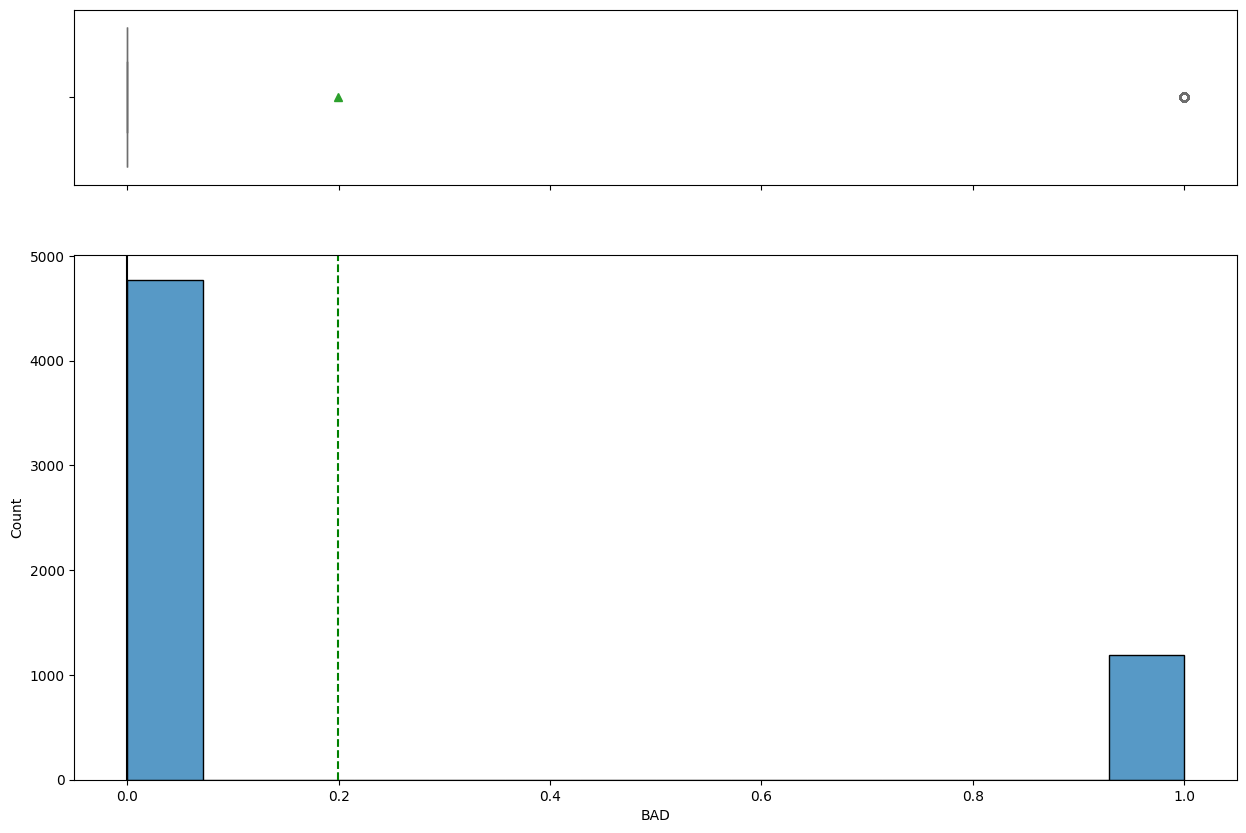

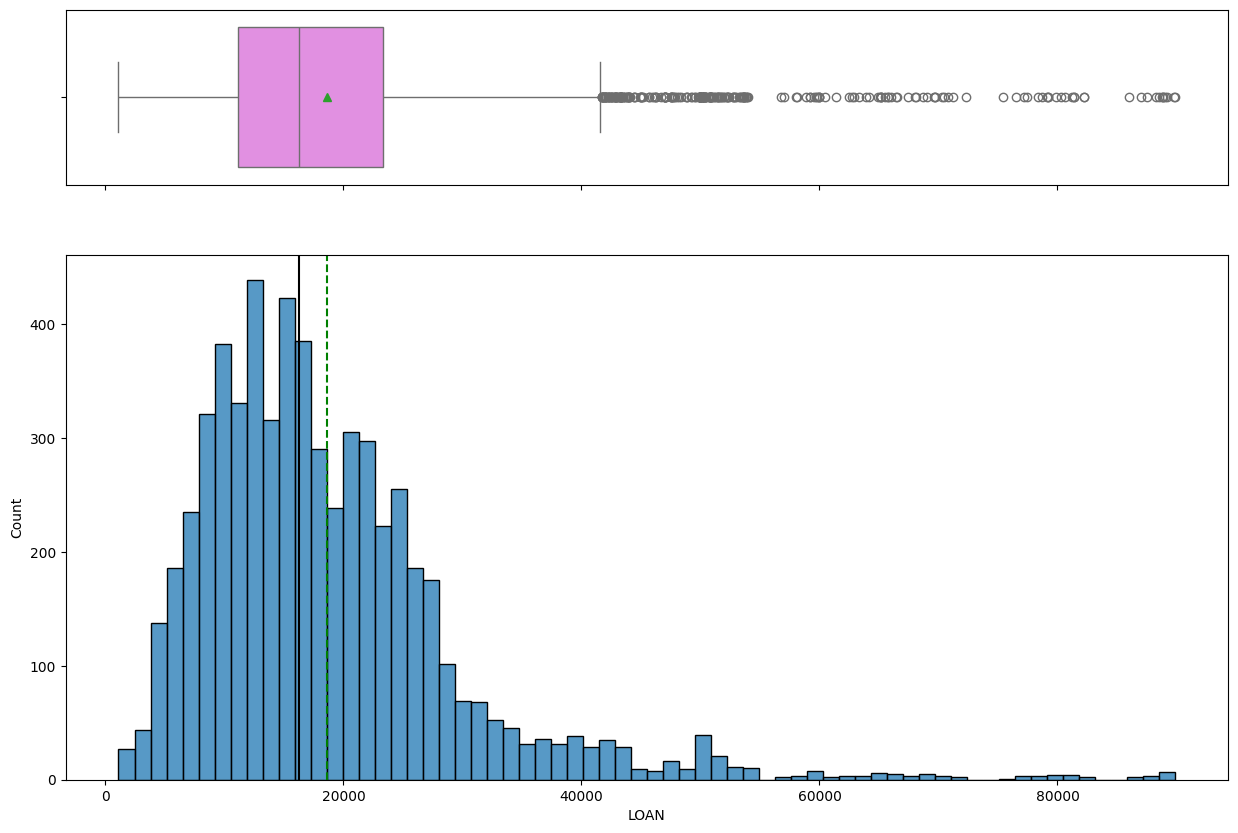

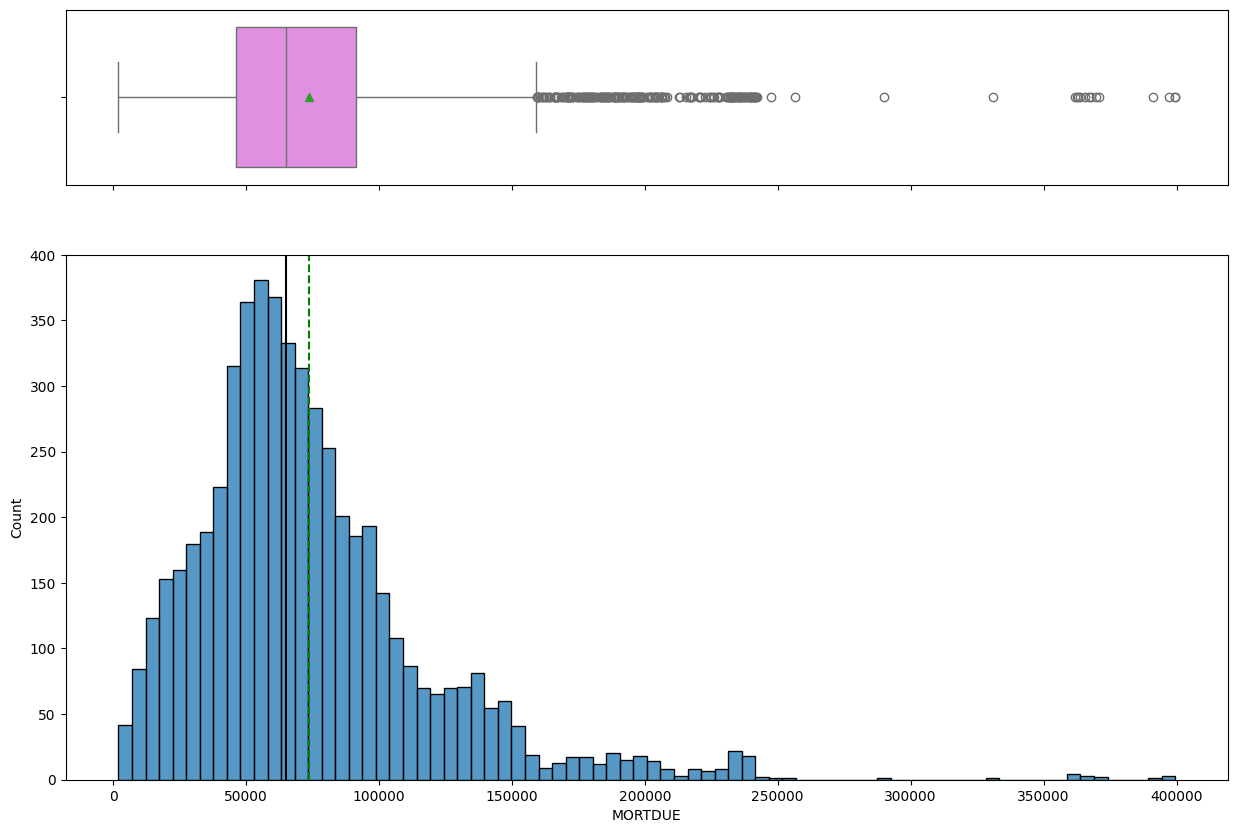

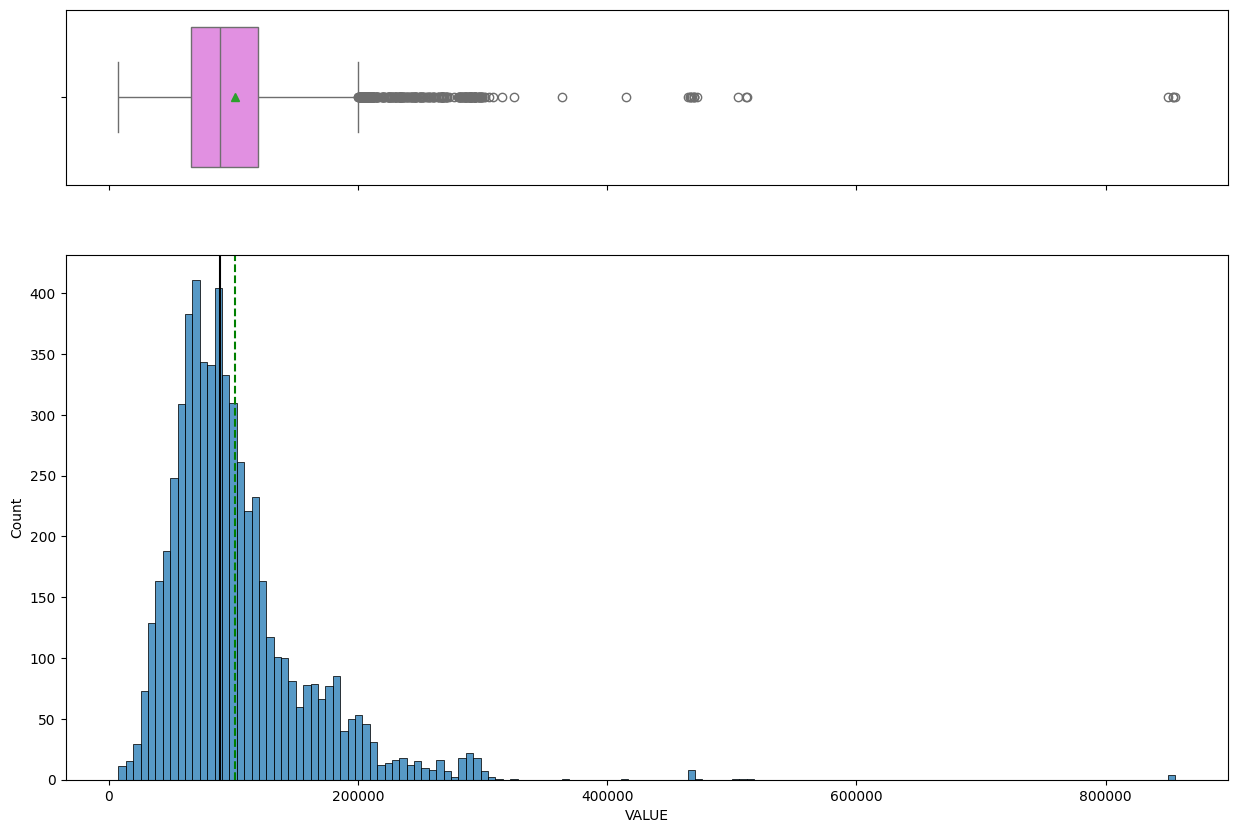

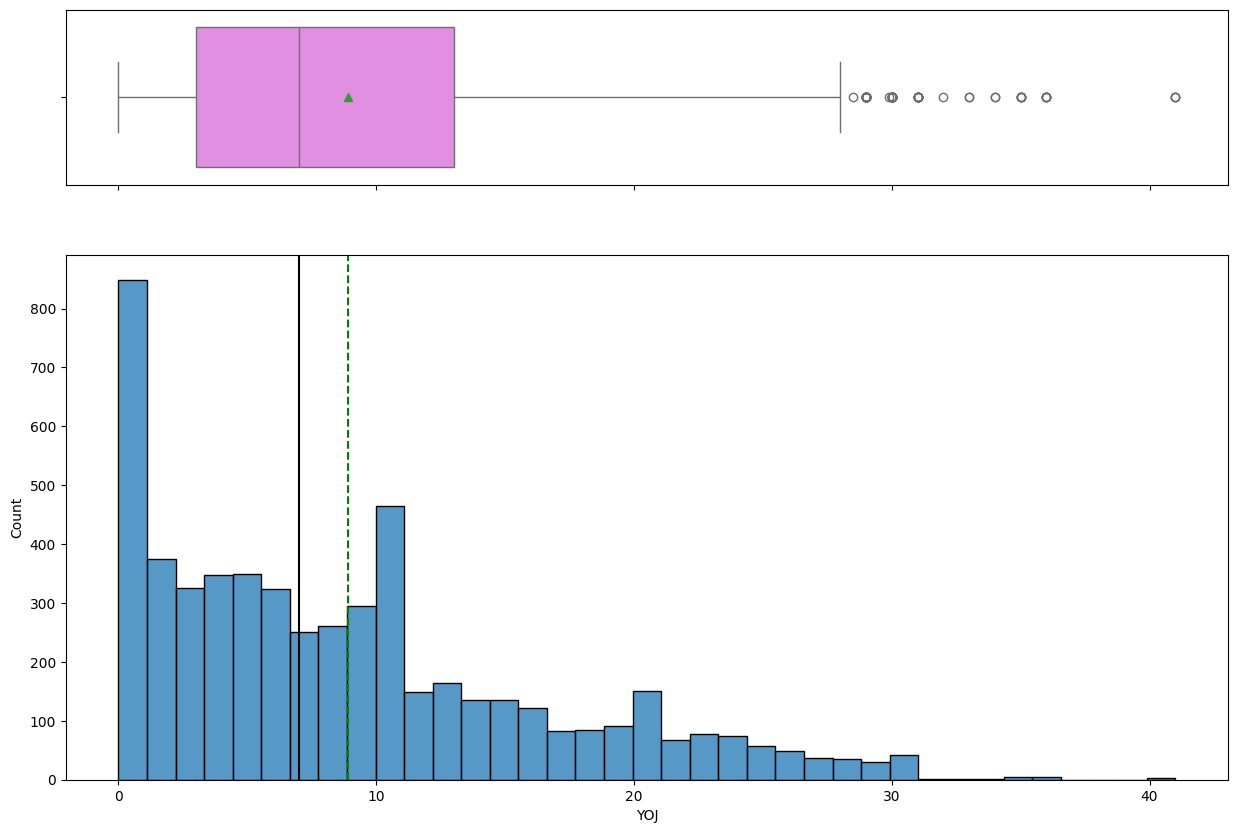

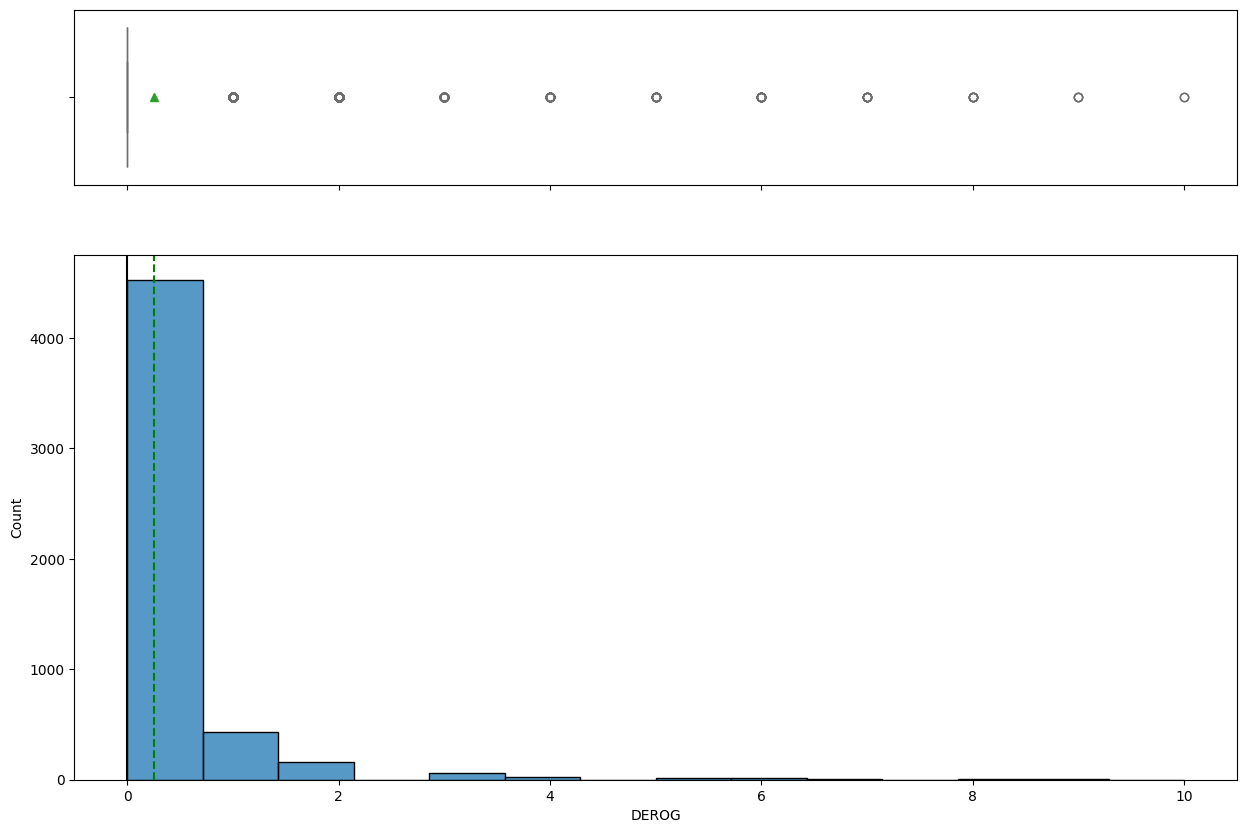

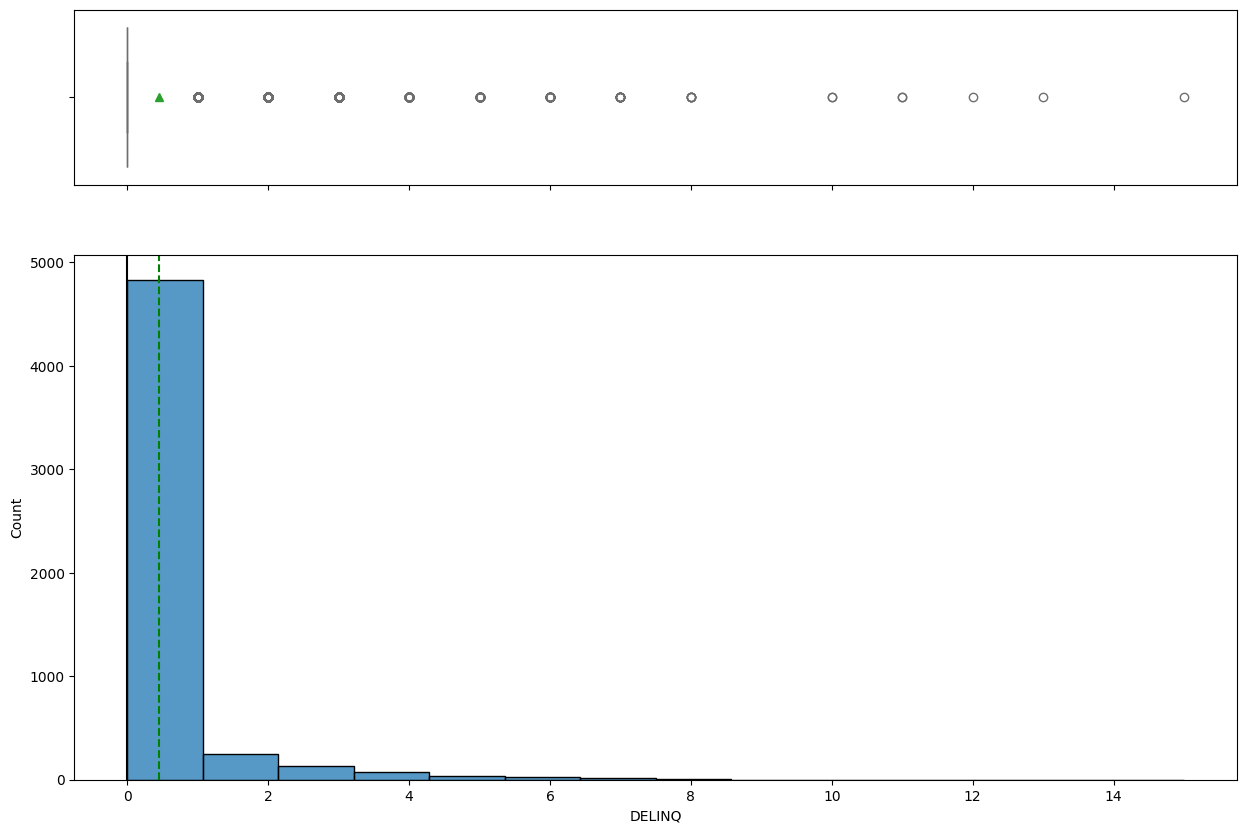

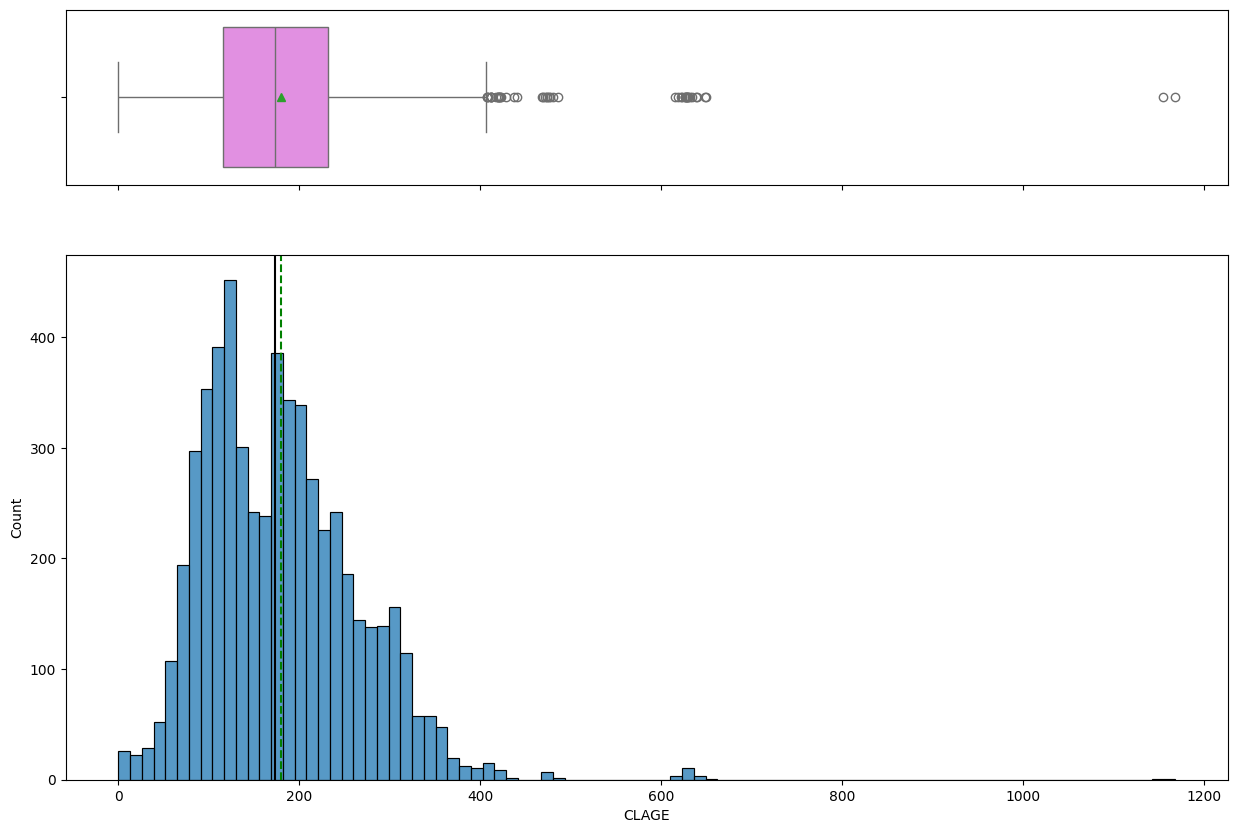

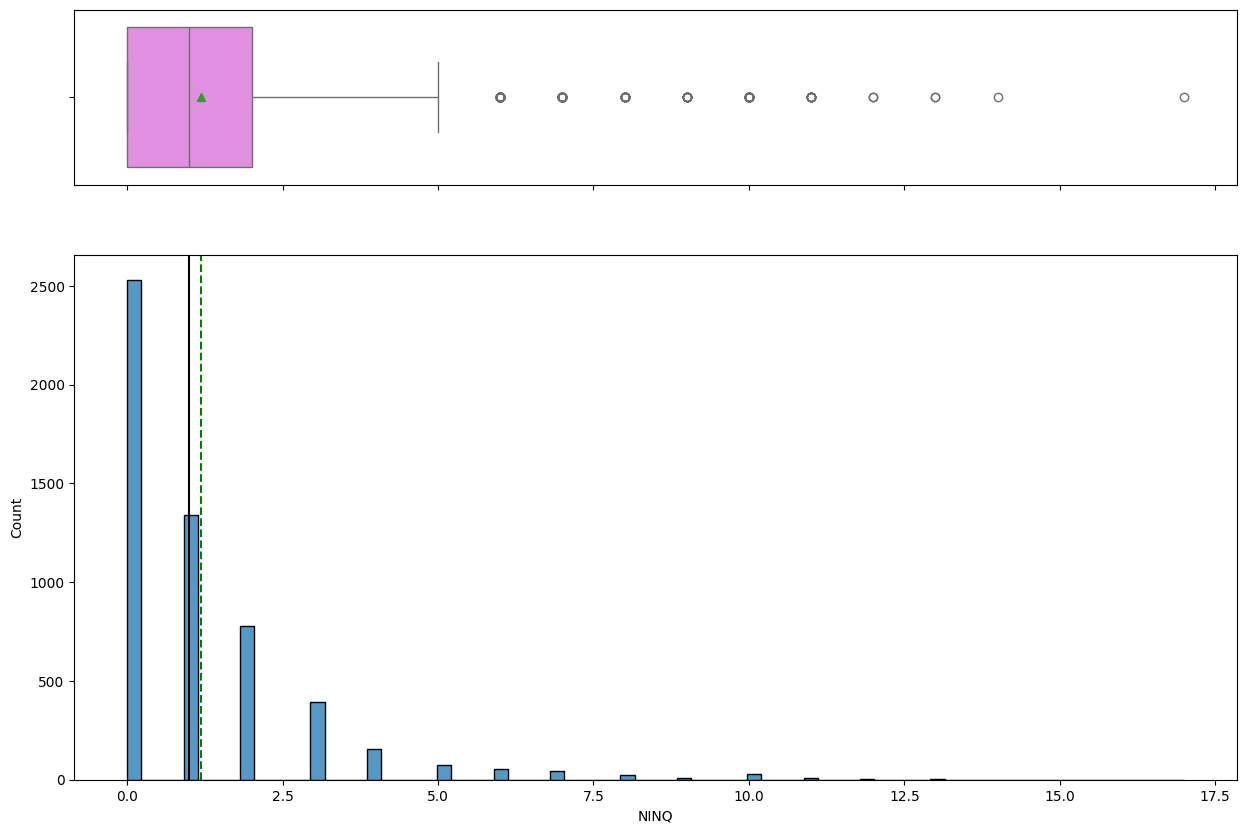

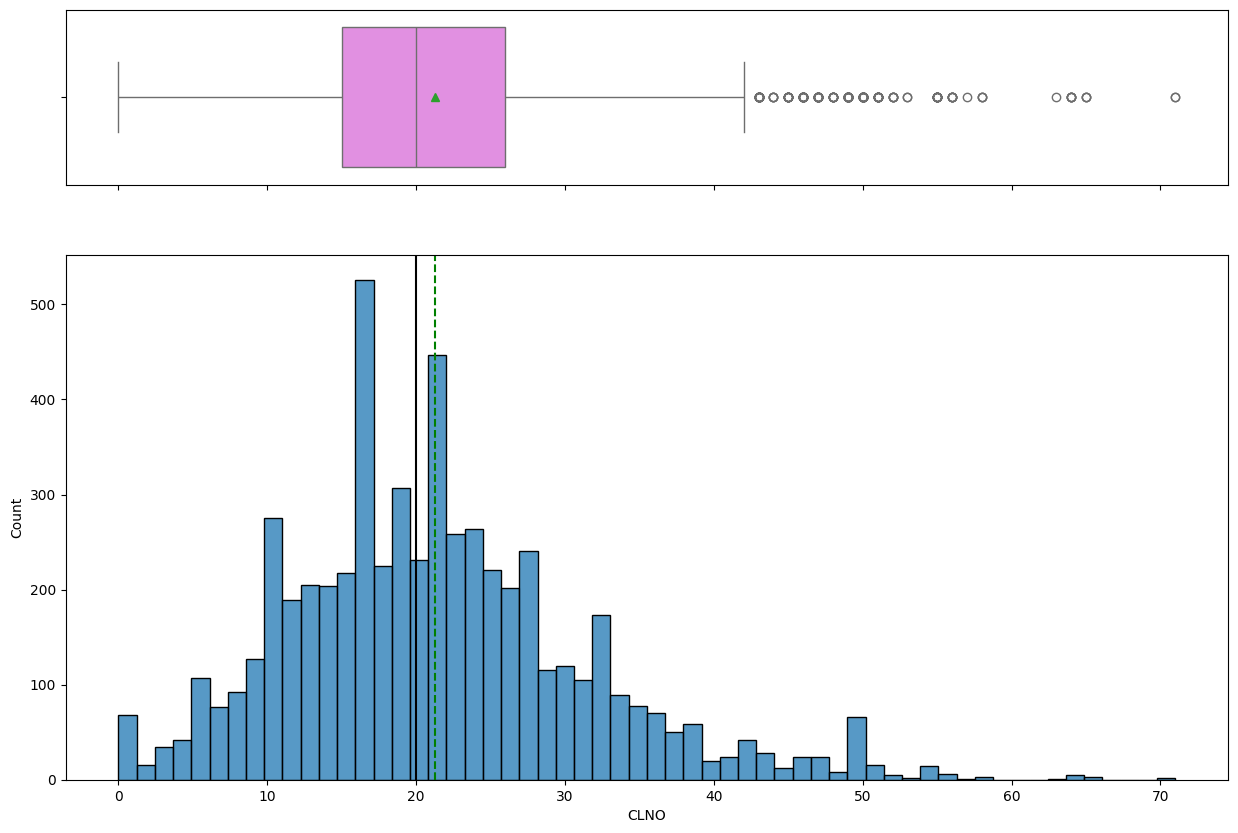

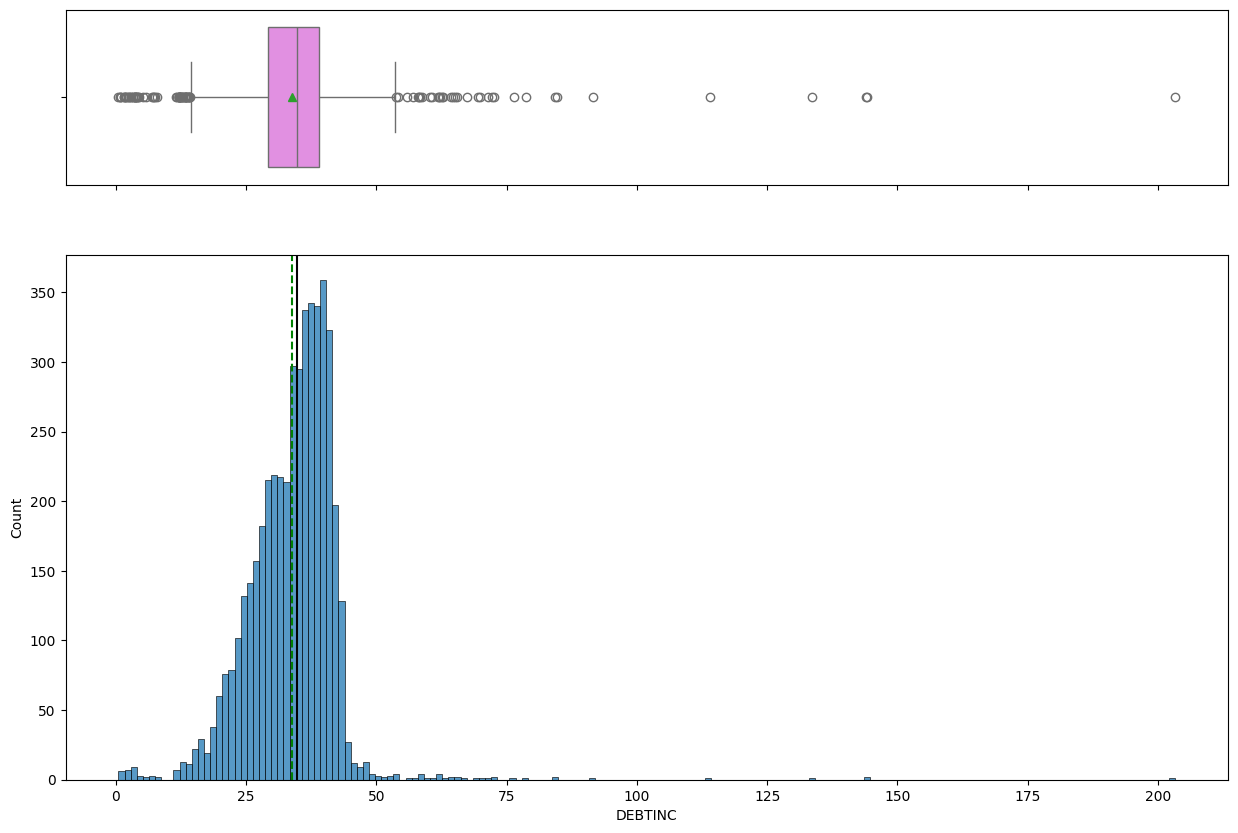

In [ ]:
# loop to plot histogram_plot for numeric variables
num_cols = data.select_dtypes(include = np.number).columns
for col in num_cols:
    histogram_boxplot(data, col)

**Observations**
>1. `Loan`:
    * Shape/Skewness"
        *  Right skewed:  TThis distribution have a long tail extending to the right.  This indicates that while most loan applications are for smaller amounts, there are some that are significantly larger.  
    *  Mean/Median:  
        *  The mean is greater than the median also indicating right skewness.
    *  Outliers:  
        *  There are outliers.  
>
>1. `MORTDUE`:
    * Shape/Skewness"
        *  Right skewed:  The distribution has a long tail extending to the right, indicating that while most mortgages have relatively smaller outstanding balances, a few have significantly larger amounts still due.  
    *  Mean/Median:  
        *  The mean is greater than the median also indicating right skewness.
    *  Outliers:  
        *  There are outliers.       
>
>1. `Value`:
    * Shape/Skewness"
        *  Right skewed:  The distribution has a long tail extending to the right, indicating that some property values are much higher than the average.  
    *  Mean/Median:  
        *  The mean is greater than the median also indicating right skewness.
    *  Outliers:  
        *  There are outliers.       
>
>1. `YOJ`:
    * Shape/Skewness"
        *  Right skewed:  The distribution has a tail extending to the right, indicating that there are a few loan applicants who have been at their current job for a long period of time.  
    *  Mean/Median:  
        *  The mean is greater than the median also indicating right skewness.
    *  Outliers:  
        *  There are outliers.  
>1. `DEROG`:
    * Shape/Skewness"
        *  Right skewed:  The distribution has a tail extending to the right, indicating that there are a few loan applicants who have had a high number of deliquency or late payments in their credit lines.
    *  Outliers:  
        *  There are outliers.  
>
>1. `DELINQ`:
    * Shape/Skewness"
        *  Right skewed:  The distribution has a tail extending to the right, indicating that there are a few loan applicants who have delinquent credit lines.  
    *  Outliers:  
        *  There are outliers.  
>
>1. `CLAGE`:
    * Shape/Skewness"
        *  Right skewed:  The distribution has a tail extending to the right.  This indictes that there are a few loan applicants who have fewer credit lines.    
        *  There are outliers.  
>1. `NINQ`:
    * Shape/Skewness"
        *  Right skewed:  The distribution has a tail extending to the right indicting that there are a few loan applicants with a larger number of recent credit inquiries.  
    *  Outliers:  
        *  There are outliers.  
>
>1. `CLNO`:
    * Shape/Skewness"
        *  Right skewed:  The distribution has a small tail extending to the right indicting that there are a few loan applicants with a larger number of of existing credit lines.  
    *  Outliers:  
        *  There are outliers.  
>1. `DEBTINC`:
    * Shape/Skewness"
        *  Right skewed:  The distribution has a tail extending to the right indicting that there are a loan applicants with a high debt to income ratio.    
    *  Outliers:  
        *  There are outliers.  
>
>1. `BAD`:  Target Variable
    * Shape/Skewness"
        *  There are a higher number of 0's than 1's

In [ ]:
# Checking the class imbalance of the traget variable BAD
data['BAD'].value_counts()

,count
BAD,
0,4771
1,1189


In [ ]:
# Checking the class imbalance of the traget variable BAD in percentage
data['BAD'].value_counts(normalize=True)

,proportion
BAD,
0,0.800503
1,0.199497


There is 80% non defaulters and 20% defaulters

### Univariate Analysis of Non - Numeric Columns

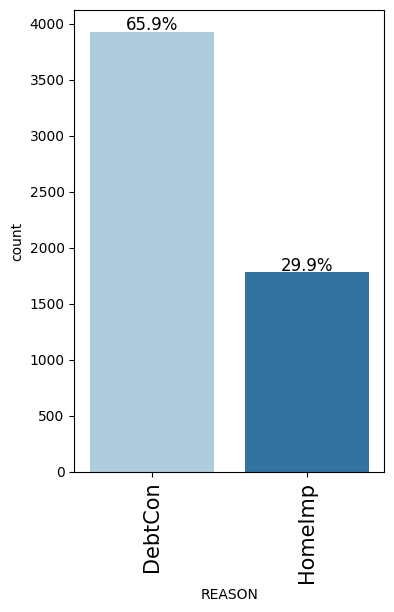

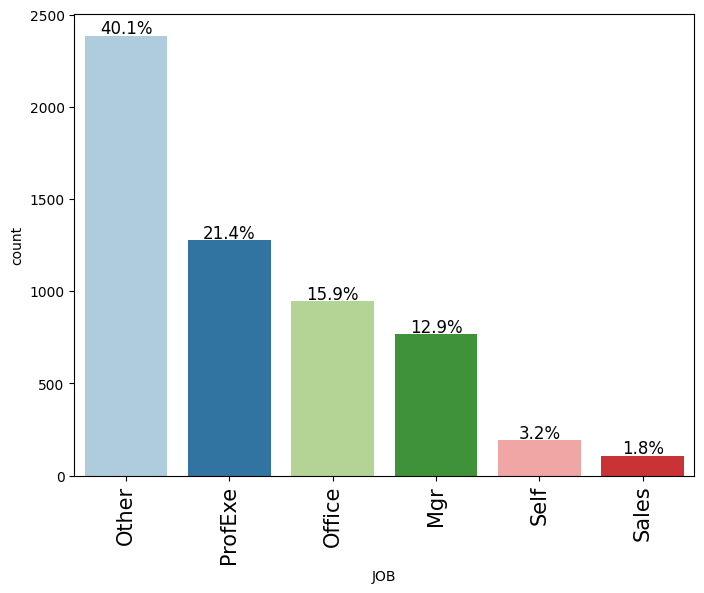

In [ ]:
# loop to plot labeled_barplot for non-numeric variables
non_num_cols = data.select_dtypes(exclude = np.number).columns
for col in non_num_cols:
    labeled_barplot(data, col, perc=True)

**Observations**

1. `REASON`  
   * Debt consolidation was the most popular reason for loan requests, accounting for approx 66% of loans. Home Improvement accounted for approx 30%.

2. `JOB`  
   * The majority of loan applicants, approx 40%, fall under the job category Other.  
   * The job with the least number of loan applicants is Sales with approx 1.8%.  
   * ProfExe is the second most common job category with approx 21%.



## Bivariate Analysis

### Numeric Variables

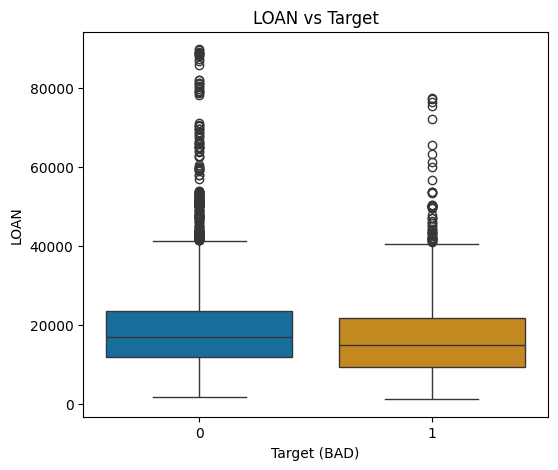

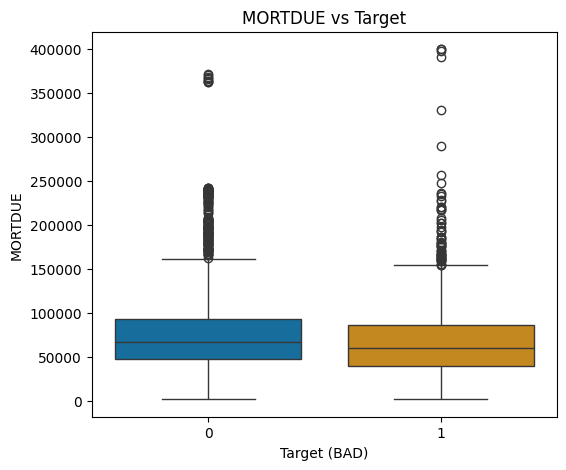

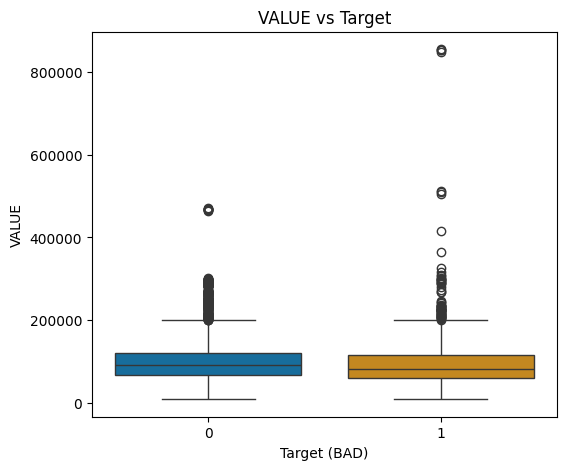

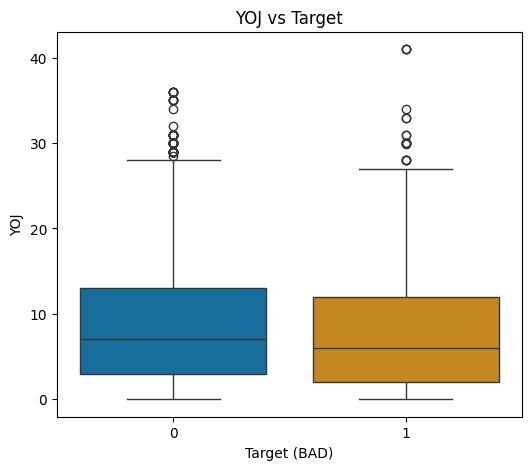

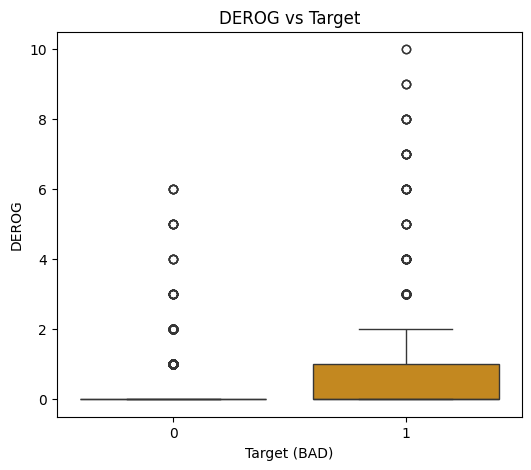

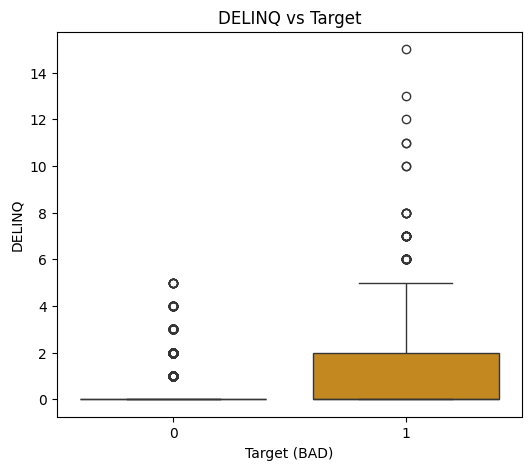

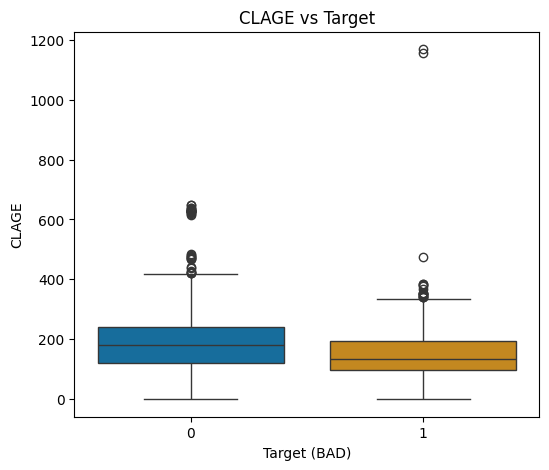

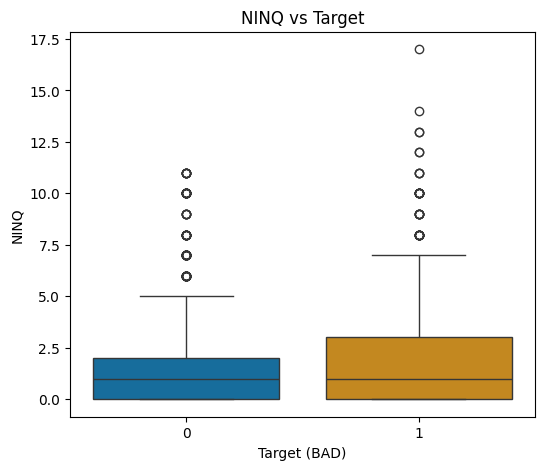

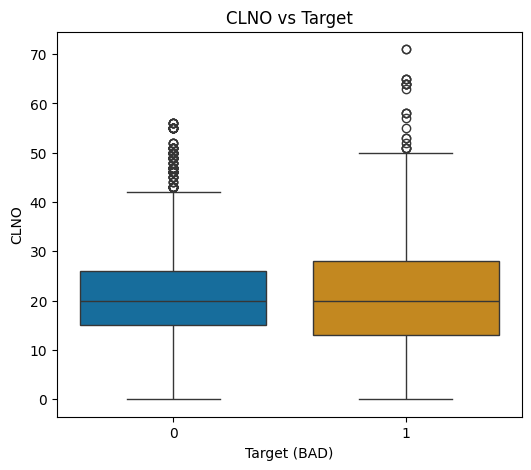

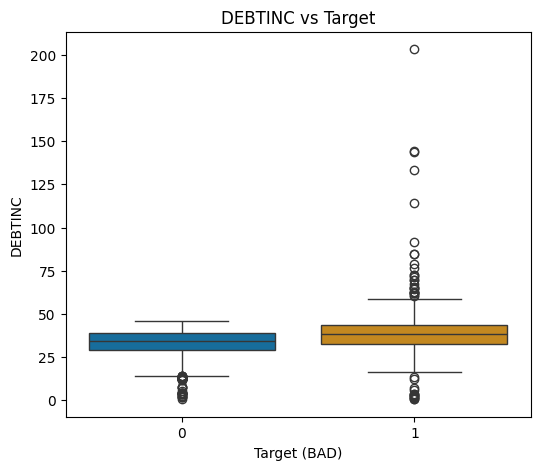

In [ ]:
# List of continuous variables to plot (exclude categorical ones)
variables_to_plot = [
    'LOAN', 'MORTDUE', 'VALUE', 'YOJ', 'DEROG', 'DELINQ',
    'CLAGE', 'NINQ', 'CLNO', 'DEBTINC'
]

for var in variables_to_plot:
    plt.figure(figsize=(6,5))
    sns.boxplot(x="BAD", y=var, data=data, palette=["#0173B2", "#DE8F05"])
    plt.title(f"{var} vs Target")
    plt.xlabel("Target (BAD)")
    plt.ylabel(var)
    plt.show()

#### Observations – Numeric Variables vs Target (`BAD`)

1. `LOAN` vs `BAD`  
   * Minimal differences observed between defaulters and non-defaulters.  
   * Median and interquartile ranges are nearly identical.  
   * Outliers exist in both groups without a clear pattern.  
   * Conclusion: `LOAN` alone is not a strong predictor of default.  

2. `MORTDUE` vs `BAD`  
   * Slightly higher median mortgage due values for non-defaulters.  
   * Defaulters exhibit some of the highest mortgage due amounts.  
   * Differences are small; patterns are inconsistent.  
   * Conclusion: `MORTDUE` is unlikely to be a strong standalone predictor.  

3. `VALUE` vs `BAD`  
   * Median and spread are similar between groups, but extreme high property values are more common among defaulters.  
   * This suggests property value alone does not guarantee lower default risk.  
   * Conclusion: `VALUE` has limited predictive power on its own.  

4. `YOJ` vs `BAD` (Years on Job)  
   * Defaulters generally have slightly lower years of job tenure.  
   * An isolated extreme high `YOJ` also resulted in default.  
   * Conclusion: `YOJ` shows some association with default risk, but is not a strong standalone predictor.  

5. `DEROG` vs `BAD` (Major Derogatory Reports)  
   * Defaulters have significantly higher derogatory counts; non-defaulters are concentrated near zero.  
   * All applicants with `DEROG ≥ 7` defaulted.  
   * Conclusion: High `DEROG` values (>6) are strong indicators of default risk.  

6. `DELINQ` vs `BAD` (Delinquent Credit Lines)  
   * Defaulters have more delinquencies than non-defaulters.  
   * All applicants with `DELINQ ≥ 6` defaulted.  
   * Conclusion: High `DELINQ` values (>6) strongly predict default risk.  

7. `CLAGE` vs `BAD` (Age of Oldest Credit Line)  
   * No clear separation between groups in non-extreme ranges.  
   * Some very large values (e.g., approx 1200 months) are linked to defaults.  
   * Conclusion: `CLAGE` has little predictive value by itself.  

8. `NINQ` vs `BAD` (Recent Credit Inquiries)  
   * Slight overlap between groups, but defaulters have more extreme values.  
   * All applicants with `NINQ > 12` defaulted.  
   * Conclusion: High `NINQ` values may indicate elevated risk.  

9. `CLNO` vs `BAD` (Number of Credit Lines)  
   * Similar distribution for both groups, but extreme high values (approx 60+) are linked to defaults.  
   * Conclusion: Very high `CLNO` counts may be a warning sign, though overall predictive power is limited.  

10. `DEBTINC` vs `BAD` (Debt-to-Income Ratio)  
    * For debt-to-income ratios ≤50%, group separation is minimal.  
    * All applicants with `DEBTINC > 50%` defaulted.  
    * Conclusion: High debt burden (>50% DTI) is a strong predictor of default.  

---

#### Summary Conclusions
- No clear distinction: `CLAGE`, `MORTDUE`, `LOAN`  
  These variables show similar medians and spreads for defaulters and non-defaulters, offering little predictive value on their own.

- Limited distinction (mainly at extreme high values): `VALUE`, `YOJ`, `NINQ`, `CLNO`  
  While differences are minimal in the typical range, extreme values (e.g., `NINQ` > 12, `CLNO` > 60) are more frequently associated with defaults.

- Strong indicators of default risk: `DEROG` (> 6), `DELINQ` (> 6), `DEBTINC` (> 50%)  
  These variables display clear separation between defaulters and non-defaulters, with high values strongly linked to loan default.


### Non-Numeric Variables

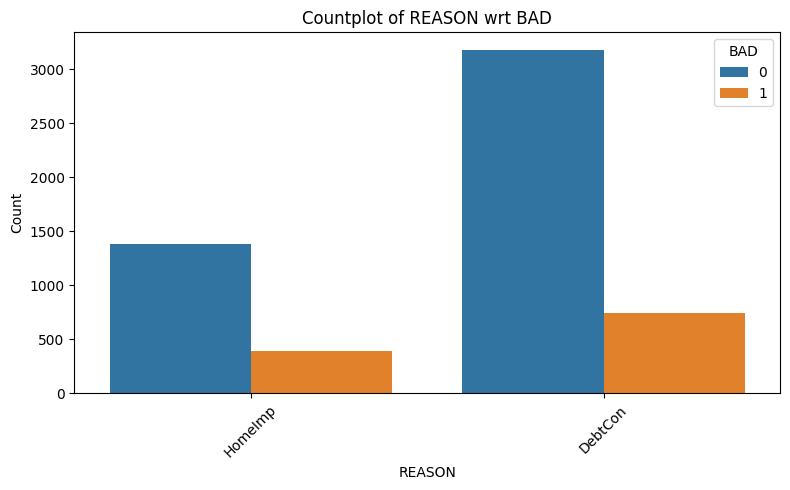

In [ ]:
# Plotting REASON wrt to target

plt.figure(figsize=(8, 5))
sns.countplot(data=data, x='REASON', hue='BAD')
plt.title('Countplot of REASON wrt BAD')
plt.xlabel('REASON')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

BAD         0     1   All
REASON                   
All      4567  1141  5708
DebtCon  3183   745  3928
HomeImp  1384   396  1780
------------------------------------------------------------------------------------------------------------------------


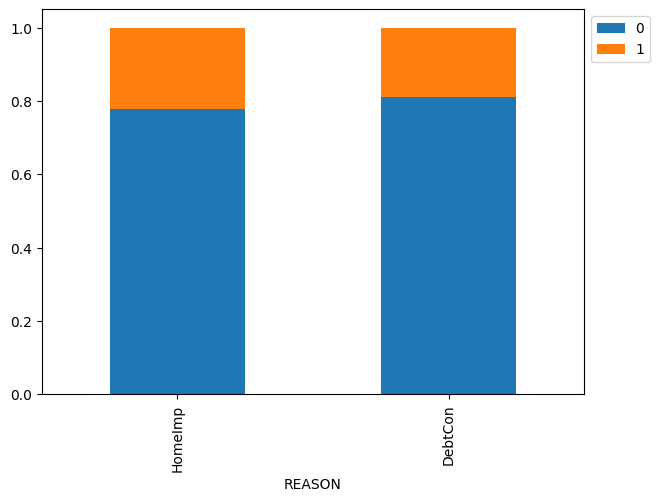

In [ ]:
stacked_barplot(data, "REASON", "BAD")

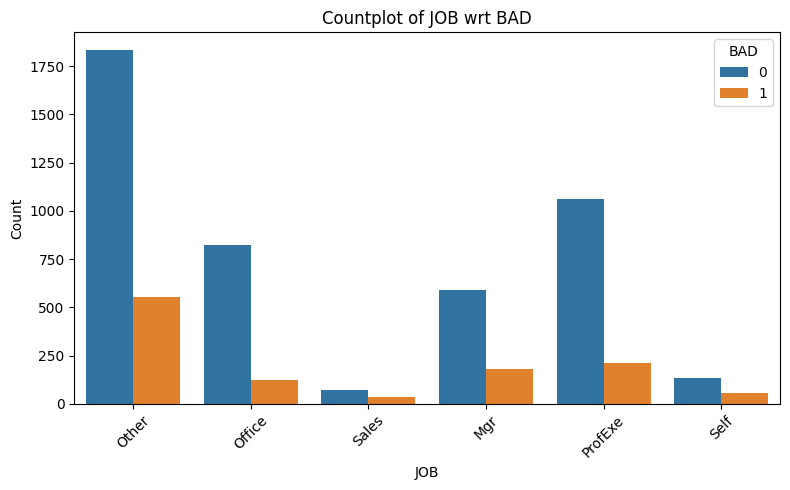

In [ ]:
# Plotting JOB wrt to target

plt.figure(figsize=(8, 5))
sns.countplot(data=data, x='JOB', hue='BAD')
plt.title('Countplot of JOB wrt BAD')
plt.xlabel('JOB')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

BAD         0     1   All
JOB                      
All      4515  1166  5681
Other    1834   554  2388
ProfExe  1064   212  1276
Mgr       588   179   767
Office    823   125   948
Self      135    58   193
Sales      71    38   109
------------------------------------------------------------------------------------------------------------------------


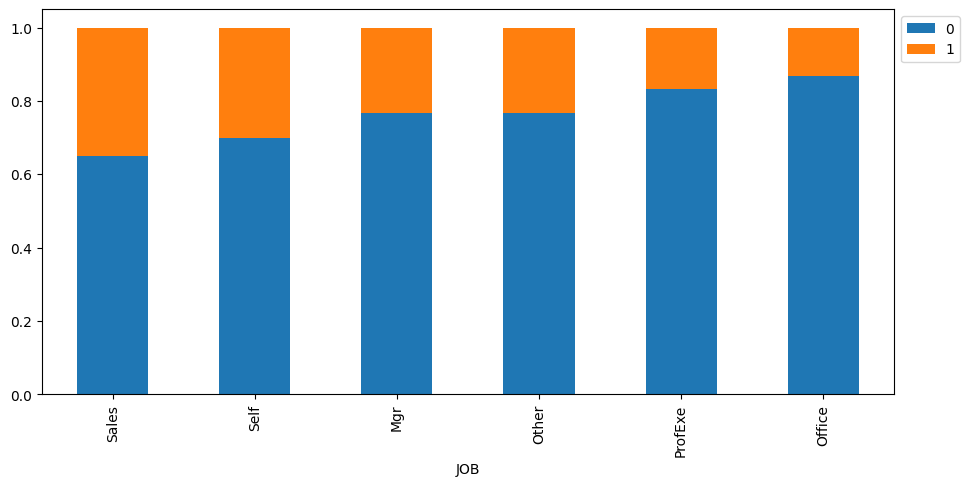

In [ ]:
stacked_barplot(data, "JOB", "BAD")

#### Observations – Categorical Variables vs Target (`BAD`)

1. `REASON` vs `BAD`  
   * `DebtCon` (debt consolidation) is the most common reason for loan applications, followed by `HomeImp` (home improvement).  
   * Although `DebtCon` loans have a higher overall application volume, `HomeImp` loans exhibit a slightly higher default rate proportionally.  
   * Conclusion: Loan purpose alone is not a dominant predictor, but `HomeImp` loans may carry marginally higher risk.  

2. `JOB` vs `BAD`  
   * The highest default rates occur among applicants in `Sales` and `Self-employed` roles.  
   * Applicants in `Office` and `ProfExe` positions have the lowest default rates.  
   * Conclusion: Employment type is a potential risk indicator, with `Sales` and `Self-employed` applicants representing higher-risk segments.  


### Multivariate Analysis

In this section, we examine combinations of variables to see how they relate to each other and whether they influence the target variable.  

We begin with a correlation matrix to identify the strength and direction of relationships between variables.


### Correlation Matrix

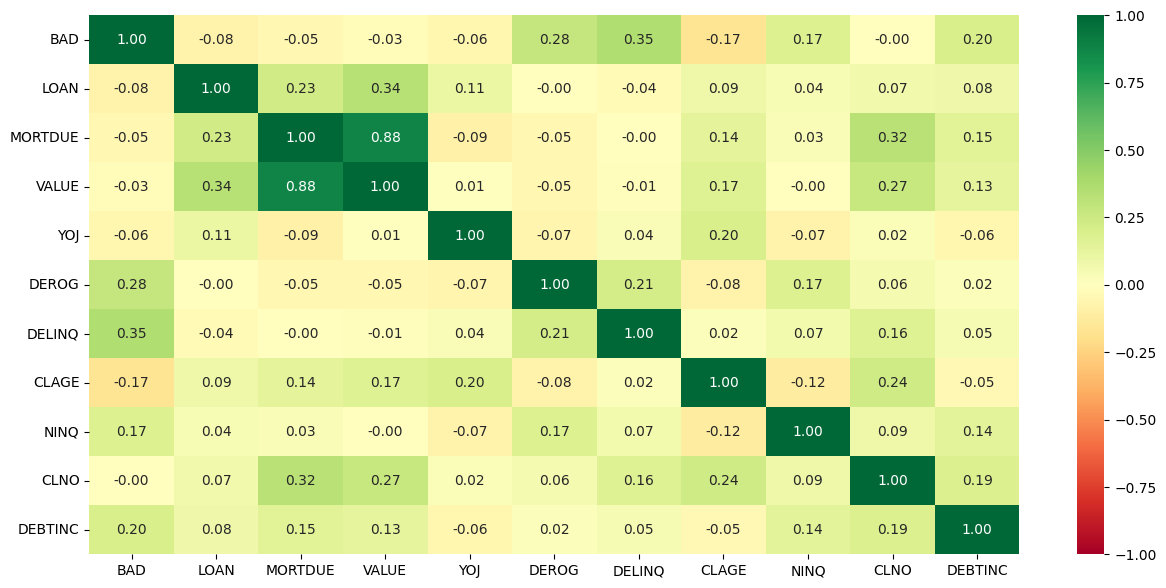

In [ ]:
# Generate a correlation heatmap for all numeric variables to visualize relationships between features and identify potential multicollinearity

cols_list = data.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(15, 7))
sns.heatmap(
    data[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="RdYlGn"
)
plt.show()

#### Multivariate Analysis – Correlation Heatmap Insights

#### 1. Relationship with Target (`BAD`)
- **Moderate Positive Correlations**  
  - `DELINQ` (**0.35**) – Strongest correlation with default; higher delinquency rates align with higher probability of default.  This corresponds to our findings in the bivariabe analysis
  - `DEROG` (**0.28**) – More major derogatory reports are linked to higher default likelihood.  This corresponds to our findings in the bivariabe analysis
  - `DEBTINC` (**0.20**) – Higher debt-to-income ratios moderately increase default risk.  This corresponds to our findings in the bivariabe analysis
  - `NINQ` (**0.17**) – More recent credit inquiries moderately raise default risk.  This corresponds to our findings in the bivariabe analysis

- **Weak / Negligible Correlations**  
  - `LOAN`, `MORTDUE`, `VALUE`, `YOJ`, `CLNO` have correlations close to zero with `BAD`.  This corresponds to our findings in the bivariabe analysis

---

### 2. Strong Inter-variable Relationships
- **High Positive Correlations**  
  - `MORTDUE` & `VALUE` (**0.88**) – Properties with higher values often have larger mortgage balances.  
  - `LOAN` & `VALUE` (**0.34**) and `LOAN` & `MORTDUE` (**0.23**) – Larger loans are generally associated with higher property values and mortgages.  
  - `CLNO` & `MORTDUE` (**0.32**) – More credit lines often correlate with larger mortgage dues.

---

### 3. Potential Multicollinearity Concerns
- The very high correlation between `MORTDUE` and `VALUE` (**0.88**) suggests redundancy; one of these may be dropped or transformed to avoid multicollinearity in modeling.
- Moderate correlation between `CLNO` and `MORTDUE` (**0.32**) and `VALUE` (**0.27**) should also be monitored.

---

### 4. Risk Indicators Emerging from Multiple Relationships
- `DEROG` and `DELINQ` are both positively correlated with each other (**0.21**) and with `BAD`, meaning applicants with poor credit history tend to show both high delinquency and derogatory marks.


## Summary of EDA before Data Preporcessing

### Univariate Overall Patterns
- Most numeric variables are **right-skewed** with a long right tail, indicating a small number of extreme high values.
- **Outliers** are present across all numeric features.
- The target variable `BAD` is imbalanced (~80% non-defaulters, ~20% defaulters).

---

### Bivariate – Key Findings – Numeric Variables vs `BAD`
- **No clear distinction:** `CLAGE`, `MORTDUE`, `LOAN` – similar medians and spreads for defaulters and non-defaulters.
- **Limited distinction (mainly at extreme high values):**  
  - `VALUE` – extreme high values more common among defaulters.  
  - `YOJ` – slightly lower tenure for defaulters; extremes linked to defaults.  
  - `NINQ` – most applicants with `NINQ > 10` defaulted.  
  - `CLNO` – very high counts (>60) linked to defaults.
- **Strong indicators of default risk:**  
  - `DEROG` (> 6) – most such applicants defaulted.  
  - `DELINQ` (> 4) – most such applicants defaulted.  
  - `DEBTINC` (> 50%) – all such applicants defaulted.

---

### Bivariate – Key Findings – Categorical Variables vs `BAD`
- **REASON** – Loan purpose not a dominant predictor; however, `HomeImp` loans show a slightly higher default rate than `DebtCon`.
- **JOB** – Employment type is a potential risk indicator:  
  - Highest default rates in `Sales` and `Self-employed`.  
  - Lowest default rates in `Office` and `ProfExe`.

---

### Multivariate Analysis – Correlation Insights

**1. Relationship with Target (`BAD`):**
- **Moderate Positive Correlations:**  
  - `DELINQ` (0.35) – strongest link with default risk.  
  - `DEROG` (0.28) – more derogatory reports → higher risk.  
  - `DEBTINC` (0.20) – higher ratios → moderate risk increase.  
  - `NINQ` (0.17) – more recent inquiries → moderate risk increase.
- **Weak / Negligible Correlations:**  
  - `LOAN`, `MORTDUE`, `VALUE`, `YOJ`, `CLNO` – correlations close to zero.

**2. Strong Inter-variable Relationships:**
- `MORTDUE` & `VALUE` (0.88) – high property value ↔ large mortgage balance.  
- `LOAN` & `VALUE` (0.34) and `LOAN` & `MORTDUE` (0.23) – larger loans tied to higher values/mortgages.  
- `CLNO` & `MORTDUE` (0.32) – more credit lines often accompany higher mortgage dues.

**3. Potential Multicollinearity Concerns:**
- `MORTDUE` & `VALUE` (0.88) – one may be dropped/transformed to reduce redundancy.  
- Monitor `CLNO` with `MORTDUE` (0.32) and `VALUE` (0.27).

**4. Risk Indicators Emerging from Multiple Relationships:**
- `DEROG` and `DELINQ` are positively correlated (0.21) and both link strongly to `BAD` → applicants with poor credit history often have both high delinquency and derogatory marks.


# Data Preprocessing

As part of the project requirements, data preprocessing is completed before the EDA phase.  
This step includes the following tasks:

1. Removal of unwanted variables  
2. Missing value treatment  
3. Outlier treatment  
4. Variable transformation  
5. Addition of new variables  


## Removal of unwanted variables.
There are no variables which at this stage needs to be removed.

**We will first make a copy of the data**

In [ ]:
# Making a copy of the data
df= data.copy()

 **We will  convert the object datatypes to category to aid in efficiency.**

In [ ]:
cols = df.select_dtypes(['object'])
cols.columns


Index(['REASON', 'JOB'], dtype='object')

In [ ]:
for i in cols.columns:
    df[i] = df[i].astype('category')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5960 entries, 0 to 5959
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   BAD      5960 non-null   int64   
 1   LOAN     5960 non-null   int64   
 2   MORTDUE  5442 non-null   float64 
 3   VALUE    5848 non-null   float64 
 4   REASON   5708 non-null   category
 5   JOB      5681 non-null   category
 6   YOJ      5445 non-null   float64 
 7   DEROG    5252 non-null   float64 
 8   DELINQ   5380 non-null   float64 
 9   CLAGE    5652 non-null   float64 
 10  NINQ     5450 non-null   float64 
 11  CLNO     5738 non-null   float64 
 12  DEBTINC  4693 non-null   float64 
dtypes: category(2), float64(9), int64(2)
memory usage: 524.3 KB


In [ ]:
# Checking the data was copied correctly
df.head()

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,1,1100,25860.0,39025.0,HomeImp,Other,10.5,0.0,0.0,94.366667,1.0,9.0,NaN
1,1,1300,70053.0,68400.0,HomeImp,Other,7.0,0.0,2.0,121.833333,0.0,14.0,NaN
2,1,1500,13500.0,16700.0,HomeImp,Other,4.0,0.0,0.0,149.466667,1.0,10.0,NaN
3,1,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,1700,97800.0,112000.0,HomeImp,Office,3.0,0.0,0.0,93.333333,0.0,14.0,NaN


In [ ]:
df.shape

(5960, 13)

## Missing Value Treatment


**Observations**
We see the data was copied correctly and the object datatype was converted to category.  The file size reduced.

### Visually inspecting the missing data

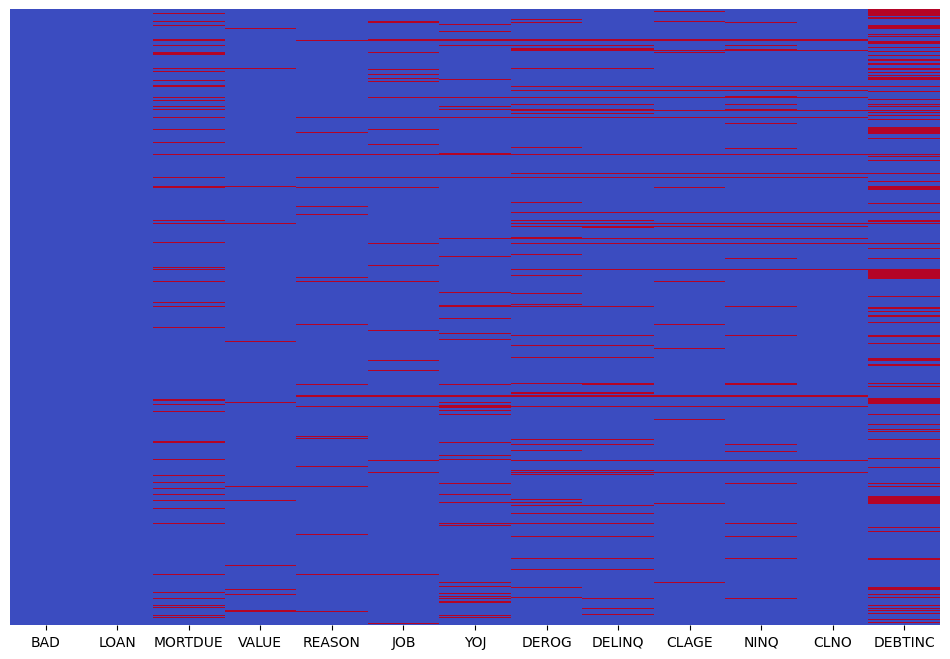

In [ ]:
plt.figure(figsize = (12,8))
sns.heatmap(df.isnull(), cbar = False, cmap = 'coolwarm', yticklabels = False)
plt.show()

**Observations**
>1. We see there are few rows which have many missing data

###Examining total missing data by rows

In [ ]:
# Calculating the number of null values for each row
df.isnull().sum(axis = 1).sort_values(ascending = False)

,0
3,11
1405,11
51,10
333,10
112,10
...,...
2516,0
2518,0
2519,0
2488,0


In [ ]:
# Calcualting the percentage of null values for each row
null_percentage_per_row = df.isnull().mean(axis=1) * 100

In [ ]:
# Listing percentage of null values for each row in ascending order
null_percentage_per_row.sort_values(ascending=False)

,0
3,84.615385
1405,84.615385
51,76.923077
333,76.923077
112,76.923077
...,...
2516,0.000000
2518,0.000000
2519,0.000000
2488,0.000000


In [ ]:
# Filter rows with more than 50% missing values
rows_with_gt_50_nulls = null_percentage_per_row > 50

# Calculate percentage of rows with more than 50% missing values
percent_rows_gt_50_nulls = rows_with_gt_50_nulls.mean() * 100


print(f"{percent_rows_gt_50_nulls:.2f}% of rows have more than 50% missing values.")
print(f"{rows_with_gt_50_nulls.sum()} rows have more than 50% missing values.")

2.11% of rows have more than 50% missing values.
126 rows have more than 50% missing values.


**Observations**

We will delete the rows with more than 50% missing values to maintain data quality.  
This represents only 2.11% of the data, or 126 out of 5,690 rows.  
A 50% cutoff is used to remove highly incomplete data.


In [ ]:
# Create a copy of the dataset after removing all rows with more than 50% missing values

df_rows_cleaned = df[~rows_with_gt_50_nulls].copy()

In [ ]:
df_rows_cleaned.head()

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,1,1100,25860.0,39025.0,HomeImp,Other,10.5,0.0,0.0,94.366667,1.0,9.0,NaN
1,1,1300,70053.0,68400.0,HomeImp,Other,7.0,0.0,2.0,121.833333,0.0,14.0,NaN
2,1,1500,13500.0,16700.0,HomeImp,Other,4.0,0.0,0.0,149.466667,1.0,10.0,NaN
4,0,1700,97800.0,112000.0,HomeImp,Office,3.0,0.0,0.0,93.333333,0.0,14.0,NaN
5,1,1700,30548.0,40320.0,HomeImp,Other,9.0,0.0,0.0,101.466002,1.0,8.0,37.113614


In [ ]:
df_rows_cleaned.shape

(5834, 13)

**Observations**

After removing rows with more than 50% missing values, the dataset now contains 5,834 rows and 13 columns.


### Examining missing data by columns

In [ ]:
# Checking the percentage of missing values in each variable
df_rows_cleaned.isnull().sum().sort_values(ascending = False)/df_rows_cleaned.index.size

,0
DEBTINC,0.210490
DEROG,0.099760
DELINQ,0.077820
MORTDUE,0.075591
YOJ,0.069935
NINQ,0.065821
CLAGE,0.031196
JOB,0.029825
REASON,0.028625
CLNO,0.016455


**Observations**

We would normally drop any column with more than 30% missing values, but there are none in our dataset.  
The maximum percentage of missing data in any column is 21%.


In [ ]:
# Examining the number of missing values in each column.
df_rows_cleaned.isnull().sum().sort_values(ascending = False)

,0
DEBTINC,1228
DEROG,582
DELINQ,454
MORTDUE,441
YOJ,408
NINQ,384
CLAGE,182
JOB,174
REASON,167
CLNO,96


### Treating the Remaining Missing Values

Since the dataset contains both categorical and numeric variables, we will handle missing values separately for each type.

**Approach:**

1. **Prevent data leakage**  
   - Split the dataset into `X` (features) and `Y` (target variable).

2. **Separate variable types**  
   - Split `X` into categorical and numeric subsets.

3. **Handle missing values**  
   - **Categorical variables:** Impute missing values using `SimpleImputer(strategy='most_frequent')`.  
   - **Numeric variables:** Impute missing values using `KNNImputer`.

4. **Recombine processed data**  
   - Merge the transformed numeric and categorical data back into a single DataFrame.

### Splitting `df_rows_cleaned` into X and Y
This step ensures that the target variable is separated from the features, preventing data leakage during model training.


In [ ]:
# Separating X and Y variables for KNN imputer
X = df_rows_cleaned.drop(["BAD"], axis=1)
Y = df_rows_cleaned["BAD"]

In [ ]:
# Checking if the data separated correctly
X.head()

,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,1100,25860.0,39025.0,HomeImp,Other,10.5,0.0,0.0,94.366667,1.0,9.0,NaN
1,1300,70053.0,68400.0,HomeImp,Other,7.0,0.0,2.0,121.833333,0.0,14.0,NaN
2,1500,13500.0,16700.0,HomeImp,Other,4.0,0.0,0.0,149.466667,1.0,10.0,NaN
4,1700,97800.0,112000.0,HomeImp,Office,3.0,0.0,0.0,93.333333,0.0,14.0,NaN
5,1700,30548.0,40320.0,HomeImp,Other,9.0,0.0,0.0,101.466002,1.0,8.0,37.113614


In [ ]:
# Checking if the data separated correctly
Y.head()

,BAD
0,1
1,1
2,1
4,0
5,1


In [ ]:
Y.shape

(5834,)

### Separating the X variable into categorical and numeric.

In [ ]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5834 entries, 0 to 5959
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   LOAN     5834 non-null   int64   
 1   MORTDUE  5393 non-null   float64 
 2   VALUE    5739 non-null   float64 
 3   REASON   5667 non-null   category
 4   JOB      5660 non-null   category
 5   YOJ      5426 non-null   float64 
 6   DEROG    5252 non-null   float64 
 7   DELINQ   5380 non-null   float64 
 8   CLAGE    5652 non-null   float64 
 9   NINQ     5450 non-null   float64 
 10  CLNO     5738 non-null   float64 
 11  DEBTINC  4606 non-null   float64 
dtypes: category(2), float64(9), int64(1)
memory usage: 513.1 KB


In [ ]:
X.shape

(5834, 12)

In [ ]:
# Separating X variable into numeric and non numeric
non_numeric_cols = X.select_dtypes(include=['category']).columns.tolist()
numeric_cols = X.select_dtypes(include=['number']).columns.tolist()

In [ ]:
# Imputing the values of the object variables to the most frequent value in the column using Simple Imputer.
non_numeric_imputer = SimpleImputer(strategy='most_frequent')
non_numeric_imputed_df = pd.DataFrame(non_numeric_imputer.fit_transform(X[non_numeric_cols]), columns=non_numeric_cols)

In [ ]:
# Checking if there are any missing values after imputation in the non numeric fields.
non_numeric_imputed_df.isnull().sum()

,0
REASON,0
JOB,0


**Observations**

All missing values in the non-numeric fields have been addressed, resulting in a complete dataset for categorical variables.  

The next step will focus on imputing the remaining missing values in the numeric fields to ensure data completeness before proceeding with further preprocessing steps. This will be done using KNN Imputer with 5 nearest neighbors. Using 5 neighbors ensures that we do not smooth the data too much (with a larger value) and reduces the influence of extreme values or outliers (with a smaller value). By default, Euclidean distance is used.


In [ ]:
# imputing thes missing values using KNN Imputer, using 5 neighbors
num_imputer = KNNImputer(n_neighbors=5)
num_imputed_array = num_imputer.fit_transform(X[numeric_cols])
numeric_imputed_df = pd.DataFrame(num_imputed_array, columns=numeric_cols)

In [ ]:
# Checking for null values after imputations in the numeric fields
numeric_imputed_df.isnull().sum()

,0
LOAN,0
MORTDUE,0
VALUE,0
YOJ,0
DEROG,0
DELINQ,0
CLAGE,0
NINQ,0
CLNO,0
DEBTINC,0


**Observations**

All missing values in the numeric fields have been imputed using KNN Imputer with 5 nearest neighbors, resulting in a complete dataset with no remaining missing values.


### Let us now combine `numeric_imputed_df` with `non_numeric_imputed_df` to have all the X variables in one dataframe.

In [ ]:
# Combining the numeric and non-numeric variables
X_cleaned_missing= pd.concat([numeric_imputed_df, non_numeric_imputed_df], axis=1)

In [ ]:
# Checking for missing values

print(X_cleaned_missing.isnull().sum())

LOAN       0
MORTDUE    0
VALUE      0
YOJ        0
DEROG      0
DELINQ     0
CLAGE      0
NINQ       0
CLNO       0
DEBTINC    0
REASON     0
JOB        0
dtype: int64


**Observations**

All missing values in the numeric fields have been successfully imputed, and no missing values remain in these variables.  

Next, we will combine `X_cleaned_missing` and `Y`, starting by resetting the indexes.


In [ ]:
# Resetting the index of X_cleaned_missing and Y so they will match with Y
X_cleaned = X_cleaned_missing.reset_index(drop=True)
Y = Y.reset_index(drop=True)

In [ ]:
# Combining X_cleaned with Y so we can perform outlier treatment
full_df = pd.concat([X_cleaned, Y], axis=1)

In [ ]:
#Ensuring the number of rows are correct
full_df.shape

(5834, 13)

In [ ]:
#  Checking if the data concatenated
full_df.head()

,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC,REASON,JOB,BAD
0,1100.0,25860.0,39025.0,10.5,0.0,0.0,94.366667,1.0,9.0,29.994530,HomeImp,Other,1
1,1300.0,70053.0,68400.0,7.0,0.0,2.0,121.833333,0.0,14.0,40.532794,HomeImp,Other,1
2,1500.0,13500.0,16700.0,4.0,0.0,0.0,149.466667,1.0,10.0,36.196050,HomeImp,Other,1
3,1700.0,97800.0,112000.0,3.0,0.0,0.0,93.333333,0.0,14.0,34.370509,HomeImp,Office,0
4,1700.0,30548.0,40320.0,9.0,0.0,0.0,101.466002,1.0,8.0,37.113614,HomeImp,Other,1


### Missing Value Treatment Summary

### Observations – Initial Missing Data Review
- Some rows contain a large number of missing values.
- **Rows with > 50% missing data** were removed to maintain dataset quality.  
  - This resulted in the deletion of **126 rows** out of **5,960** (~**2.11%** of the dataset).
- We would normally drop any column with more than **30%** missing values, but none met this threshold.  
  - The maximum % of missing data in any column was **21%**.

---

### Approach for Remaining Missing Values
Since the dataset contains both categorical and numeric variables, missing values were handled separately for each type:

1. **Prevent Data Leakage**  
   - Split the dataset into `X` (features) and `Y` (target).

2. **Separate Variable Types**  
   - Split `X` into categorical and numeric subsets.

3. **Handle Missing Values**  
   - **Categorical variables** – Imputed missing values using `SimpleImputer(strategy='most_frequent')` to replace NaNs with the most frequent category in each column.  
   - **Numeric variables** – Imputed missing values using `KNNImputer` with `n_neighbors=5` to:  
     - Avoid excessive smoothing (large `n_neighbors`).  
     - Reduce noise and outlier influence (small `n_neighbors`).  
     - Use Euclidean distance (default) for neighbor selection.


5. **Recombine Processed Data**  
   - Merged the transformed numeric and categorical subsets back into a single DataFrame.

---

### Observations – Post-Imputation
- All missing values in **categorical variables** have been addressed using most frequent category imputation → dataset is now complete for these fields.
- All missing values in **numeric variables** have been successfully imputed using KNN → no missing values remain in the dataset.
- The processed `X` was recombined with `Y` after resetting indexes.


## Outlier Treatment


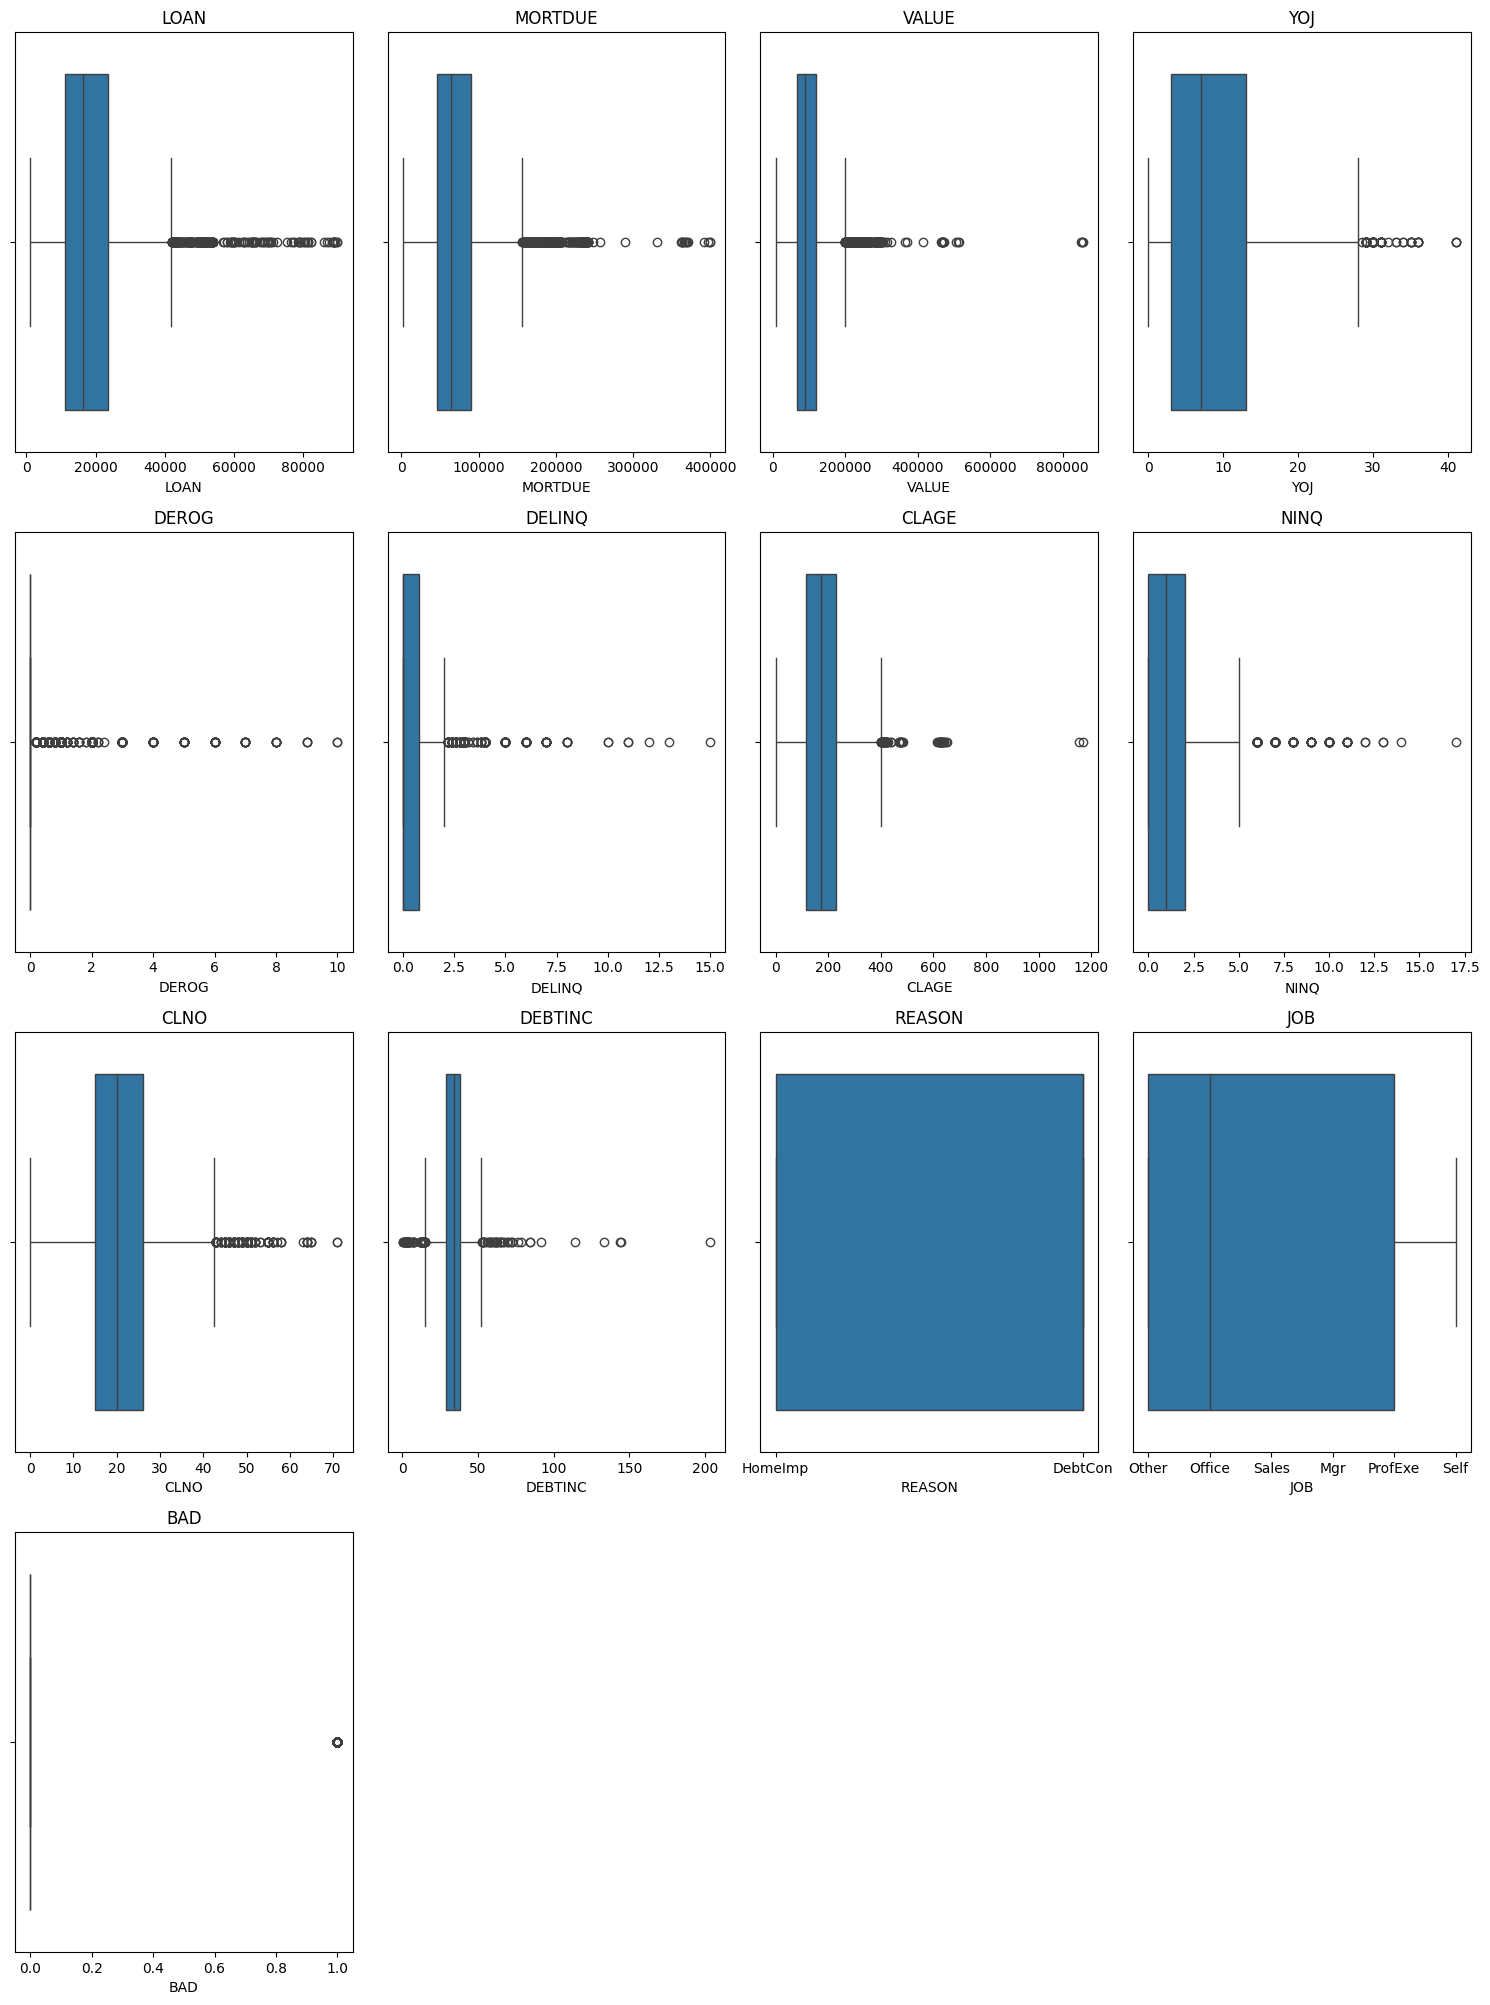

In [ ]:
# outlier detection using boxplot
# Calculate the number of rows and columns needed for subplots
n_cols = 4
n_rows = (len(full_df) + n_cols - 1) // n_cols

plt.figure(figsize=(15, n_rows * 5))

for i, variable in enumerate(full_df):
    plt.subplot(n_rows, n_cols, i + 1)
    sns.boxplot(data=full_df, x=variable, whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

**Observations**

All variables in the dataset contain outliers, indicating the need for outlier detection and potential treatment before modeling.

Let us examine each variable to determine if the outliers can be explainable.


In [ ]:
# Creating a loop to print the max and min of each variable so we can determine of the outliers are explainable.
num_cols = full_df.select_dtypes(include=np.number)

for col in num_cols.columns:
    print(f"{col} has a min of {df[col].min():.2f} and a max of {df[col].max():.2f}")

LOAN has a min of 1100.00 and a max of 89900.00
MORTDUE has a min of 2063.00 and a max of 399550.00
VALUE has a min of 8000.00 and a max of 855909.00
YOJ has a min of 0.00 and a max of 41.00
DEROG has a min of 0.00 and a max of 10.00
DELINQ has a min of 0.00 and a max of 15.00
CLAGE has a min of 0.00 and a max of 1168.23
NINQ has a min of 0.00 and a max of 17.00
CLNO has a min of 0.00 and a max of 71.00
DEBTINC has a min of 0.52 and a max of 203.31
BAD has a min of 0.00 and a max of 1.00


**Observations**
>1.  `BAD`:  This is the target variable.
>
>2.   `LOAN`:  Loan values ranges from \$1100 to \$89900.  Loan has outliers to the right.  This seems explainable. **NO OUTLIER TREATMENT NEEDED**
>
>3.  `MORTDUE`:  The mortgage due values ranges from \$206.30 to \$399550.00.  There are outliers to the right.  This seems explainable. **NO OUTLIER TREATMENT NEEDED**
>
>4.  `VALUE`:  The current property value ranges from \$8000 to \$855909.  There are outliers to the right.  This seems explainable.  **NO OUTLIER TREATMENT NEEDED**
>
>5. `YOJ`:  Number of years at the present job ranges from 0 to 41.  There are outliers to the right.  This seems explainable. **NO OUTLIER TREATMENT NEEDED**
>
>6. `DEROG`:  The number of major derogatory reports ranges from 0 to 15.  There are outliers to the right.  This seems explainable.  **NO OUTLIER TREATMENT NEEDED**
>
>7.    `DELINQ`:  The number of delinquent credit lines ranges from 0 to 15.  There are outliers to the right.  This seems explanatory especially as the major derogatory reports, `DEROG` also ranges from 0 to 15.  **NO OUTLIER TREATMENT NEEDED**
>
>8.   `CLAGE`:  Age of the oldest credit line ranges from 0 to 1168 months.  This is just over 97 years.  This does not appear to be easily explainable.
 This variable has outliers.  **EXAMINE FURTHER**
 >
 >9.   `NINQ`:  Number of recent credit inquiries ranges from 0 to 17.  There are outliers to the right.  This seems explainable.  **NO OUTLIER TREATMENT NEEDED**
 >
 >10. `CLNO`: Number of existing credit lines ranges from 0 to 71.  This seems quite large and may not be explainable.  There are outliers to the right.  We need to examine this variable further to determine of this is genuine or error.  **EXAMINE FURTHER**
 >
 >11.   `DEBTINC`: The debt to income ratio ranges from 0.5 to 203.  This appears to have errors as this means that some loan applicants have debt twice as much as income.  This variable has outliers on both left and right.  We will examine further to determine if this is genuine.  **EXAMINE FURTHER**

### Examining `CLAGE`, `CLNO` and `DEBTINC` further.

#### `CLAGE`

A credit line age of 97 years is unusually long. To explore this variable further, we will:  

1. Examine the histogram of `CLAGE`.  
2. Consider the number of years on the current job as a proxy for the applicant's age and review outstanding mortgage amounts to determine if the mortgage is being paid off.  
3. Look at the number of applicants with similar credit line ages to understand whether this is common or rare.  

According to Chase Bank Mortgage Terms (https://www.chase.com/personal/mortgage/education/financing-a-home/choosing-mortgage-term), mortgage terms typically range from 10 to 30 years. Additionally, Mortgage Calculator (https://www.mortgagecalculator.org/helpful-advice/how-many-years-mortgage-loan.php) indicates that while the 30-year fixed-rate mortgage is the most popular, applicants with excellent credit may qualify for terms extending to 40 or even 50 years.  

Considering this information, and given the lack of specific domain expertise, we will flag `CLAGE` values exceeding 50 years (i.e., 600 months) for further examination.


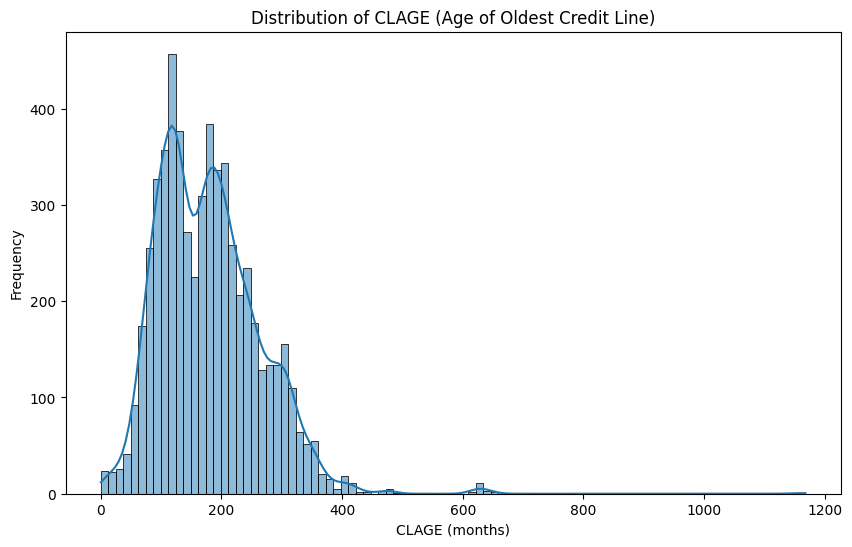

In [ ]:
# Plotting the histogram of CLAGE
plt.figure(figsize=(10, 6))

sns.histplot(full_df['CLAGE'], kde=True)
plt.title('Distribution of CLAGE (Age of Oldest Credit Line)')
plt.xlabel('CLAGE (months)')
plt.ylabel('Frequency')
plt.show()

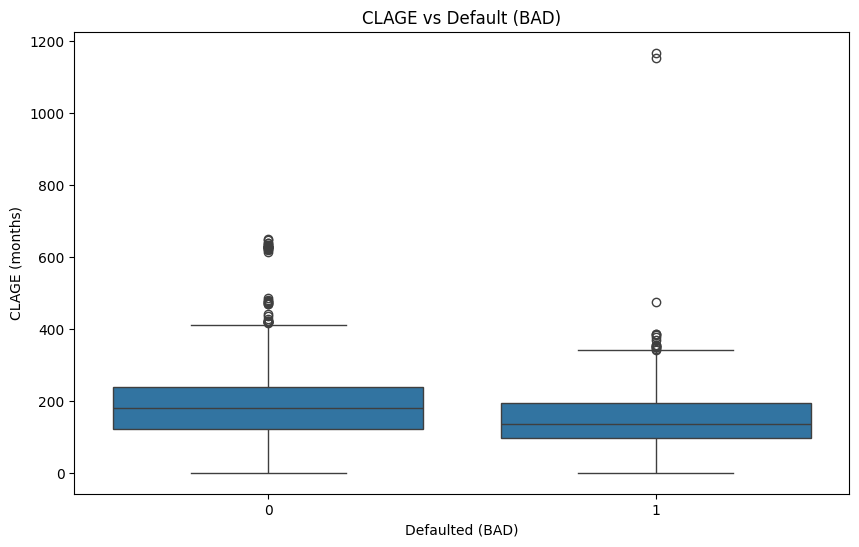

In [ ]:
# Examining the boxplot wrt to  BAD
plt.figure(figsize=(10, 6))
sns.boxplot(x='BAD', y='CLAGE', data=full_df)
plt.title('CLAGE vs Default (BAD)')
plt.xlabel('Defaulted (BAD)')
plt.ylabel('CLAGE (months)')
plt.show()

**Observations**

The histogram shows that the length of the longest credit line for most applicants is less than 400 months (approx 30 years).  
The highest `CLAGE` values are associated with loan defaults.

In [ ]:
# Examining CLAGE of 600 months or more.

clage_600_months = full_df[full_df['CLAGE'] >= 600]
clage_600_months.shape

(20, 13)

**Observations**

There are 20 applicants with a credit line age of 600 months or more.


In [ ]:
print(clage_600_months)

         LOAN  MORTDUE     VALUE   YOJ  DEROG  DELINQ        CLAGE  NINQ  \
3011  16800.0  87300.0  155500.0   3.0    0.0     0.0  1154.633333   0.0   
3589  19300.0  96454.0  157809.0   3.0    0.0     0.0  1168.233561   0.0   
3691  20000.0  56135.0   93234.0  18.0    0.0     0.0   630.033333   1.0   
3757  20200.0  61303.0   97780.0  17.0    0.0     1.0   632.103186   1.0   
3769  20200.0  59347.0   97816.0  18.0    0.0     0.0   618.735890   1.0   
3829  20500.0  64113.0   98322.0  16.0    0.0     0.0   634.461893   1.0   
3937  21100.0  63955.0   95621.0  19.0    0.0     0.0   626.297094   0.0   
3956  21200.0  63093.0  101789.0  18.0    0.0     0.0   623.456209   1.0   
3993  21400.0  64378.0   99343.0  18.0    0.0     0.0   627.702390   1.0   
4036  21600.0  59219.0   98111.0  18.0    0.0     0.0   626.771393   1.0   
4046  21700.0  62506.0   96588.0  18.0    0.0     1.0   615.133373   0.0   
4130  22000.0  61042.0   96622.0  17.0    0.0     0.0   638.275361   1.0   
4153  22200.

**Observations**

1. Most loan applicants are in the `ProfExec` job category. Only 2 are in the `Other` category. They have been in the current job for 16–19 years, except for 2 applicants who defaulted after only 3 years in the job.  
2. Most applicants requested loans for `Home Improvement`, with only 2 requesting loans for `Debt Consolidation`.  
3. Only 2 applicants defaulted on loans. These were the same 2 whose job category is `Other` and who took loans for `Debt Consolidation`.  
4. All applicants have 0 derogatory credit lines. Only 2 had delinquent credit lines out of 24 total credit lines. This indicates pristine credit, which could explain why the mortgage durations are so long.


In [ ]:
# Let us examine a CLAGE of 55 years and more ie. 660 months

clage_660_months = full_df[full_df['CLAGE'] >= 660]
clage_660_months.shape

(2, 13)

In [ ]:
print(clage_660_months)

         LOAN  MORTDUE     VALUE  YOJ  DEROG  DELINQ        CLAGE  NINQ  CLNO  \
3011  16800.0  87300.0  155500.0  3.0    0.0     0.0  1154.633333   0.0   0.0   
3589  19300.0  96454.0  157809.0  3.0    0.0     0.0  1168.233561   0.0   0.0   

        DEBTINC   REASON    JOB  BAD  
3011  31.221124  DebtCon  Other    1  
3589  40.206138  DebtCon  Other    1  


**Observations**

1. There are 2 mortgages with a credit line age greater than 55 years (660 months), and both resulted in defaults.  

Based on this, we will cap `CLAGE` at 55 years (660 months).

#### `CLNO`

A total of 71 credit lines appears unusually high. To explore this further, we will:  

1. Examine the histogram of `CLNO`.  
2. Check whether a higher number of credit lines coincides with longer `YOJ` values, lower derogatory credit, and fewer delinquent lines.  
3. Review the number of applicants with similarly high `CLNO` values.  

While there is no strict rule for the ideal number of credit lines, financial experts generally agree that maintaining between 3–4 credit lines is optimal for a good credit score.  

According to NewsNation and NerdWallet:  

1. The average American has 4 credit cards.  
2. Having too many credit lines can be difficult to manage and may lead to delinquencies.  
3. Having too few credit lines can hinder the development of a strong credit history, potentially affecting borrowing capacity.  

In our dataset, some applicants have as many as 71 credit lines, which is well above industry norms. We will examine these cases further.  

References:  
- https://www.newsnationnow.com/business/your-money/credit-cards-ideal-number/  
- https://www.nerdwallet.com/article/finance/how-many-credit-cards  


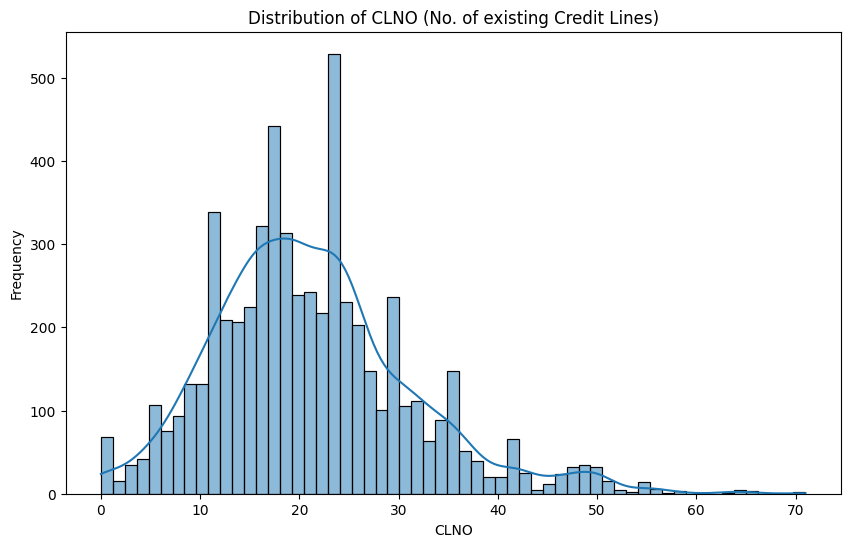

In [ ]:
# Plotting the histogram of CLNO
plt.figure(figsize=(10, 6))

sns.histplot(full_df['CLNO'], kde=True)
plt.title('Distribution of CLNO (No. of existing Credit Lines)')
plt.xlabel('CLNO')
plt.ylabel('Frequency')
plt.show()


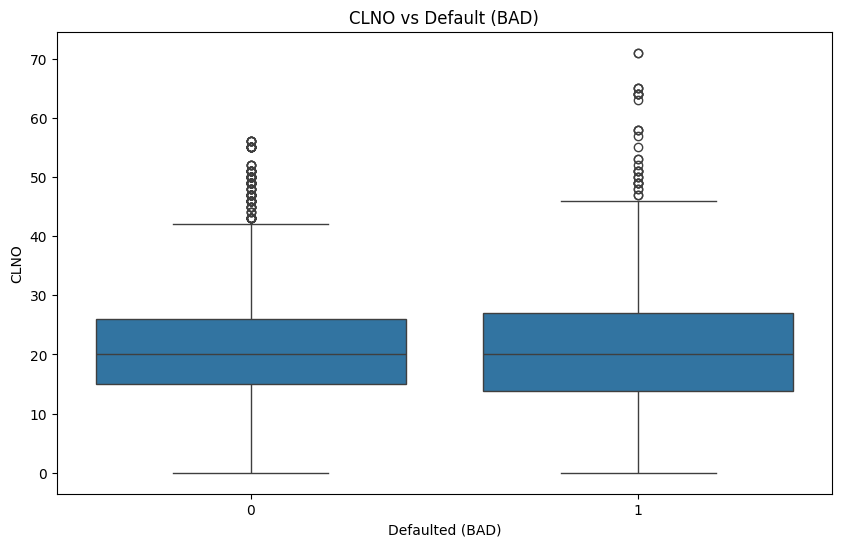

In [ ]:
# Examining Boplot wrt BAD
plt.figure(figsize=(10, 6))
sns.boxplot(x='BAD', y='CLNO', data=full_df)
plt.title('CLNO vs Default (BAD)')
plt.xlabel('Defaulted (BAD)')
plt.ylabel('CLNO')
plt.show()

**Observations**

1. The majority of applicants have between 5 and 40 credit lines.  
2. Loans where applicants had the highest number of credit lines were associated with defaults.


In [ ]:
# Examining a CLNO of 55 or more.

clno_55 = full_df[full_df['CLNO'] >= 55]
print ('The shape is: ',clno_55.shape)
print(clno_55)

The shape is:  (35, 13)
         LOAN   MORTDUE     VALUE   YOJ  DEROG  DELINQ       CLAGE  NINQ  \
1117  10000.0  147234.0  175300.0   6.0    0.0     0.0  192.766667   1.0   
1182  10100.0  154005.0  175684.0   4.0    0.0     0.0  189.366307   0.0   
1255  10500.0  154434.0  179486.0   5.0    0.0     0.0  182.353900   1.0   
1329  10700.0  147477.0  181050.0   6.0    0.0     0.0  190.021085   1.0   
1405  11000.0   66400.0   81500.0   9.5    0.0     0.0  215.066667   0.0   
1453  11100.0  148235.0  182053.0   4.0    0.0     0.0  198.809717   0.0   
1470  11200.0  153103.0  181849.0   6.0    0.0     0.0  186.249507   0.0   
1767  12300.0  152274.0  177940.0   4.0    0.0     0.0  196.876758   0.0   
1861  12700.0  149272.0  176467.0   7.0    0.0     0.0  191.904464   1.0   
1926  12900.0  151991.0  179521.0   6.0    0.0     0.0  186.805330   0.0   
1937  12900.0  149297.0  177044.0   4.0    0.0     0.0  205.873921   0.0   
1988  13000.0  111000.0  137813.0   6.0    2.0     2.0  138.3333

**Observations**

We do not see any obvious patterns, as there are both defaulters and non-defaulters across the range.  
Next, we will examine bin sizes and the number of defaulters in each bin.


In [ ]:
# Create bins for the 'CLNO' variable and calculate the default rate ('BAD' mean) within each bin to analyze default patterns by credit line count

full_df['CLNO_BIN'] = pd.cut(full_df['CLNO'], bins=[0,10,20,30,40,50,60,100])
full_df.groupby('CLNO_BIN')['BAD'].mean()

,BAD
CLNO_BIN,
"(0, 10]",0.276730
"(10, 20]",0.173572
"(20, 30]",0.183150
"(30, 40]",0.221362
"(40, 50]",0.200873
"(50, 60]",0.260870
"(60, 100]",1.000000


**Observations**

Applicants with `CLNO` values of 60 and above are all defaulters.  
We will examine this further to understand the underlying patterns.

In [ ]:
# Examining a CLNO of 60 or more.

clno_60 = full_df[full_df['CLNO'] >= 60]
print ('The shape is: ',clno_60.shape)
print(clno_60)

The shape is:  (11, 14)
         LOAN   MORTDUE     VALUE   YOJ  DEROG  DELINQ       CLAGE  NINQ  \
1405  11000.0   66400.0   81500.0   9.5    0.0     0.0  215.066667   0.0   
1988  13000.0  111000.0  137813.0   6.0    2.0     2.0  138.333333   3.0   
2338  14500.0  149000.0   55372.0  25.0    0.0     2.0  384.500000   0.0   
2712  15700.0  149305.0   70183.4  25.0    0.0     2.0  382.858836   0.0   
3008  16800.0  113021.0  146222.0   5.0    3.0     2.0  123.893420   2.0   
3383  18300.0   60100.0   82506.0  10.0    3.0     1.0  171.466667   2.0   
3515  18900.0   61429.0   84990.0   8.0    3.0     1.0  166.179399   2.0   
3785  20300.0   66667.0   92158.0   9.0    3.0     1.0  174.892106   2.0   
3900  20900.0   61402.0   88659.0   9.0    3.0     0.0  164.248932   1.0   
5456  36500.0   84978.0  125000.0  10.0    0.0     1.0  213.066667   0.0   
5491  38000.0   94083.0  132791.0  10.0    0.0     1.0  212.992728   0.0   

      CLNO    DEBTINC   REASON      JOB  BAD   CLNO_BIN  
1405 

**Observations**

There are 11 loan applicants with `CLNO` values greater than 60, and all of them are defaulters.  
We will cap `CLNO` at 60 to handle these extreme values.

#### `DEBTINC`

The debt-to-income ratio (DTI) in the dataset is as high as 203. This indicates that some loan applicants have monthly debt payments exceeding twice their income.  

To determine whether these values are explainable, we will:  
1. Examine the histogram of `DEBTINC`.  
2. Compare the results to industry standards, typically around 50%, to assess reasonableness.  

A DTI above 100 implies that debt obligations exceed income levels. Generally, a DTI of 36% or lower is considered favorable for mortgage approval. FHA loans, issued by the Federal Housing Administration (FHA), allow a maximum DTI of 43% for most borrowers. In some cases, a DTI of up to 50% may be permitted if certain conditions are met, such as a credit score above 580 or verified cash reserves.  

Reference:  
- https://www.guildmortgage.com/blog/what-is-a-good-debt-to-income-ratio-for-a-mortgage/#:~:text=6.,a%20financial%20risk%20to%20lenders.



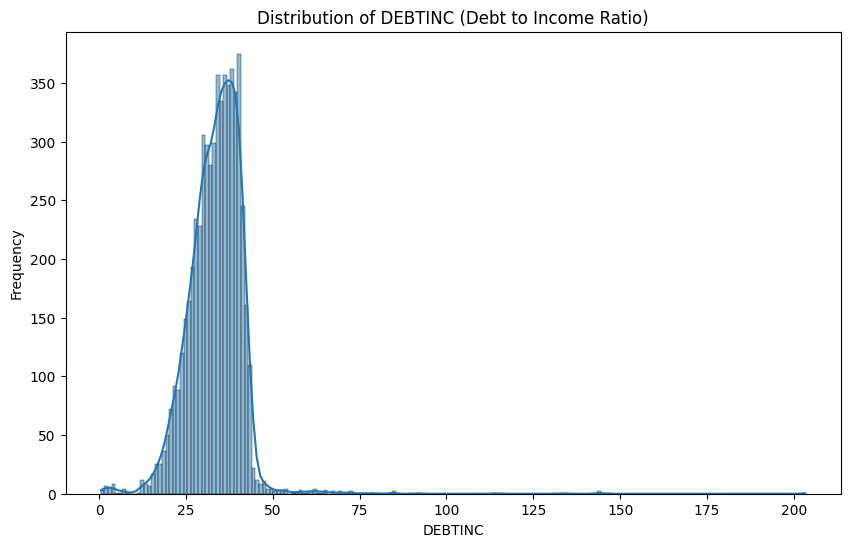

In [ ]:
# Plotting the histogram of DEBTINC
plt.figure(figsize=(10, 6))

sns.histplot(full_df['DEBTINC'], kde=True)
plt.title('Distribution of DEBTINC (Debt to Income Ratio)')
plt.xlabel('DEBTINC')
plt.ylabel('Frequency')
plt.show()


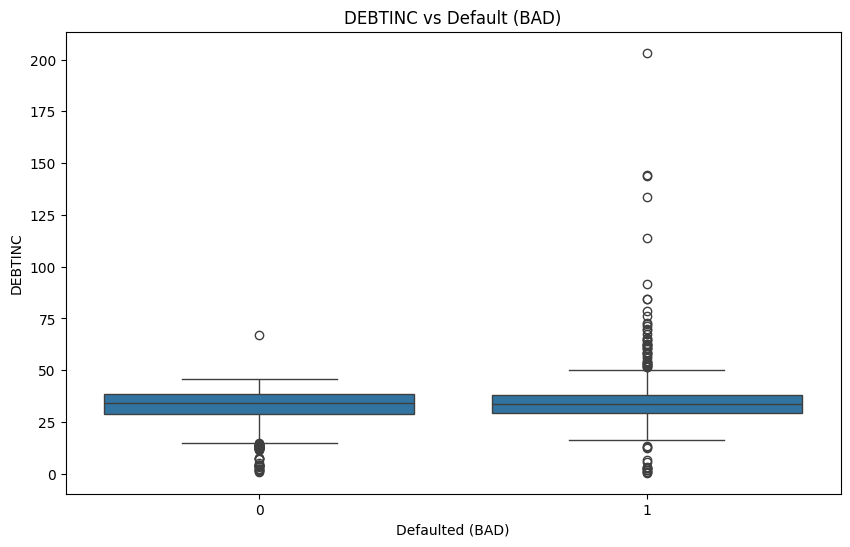

In [ ]:
# Examining Boplot wrt BAD
plt.figure(figsize=(10, 6))
sns.boxplot(x='BAD', y='DEBTINC', data=full_df)
plt.title('DEBTINC vs Default (BAD)')
plt.xlabel('Defaulted (BAD)')
plt.ylabel('DEBTINC')
plt.show()

**Observations**

Most loan applicants have a debt-to-income ratio below 50%, which aligns with industry standards for mortgage approvals.  
Applicants with `DEBTINC` values above 50% show a higher likelihood of default, supporting the use of 50% as a reasonable threshold.

In [ ]:
# Examining a DEBTINC of 50 or more.

debtinc_50 = full_df[full_df['DEBTINC'] >= 50]
print ('The shape is: ',debtinc_50.shape)
print(debtinc_50)

The shape is:  (48, 14)
         LOAN   MORTDUE     VALUE   YOJ  DEROG  DELINQ       CLAGE  NINQ  \
203    5200.0   40564.0   39527.0   0.0    0.0     0.0  157.771036   1.0   
387    6500.0  183860.0  208910.0   4.0    6.0     0.0   86.452227   6.0   
409    6700.0   39507.4   20631.0   4.0    0.0     0.0  174.721834   1.0   
1025   9700.0   32660.0   54536.0   0.0    0.0     0.0  156.482106   0.0   
1055   9900.0   37609.0  120186.0  14.6    0.0     0.0  176.367839   3.0   
1214  10300.0   70147.0  122124.0   1.0    0.0     0.0   58.895686   0.0   
1339  10800.0   35602.0   73077.0   9.2    0.0     1.0  179.896560   1.0   
1540  11600.0   57939.0   69774.0   5.0    0.0     0.0   91.991646   0.0   
1571  11700.0   63914.0   93707.0   7.0    3.0     0.0  162.579837   2.0   
1583  11800.0   74512.0   93328.0   4.0    5.0     0.0  117.918820   1.2   
1646  12000.0   76345.0   89036.0   8.0    0.0     0.0   91.970350   1.0   
1697  12000.0   48189.0   53969.0   5.0    0.0     0.0  276.3817

**Observations**

1. There are 48 loan applications with a debt-to-income ratio of 50% or more. Only one of them did not default, with a debt-to-income ratio of 66.8%.  
2. This aligns with industry findings, where mortgage approvals are typically granted for debt-to-income ratios of 50% or less.  
3. We will cap `DEBTINC` at 50%.  


### Treating Outliers
>  During our analysis, we identified `CLAGE`, `CLNO`, and `DEBTINC` as variables containing values that appeared inexplicable based on typical financial patterns. These variables were examined in greater detail to assess their relationship with loan default behavior.
>
>Our findings indicated that capping extreme values would help reduce the influence of outliers while preserving meaningful variation. The following thresholds were determined, as they marked clear distinctions between defaulters and non-defaulters:
>
>1.  `CLAGE` should be capped at 660
>2.  `CLNO` should be capped at 60
>3.  `DEBTINC` should be capped at 50
>
>By applying these caps, we aim to improve model stability and predictive accuracy while avoiding distortions caused by extreme or unrealistic values especially in distance based calculations used in our model building phase.

In [ ]:
# Using the clipping method to cap variables
full_df['CLAGE'] = full_df['CLAGE'].clip(upper=660)
full_df['CLNO'] = full_df['CLNO'].clip(upper=60)
full_df['DEBTINC'] = full_df['DEBTINC'].clip(upper=50)


In [ ]:
# Examining the max and min values of the clipped data

num_cols = full_df.select_dtypes(include=np.number)

for col in num_cols.columns:
    print(f"{col} has a min of {full_df[col].min():.2f} and a max of {full_df[col].max():.2f}")

LOAN has a min of 1100.00 and a max of 89900.00
MORTDUE has a min of 2063.00 and a max of 399550.00
VALUE has a min of 8000.00 and a max of 855909.00
YOJ has a min of 0.00 and a max of 41.00
DEROG has a min of 0.00 and a max of 10.00
DELINQ has a min of 0.00 and a max of 15.00
CLAGE has a min of 0.00 and a max of 660.00
NINQ has a min of 0.00 and a max of 17.00
CLNO has a min of 0.00 and a max of 60.00
DEBTINC has a min of 0.52 and a max of 50.00
BAD has a min of 0.00 and a max of 1.00


**Observations**

The unexplained outliers have been identified and treated, ensuring the dataset is ready for further analysis.


In [ ]:
full_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5834 entries, 0 to 5833
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   LOAN      5834 non-null   float64 
 1   MORTDUE   5834 non-null   float64 
 2   VALUE     5834 non-null   float64 
 3   YOJ       5834 non-null   float64 
 4   DEROG     5834 non-null   float64 
 5   DELINQ    5834 non-null   float64 
 6   CLAGE     5834 non-null   float64 
 7   NINQ      5834 non-null   float64 
 8   CLNO      5834 non-null   float64 
 9   DEBTINC   5834 non-null   float64 
 10  REASON    5834 non-null   object  
 11  JOB       5834 non-null   object  
 12  BAD       5834 non-null   int64   
 13  CLNO_BIN  5772 non-null   category
dtypes: category(1), float64(10), int64(1), object(2)
memory usage: 598.7+ KB


In [ ]:
#dropping CLNO_BIN
full_df.drop('CLNO_BIN', axis=1, inplace=True)

In [ ]:
full_df.head()

,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC,REASON,JOB,BAD
0,1100.0,25860.0,39025.0,10.5,0.0,0.0,94.366667,1.0,9.0,29.994530,HomeImp,Other,1
1,1300.0,70053.0,68400.0,7.0,0.0,2.0,121.833333,0.0,14.0,40.532794,HomeImp,Other,1
2,1500.0,13500.0,16700.0,4.0,0.0,0.0,149.466667,1.0,10.0,36.196050,HomeImp,Other,1
3,1700.0,97800.0,112000.0,3.0,0.0,0.0,93.333333,0.0,14.0,34.370509,HomeImp,Office,0
4,1700.0,30548.0,40320.0,9.0,0.0,0.0,101.466002,1.0,8.0,37.113614,HomeImp,Other,1


### Outlier Treatment Summary

#### Observations – Initial Outlier Detection
- All numeric variables contained outliers.  
- Summary of ranges:
  - `LOAN`: Min = 1,100.00, Max = 89,900.00
  - `MORTDUE`: Min = 2,063.00, Max = 399,550.00
  - `VALUE`: Min = 8,000.00, Max = 855,909.00
  - `YOJ`: Min = 0.00, Max = 41.00
  - `DEROG`: Min = 0.00, Max = 10.00
  - `DELINQ`: Min = 0.00, Max = 15.00
  - `CLAGE`: Min = 0.00, Max = 1,168.23
  - `NINQ`: Min = 0.00, Max = 17.00
  - `CLNO`: Min = 0.00, Max = 71.00
  - `DEBTINC`: Min = 0.52, Max = 203.31
  - `BAD`: Min = 0.00, Max = 1.00

#### Initial Assessment
- **Explainable outliers (no treatment required):**  
  `LOAN`, `MORTDUE`, `VALUE`, `YOJ`, `DEROG`, `DELINQ`, `NINQ`  
  These variables’ extreme values are plausible within financial contexts.

- **Variables flagged for further examination:**  
  `CLAGE`, `CLNO`, `DEBTINC`  
  These showed extreme values beyond typical financial patterns, warranting deeper analysis.

---

### Detailed Examination

#### `CLAGE` (Age of Oldest Credit Line)
- Max = 1,168 months (~97 years) – significantly higher than typical mortgage or credit durations.
- Industry reference: Most common mortgage terms are 30–50 years.
- Majority of applicants have `CLAGE` < 400 months (~30 years).
- 20 applicants had `CLAGE` ≥ 600 months (50 years); only 2 defaulted.
- Two applicants had `CLAGE` > 660 months (55 years) and both defaulted.
- **Decision:** Cap at **660 months** (55 years).

#### `CLNO` (Number of Credit Lines)
- Typical range in dataset: 5–40 credit lines.
- Industry reference: 3–4 credit lines considered healthy for credit score.
- Applicants with `CLNO` ≥ 60 were all defaulters.
- 11 applicants had `CLNO` > 60 and all defaulted.
- **Decision:** Cap at **60 credit lines**.

#### `DEBTINC` (Debt-to-Income Ratio)
- Max = 203% – indicates debt > income, which is highly unusual.
- Industry reference:  
  - ≤36% preferred for approval.  
  - FHA loans: max ~43% (up to 50% in special cases).
- Most applicants had `DEBTINC` < 50%.  
- Of the 48 applicants with `DEBTINC` ≥ 50%, only 1 did not default.
- **Decision:** Cap at **50%**.

---

### Outlier Treatment Approach
- Capped extreme values in variables with implausible or unrealistic ranges:  
  1. `CLAGE` → **660 months**  
  2. `CLNO` → **60**  
  3. `DEBTINC` → **50%**
- This capping retains meaningful variation, reduces skew, and mitigates distortions in distance-based algorithms during modeling.

**Post-Treatment Observation:**  
All inexplicable outliers have been treated; only explainable extreme values remain in the dataset.


We will now add new variables.  
This step is performed on the unscaled data to ensure that the calculated ratios remain meaningful.

## Addition of New Variables

We will be feature engineering variables to help develop a more accurate model.  

There will be two categories of engineered variables:  

---

### 1. Binary Risk Flags  
These will be created based on critical findings from the EDA.  

- `NINQ > 5` → Most applicants defaulted  
  - Definition: A binary indicator (1 = True, 0 = False) showing whether the applicant has had more than 5 recent credit inquiries.  
  - Importance:  
    - High numbers of recent credit inquiries often indicate aggressive credit-seeking behavior.  
    - Lenders may view this as a sign of potential overextension or financial distress, both linked to higher default probability.  

- `DEROG > 4` → Most applicants with `DEROG ≥ 4` defaulted  
  - Definition: A binary indicator for applicants with more than 4 major derogatory credit reports.  
  - Importance:  
    - Multiple derogatory marks suggest a history of severe delinquencies or defaults.  
    - Strongly associated with credit risk, as it reflects persistent repayment issues.  

- `DELINQ > 4` → Most applicants defaulted  
  - Definition: A binary indicator for applicants with more than 4 delinquent credit lines.  
  - Importance:  
    - A high number of delinquencies shows repeated late or missed payments, signaling elevated likelihood of future defaults.  

---

### 2. Ratios, Proportions & Interactions  
These will be calculated from meaningful and commonly used financial ratios.  

- **LTV (Loan-to-Value Ratio)**  
  $$
  LTV = \frac{\text{LOAN}}{\text{VALUE}}
  $$  
  - Definition: The proportion of the property’s value borrowed in the current loan.  
  - Importance:  
    - High LTV means less borrower equity and greater lender risk.  
    - Borrowers with high LTVs may have fewer options to refinance or recover from financial setbacks.  

- **MTV (Mortgage-to-Value Ratio)**  
  $$
  MTV = \frac{\text{MORTDUE}}{\text{VALUE}}
  $$  
  - Definition: The share of the property’s value already mortgaged before the new loan.  
  - Importance:  
    - A high MTV suggests the property is heavily leveraged, leaving minimal collateral value to secure additional debt.  

- **AVG_CL_AGE_PER_LINE (Average Credit Line Age per Line)**  
  $$
  AVG\_CL\_AGE\_PER\_LINE = \frac{\text{CLAGE}}{\text{CLNO}}
  $$  
  - Definition: The average age (in months) of each credit line.  
  - Importance:  
    - Higher values indicate long-standing credit relationships, often linked to credit stability.  
    - Lower values may mean recent credit expansion, possibly increasing repayment risk.  

- **INQUIRY_RATE (Inquiry Rate per Credit Line)**  
  $$
  INQUIRY\_RATE = \frac{\text{NINQ}}{\text{CLNO}}
  $$  
  - Definition: The proportion of existing credit lines that have recent inquiries.  
  - Importance:  
    - Captures how aggressively a borrower is seeking new credit relative to their existing accounts.  
    - High rates can flag potential financial strain or overextension.  

- **INT_YOJ_x_DEROG (Employment Stability × Derogatory Marks)**  
  $$
  INT\_YOJ\_x\_DEROG = \text{YOJ} \times \text{DEROG}
  $$  
  - Definition: Combines job tenure with derogatory report counts.  
  - Importance:  
    - Helps reveal nuanced risk patterns, such as borrowers with long employment history but poor credit behavior (or vice versa).  

- **INT_LTV_x_NINQ (Leverage × Recent Credit Seeking)**  
  $$
  INT\_LTV\_x\_NINQ = \text{LTV} \times \text{NINQ}
  $$  
  - Definition: Combines property leverage with recent inquiry activity.  
  - Importance:  
    - High leverage combined with recent borrowing efforts can indicate acute credit risk.  


In [ ]:
# This code performs feature engineering on the dataset by:
# 1. Creating binary risk flags based on EDA findings (e.g., high inquiries, derogatory marks, delinquencies).
# 2. Computing ratios and proportions such as Loan-to-Value (LTV) and Mortgage-to-Value (MTV).
# 3. Deriving credit history metrics like average credit line age per line and inquiry rate per line.
# 4. Creating interaction terms combining employment stability, derogatory marks, leverage, and recent credit activity.
# 5. Handling divisions by zero and replacing infinite values with NaN for clean data.
# 6. Summarizing and displaying descriptive statistics for all newly created features, rounded to 2 decimals.

def engineer_features(full_df: pd.DataFrame) -> pd.DataFrame:
    # Make a working copy
    df = full_df.copy()

    # --- 1) EDA-Based Binary Flags ---
    df["NINQ_over_5"]  = (df["NINQ"]    > 5).astype("category")
    df["DEROG_over_4"]  = (df["DEROG"]   > 4).astype("category")
    df["DELINQ_over_4"] = (df["DELINQ"]  > 4).astype("category")

    # --- 2) Ratios & Proportions ---
    df["LTV"] = np.divide(
        df["LOAN"], df["VALUE"],
        out=np.full_like(df["LOAN"], 0, dtype="float64"),
        where=df["VALUE"] > 0
    )

    df["MTV"] = np.divide(
        df["MORTDUE"], df["VALUE"],
        out=np.full_like(df["MORTDUE"], 0, dtype="float64"),
        where=df["VALUE"] > 0
    )

    # --- 3) Credit History Derived Features ---
    df["AVG_CL_AGE_PER_LINE"] = np.divide(
        df["CLAGE"], df["CLNO"],
        out=np.full_like(df["CLAGE"], 0, dtype="float64"),
        where=df["CLNO"] > 0
    )

    df["INQUIRY_RATE"] = np.divide(
        df["NINQ"], df["CLNO"],
        out=np.full_like(df["NINQ"], 0, dtype="float64"),
        where=df["CLNO"] > 0
    )

    # --- 4) Interaction Terms ---
    df["INT_YOJ_x_DEROG"] = df["YOJ"] * df["DEROG"]
    df["INT_LTV_x_NINQ"]  = df["LTV"] * df["NINQ"]

    # --- 5) Clean Up Infinities ---
    ratio_cols = [
        "LTV", "MTV", "AVG_CL_AGE_PER_LINE", "INQUIRY_RATE",
        "INT_YOJ_x_DEROG", "INT_LTV_x_NINQ"
    ]
    for c in ratio_cols:
        df[c] = pd.to_numeric(df[c], errors="coerce").replace([np.inf, -np.inf], np.nan)

    return df


# Apply feature engineering
full_df = engineer_features(full_df)

# Columns to check
new_cols = [
    "NINQ_over_5", "DEROG_over_4", "DELINQ_over_4",
    "LTV", "MTV", "AVG_CL_AGE_PER_LINE", "INQUIRY_RATE",
    "INT_YOJ_x_DEROG", "INT_LTV_x_NINQ"
]

# Describe, then round numeric stats to 2 decimals
desc_df = full_df[new_cols].describe(include="all").T
numeric_cols = desc_df.select_dtypes(include=[np.number]).columns
desc_df[numeric_cols] = desc_df[numeric_cols].round(2)

display(desc_df)


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
NINQ_over_5,5834,2,False,5657,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DEROG_over_4,5834,2,False,5785,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DELINQ_over_4,5834,2,False,5744,NaN,NaN,NaN,NaN,NaN,NaN,NaN
LTV,5834.0,NaN,NaN,NaN,0.218723,0.166232,0.015179,0.12263,0.172222,0.248037,2.325
MTV,5834.0,NaN,NaN,NaN,0.762182,0.482948,0.020538,0.630561,0.730304,0.809388,7.1625
AVG_CL_AGE_PER_LINE,5834.0,NaN,NaN,NaN,10.00185,8.24695,0.0,5.608231,7.931572,12.024253,202.045863
INQUIRY_RATE,5834.0,NaN,NaN,NaN,0.067348,0.162579,0.0,0.0,0.033333,0.083333,7.0
INT_YOJ_x_DEROG,5834.0,NaN,NaN,NaN,2.064278,7.651116,0.0,0.0,0.0,0.0,182.0
INT_LTV_x_NINQ,5834.0,NaN,NaN,NaN,0.2745,0.581175,0.0,0.0,0.103,0.321639,10.56


In [ ]:
full_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5834 entries, 0 to 5833
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   LOAN                 5834 non-null   float64 
 1   MORTDUE              5834 non-null   float64 
 2   VALUE                5834 non-null   float64 
 3   YOJ                  5834 non-null   float64 
 4   DEROG                5834 non-null   float64 
 5   DELINQ               5834 non-null   float64 
 6   CLAGE                5834 non-null   float64 
 7   NINQ                 5834 non-null   float64 
 8   CLNO                 5834 non-null   float64 
 9   DEBTINC              5834 non-null   float64 
 10  REASON               5834 non-null   object  
 11  JOB                  5834 non-null   object  
 12  BAD                  5834 non-null   int64   
 13  NINQ_over_5          5834 non-null   category
 14  DEROG_over_4         5834 non-null   category
 15  DELINQ_over_4        

In [ ]:
# Checking the distribution of values in each of the risk flag (categorical) variables
cols_cat = full_df.select_dtypes(['category'])

In [ ]:
# Print the unique values and their counts for each categorical (risk flag) variable
# to understand the distribution across categories

for i in cols_cat.columns:
    print('Unique values in',i, 'are :')
    print(cols_cat[i].value_counts())
    print('*'*50)

Unique values in NINQ_over_5 are :
NINQ_over_5
False    5657
True      177
Name: count, dtype: int64
**************************************************
Unique values in DEROG_over_4 are :
DEROG_over_4
False    5785
True       49
Name: count, dtype: int64
**************************************************
Unique values in DELINQ_over_4 are :
DELINQ_over_4
False    5744
True       90
Name: count, dtype: int64
**************************************************


In [ ]:
full_df.head()

,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC,REASON,JOB,BAD,NINQ_over_5,DEROG_over_4,DELINQ_over_4,LTV,MTV,AVG_CL_AGE_PER_LINE,INQUIRY_RATE,INT_YOJ_x_DEROG,INT_LTV_x_NINQ
0,1100.0,25860.0,39025.0,10.5,0.0,0.0,94.366667,1.0,9.0,29.994530,HomeImp,Other,1,False,False,False,0.028187,0.662652,10.485185,0.111111,0.0,0.028187
1,1300.0,70053.0,68400.0,7.0,0.0,2.0,121.833333,0.0,14.0,40.532794,HomeImp,Other,1,False,False,False,0.019006,1.024167,8.702381,0.000000,0.0,0.000000
2,1500.0,13500.0,16700.0,4.0,0.0,0.0,149.466667,1.0,10.0,36.196050,HomeImp,Other,1,False,False,False,0.089820,0.808383,14.946667,0.100000,0.0,0.089820
3,1700.0,97800.0,112000.0,3.0,0.0,0.0,93.333333,0.0,14.0,34.370509,HomeImp,Office,0,False,False,False,0.015179,0.873214,6.666667,0.000000,0.0,0.000000
4,1700.0,30548.0,40320.0,9.0,0.0,0.0,101.466002,1.0,8.0,37.113614,HomeImp,Other,1,False,False,False,0.042163,0.757639,12.683250,0.125000,0.0,0.042163


In [ ]:
# making a copy of data before proceeding
final_df = full_df.copy()

### New Variables – Feature Engineering Summary
We will be feature engineering some variables which could help in developing a more accurate model.

There will be two kinds of variable sources:  

---

#### 1. **Binary Risk Flags**  
These will be created from critical findings in the EDA.  Although there are clear boundaries between those who defaulted and did not default, we chose a lower boundary to avoid perfect separation, which will give us problems when doing the logistic regression model later on.  

-  **`NINQ_over_5`** — Although all applicants with `NINQ > 12` defaulted, we used a limit of 5 to prevent perfect seperation.  
  - **Definition**:  
    A binary indicator (1 = True, 0 = False) showing whether the applicant has had more than 5 recent credit inquiries.  
  - **Importance**:  
    High numbers of recent credit inquiries often indicate aggressive credit-seeking behavior. Lenders may view this as a sign of potential overextension or financial distress, both linked to higher default probability.

- **`DEROG_over_4`** — Although all applicants with `DEROG > 6` defaulted, we used 4 to prevent persect separation.  
  - **Definition**:  
    A binary indicator for applicants with more than 4 major derogatory credit reports.  
  - **Importance**:  
    Multiple derogatory marks suggest a history of severe delinquencies or defaults. Strongly associated with credit risk, as it reflects persistent repayment issues.

- **`DELINQ_over_4`** — Although all applicants with `DELINQ > 6` defaulted, we used 4 to prevent perfect separation.  
  - **Definition**:  
    A binary indicator for applicants with more than 4 delinquent credit lines.  
  - **Importance**:  
    A high number of delinquencies shows repeated late or missed payments, signaling elevated likelihood of future defaults.

---

#### 2. **Ratios, Proportions & Interactions**  
These will be calculated from meaningful and common combinations between variables.

- **`LTV` — Loan to Value Ratio**  
$$
\mathrm{LTV}=\frac{\mathrm{LOAN}}{\mathrm{VALUE}}
$$  
  - **Definition**: The proportion of the property’s value borrowed in the current loan.  
  - **Importance**: High LTV means less borrower equity and greater lender risk. Borrowers with high LTVs may have fewer options to refinance or recover from financial setbacks.

- **`MTV` — Mortgage to Value Ratio**  
$$
\mathrm{MTV}=\frac{\mathrm{MORTDUE}}{\mathrm{VALUE}}
$$  
  - **Definition**: The share of the property’s value already mortgaged before the new loan.  
  - **Importance**: A high MTV suggests the property is heavily leveraged, leaving minimal collateral value to secure additional debt.

- **`AVG_CL_AGE_PER_LINE` — Average Credit Line Age per Line**  
$$
\text{AVG\_CL\_AGE\_PER\_LINE}=\frac{\mathrm{CLAGE}}{\mathrm{CLNO}}
$$  
  - **Definition**: The average age (in months) of each credit line.  
  - **Importance**: Higher values indicate long-standing credit relationships, often linked to credit stability. Lower values may mean recent credit expansion, possibly increasing repayment risk.

- **`INQUIRY_RATE` — Inquiry Rate per Credit Line**  
$$
\text{INQUIRY\_RATE}=\frac{\mathrm{NINQ}}{\mathrm{CLNO}}
$$  
  - **Definition**: The proportion of existing credit lines that have recent inquiries.  
  - **Importance**: Captures how aggressively a borrower is seeking new credit relative to their existing accounts. High rates can flag potential financial strain or overextension.

- **`INT_YOJ_x_DEROG` — Employment Stability × Derogatory Marks**  
$$
\text{INT\_YOJ\_x\_DEROG}=\mathrm{YOJ}\times \mathrm{DEROG}
$$  
  - **Definition**: Combines job tenure with derogatory report counts.  
  - **Importance**: Helps reveal nuanced risk patterns, such as borrowers with long employment history but poor credit behavior (or vice versa).

- **`INT_LTV_x_NINQ` — Leverage × Recent Credit Seeking**  
$$
\text{INT\_LTV\_x\_NINQ}=\mathrm{LTV}\times \mathrm{NINQ}
$$  
  - **Definition**: Combines property leverage with recent inquiry activity.  
  - **Importance**: High leverage combined with recent borrowing efforts can indicate acute credit risk.


## Summary of Data Preprocessing Stage

### Missing Value Treatment

#### Observations – Initial Missing Data Review
- Some rows contained a large number of missing values.
- **Rows with > 50% missing data** were removed to maintain dataset quality.  
  - This resulted in the deletion of **126 rows** out of **5,960** (~**2.11%** of the dataset).
- No columns exceeded the **30% missing value** threshold for removal.  
  - The maximum % of missing data in any column was **21%**.

#### Approach for Remaining Missing Values
Since the dataset contains both categorical and numeric variables, missing values were handled separately for each type:

1. **Prevent Data Leakage**  
   - Split the dataset into `X` (features) and `Y` (target).

2. **Separate Variable Types**  
   - Split `X` into categorical and numeric subsets.

3. **Handle Missing Values**  
   - **Categorical variables** – Imputed using `SimpleImputer(strategy='most_frequent')`.  
   - **Numeric variables** – Imputed using `KNNImputer` with `n_neighbors=5` to:  
     - Avoid excessive smoothing.  
     - Reduce noise and outlier influence.  
     - Use Euclidean distance for neighbor selection.

4. **Recombine Processed Data**  
   - Merged the transformed numeric and categorical subsets back into a single DataFrame.

#### Post-Imputation Observations
- All missing values in **categorical variables** were addressed → dataset is complete for these fields.
- All missing values in **numeric variables** were imputed → no missing values remain.
- The processed `X` was recombined with `Y` after resetting indexes.

---

### Outlier Treatment

#### Observations – Initial Detection
- All numeric variables contained outliers.
- Variables flagged for further examination: `CLAGE`, `CLNO`, `DEBTINC` (values outside typical financial ranges).

#### Detailed Examination & Capping Decisions
- **`CLAGE`** – Max 1,168 months (approx. 97 years).  
  Cap at **660 months** (approx. 55 years).
- **`CLNO`** – Applicants with >60 credit lines were all defaulters.  
  Cap at **60**.
- **`DEBTINC`** – Max 203%; most approvals <50%.  
  Cap at **50%**.

**Post-Treatment Observation:**  
Extreme, non-explainable outliers were capped while retaining realistic high values.

---

### Feature Engineering

Two categories of engineered variables were created:

#### 1. Binary Risk Flags
- **`NINQ_over_5`** – More than 5 recent credit inquiries.  
- **`DEROG_over_4`** – More than 4 major derogatory reports.  
- **`DELINQ_over_4`** – More than 4 delinquent credit lines.

#### 2. Ratios, Proportions & Interactions
- **`LTV`** – Loan to Value Ratio  
  $$
  \mathrm{LTV}=\frac{\mathrm{LOAN}}{\mathrm{VALUE}}
  $$
- **`MTV`** – Mortgage to Value Ratio  
  $$
  \mathrm{MTV}=\frac{\mathrm{MORTDUE}}{\mathrm{VALUE}}
  $$
- **`AVG_CL_AGE_PER_LINE`** – Average age of each credit line  
  $$
  \frac{\mathrm{CLAGE}}{\mathrm{CLNO}}
  $$
- **`INQUIRY_RATE`** – Inquiry rate per credit line  
  $$
  \frac{\mathrm{NINQ}}{\mathrm{CLNO}}
  $$
- **`INT_YOJ_x_DEROG`** – Employment stability × derogatory marks  
  $$
  \mathrm{YOJ} \times \mathrm{DEROG}
  $$
- **`INT_LTV_x_NINQ`** – Leverage × recent credit seeking  
  $$
  \mathrm{LTV} \times \mathrm{NINQ}
  $$

---



# EDA After Preprocessing
We will now perform the EDA on the dataset which have been treated for missing values, outliers, feature engineering and scaled.

In [ ]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5834 entries, 0 to 5833
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   LOAN                 5834 non-null   float64 
 1   MORTDUE              5834 non-null   float64 
 2   VALUE                5834 non-null   float64 
 3   YOJ                  5834 non-null   float64 
 4   DEROG                5834 non-null   float64 
 5   DELINQ               5834 non-null   float64 
 6   CLAGE                5834 non-null   float64 
 7   NINQ                 5834 non-null   float64 
 8   CLNO                 5834 non-null   float64 
 9   DEBTINC              5834 non-null   float64 
 10  REASON               5834 non-null   object  
 11  JOB                  5834 non-null   object  
 12  BAD                  5834 non-null   int64   
 13  NINQ_over_5          5834 non-null   category
 14  DEROG_over_4         5834 non-null   category
 15  DELINQ_over_4        

## Univariate Analysis

### Univariate Analysis of Numeric Columns

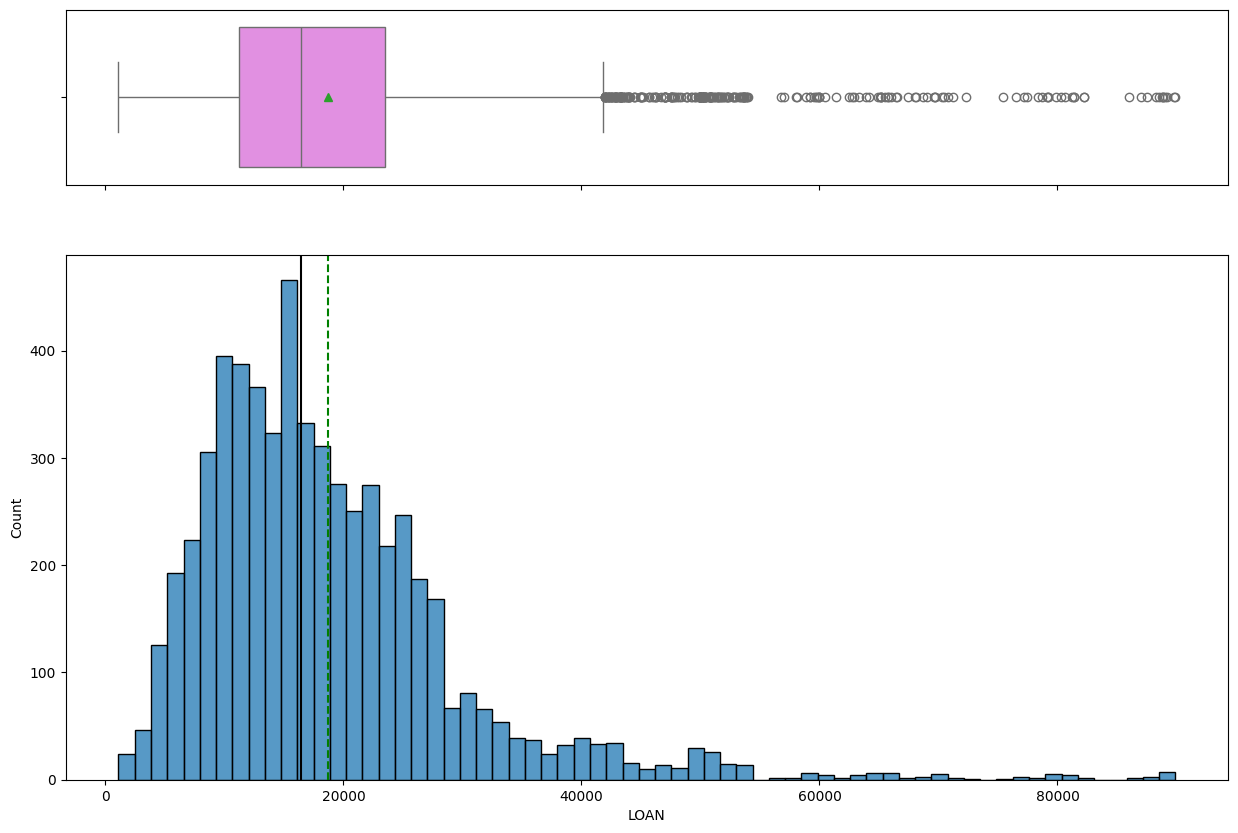

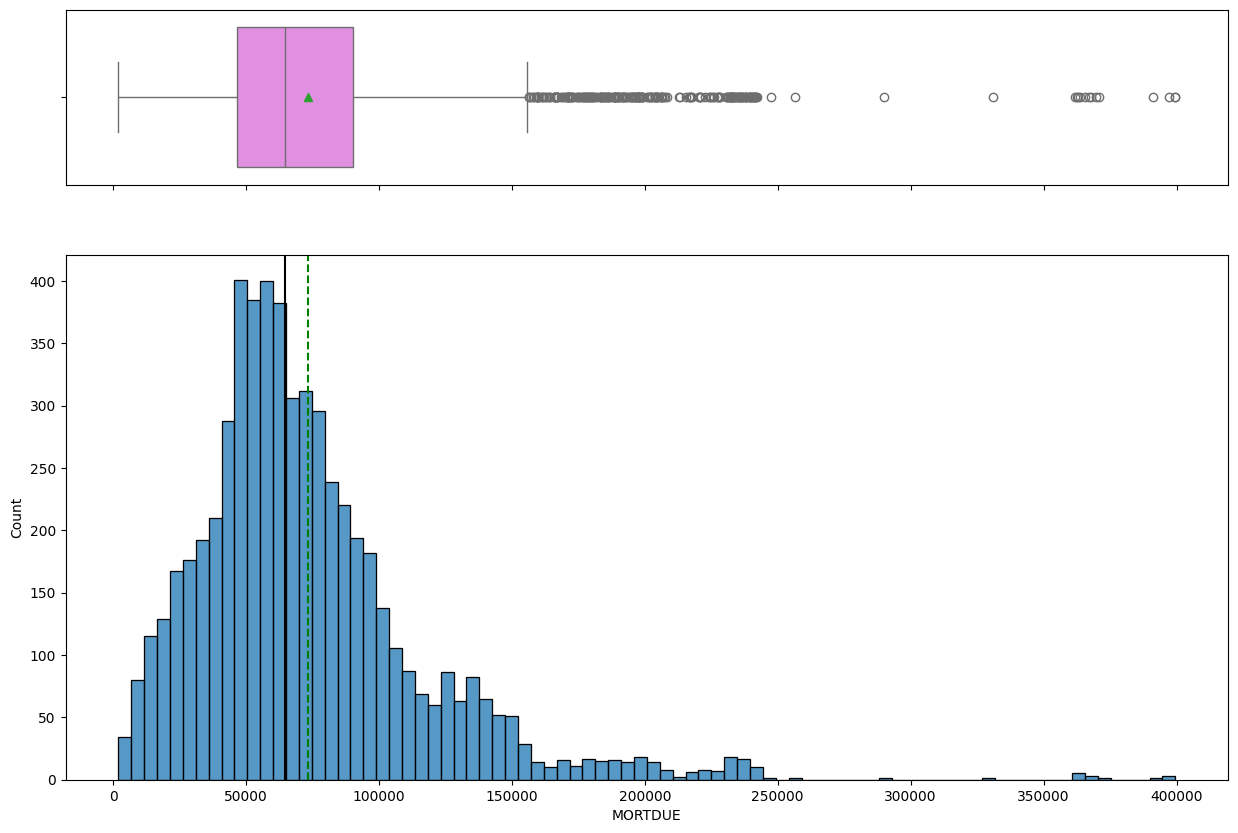

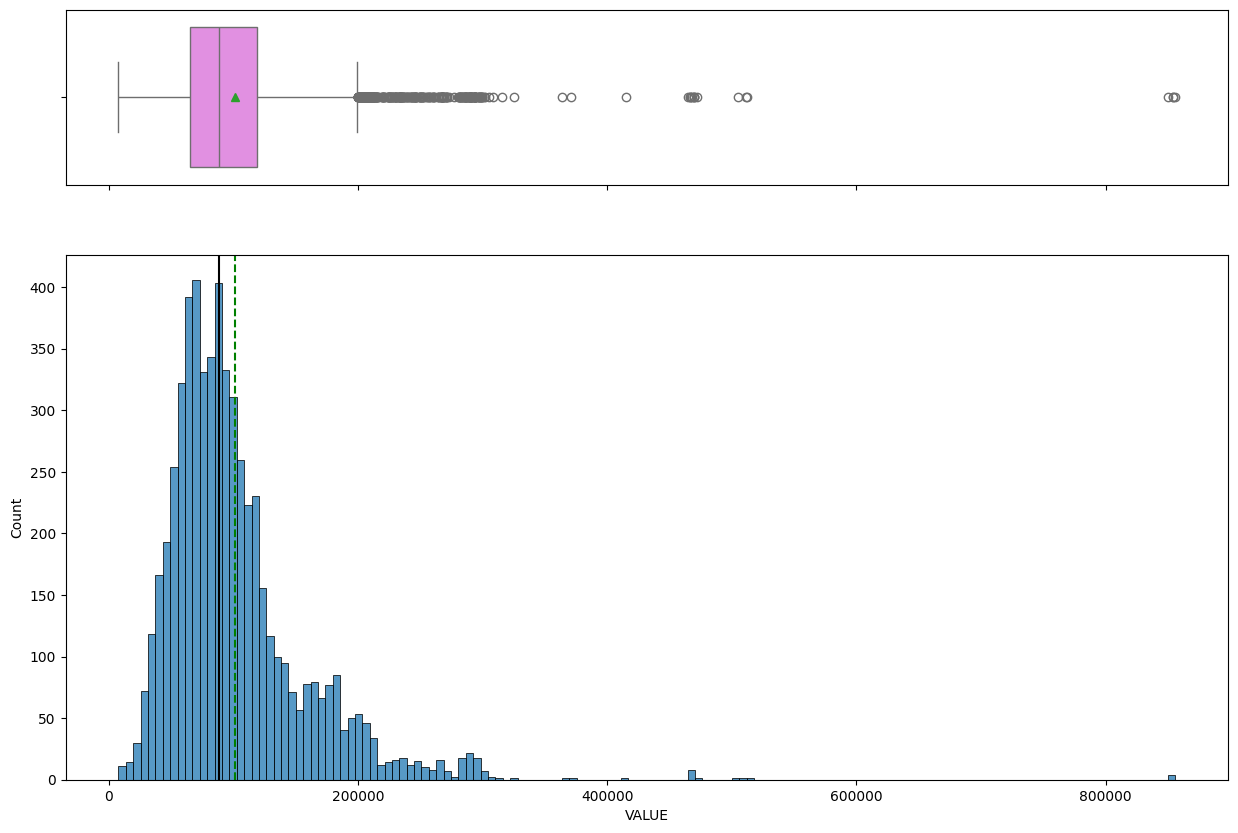

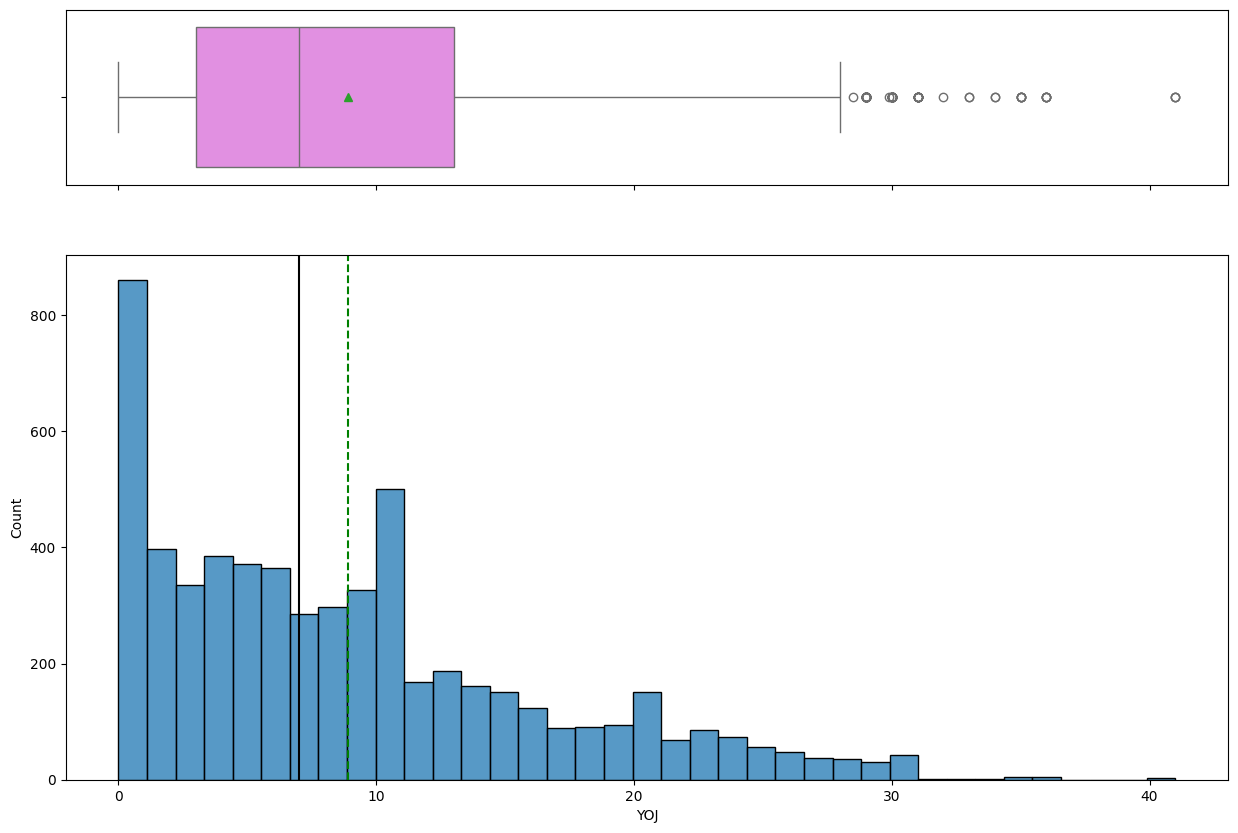

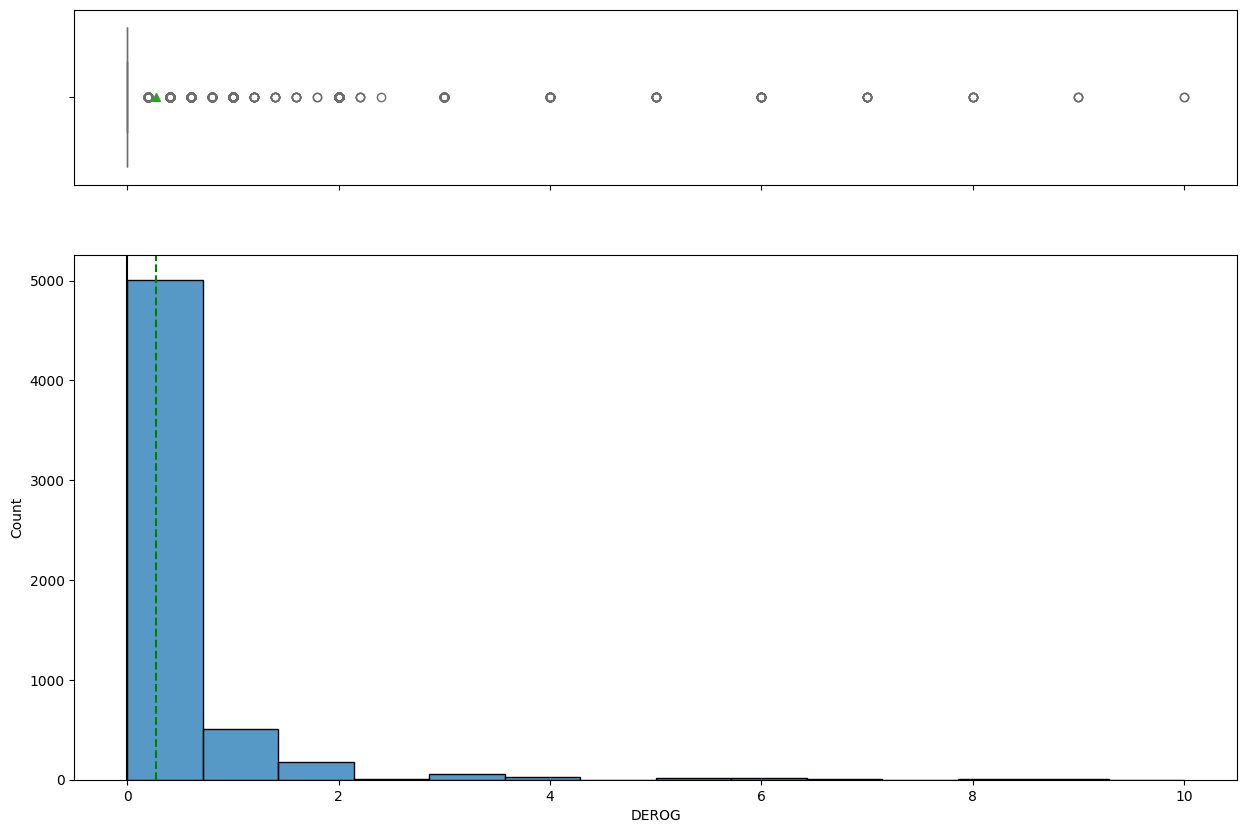

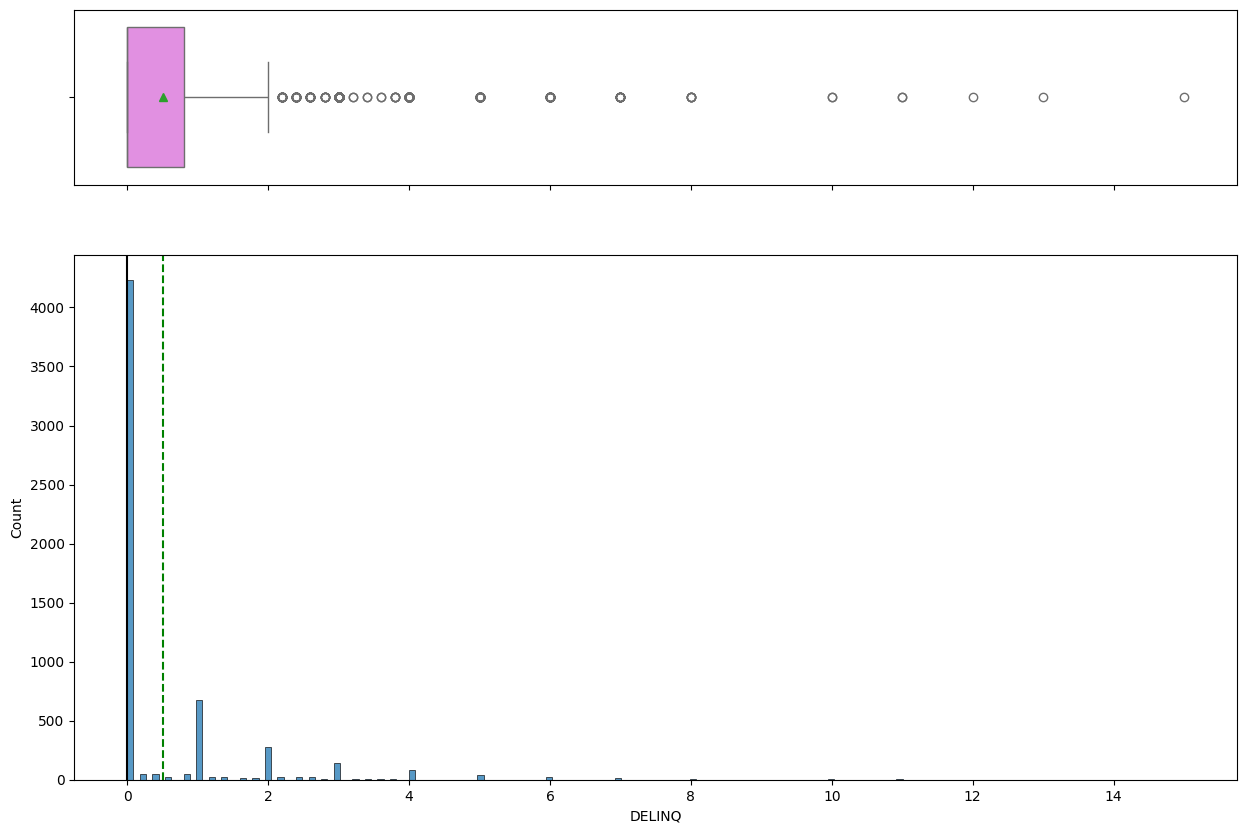

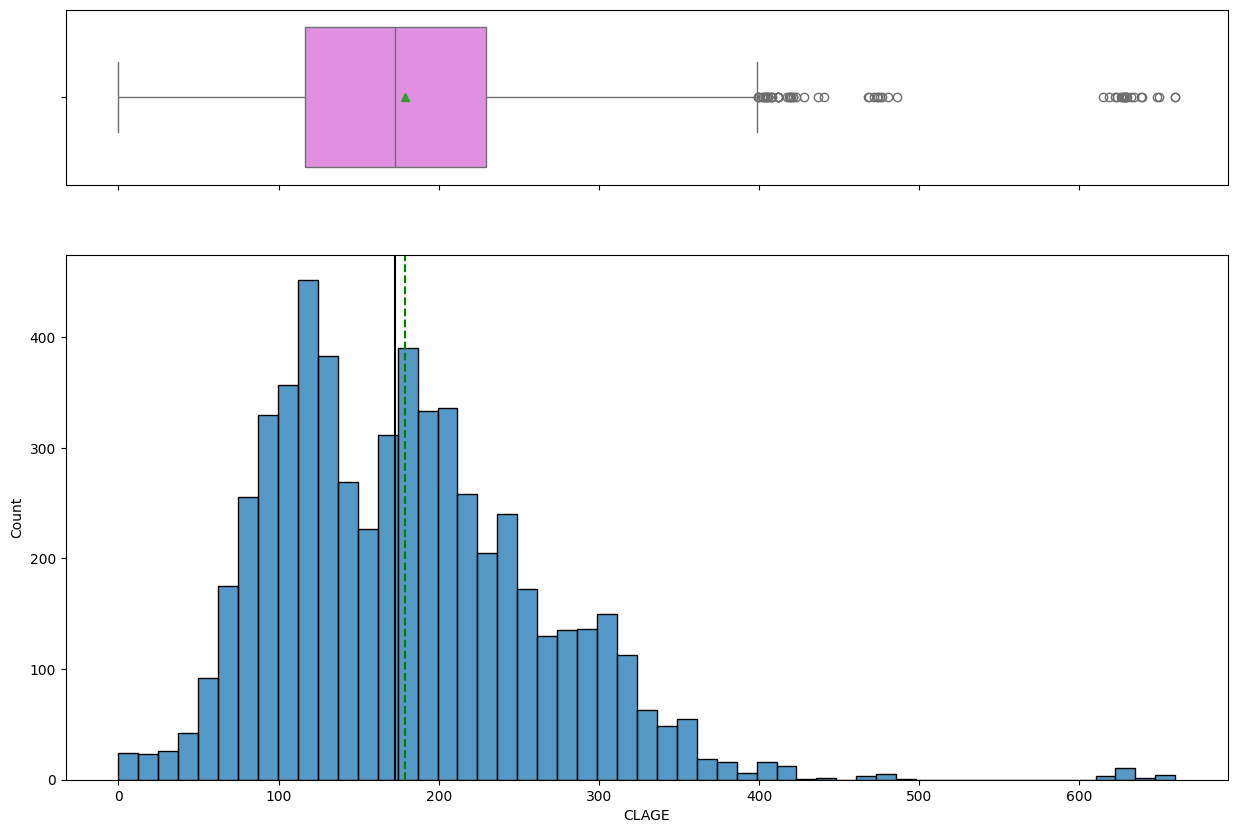

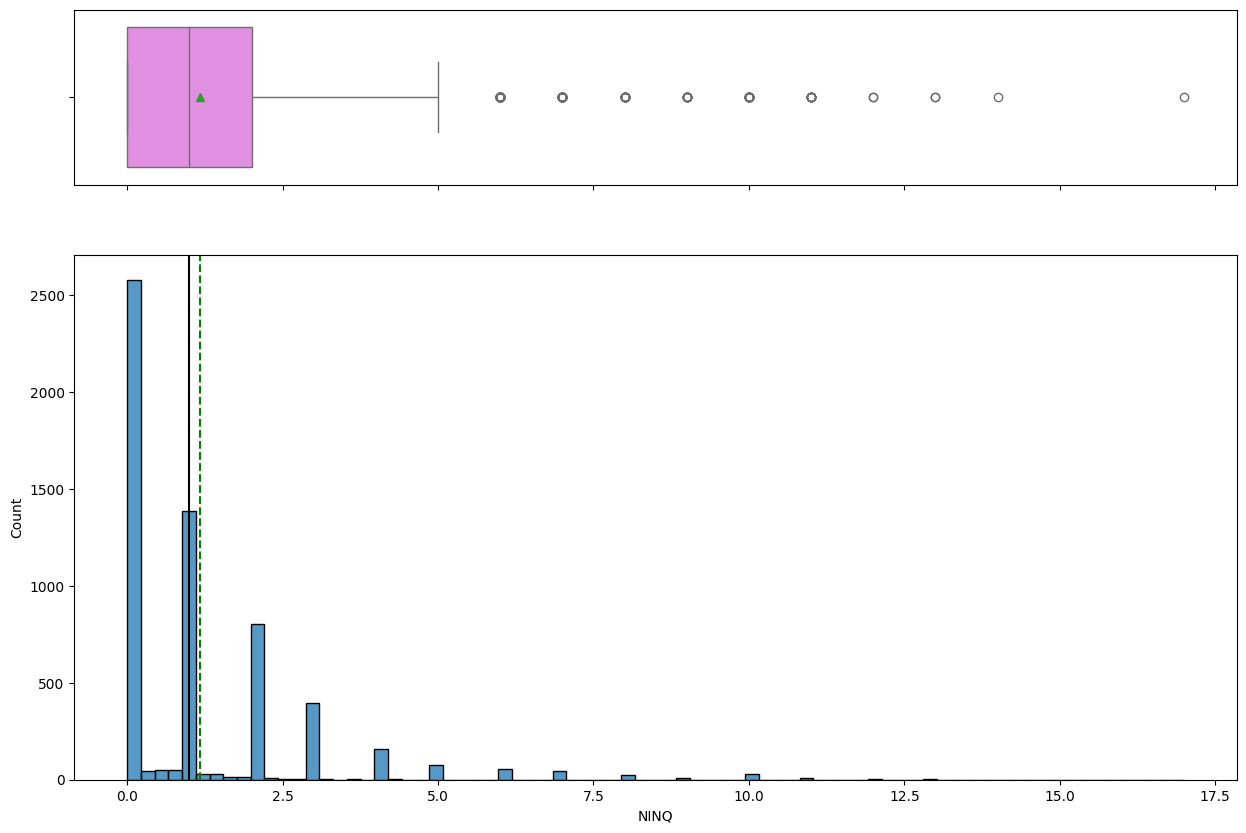

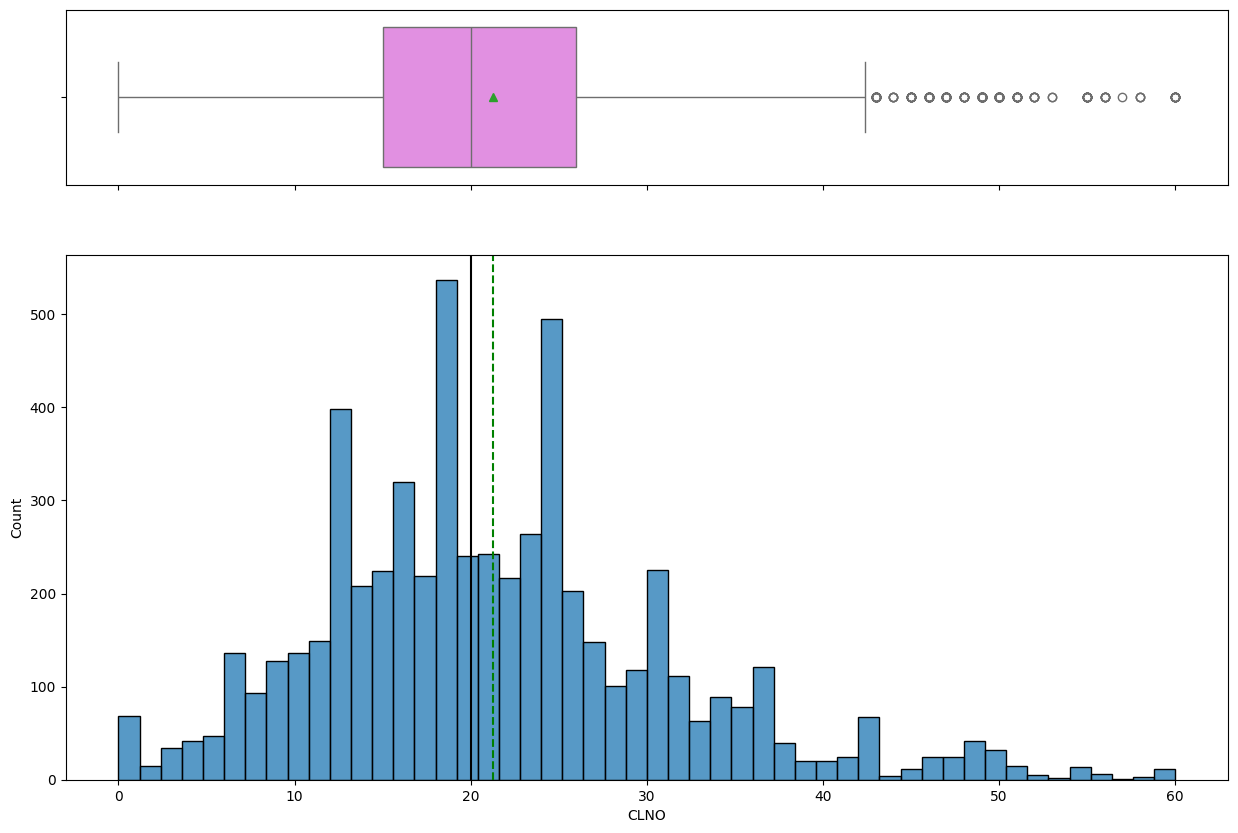

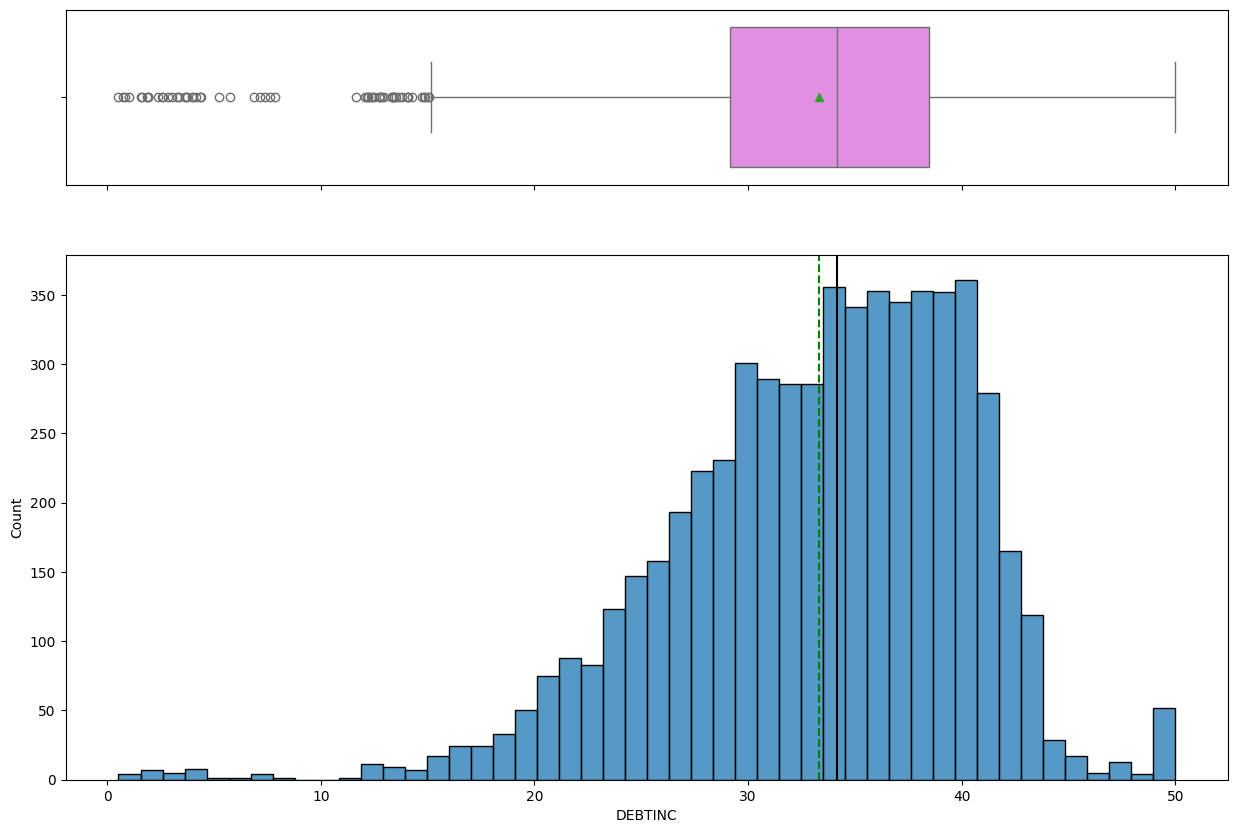

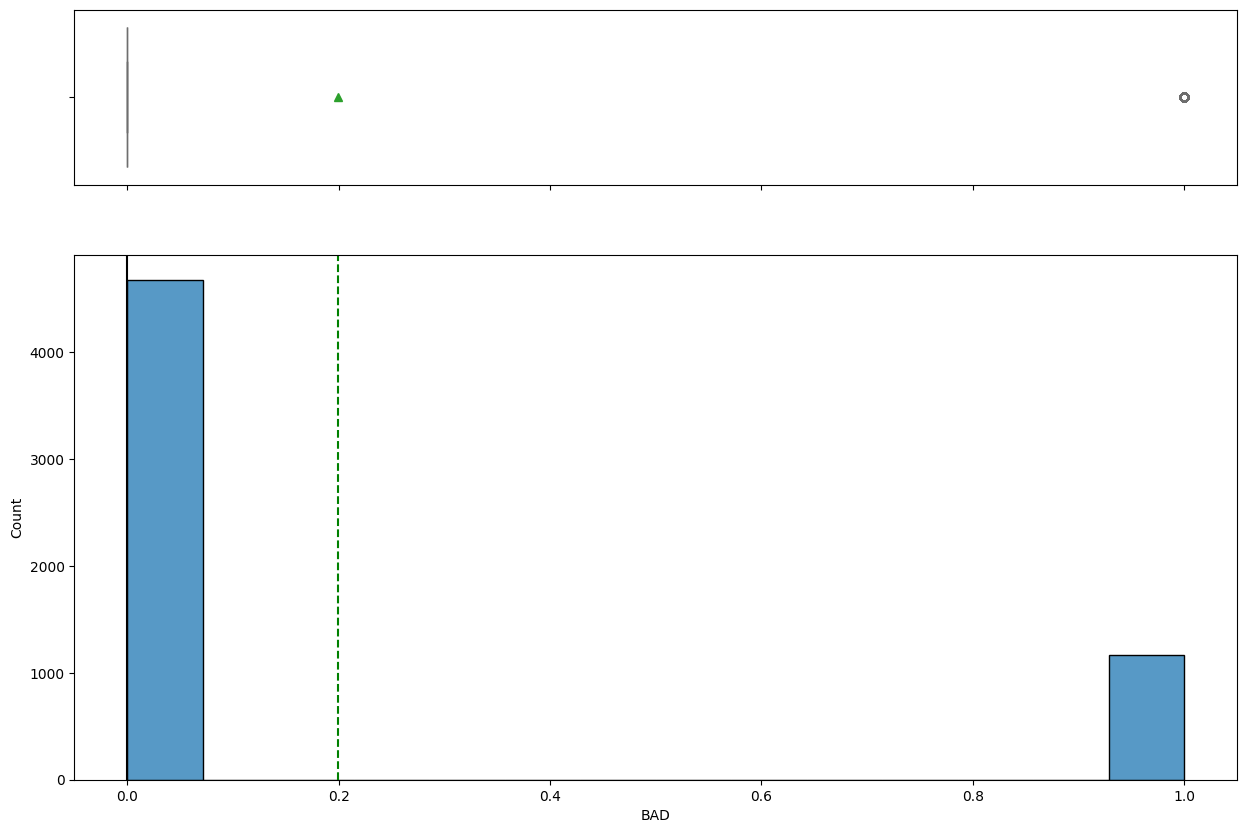

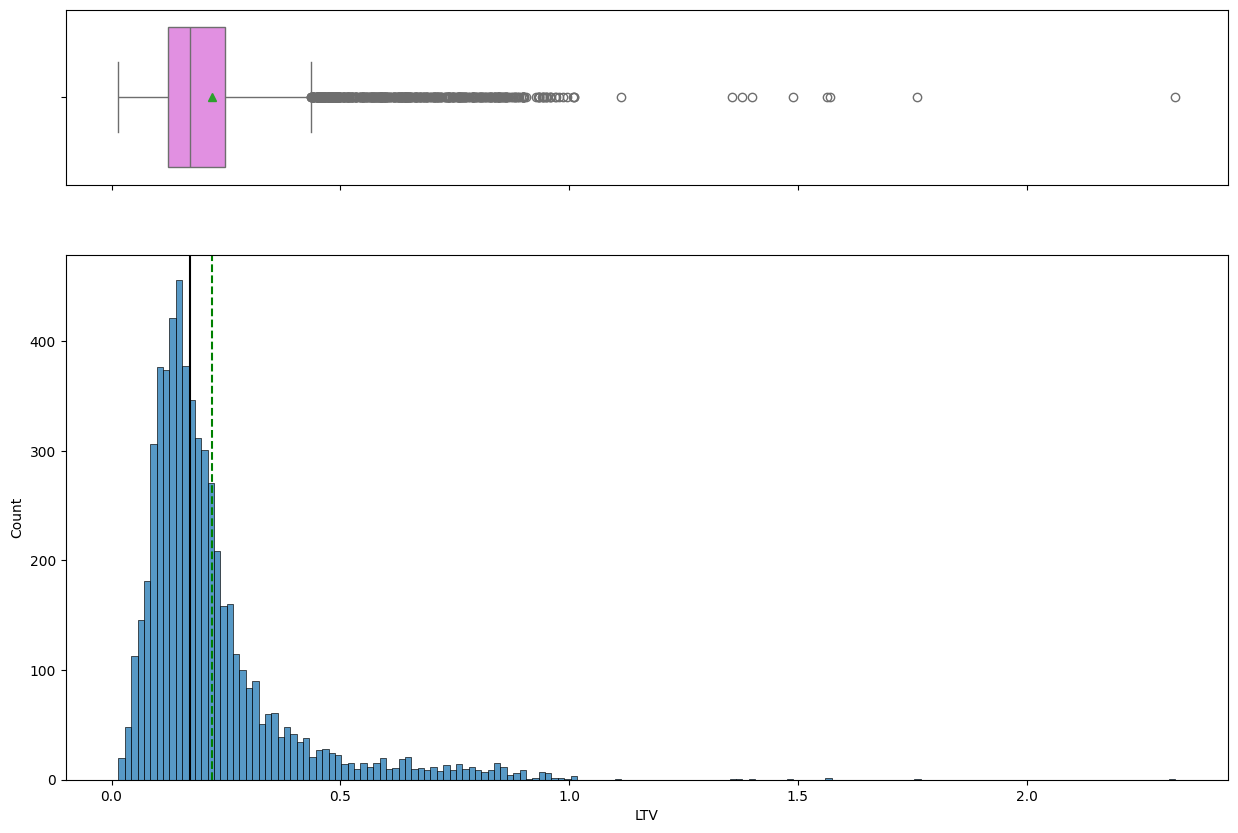

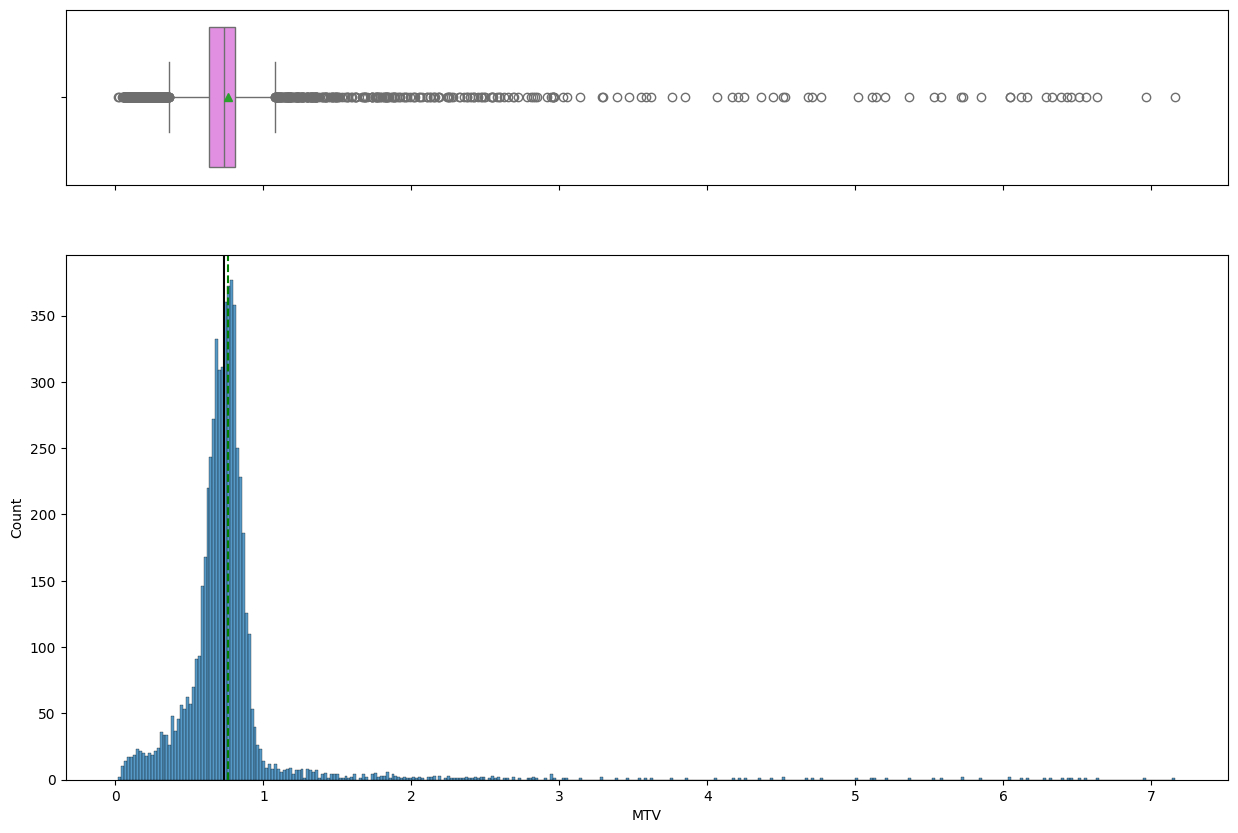

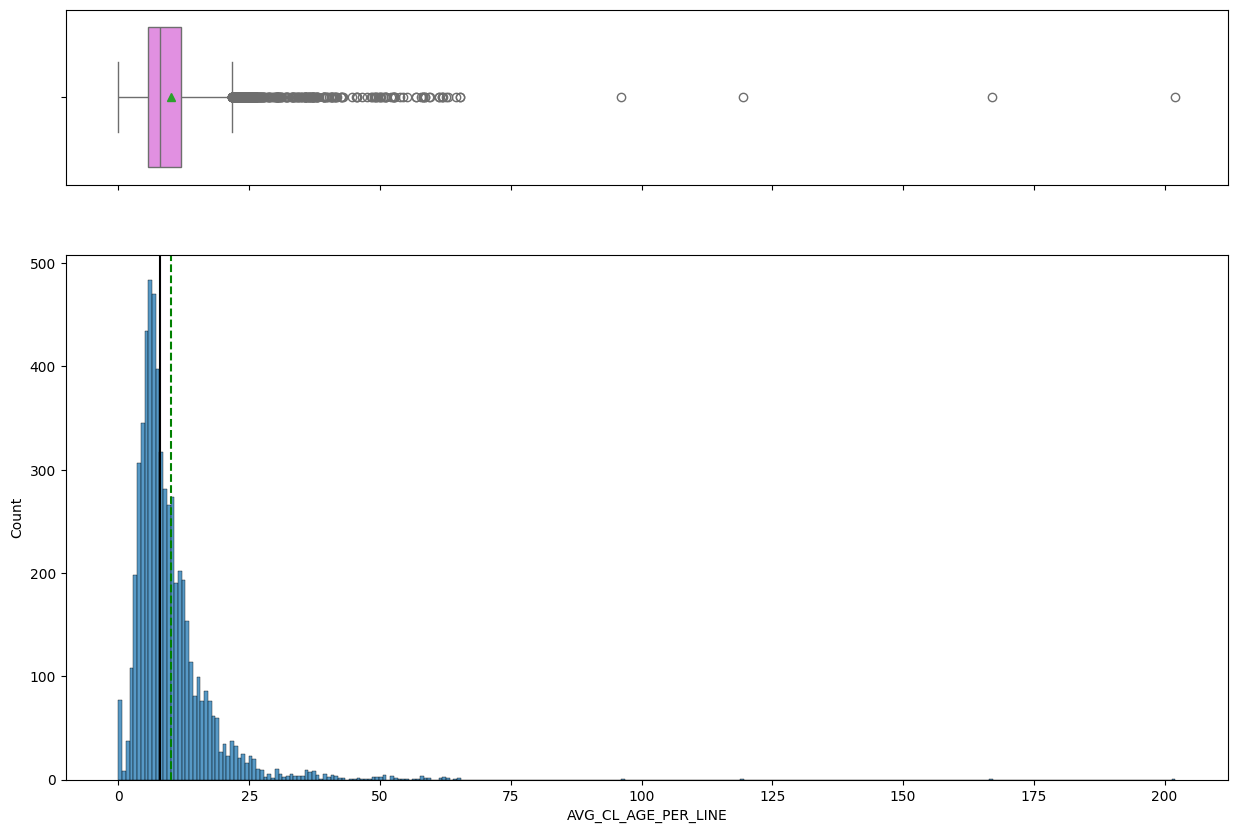

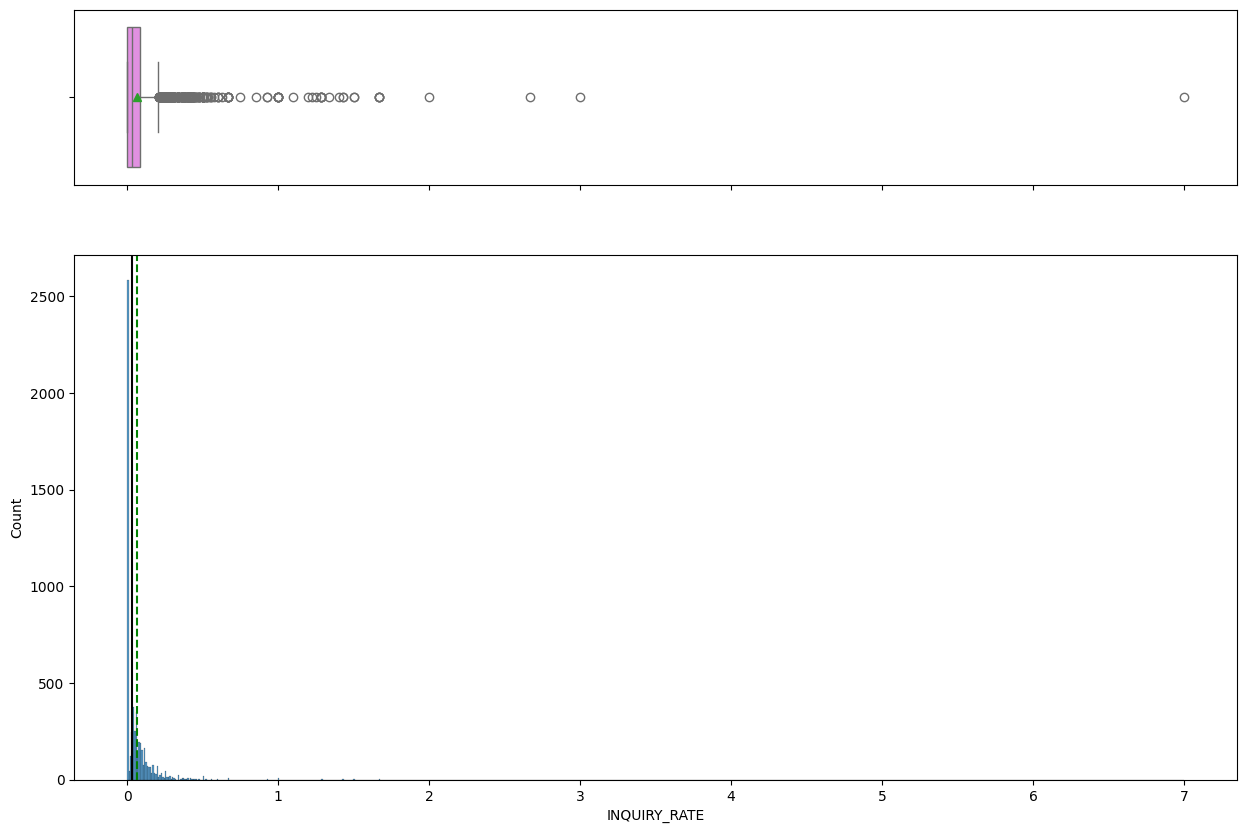

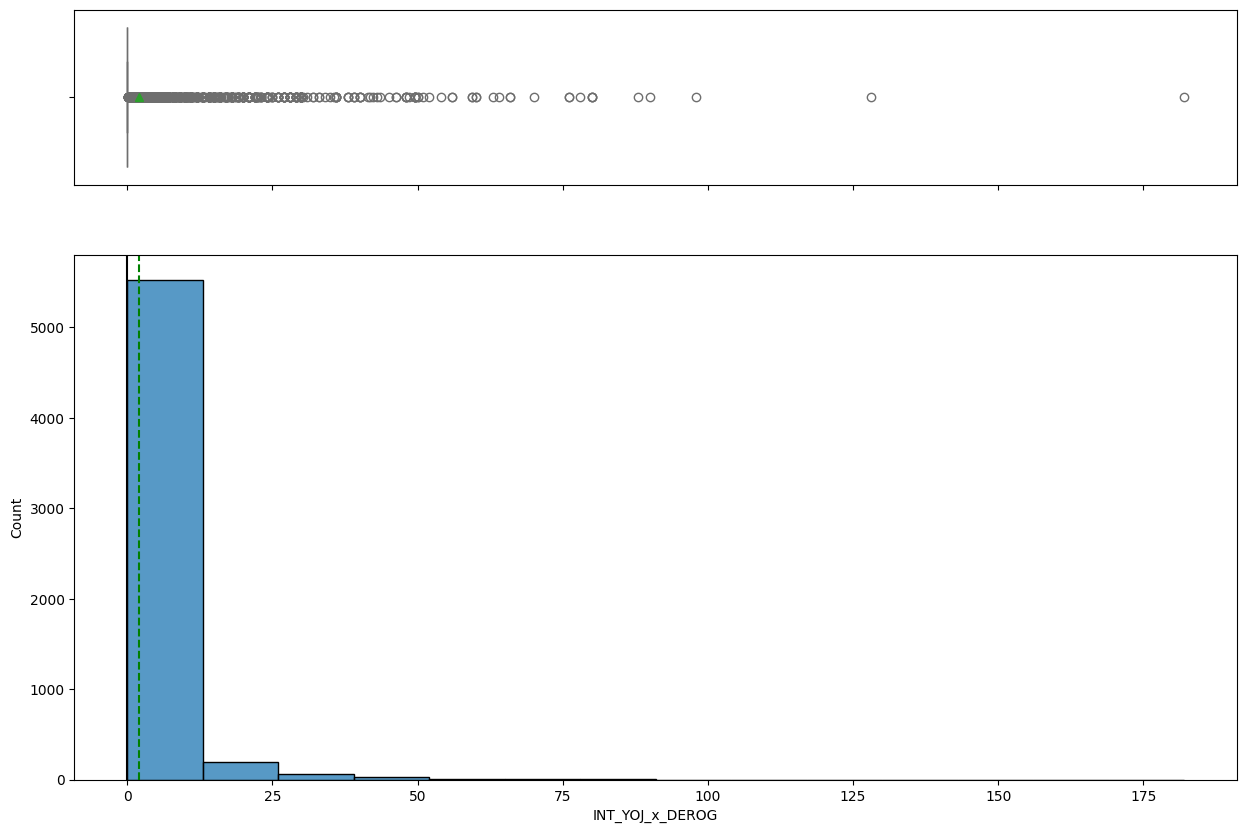

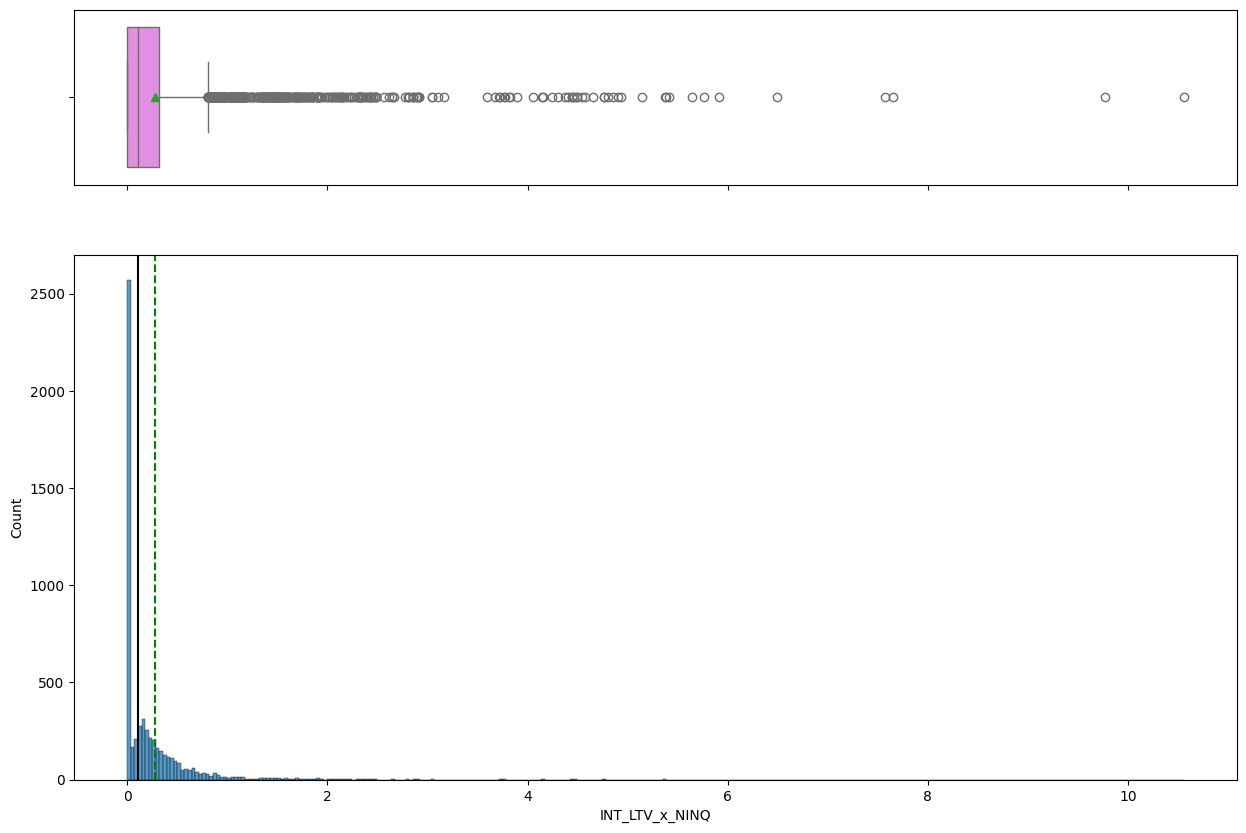

In [ ]:
# loop to plot histogram_plot for numeric variables
num_cols = final_df.select_dtypes(include = np.number).columns
for col in num_cols:
    histogram_boxplot(final_df, col)

## Univariate Analysis – Numeric Columns (Unscaled Data)

### 1. LOAN
- **Shape/Skewness**: Right-skewed; most loans between 5,000–25,000  
- **Mean/Median**: Mean ≈ 19,000, Median ≈ 17,000 → Mean > Median confirms skewness  
- **Outliers**: Above 60,000 considered extreme  

### 2. MORTDUE
- **Shape/Skewness**: Right-skewed; most mortgage dues under 100,000  
- **Mean/Median**: Mean ≈ 73,000, Median ≈ 65,000 → Mean > Median  
- **Outliers**: Above 200,000 are rare  

### 3. VALUE
- **Shape/Skewness**: Strong right skew; most properties 50,000–150,000  
- **Mean/Median**: Mean ≈ 102,000, Median ≈ 85,000 → Long tail pushes mean upward  
- **Outliers**: Above 300,000 extreme  

### 4. YOJ (Years at Job)
- **Shape/Skewness**: Right-skewed; most applicants <10 years  
- **Mean/Median**: Mean ≈ 8, Median ≈ 7 years → Right tail from long tenures  
- **Outliers**: Above 35 years unusual  

### 5. DEROG
- **Shape/Skewness**: Right-skewed; most have 0 derogatory reports  
- **Outliers**: Above 5 extreme  

### 6. DELINQ
- **Shape/Skewness**: Right-skewed; most have 0–1 delinquent lines  
- **Outliers**: Above 6 rare  

### 7. CLAGE (Credit Line Age)
- **Shape/Skewness**: Slight right skew; most credit lines <250 months  
- **Outliers**: Above 450 months extreme  

### 8. NINQ (Recent Inquiries)
- **Shape/Skewness**: Right-skewed; most 0–2 inquiries  
- **Outliers**: >8 inquiries rare  

### 9. CLNO (Credit Lines)
- **Shape/Skewness**: Slight right skew; most have 10–25 lines  
- **Outliers**: Above 40 extreme  

### 10. DEBTINC (Debt-to-Income)
- **Shape/Skewness**: Right-skewed; most ratios 20–40%  
- **Outliers**: Above 45% high risk  

### 11. LTV (Loan-to-Value)
- **Shape/Skewness**: Right-skewed; most <0.4  
- **Outliers**: Above 1.0 = loans exceed property values  

### 12. MTV (Mortgage-to-Value)
- **Shape/Skewness**: Right-skewed; most 0.6–1.0  
- **Outliers**: High values = mortgage close/exceeds property value  

### 13. AVG_CL_AGE_PER_LINE
- **Shape/Skewness**: Right-skewed; most <20 years  
- **Outliers**: Above 50 years rare  

### 14. INQUIRY_RATE
- **Shape/Skewness**: Right-skewed; most <0.2 inquiries/month  
- **Outliers**: Above 2.0 unusual  

### 15. INT_YOJ_x_DEROG
- **Shape/Skewness**: Right-skewed; most near 0  
- **Outliers**: Above 75 rare  

### 16. INT_LTV_x_NINQ
- **Shape/Skewness**: Right-skewed; most <1.0  
- **Outliers**: Above 3.0 uncommon  

### 17. BAD (Target)
- **Shape/Skewness**: Binary: 0 (Non-default) ≈ 84%, 1 (Default) ≈ 16%, shows class imbalance  


### Univariate Analysis of Non - Numeric Columns

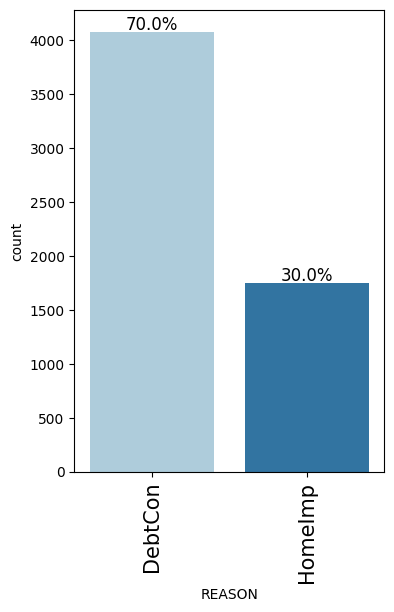

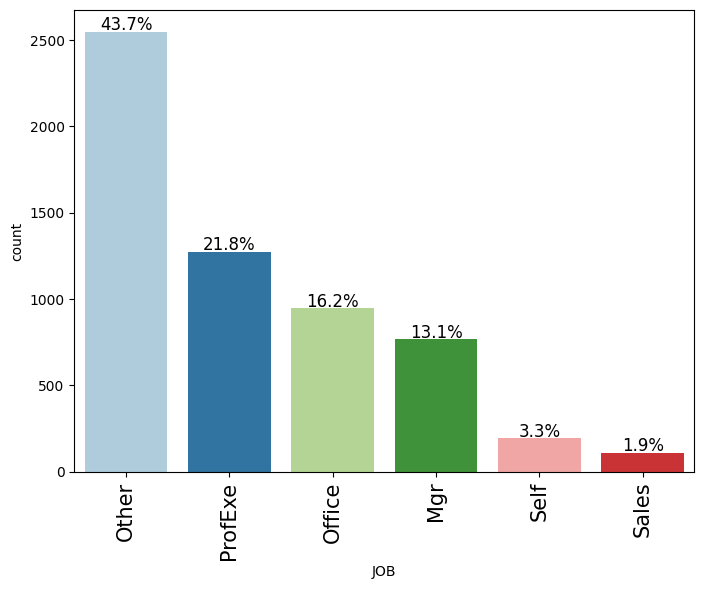

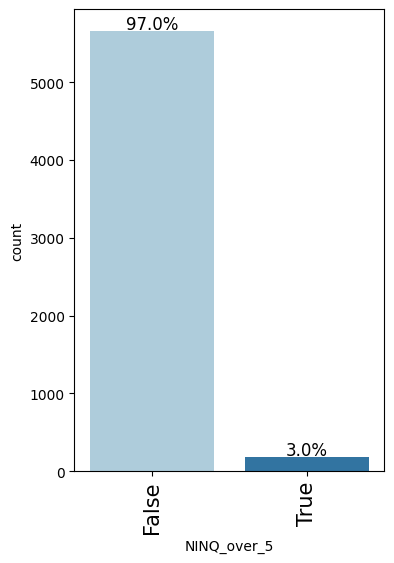

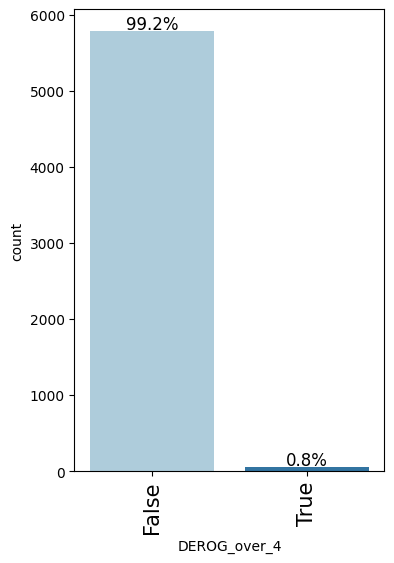

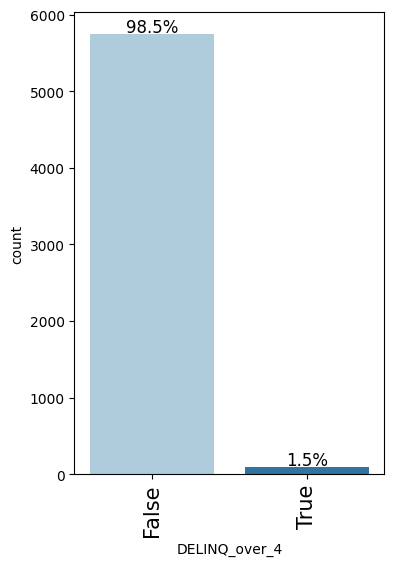

In [ ]:
# loop to plot labeled_barplot for non-numeric variables
non_num_cols = final_df.select_dtypes(exclude = np.number).columns
for col in non_num_cols:
    labeled_barplot(final_df, col, perc=True)

## Univariate Analysis – Non-Numeric Columns (Unscaled Data)

### 1. REASON
- **Shape/Skewness**: Two main categories; DebtCon dominates at 70%, HomeImp is 30%  
- **Outliers**: None – only two valid categories  

### 2. JOB
- **Shape/Skewness**:  
  - Other: 43.7%  
  - ProfExe: 21.8%  
  - Office: 16.2%  
  - Mgr: 13.1%  
  - Self: 3.3%  
  - Sales: 1.9%  
- **Outliers**: Categories with very low counts like Sales and Self represent small proportions  

### 3. NINQ_over_5
- **Shape/Skewness**: Highly imbalanced; False = 97.0%, True = 3.0%  
- **Outliers**: True values are rare but not data entry errors  

### 4. DEROG_over_4
- **Shape/Skewness**: False = 99.2%, True = 0.8%, showing extreme imbalance  
- **Outliers**: True cases are very few but valid  

### 5. DELINQ_over_4
- **Shape/Skewness**: False = 98.5%, True = 1.5%  
- **Outliers**: True cases are rare but valid observations  


## Bivariate Analysis

### Numeric Variables

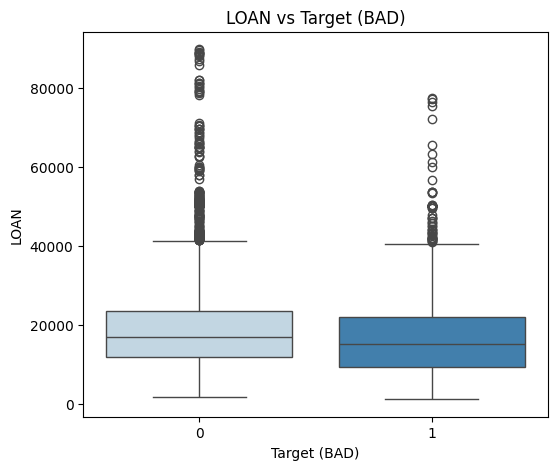

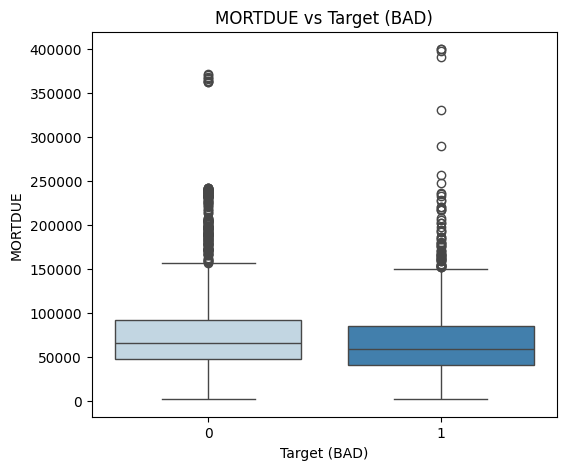

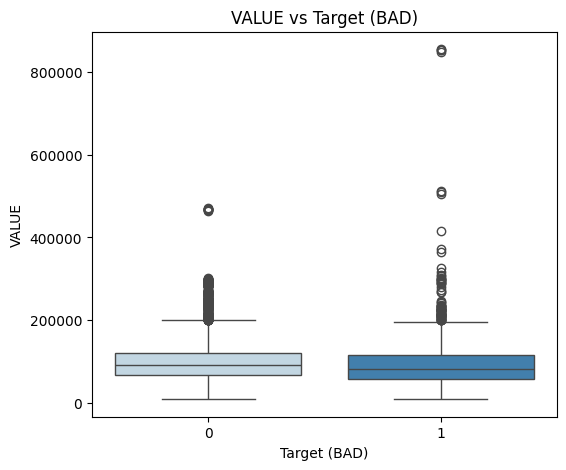

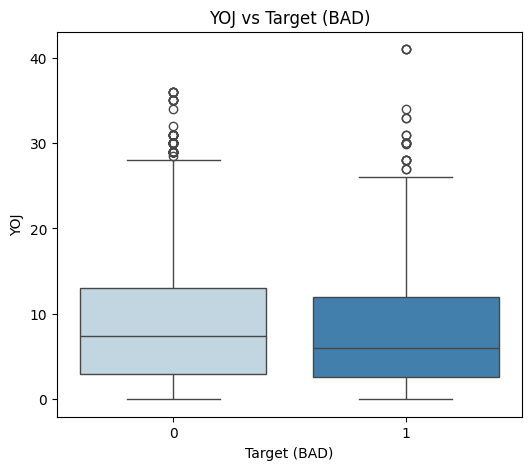

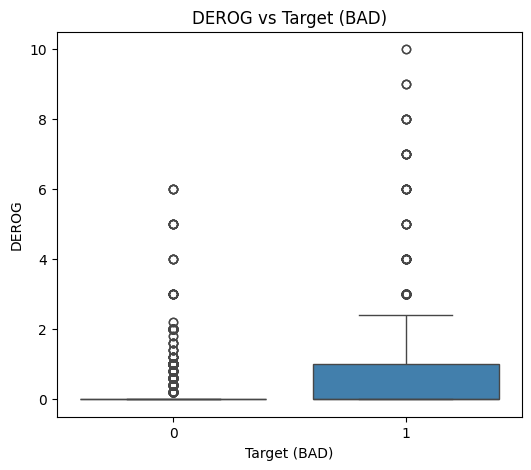

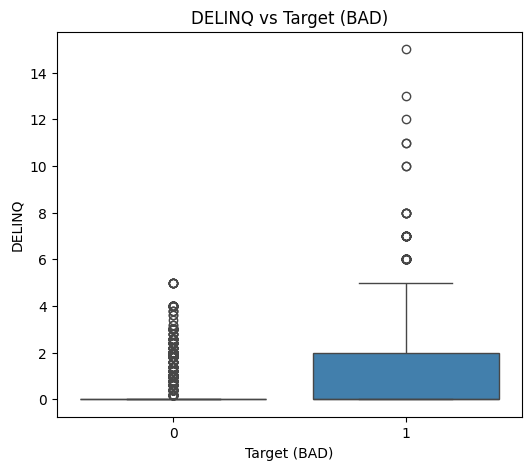

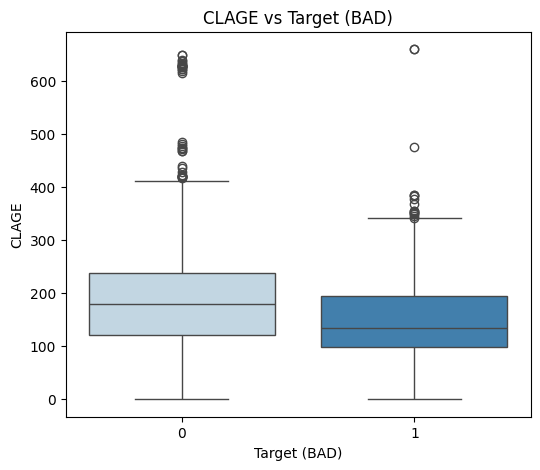

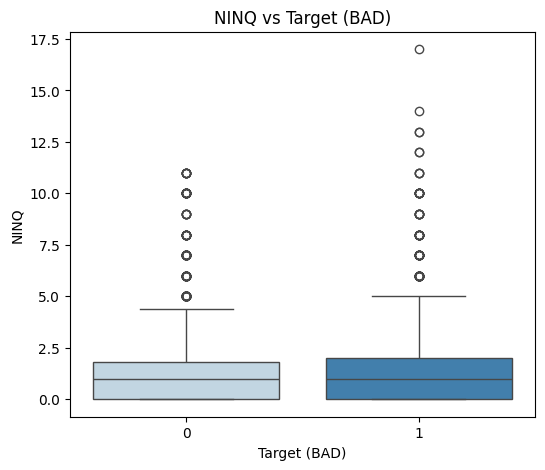

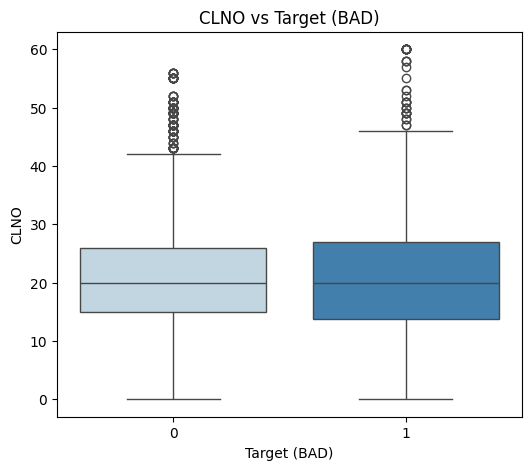

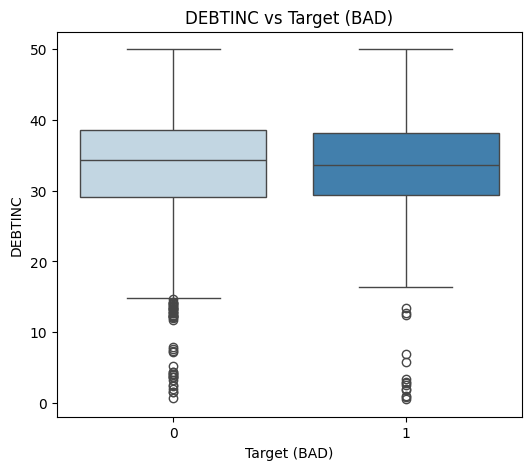

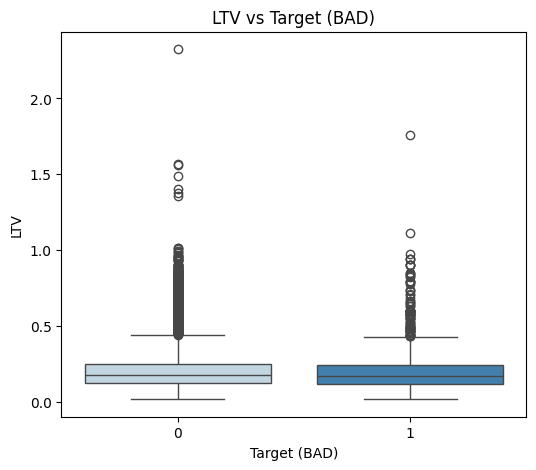

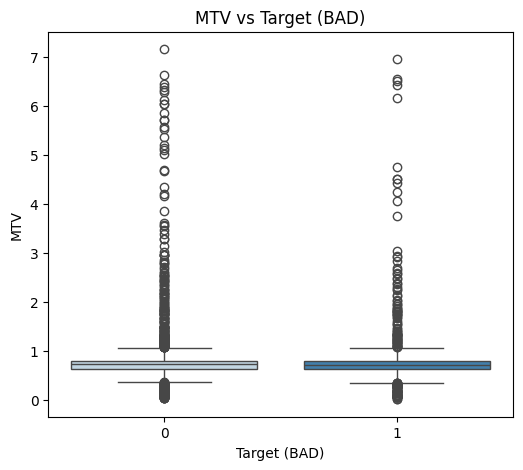

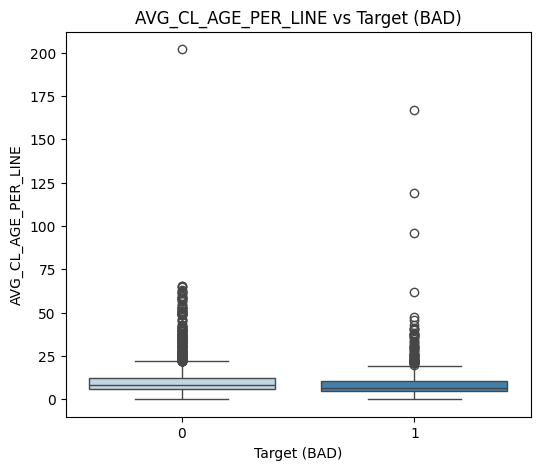

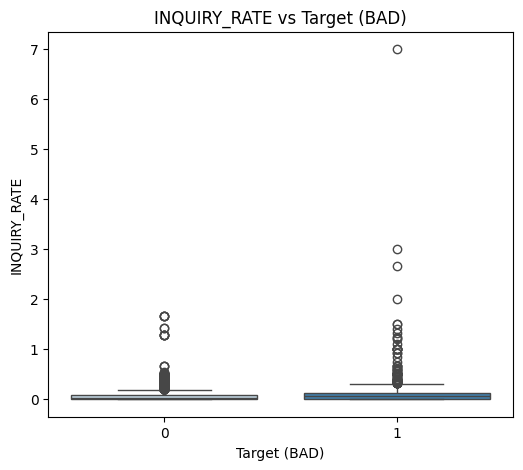

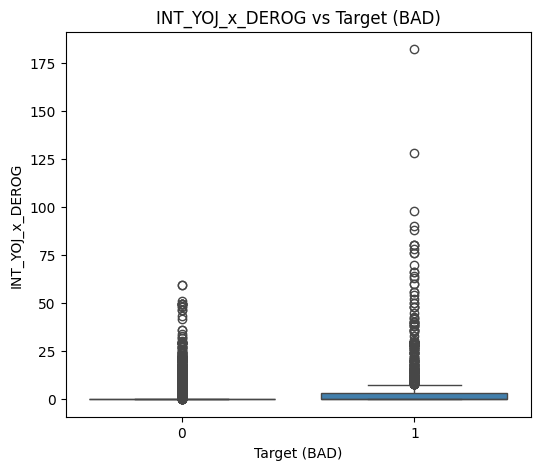

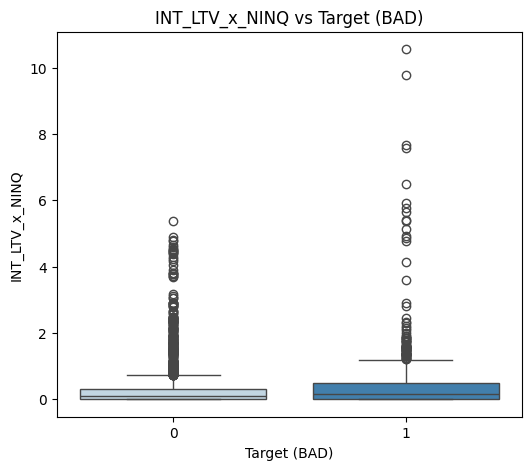

In [ ]:
# List of new numeric variables to include
variables_to_plot = [
    'LOAN', 'MORTDUE', 'VALUE', 'YOJ', 'DEROG', 'DELINQ',
    'CLAGE', 'NINQ', 'CLNO', 'DEBTINC',
    'LTV', 'MTV', 'AVG_CL_AGE_PER_LINE', 'INQUIRY_RATE',
    'INT_YOJ_x_DEROG', 'INT_LTV_x_NINQ'
]

# Use same two-tone palette as REASON chart
custom_palette = ["#bdd7e7", "#3182bd"]

for var in variables_to_plot:
    plt.figure(figsize=(6, 5))
    sns.boxplot(
        x="BAD",
        y=var,
        data=final_df,
        order=[0, 1],
        palette=custom_palette
    )
    plt.title(f"{var} vs Target (BAD)")
    plt.xlabel("Target (BAD)")
    plt.ylabel(var)
    plt.show()


## Observations - Bivariate Numeric Columns

1. `LOAN` vs `BAD`  
   * Median for defaulters is slightly lower than for non-defaulters.  
   * Quartile ranges are very similar.  
   * Both groups have outliers, with non-defaulters showing more extreme values (~6 standard deviations above the mean).  
   * The distributions overlap considerably.  
   * `LOAN` alone is not a strong predictor of default since defaults occur across the entire range of loan amounts.  

2. `MORTDUE` vs `BAD`  
   * Median for defaulters is slightly lower than for non-defaulters.  
   * Quartile ranges are very similar.  
   * Outliers are present in both groups, with defaulters showing slightly higher extreme values (~7 standard deviations above the mean).  
   * Distributions overlap considerably.  
   * `MORTDUE` alone does not clearly separate defaulters from non-defaulters.  

3. `VALUE` vs `BAD`  
   * Median for defaulters is slightly lower than for non-defaulters.  
   * Quartile ranges are very similar.  
   * Defaulters have some extremely high outliers (>12 standard deviations above the mean).  
   * Significant overlap exists between the groups except at extreme values.  
   * Property value alone does not predict defaults.  

4. `YOJ` vs `BAD`  
   * Median and upper quartile values are slightly lower for defaulters.  
   * Ranges are similar for both groups.  
   * Outliers exist in both groups.  
   * Overall overlap suggests `YOJ` alone is not a strong indicator of default risk.  

5. `DEROG` vs `BAD`  
   * Many applicants have zero derogatory reports.  
   * Defaulters tend to have more and higher derogatory marks (~12 standard deviations above the mean).  
   * Higher `DEROG` values are associated with increased default risk.  

6. `DELINQ` vs `BAD`  
   * Most applicants have few or no delinquencies.  
   * Defaulters exhibit more frequent and extreme delinquencies (>10 standard deviations above the mean).  
   * A higher number of delinquencies correlates with higher default risk.  

7. `CLAGE` vs `BAD`  
   * Non-defaulters have a slightly higher median `CLAGE` than defaulters.  
   * Outliers occur in both groups with similar overall ranges.  
   * `CLAGE` by itself is not a strong predictor since defaults occur across most credit age ranges.  

8. `NINQ` vs `BAD`  
   * Non-defaulters have a slightly lower median than defaulters.  
   * Larger outliers occur among defaulters (>8 standard deviations above the mean).  
   * Higher recent inquiry counts may indicate increased risk.  

9. `CLNO` vs `BAD`  
   * Both groups have similar ranges of values.  
   * Defaulters show slightly higher extreme values (~4 standard deviations above the mean).  
   * `CLNO` alone is not a clear predictor of default.  

10. `DEBTINC` vs `BAD`  
    * Variable is capped; both groups show similar ranges.  
    * Outliers exist in both groups.  
    * Debt-to-income ratio alone does not clearly separate defaulters from non-defaulters.  

11. `LTV` vs `BAD`  
    * Both groups have similar value ranges except for one extreme outlier among non-defaulters.  
    * Medians and whiskers are nearly identical.  
    * LTV alone does not clearly predict defaults.  

12. `MTV` vs `BAD`  
    * Both groups have similar medians, ranges, and whiskers.  
    * Outliers present in both groups.  
    * `MTV` alone is not a strong predictor of loan defaults.  

13. `AVG_CL_AGE_PER_LINE` vs `BAD`  
    * Both groups are skewed toward low values.  
    * Defaulters show more extreme outliers, some >40 standard deviations above the mean.  
    * Higher inquiry rates combined with shorter average credit line ages may indicate greater risk.  

14. `INQUIRY_RATE` vs `BAD`  
    * Most applicants in both groups have low inquiry rates.  
    * Defaulters show more extreme outliers (>7 standard deviations above the mean).  
    * Higher inquiry rates may signal increased default risk when combined with other factors.  

15. `INT_YOJ_x_DEROG` vs `BAD`  
    * Defaulters have higher median values and a wider spread than non-defaulters.  
    * Non-defaulters concentrate near zero, suggesting low YOJ × DEROG is associated with lower risk.  
    * Extreme outliers among defaulters indicate elevated risk for high YOJ × DEROG values.  

16. `INT_LTV_x_NINQ` vs `BAD`  
    * Medians near zero for both groups.  
    * Defaulters show higher and more extreme outliers (>10 standard deviations above the mean).  
    * High values may flag risky applicants when LTV and NINQ are both elevated.  


### Non-Numeric Variables


--- REASON ---


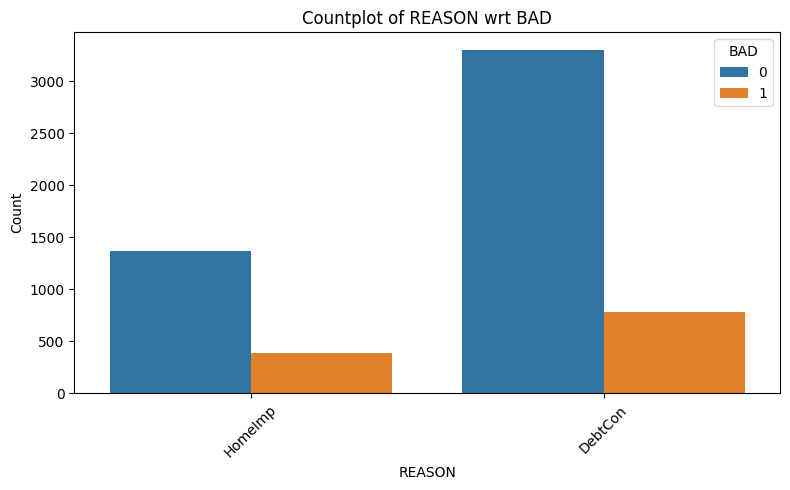

BAD         0     1   All
REASON                   
All      4673  1161  5834
DebtCon  3304   777  4081
HomeImp  1369   384  1753
------------------------------------------------------------------------------------------------------------------------


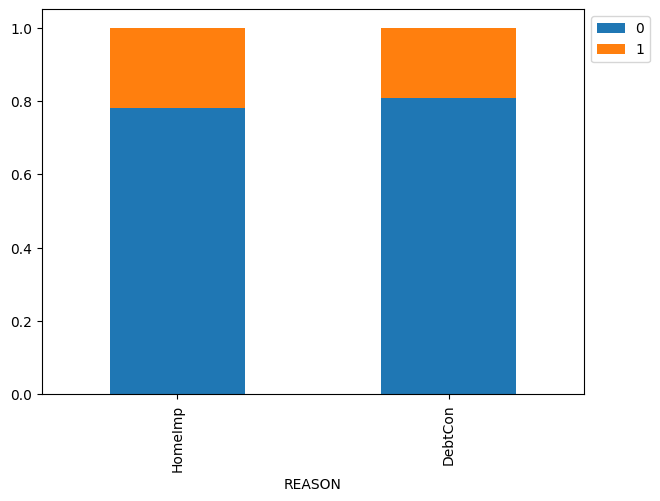


--- JOB ---


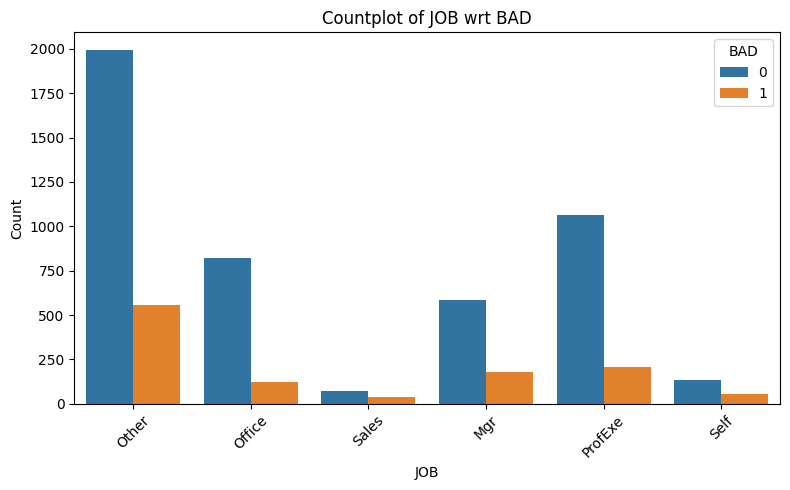

BAD         0     1   All
JOB                      
All      4673  1161  5834
Other    1993   555  2548
ProfExe  1064   210  1274
Mgr       587   178   765
Office    823   122   945
Self      135    58   193
Sales      71    38   109
------------------------------------------------------------------------------------------------------------------------


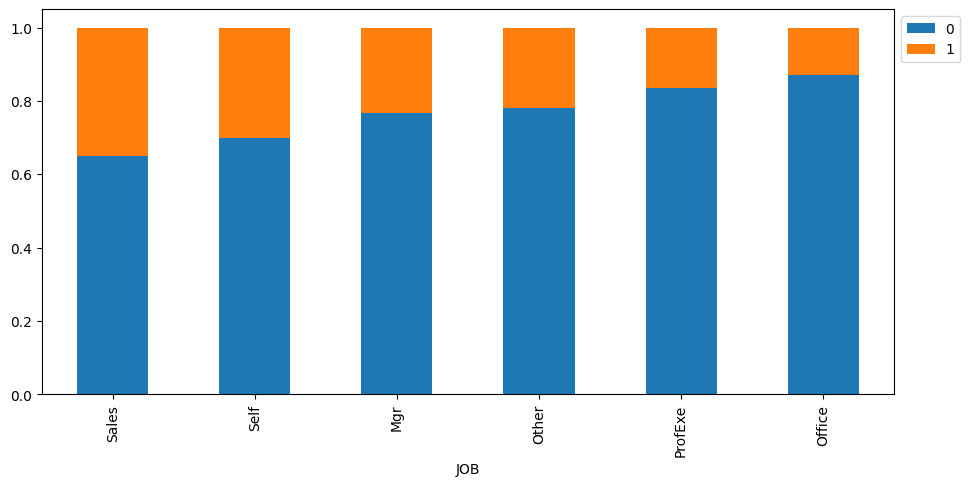


--- NINQ_over_5 ---


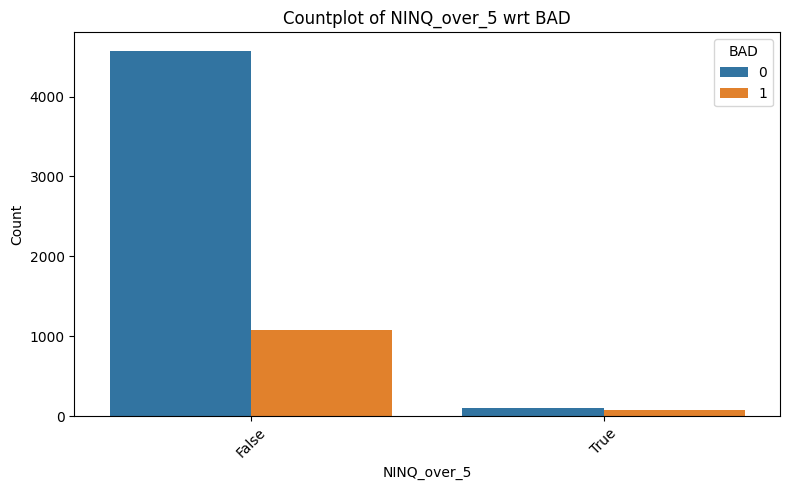

BAD             0     1   All
NINQ_over_5                  
All          4673  1161  5834
False        4575  1082  5657
True           98    79   177
------------------------------------------------------------------------------------------------------------------------


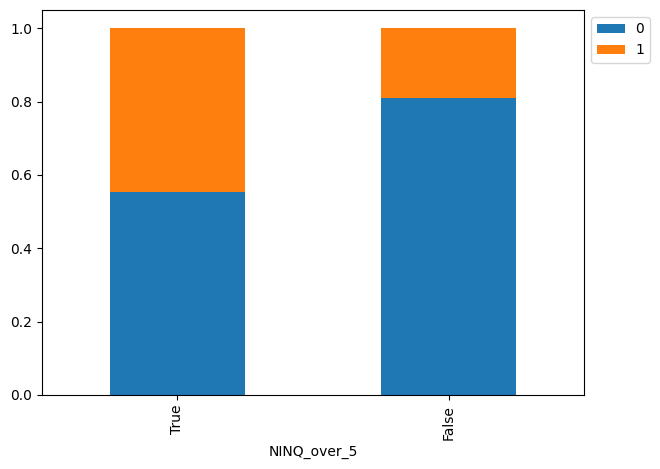


--- DEROG_over_4 ---


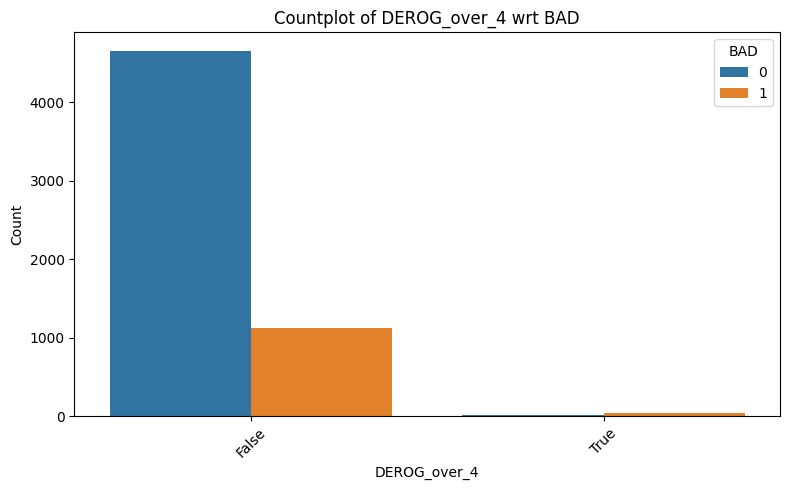

BAD              0     1   All
DEROG_over_4                  
All           4673  1161  5834
False         4660  1125  5785
True            13    36    49
------------------------------------------------------------------------------------------------------------------------


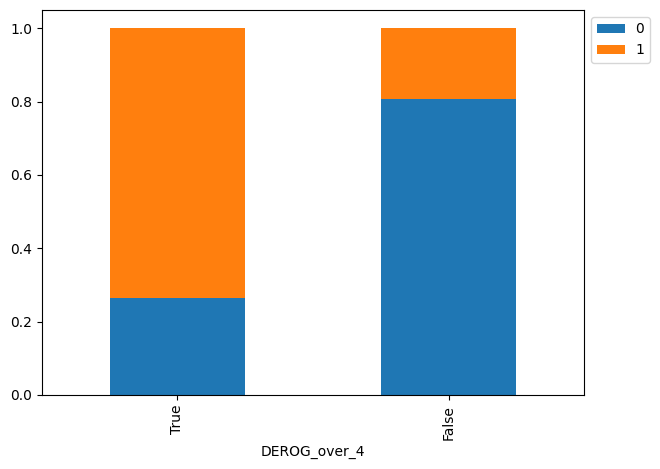


--- DELINQ_over_4 ---


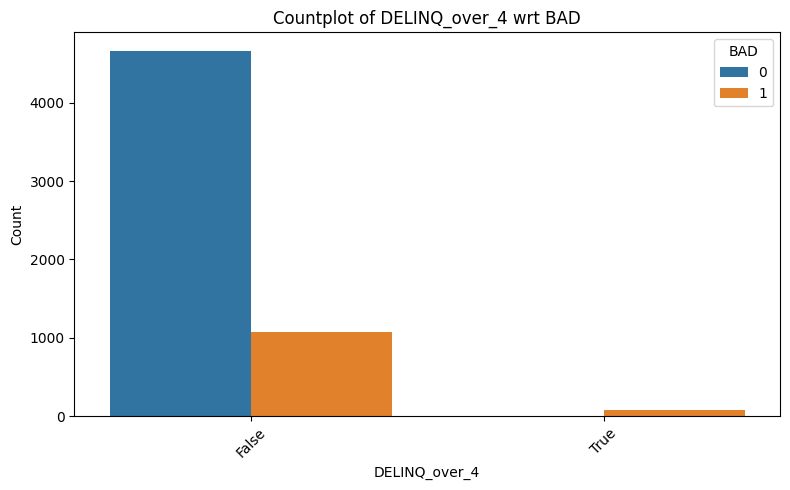

BAD               0     1   All
DELINQ_over_4                  
All            4673  1161  5834
False          4666  1078  5744
True              7    83    90
------------------------------------------------------------------------------------------------------------------------


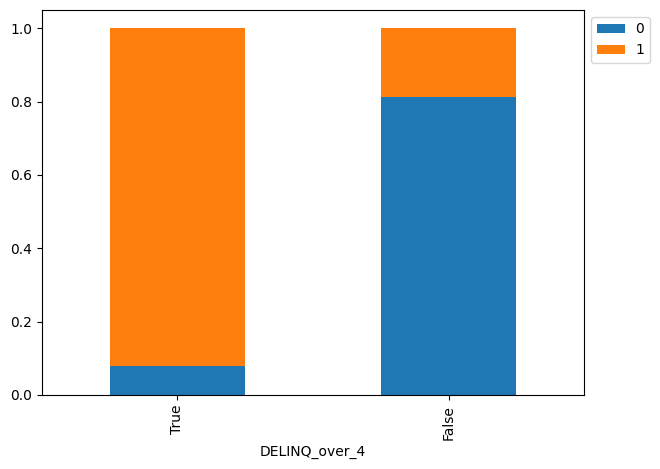

In [ ]:
# Get list of non-numeric (categorical) columns, excluding the target
non_num_cols = final_df.select_dtypes(exclude=['number']).columns
non_num_cols = [col for col in non_num_cols if col != 'BAD']

# Loop through each categorical column
for col in non_num_cols:
    print(f"\n--- {col} ---")

    # Countplot
    plt.figure(figsize=(8, 5))
    sns.countplot(data=final_df, x=col, hue='BAD')
    plt.title(f'Countplot of {col} wrt BAD')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Stacked bar plot
    stacked_barplot(final_df, col, "BAD")

## Observations - Bivariate Non-Numeric Columns

1. `REASON` vs `BAD`  
   * Both DebtCon and HomeImp loans have defaults, but DebtCon has higher counts overall.  
   * Default rates appear slightly higher for HomeImp compared to DebtCon.  
   * The difference between default and non-default proportions is small, suggesting `REASON` alone is not a strong predictor of default.  

2. `JOB` vs `BAD`  
   * Default rates vary across job categories.  
   * Applicants in Sales and Self-employed roles have the highest default rates.  
   * ProfExe and Office workers have the lowest default rates.  
   * Job category may provide some predictive value for default risk.  

3. `NINQ_over_5` vs `BAD`  
   * Applicants with more than 5 inquiries (`True`) have much higher default rates than those with fewer inquiries (`False`).  
   * This suggests a strong relationship between recent credit inquiries and default risk.  

4. `DEROG_over_4` vs `BAD`  
   * Applicants with more than 4 derogatory reports (`True`) have significantly higher default rates than those with fewer reports (`False`).  
   * This variable is a strong indicator of credit risk.  

5. `DELINQ_over_4` vs `BAD`  
   * Applicants with more than 4 delinquencies (`True`) have the highest default rates.  
   * Default rates among these applicants are disproportionately larger than those with fewer delinquencies (`False`).  
   * High delinquency counts are strongly associated with increased default risk.  

6. `REASON` vs `BAD`  
   * HomeImp loans show a slightly higher default proportion than DebtCon loans when proportions are standardized.  
   * This suggests loan purpose influences risk slightly, though not strongly.  

7. `Job Categories` vs `BAD`  
   * Sales and Self-employed categories show the highest proportion of defaults.  
   * Office and ProfExe categories have the lowest default rates.  
   * Occupation type seems linked to default probability.  

8. `NINQ_over_5` vs `BAD`  
   * High inquiry counts (`True`) are strongly associated with default risk.  
   * Applicants with fewer than 5 inquiries show substantially lower default proportions.  

9. `DEROG_over_4` vs `BAD`  
   * Applicants with more than 4 derogatory marks (`True`) have much higher default rates.  
   * Very few applicants fall into this category, but risk is concentrated here.  

10. `DELINQ_over_4` vs `BAD`  
   * Applicants with more than 4 delinquencies (`True`) have extremely high default proportions.  
   * This is one of the strongest non-numeric indicators of default risk.  


## Multvariate Analysis
In the multivariate analysis we wil be examining different combiantions of variables and if they affect the target.

First we will perform the correlation matrix.  This shows us if there is any correlation between the variables.

### Correlation Matrix

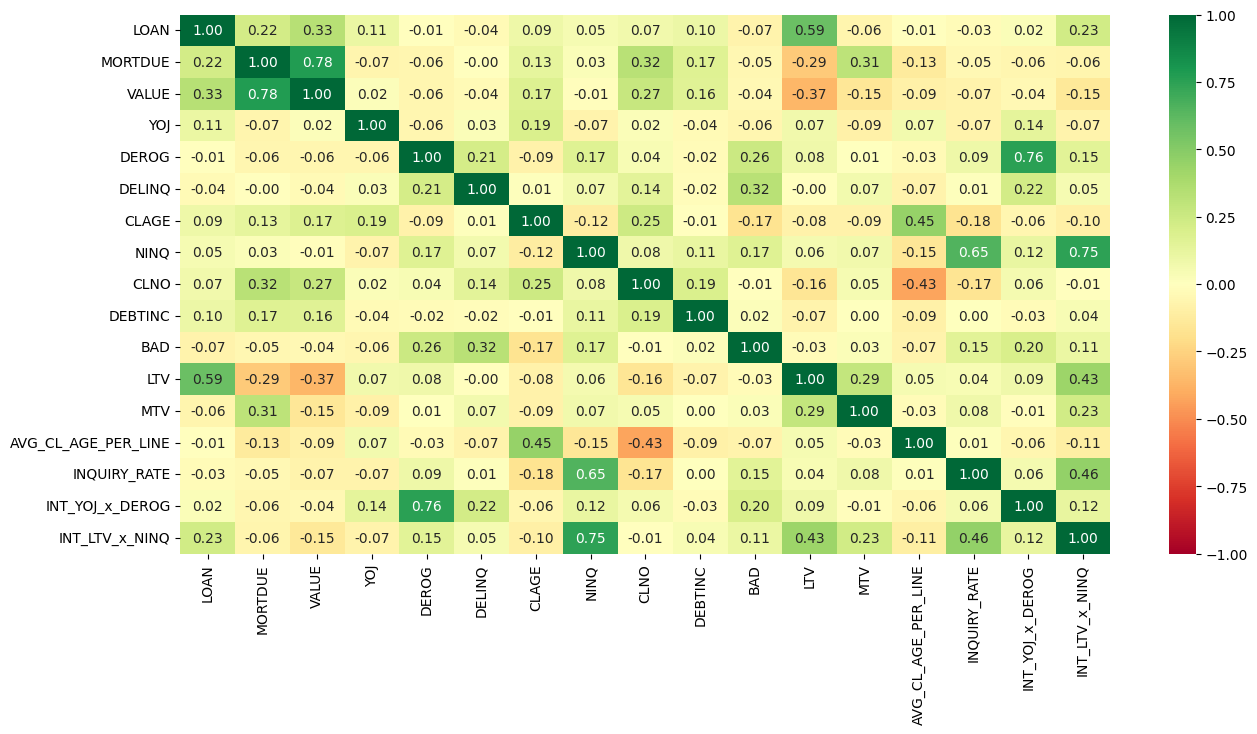

In [ ]:
cols_list = final_df.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(15, 7))
sns.heatmap(
    final_df[cols_list].corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="RdYlGn"
)
plt.show()

## Observations - Multivariate Analysis

>1. **Strong Positive Correlations**  
   * `MORTDUE` and `VALUE`: 0.78 → Properties with higher mortgage due amounts tend to have higher property values.  
   * `DEROG` and `INT_YOJ_x_DEROG`: 0.76 → As expected, the interaction variable is heavily influenced by the number of derogatory records.  
   * `NINQ` and `INT_LTV_x_NINQ`: 0.75 → The interaction between loan-to-value ratio and inquiries is strongly related to the number of inquiries.  
   * `INQUIRY_RATE` and `NINQ`: 0.66 → More recent credit inquiries generally result in a higher inquiry rate.  
   * `LOAN` and `LTV`: 0.59 → Higher loan amounts are associated with higher loan-to-value ratios.  

>2. **Strong Negative Correlations**  
   * `CLNO` and `AVG_CL_AGE_PER_LINE`: -0.47 → More credit lines are associated with a lower average age per credit line.  
   * `VALUE` and `LTV`: -0.37 → Higher property values tend to have lower loan-to-value ratios.  

>3. **Moderate Relationship with Target (BAD)**  
   * `DEROG`: 0.32 → Borrowers with more derogatory records are more likely to default.  
   * `DELINQ`: 0.26 → Higher delinquency levels are associated with a higher default rate.  
   * `INT_YOJ_x_DEROG`: 0.20 → This interaction term is positively related to defaults.  
   * Most other variables have weak correlations (< 0.1) with BAD, suggesting limited direct linear relationships.  

---

### Interpretation
- Variables such as `DEROG`, `DELINQ`, and certain interaction terms show some predictive potential for defaults.  
- Strong correlations between predictors (e.g., `VALUE` and `MORTDUE`) indicate **multicollinearity** risk, which must be addressed in modeling.  
- Weak correlations with BAD suggest that **nonlinear relationships or interactions** may play a bigger role in predicting defaults.


## Summary – EDA After Preprocessing

After applying missing value treatment, outlier capping, and feature engineering, we conducted Exploratory Data Analysis (EDA) on both numeric and categorical variables using the unscaled dataset.

---

**Univariate Analysis**
- **Numeric Variables:**  
  - Most variables are right-skewed, with a small proportion of extreme high values driving the tails.  
  - Significant outliers exist in variables like `LOAN`, `MORTDUE`, `VALUE`, `DEROG`, `DELINQ`, `LTV`, and `NINQ`.  
  - Higher values of `DEROG`, `DELINQ`, and `NINQ` tend to cluster with defaults, indicating risk association.

- **Categorical Variables:**  
  - Loan purpose (`REASON`) is dominated by Debt Consolidation (approx 70%) vs Home Improvement (approx 30%).  
  - Job categories like `Sales` (approx 1.9%) and `Self-employed` (approx 3.3%) exhibit higher default rates than `ProfExe` (approx 21.8%), `Office` (approx 16.2%), and `Mgr` (approx 13.1%).  
  - Binary flags (`NINQ_over_5`, `DEROG_over_4`, `DELINQ_over_4`) show default rates above 50% in the “True” category, making them strong risk indicators.

---

**Bivariate Analysis**
- **Numeric vs Target:**  
  - `DEROG` and `DELINQ` show the largest separation between defaulters and non-defaulters.  
  - Variables like `LOAN`, `MORTDUE`, `VALUE`, and `CLNO` exhibit substantial overlap, suggesting weaker standalone predictive power.  
  - Interaction terms (`INT_YOJ_x_DEROG`, `INT_LTV_x_NINQ`) capture extreme high-risk profiles despite overall low medians.

- **Categorical vs Target:**  
  - `NINQ_over_5`, `DEROG_over_4`, and `DELINQ_over_4` clearly separate defaulters vs non-defaulters, with default proportions rising sharply when these flags are “True”.  
  - `REASON` shows slightly higher default rates for Home Improvement vs Debt Consolidation.  
  - Job types `Sales` and `Self-employed` carry the highest default proportions, while `Office` and `ProfExe` have the lowest.

---

**Multivariate Analysis**
- **Strong Positive Correlations:**  
  - `MORTDUE` ↔ `VALUE` (0.78) → Higher mortgages align with higher property values.  
  - `DEROG` ↔ `INT_YOJ_x_DEROG` (0.76) → Interaction term directly linked to derogatory records.  
  - `NINQ` ↔ `INT_LTV_x_NINQ` (0.75) → Higher inquiries amplify risk through loan-to-value effects.  
  - `INQUIRY_RATE` ↔ `NINQ` (0.66) → Inquiry rate driven by recent credit activity.  
  - `LOAN` ↔ `LTV` (0.59) → Larger loans increase loan-to-value ratios.

- **Strong Negative Correlations:**  
  - `CLNO` ↔ `AVG_CL_AGE_PER_LINE` (-0.47) → More credit lines reduce average line age.  
  - `VALUE` ↔ `LTV` (-0.37) → Higher property values reduce loan-to-value ratios.

- **Target Correlations (`BAD`):**  
  - Highest with `DEROG` (0.32), `DELINQ` (0.26), and `INT_YOJ_x_DEROG` (0.20).  
  - Most variables have weak linear correlations with `BAD`, indicating nonlinear effects or interactions may better explain defaults.

---

**Key Takeaways**
- Risk indicators like `DEROG`, `DELINQ`, `NINQ_over_5`, and interaction terms capture high-risk segments effectively.  
- Strong inter-variable correlations point to multicollinearity, requiring attention in modeling (e.g., regularization, VIF checks).  
- Weak direct correlations with `BAD` suggest tree-based models or nonlinear transformations might capture default risk better than linear models alone.


# **Alternative Analytical Approaches**

Although the methods chosen in this project were effective, there are a few practical variations that could be explored to see if they improve the final model’s accuracy:

1. **Varying Missing Value Treatments**  
   - Experiment with different numbers of neighbors in KNN imputation.  
   - Try alternative distance metrics (e.g., Manhattan, Minkowski) instead of just Euclidean.  
   - Evaluate which setting best predicts the missing values by using a validation set.  

2. **Testing Different Outlier Capping Approaches**  
   - Compare results when capping all variables vs. only selected ones.  
   - Run the model without any capping to see if it handles outliers naturally.  

3. **Exploring Different Scaling Methods**  
   - Try scaling techniques such as Min–Max scaling, Robust scaling, or normalization, and compare performance.  

4. **Separate Treatment for Defaulters and Non-Defaulters**  
   - Before preprocessing, split the dataset by target class and treat missing values, outliers, and scaling **within each group**.  
   - This could capture different patterns in each class that might be lost when treating the data as a single group.  


In [ ]:
final_df.shape

(5834, 22)

In [ ]:
final_df['BAD'].value_counts()

,count
BAD,
0,4673
1,1161


# Data Preparation for Modelling

In this step, we prepare the dataset for machine learning models by performing the following:

1. **Separate features and target**  
   - Split the independent variables (`X`) from the dependent variable (`y = BAD`).

2. **Identify numeric columns**  
   - Record the original numeric columns before encoding.  
   - These columns are the only ones that will be scaled later.

3. **Encode categorical variables**  
   - Use `pd.get_dummies` with `drop_first=True` to convert categorical features into dummy variables and avoid multicollinearity.

4. **Add a constant**  
   - Include a `const` column for models (like statsmodels logistic regression) that require an intercept.

5. **Split into train and test sets**  
   - Perform a 80/20 split with `stratify=y` to preserve class balance.

6. **Scale continuous numeric features**  
   - Apply `StandardScaler` to only the original continuous numeric variables.  
   - Leave dummy variables, binary flags, and the constant column unchanged.



In [ ]:
#Separate features/target
X = final_df.drop(columns=["BAD"])
y = final_df["BAD"]

# 2) Remember original numeric columns (these are the ONLY ones we'll scale)
num_cols_original = X.select_dtypes(include=["float64", "int64"]).columns.tolist()

# 3) One-hot encode categoricals/objects
X = pd.get_dummies(X, drop_first=True, dtype=int)

# 4) Add constant (for statsmodels-style models)
X = sm.add_constant(X, has_constant="add")  # column name: 'const'

# 5) Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=1, stratify=y
)

# Keep unscaled backups
X_train_unscaled = X_train.copy()
X_test_unscaled  = X_test.copy()

# Helper: detect binary-like numeric
def is_binary_like(s: pd.Series) -> bool:
    v = pd.unique(s.dropna())
    return np.isin(v, [0, 1]).all()

# Continuous original numeric cols to scale (present in train, not binary)
cont_to_scale = [
    c for c in num_cols_original
    if c in X_train_unscaled.columns and not is_binary_like(X_train_unscaled[c])
]

# Make scaled copies
X_train_scaled = X_train_unscaled.copy()
X_test_scaled  = X_test_unscaled.copy()

# Fit on TRAIN **scaled frame** (same values as unscaled copy at this point)
scaler = StandardScaler().fit(X_train_scaled[cont_to_scale])

# Transform TRAIN/TEST in-place on the scaled copies
X_train_scaled.loc[:, cont_to_scale] = scaler.transform(X_train_scaled[cont_to_scale])
X_test_scaled.loc[:,  cont_to_scale] = scaler.transform(X_test_scaled[cont_to_scale])

# Ensure intercept exists (you already added earlier, but just in case)
if "const" not in X_train_scaled.columns:
    X_train_scaled = sm.add_constant(X_train_scaled, has_constant="add")
    X_test_scaled  = sm.add_constant(X_test_scaled,  has_constant="add")




In [ ]:
# Checking that all variables are numeric for the model to run
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1167 entries, 5205 to 5618
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   const                1167 non-null   float64
 1   LOAN                 1167 non-null   float64
 2   MORTDUE              1167 non-null   float64
 3   VALUE                1167 non-null   float64
 4   YOJ                  1167 non-null   float64
 5   DEROG                1167 non-null   float64
 6   DELINQ               1167 non-null   float64
 7   CLAGE                1167 non-null   float64
 8   NINQ                 1167 non-null   float64
 9   CLNO                 1167 non-null   float64
 10  DEBTINC              1167 non-null   float64
 11  LTV                  1167 non-null   float64
 12  MTV                  1167 non-null   float64
 13  AVG_CL_AGE_PER_LINE  1167 non-null   float64
 14  INQUIRY_RATE         1167 non-null   float64
 15  INT_YOJ_x_DEROG      1167 non-null   flo

In [ ]:
# Checking that sll variables are numeric for the model to run
X_train_scaled.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4667 entries, 5519 to 1556
Data columns (total 26 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   const                4667 non-null   float64
 1   LOAN                 4667 non-null   float64
 2   MORTDUE              4667 non-null   float64
 3   VALUE                4667 non-null   float64
 4   YOJ                  4667 non-null   float64
 5   DEROG                4667 non-null   float64
 6   DELINQ               4667 non-null   float64
 7   CLAGE                4667 non-null   float64
 8   NINQ                 4667 non-null   float64
 9   CLNO                 4667 non-null   float64
 10  DEBTINC              4667 non-null   float64
 11  LTV                  4667 non-null   float64
 12  MTV                  4667 non-null   float64
 13  AVG_CL_AGE_PER_LINE  4667 non-null   float64
 14  INQUIRY_RATE         4667 non-null   float64
 15  INT_YOJ_x_DEROG      4667 non-null   flo

In [ ]:
X_train_scaled.head()

,const,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC,LTV,MTV,AVG_CL_AGE_PER_LINE,INQUIRY_RATE,INT_YOJ_x_DEROG,INT_LTV_x_NINQ,REASON_HomeImp,JOB_Office,JOB_Other,JOB_ProfExe,JOB_Sales,JOB_Self,NINQ_over_5_True,DEROG_over_4_True,DELINQ_over_4_True
5519,1.0,1.876555,2.027495,2.250082,0.130320,3.247802,3.087443,-1.235890,-0.700790,-0.038116,0.610093,-0.302717,-0.145601,-0.768262,-0.395051,3.533733,-0.490706,0,0,0,0,0,0,0,0,0
3080,1.0,-0.148399,-0.691721,-0.658201,-0.137532,-0.323541,-0.446537,-1.604426,1.083101,-1.034023,-0.639549,0.321185,-0.172655,-0.699192,1.202847,-0.264420,0.970392,0,0,1,0,0,0,0,0,0
3006,1.0,-0.166479,-0.244833,-0.111359,-1.208939,-0.323541,-0.446537,0.109355,-0.106159,0.957790,0.286439,-0.254063,-0.225466,-0.478048,-0.206052,-0.264420,-0.171503,0,0,1,0,0,0,0,0,0
1986,1.0,-0.509998,2.370254,1.656555,-0.807161,-0.323541,1.320453,0.201925,-0.106159,2.850012,-0.590764,-0.942847,0.288365,-0.738597,-0.277872,-0.264420,-0.372458,0,0,0,0,0,0,0,0,0
3571,1.0,0.059520,0.816415,0.554290,-0.807161,-0.323541,-0.446537,-0.977551,7.029402,-0.735251,-0.172482,-0.456712,0.116249,-0.361883,5.045413,-0.264420,2.890331,0,1,0,0,0,0,1,0,0


In [ ]:
X_test_scaled.head()

,const,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC,LTV,MTV,AVG_CL_AGE_PER_LINE,INQUIRY_RATE,INT_YOJ_x_DEROG,INT_LTV_x_NINQ,REASON_HomeImp,JOB_Office,JOB_Other,JOB_ProfExe,JOB_Sales,JOB_Self,NINQ_over_5_True,DEROG_over_4_True,DELINQ_over_4_True
5205,1.0,1.026797,-0.128601,-0.951572,-1.208939,0.866907,2.203948,0.263684,5.245512,-0.635660,-0.478662,2.700853,1.573032,0.408000,3.510923,-0.264420,11.322352,0,0,1,0,0,0,1,0,0
1574,1.0,-0.627518,-0.205507,-0.445294,0.398172,-0.323541,-0.446537,0.800889,-0.700790,0.459837,-0.707668,-0.388913,0.199973,-0.071150,-0.395051,-0.264420,-0.490706,0,0,1,0,0,0,0,0,0
1197,1.0,-0.763118,-1.470766,-0.720707,-0.271458,2.057355,-0.446537,2.243577,-0.106159,0.061474,-2.504777,-0.284827,-1.344430,0.791391,-0.128735,1.508052,-0.180479,1,0,1,0,0,0,0,0,0
4908,1.0,0.737518,1.378402,1.203015,-0.137532,-0.323541,-0.446537,0.445752,-0.106159,-0.237298,0.527659,-0.383618,0.035674,0.162590,-0.086685,-0.264420,-0.209301,0,0,1,0,0,0,0,0,0
2261,1.0,-0.410559,-0.438514,-0.572105,-0.137532,-0.323541,-0.446537,0.708700,-0.700790,-0.436479,-0.032567,-0.066089,0.074568,0.478855,-0.395051,-0.264420,-0.490706,0,0,1,0,0,0,0,0,0


**Observations**

The numeric variables have been successfully scaled, while the dummy (categorical) variables remain unscaled as expected.


In [ ]:
# Checking the shape of the training and test data to ensure that they have the same distribution of 1's and 0's
print("Shape of Training set : ", X_train_scaled.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (4667, 26)
Shape of test set :  (1167, 26)
Percentage of classes in training set:
BAD
0    0.800943
1    0.199057
Name: proportion, dtype: float64
Percentage of classes in test set:
BAD
0    0.8012
1    0.1988
Name: proportion, dtype: float64


In [ ]:
y_test.value_counts()

,count
BAD,
0,935
1,232


In [ ]:
y_train.value_counts()

,count
BAD,
0,3738
1,929


**Observations**

Both the training and test datasets maintain the same class proportions: 20% defaulters and 80% non-defaulters.  
The total number of rows remains unchanged at 5,834.


# Data Modelling

### Model Performance Evaluation

## Model performance evaluation

**Model can make wrong predictions as**:

1. Predicting a Default would be happen but in reality the company did not Default (False Positive).

2. Predicting a company would not default but in reality the company did default (False Negative).

**Which case is more important?**

* Both the cases are important as:

  * False Positive - In this case a company who was flagged as they would default but infact they did not would have a negative impact on the company as it may deny them the chance of getting a loan and it would be a missed business opportunity for investments

  * False Negative - In this case when we predict a company would not default but they did can be very dangerous as it would lead to loss of financial resources and exposure to risk.  


**How to reduce this loss?**

* We need to reduce  False Negatives.

* `recall_score` should be maximized as the greater the recall_score, the higher the chances of reducing False Negatives

$$
\text{Recall} = \frac{\text{True Positives (TP)}}{\text{True Positives (TP)} + \text{False Negatives (FN)}}
$$
  

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using statsmodels
def model_performance_classification_statsmodels(
    model, predictors, target, threshold=0.5
):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """

    # checking which probabilities are greater than threshold
    pred_temp = model.predict(predictors) > threshold
    # rounding off the above values to get classes
    pred = np.round(pred_temp)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [ ]:
# defining a function to plot the confusion_matrix of a classification model


def confusion_matrix_statsmodels(model, predictors, target, threshold=0.5):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    threshold: threshold for classifying the observation as class 1
    """
    y_pred = model.predict(predictors) > threshold
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

### Logistic Regression

In [ ]:
# fitting logistic regression model
logit = sm.Logit(y_train, X_train_scaled.astype(float))
lg = logit.fit(disp=False)

print(lg.summary())

                           Logit Regression Results                           
Dep. Variable:                    BAD   No. Observations:                 4667
Model:                          Logit   Df Residuals:                     4641
Method:                           MLE   Df Model:                           25
Date:                Fri, 19 Sep 2025   Pseudo R-squ.:                  0.1918
Time:                        01:58:49   Log-Likelihood:                -1882.5
converged:                       True   LL-Null:                       -2329.3
Covariance Type:            nonrobust   LLR p-value:                2.160e-172
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -1.7743      0.119    -14.880      0.000      -2.008      -1.541
LOAN                    0.0604      0.090      0.670      0.503      -0.116       0.237
MORTDUE         

**Observations**

Some variables show high p-values, meaning their impact on predicting loan defaults is not statistically significant and they may not add much value to the model.  
Negative coefficients indicate that as these variables increase, the likelihood of default decreases, suggesting a protective effect against risk.


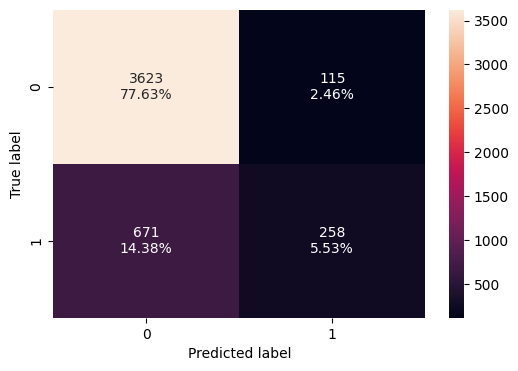

In [ ]:
# Generate the confusion matrix for the training data using the fitted logistic regression model
# to evaluate classification performance (true positives, false positives, true negatives, false negatives)

confusion_matrix_statsmodels(lg, X_train_scaled, y_train)

In [ ]:
# Print the training performance metrics (e.g., accuracy, precision, recall, F1 score)
# for the logistic regression model on the scaled training data

print("Training performance:")
model_performance_classification_statsmodels(lg, X_train_scaled, y_train)

Training performance:


,Accuracy,Recall,Precision,F1
0,0.831583,0.277718,0.691689,0.396313


### Checking Multicollinearity

- In order to make statistical inferences from a logistic regression model, it is important to ensure that there is no multicollinearity present in the data.
- There are different ways of detecting (or testing for) multicollinearity. One such way is using the Variation Inflation Factor (VIF).

* **Variance  Inflation  factor**:  Variance  inflation  factors  measure  the  inflation  in  the variances of the regression coefficients estimates due to collinearities that exist among the  predictors.  It  is  a  measure  of  how  much  the  variance  of  the  estimated  regression coefficient $\beta_k$ is "inflated" by  the  existence  of  correlation  among  the  predictor variables in the model.

* **General Rule of thumb**:
  - If VIF is 1 then there is no correlation among the $k$th predictor and the remaining predictor variables, and  hence  the variance of $\beta_k$ is not inflated at all
  - If VIF exceeds 5, we say there is moderate multicollinearity
  - If VIF is equal or exceeding 10, it shows signs of high multi-collinearity

* The purpose of the analysis should dictate which threshold to use

In [ ]:
# Calculate the Variance Inflation Factor (VIF) for each feature in the scaled training data
# to detect multicollinearity among predictors.
# Sort the VIF values in descending order to identify features with the highest multicollinearity first.


vif_series = pd.Series(
    [variance_inflation_factor(X_train_scaled.values, i) for i in range(X_train_scaled.shape[1])],
    index=X_train_scaled.columns,
    dtype=float,
)

# Sort descending
vif_series_sorted = vif_series.sort_values(ascending=False)

print("Series before feature selection (sorted by VIF descending): \n\n{}\n".format(vif_series_sorted))

Series before feature selection (sorted by VIF descending): 

const                  8.330998
MORTDUE                5.551230
LTV                    5.331236
VALUE                  4.941860
NINQ                   4.664640
LOAN                   4.334090
INT_LTV_x_NINQ         3.995682
DEROG                  3.959622
MTV                    2.657617
JOB_Other              2.579308
INT_YOJ_x_DEROG        2.543302
AVG_CL_AGE_PER_LINE    2.247745
JOB_ProfExe            2.228096
DEROG_over_4_True      2.150429
NINQ_over_5_True       2.137436
CLNO                   2.066831
CLAGE                  1.996497
JOB_Office             1.946424
INQUIRY_RATE           1.875143
DELINQ                 1.823461
DELINQ_over_4_True     1.721535
JOB_Self               1.290050
YOJ                    1.187815
JOB_Sales              1.164068
REASON_HomeImp         1.121638
DEBTINC                1.119750
dtype: float64



**Observations**

`MORTDUE`, `LTV`, and `VALUE` all have high VIF values, indicating multicollinearity.  
We will begin by dropping the variable with the highest VIF first.


In [ ]:
# Drop the variable 'MORTDUE' (highest VIF) from the training data
# and recalculate the VIF values for the remaining features
# to check if multicollinearity has been reduced.

X_train_scaled1 = X_train_scaled.drop("MORTDUE", axis=1)

vif_series2 = pd.Series(
    [variance_inflation_factor(X_train_scaled1.values, i) for i in range(X_train_scaled1.shape[1])],
    index=X_train_scaled1.columns,
)
print("Series before feature selection (sorted): \n\n{}\n".format(vif_series2.sort_values(ascending=False)))

Series before feature selection (sorted): 

const                  8.330797
LTV                    4.819221
NINQ                   4.662494
LOAN                   4.042694
INT_LTV_x_NINQ         3.993771
DEROG                  3.956404
VALUE                  2.744741
JOB_Other              2.578573
INT_YOJ_x_DEROG        2.543114
AVG_CL_AGE_PER_LINE    2.245982
JOB_ProfExe            2.213478
DEROG_over_4_True      2.149373
NINQ_over_5_True       2.137404
CLNO                   2.061515
CLAGE                  1.994714
JOB_Office             1.946257
INQUIRY_RATE           1.874193
DELINQ                 1.822307
DELINQ_over_4_True     1.721534
MTV                    1.339530
JOB_Self               1.289973
YOJ                    1.181388
JOB_Sales              1.163597
DEBTINC                1.118968
REASON_HomeImp         1.112893
dtype: float64



**Observations**

All VIF values are below 5, including `LTV`, indicating no concerning multicollinearity among the remaining predictors.  
We will first run the logistic regression model on the current dataset and then remove variables with high p-values to refine the model.


In [ ]:
#Running the logistic regression with the varaibles with low VIF values only
logit2 = sm.Logit(y_train, X_train_scaled1.astype(float))
lg2 = logit2.fit(disp=False)

print("Training performance:")
model_performance_classification_statsmodels(lg2, X_train_scaled1, y_train)

Training performance:


,Accuracy,Recall,Precision,F1
0,0.830512,0.272336,0.6875,0.390131


In [ ]:
print(lg2.summary())

                           Logit Regression Results                           
Dep. Variable:                    BAD   No. Observations:                 4667
Model:                          Logit   Df Residuals:                     4642
Method:                           MLE   Df Model:                           24
Date:                Fri, 19 Sep 2025   Pseudo R-squ.:                  0.1876
Time:                        01:58:49   Log-Likelihood:                -1892.2
converged:                       True   LL-Null:                       -2329.3
Covariance Type:            nonrobust   LLR p-value:                4.323e-169
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -1.7733      0.119    -14.919      0.000      -2.006      -1.540
LOAN                   -0.0644      0.086     -0.753      0.452      -0.232       0.103
VALUE           

### Removing high p-value variables

>We will do the following repeatedly using a loop:
  - Build a model, check the p-values of the variables, and drop the column with the highest p-value.
  - Create a new model without the dropped feature, check the p-values of the variables, and drop the column with the highest p-value.
  - Repeat the above two steps till there are no columns with p-value > 0.05.


Note: The above process can also be done manually by picking one variable at a time that has a high p-value, dropping it, and building a model again. But that might be a little tedious and using a loop will be more efficient.

In [ ]:
# initial list of columns
cols = X_train_scaled1.columns.tolist()

# setting an initial max p-value
max_p_value = 1

while len(cols) > 0:
    # defining the train set
    X_train_aux = X_train_scaled1[cols]

    # fitting the model
    model = sm.Logit(y_train, X_train_aux).fit(disp=False)

    # getting the p-values and the maximum p-value
    p_values = model.pvalues
    max_p_value = max(p_values)

    # name of the variable with maximum p-value
    feature_with_p_max = p_values.idxmax()

    if max_p_value > 0.05:
        cols.remove(feature_with_p_max)
    else:
        break

selected_features = cols
print(selected_features)

['const', 'DEROG', 'DELINQ', 'CLAGE', 'NINQ', 'LTV', 'AVG_CL_AGE_PER_LINE', 'REASON_HomeImp', 'JOB_Office', 'JOB_Sales', 'JOB_Self', 'DELINQ_over_4_True']


In [ ]:
# Create a new training dataset (X_train_scaled2) containing only the selected features
# after removing variables with high p-values or multicollinearity issues

X_train_scaled2 = X_train_scaled1[selected_features]

In [ ]:
# Building the logistc regression again with the low p value variables.
logit3 = sm.Logit(y_train, X_train_scaled2.astype(float))
lg3 = logit3.fit(disp=False)

print(lg3.summary())

                           Logit Regression Results                           
Dep. Variable:                    BAD   No. Observations:                 4667
Model:                          Logit   Df Residuals:                     4655
Method:                           MLE   Df Model:                           11
Date:                Fri, 19 Sep 2025   Pseudo R-squ.:                  0.1839
Time:                        01:58:50   Log-Likelihood:                -1901.0
converged:                       True   LL-Null:                       -2329.3
Covariance Type:            nonrobust   LLR p-value:                1.401e-176
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  -1.7058      0.058    -29.631      0.000      -1.819      -1.593
DEROG                   0.3933      0.042      9.400      0.000       0.311       0.475
DELINQ          

Training performance:
   Accuracy    Recall  Precision        F1
0  0.829655  0.259419   0.692529  0.377447


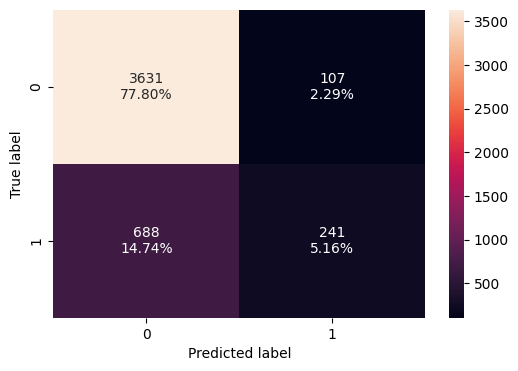

In [ ]:
# creating confusion matrix
confusion_matrix_statsmodels(lg3, X_train_scaled2, y_train)

# calculating model performance
lr_base_train_perf = model_performance_classification_statsmodels(
    lg3, X_train_scaled2, y_train
)

print("Training performance:")
print (lr_base_train_perf)

In [ ]:
# Ensuring the test data have the same column as the train data
X_test_scaled2 = X_test_scaled[selected_features]

Training performance:
   Accuracy    Recall  Precision        F1
0  0.825193  0.232759      0.675  0.346154


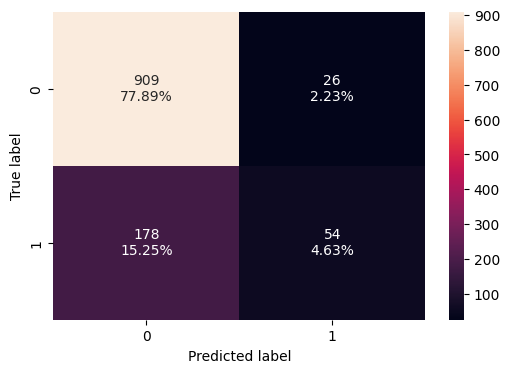

In [ ]:
# creating confusion matrix
confusion_matrix_statsmodels(lg3, X_test_scaled2, y_test)

# calculating model performance
lr_base_test_perf = model_performance_classification_statsmodels(
    lg3, X_test_scaled2, y_test
)

print("Training performance:")
print (lr_base_test_perf)

**Observations**

Both recall and precision scores are currently very low.  
We will now try to find the optimal decision threshold using the AUC-ROC and Precision-Recall curves to improve model performance.


### Logistic Regression - AUC-ROC Curve

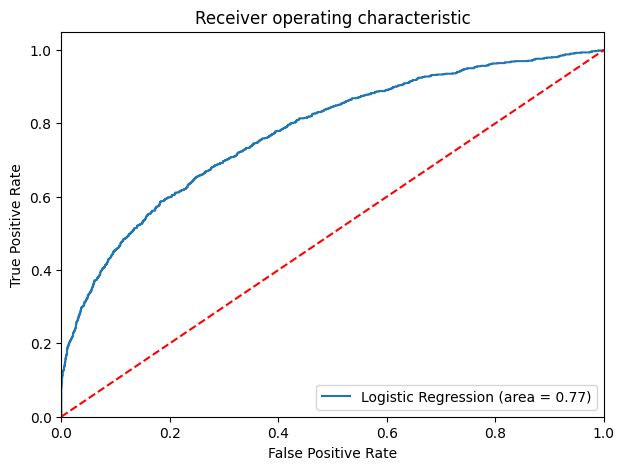

In [ ]:
# Plot the ROC curve for the logistic regression model on the training data
# to visualize the trade-off between the True Positive Rate (Recall) and False Positive Rate
# and compute the AUC (Area Under the Curve) as a performance metric

logit_roc_auc_train = roc_auc_score(y_train, lg3.predict(X_train_scaled2))
fpr, tpr, thresholds = roc_curve(y_train, lg3.predict(X_train_scaled2))
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label="Logistic Regression (area = %0.2f)" % logit_roc_auc_train)
plt.plot([0, 1], [0, 1], "r--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic")
plt.legend(loc="lower right")
plt.show()

In [ ]:
# Optimal threshold as per AUC-ROC curve
# The optimal cut off would be where tpr is high and fpr is low
fpr, tpr, thresholds = roc_curve(y_train, lg3.predict(X_train_scaled2))

optimal_idx = np.argmax(tpr - fpr)
optimal_threshold_auc_roc = thresholds[optimal_idx]
print(optimal_threshold_auc_roc)

0.19349599109201865


The optimal threshold to separate the defaulters from non defaulters is 0.1985


Training performance:
   Accuracy    Recall  Precision        F1
0  0.731091  0.653391   0.394156  0.491697


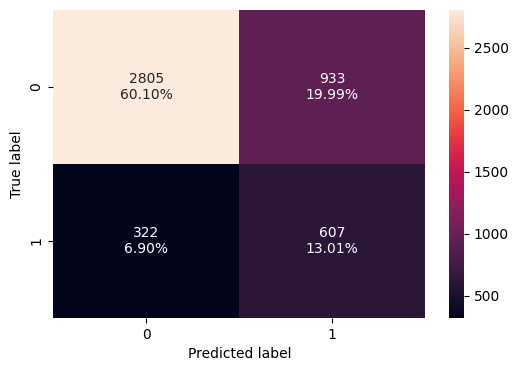

In [ ]:
# creating confusion matrix
confusion_matrix_statsmodels(
    lg3, X_train_scaled2, y_train, threshold=optimal_threshold_auc_roc
)

# checking model performance for this model
lr_AUC_train_perf = model_performance_classification_statsmodels(
    lg3, X_train_scaled2, y_train, threshold=optimal_threshold_auc_roc
)
print("Training performance:")
print (lr_AUC_train_perf)

Test performance:
   Accuracy    Recall  Precision        F1
0  0.742931  0.689655   0.412371  0.516129


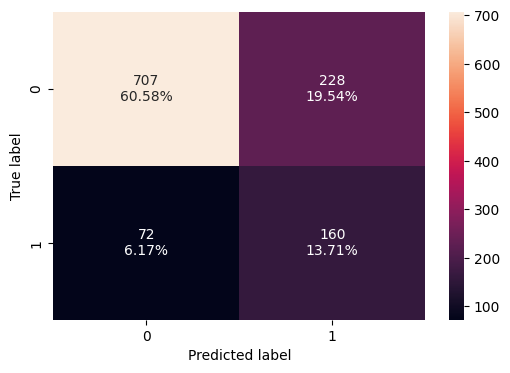

In [ ]:
# creating confusion matrix
confusion_matrix_statsmodels(lg3, X_test_scaled2, y_test, threshold=optimal_threshold_auc_roc)

# checking model performance for this model
lr_AUC_test_perf = model_performance_classification_statsmodels(
    lg3, X_test_scaled2, y_test, threshold=optimal_threshold_auc_roc
)
print("Test performance:")
print(lr_AUC_test_perf)

**Observations**

Precision has improved, but the model appears to be overfitting.  
Next, we will examine the Precision–Recall curve to evaluate performance under class imbalance and to help select a better decision threshold.


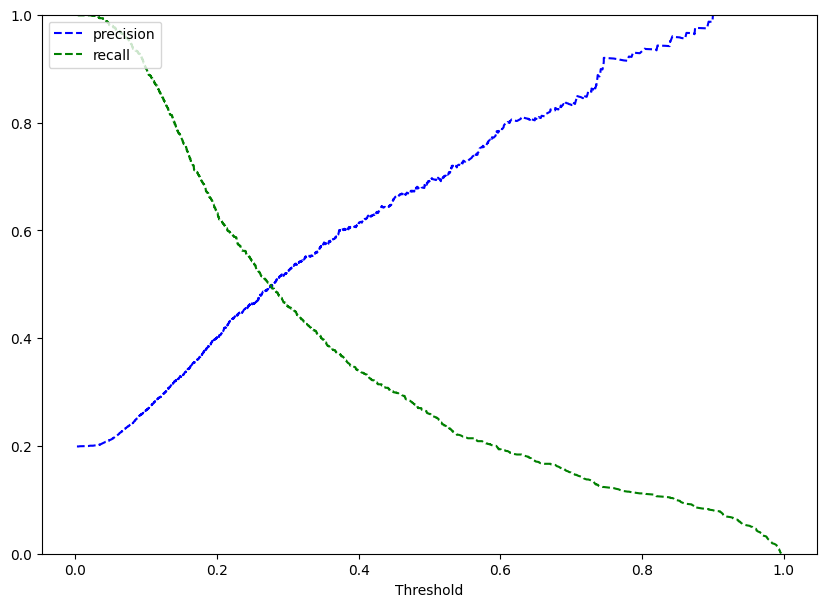

In [ ]:
# Generate precision-recall values at different thresholds using the training data
# and plot Precision vs Recall against the decision thresholds
# to visualize how threshold selection impacts both metrics

y_scores = lg3.predict(X_train_scaled2)
prec, rec, tre = precision_recall_curve(y_train, y_scores,)


def plot_prec_recall_vs_tresh(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="precision")
    plt.plot(thresholds, recalls[:-1], "g--", label="recall")
    plt.xlabel("Threshold")
    plt.legend(loc="upper left")
    plt.ylim([0, 1])


plt.figure(figsize=(10, 7))
plot_prec_recall_vs_tresh(prec, rec, tre)
plt.show()

In [ ]:
# setting the threshold
optimal_threshold_curve = 0.25

Training performance:
   Accuracy    Recall  Precision        F1
0  0.783801  0.540366     0.4631  0.498758


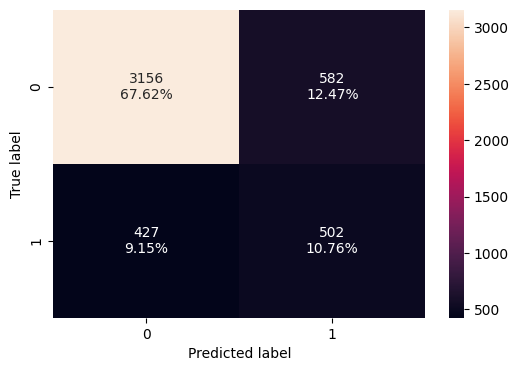

In [ ]:
# creating confusion matrix
confusion_matrix_statsmodels(lg3, X_train_scaled2, y_train, threshold=optimal_threshold_curve)

lr_PR_train_perf = model_performance_classification_statsmodels(
    lg3, X_train_scaled2, y_train, threshold=optimal_threshold_curve
)
print("Training performance:")
print (lr_PR_train_perf)

Test performance:
   Accuracy    Recall  Precision        F1
0   0.79006  0.560345    0.47619  0.514851


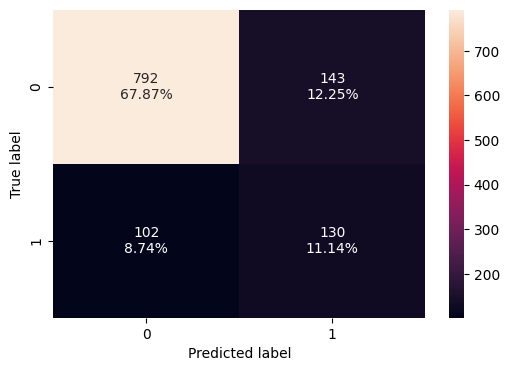

In [ ]:
# creating confusion matrix
confusion_matrix_statsmodels(lg3, X_test_scaled2, y_test, threshold=optimal_threshold_curve)

lr_PR_test_perf = model_performance_classification_statsmodels(
    lg3, X_test_scaled2, y_test, threshold=optimal_threshold_curve
)
print("Test performance:")
print (lr_PR_test_perf)

**Observations**

As expected, the model's recall performance decreased as we adjusted the threshold to balance precision and recall.  
Despite this adjustment, the model continues to show signs of overfitting.


### Model Performance Comparison and Final Model Selection

---

In [ ]:
# training performance comparison

models_train_comp_df = pd.concat(
    [
        lr_base_train_perf.T,
        lr_AUC_train_perf.T,
        lr_PR_train_perf.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "LR Base (0.5)",
    "LR AUC_ROC (0.19))",
    "LR PR (0.25)",
]

print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,LR Base (0.5),LR AUC_ROC (0.19)),LR PR (0.25)
Accuracy,0.829655,0.731091,0.783801
Recall,0.259419,0.653391,0.540366
Precision,0.692529,0.394156,0.463100
F1,0.377447,0.491697,0.498758


In [ ]:
# testing performance comparison

models_test_comp_df = pd.concat(
    [
        lr_base_test_perf.T,
        lr_AUC_test_perf.T,
        lr_PR_test_perf.T,
    ],
    axis=1,
)
models_test_comp_df.columns = [
    "LR Base (0.5)",
    "LR AUC_ROC (0.19))",
    "LR PR (0.25)",
]

print("Testing performance comparison:")
models_test_comp_df

Testing performance comparison:


,LR Base (0.5),LR AUC_ROC (0.19)),LR PR (0.25)
Accuracy,0.825193,0.742931,0.790060
Recall,0.232759,0.689655,0.560345
Precision,0.675000,0.412371,0.476190
F1,0.346154,0.516129,0.514851


**Observations**

The best recall is achieved using the AUC/ROC-based threshold:  
- **Test Data:** Recall = 0.68, Precision = 0.56  
- **Train Data:** Recall = 0.65, Precision = 0.54  

This threshold provides the optimal balance between recall and precision based on our current model performance.


In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [ ]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

## LDA

### Linear Discriminant Analysis (LDA)

**What it does**  
LDA finds a single weighted combination of features (e.g., LTV, debt-to-income, delinquencies) that best separates defaulters from non-defaulters.  
Think of it as drawing the best straight line (in many dimensions) between the two groups.

**How it works (in plain terms)**  
It looks for weights that maximize the distance between group means while minimizing the spread within each group.  
The resulting score is converted into a probability of default and classified using a threshold.

**When to use**  
- When you need a simple, fast, and explainable linear model.  
- When features are roughly normally distributed within each class.  
- When classes have similar variance and covariance structures.  

**Setup tips for our data**  
- Scale numeric features using StandardScaler, but keep dummy/boolean variables as 0/1 without scaling.  
- Remove highly correlated features to avoid instability; consider shrinkage LDA if correlations remain high.  
- Handle class imbalance by setting class priors to reflect the actual default rate.  

**Evaluate**  
- Use Recall, PR-AUC, and ROC-AUC metrics.  
- Adjust the classification threshold to reduce false negatives (missed defaults).  


In [ ]:
# Fitting the base LDA Model
LDA_base_model = LinearDiscriminantAnalysis()
LDA_base_model = LDA_base_model.fit(X_train_scaled, y_train)

   Accuracy  Recall  Precision        F1
0  0.829012  0.2831   0.665823  0.397281


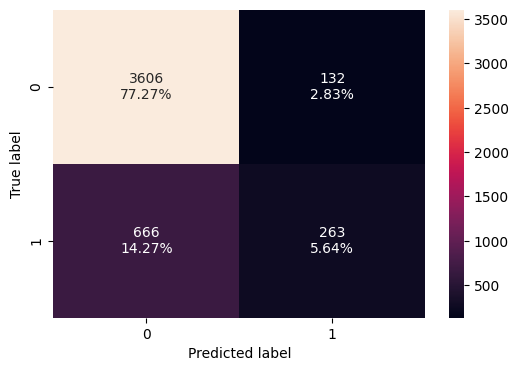

In [ ]:
# Printing the confusion matrix
confusion_matrix_sklearn(LDA_base_model, X_train_scaled, y_train)

# printing model performance metrics
LDAbase_train_perf = model_performance_classification_sklearn(
    LDA_base_model, X_train_scaled, y_train
)
print (LDAbase_train_perf)

In [ ]:
LDAbase_test_perf = model_performance_classification_sklearn(
    LDA_base_model, X_test_scaled, y_test
)
LDAbase_test_perf

,Accuracy,Recall,Precision,F1
0,0.825193,0.284483,0.634615,0.392857


**Observations**

For the Linear Discriminant Analysis (LDA) model using the AUC/ROC-based threshold on the test data:  
- **Accuracy:** 0.825  
- **Recall:** 0.284  
- **Precision:** 0.635  
- **F1 Score:** 0.393  

This shows that while the model achieves reasonable precision and overall accuracy, recall remains relatively low, meaning many defaults are still being missed.


### LDA AUC-ROC model

In [ ]:
y_train_prob = LDA_base_model.predict_proba(X_train_scaled)[:, 1]
lda_roc_auc_train = roc_auc_score(y_train, y_train_prob)

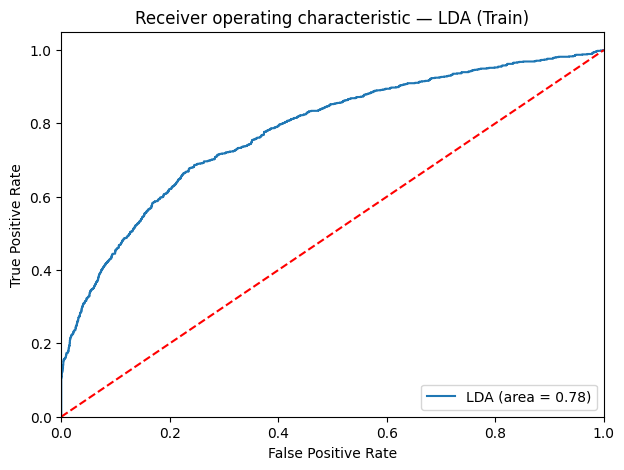

In [ ]:
fpr, tpr, thresholds = roc_curve(y_train, y_train_prob)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label="LDA (area = %0.2f)" % lda_roc_auc_train)
plt.plot([0, 1], [0, 1], "r--")
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic — LDA (Train)")
plt.legend(loc="lower right")
plt.show()

In [ ]:
# --- Optimal threshold by ROC-J (Youden’s J), on TRAIN ---
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold_auc_roc = thresholds[optimal_idx]
print("LDA ROC-J optimal threshold (train):", optimal_threshold_auc_roc)

LDA ROC-J optimal threshold (train): 0.15342496800441321


In [ ]:
def perf_report(y_true, y_prob, thr, split_name=""):
    y_pred = (y_prob >= thr).astype(int)
    print(f"\n{split_name} performance:")
    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred, zero_division=0))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1       :", f1_score(y_true, y_pred))
    print("ROC AUC  :", roc_auc_score(y_true, y_prob))
    print("Confusion matrix:\n", confusion_matrix(y_true, y_pred))

In [ ]:
# --- TRAIN performance at the chosen threshold ---
perf_report(y_train, y_train_prob, optimal_threshold_auc_roc, split_name="TRAIN")


TRAIN performance:
Accuracy : 0.7471609170773517
Precision: 0.41683233929754804
Recall   : 0.6770721205597416
F1       : 0.5159967186218212
ROC AUC  : 0.7790861146771211
Confusion matrix:
 [[2858  880]
 [ 300  629]]


In [ ]:
# --- TEST performance (same threshold as train) ---
y_test_prob = LDA_base_model.predict_proba(X_test_scaled)[:, 1]
perf_report(y_test, y_test_prob, optimal_threshold_auc_roc, split_name="TEST")


TEST performance:
Accuracy : 0.7514995715509855
Precision: 0.4228723404255319
Recall   : 0.6853448275862069
F1       : 0.5230263157894737
ROC AUC  : 0.7815231421722295
Confusion matrix:
 [[718 217]
 [ 73 159]]


**Observations**

For the Linear Discriminant Analysis (LDA) model, the best recall is achieved using the AUC/ROC-based threshold:  
- **Train Data:** Recall = 0.68, Precision = 0.42  
- **Test Data:** Recall = 0.69, Precision = 0.42  

This threshold offers the best trade-off between recall and precision for the LDA model based on current performance metrics.


## Building the base models

We will define some functions which will help us to calcualte the metrics we will use for evaluating our models.  We are ideally interested in recall as it will reduce the number of false negatives, however we do not want the number of false positives to be too high.  False negatives are those who we predict would not defautl, but they did, leading to a direct loss for the bank, and false positives are those who we predict will default but they did not, leading to loss or business opportunities.

**Defining scorer to be used.**
- We want to reduce false negatives and will try to maximize "Recall".
- To maximize Recall, we can use Recall as a **scorer** in cross-validation and hyperparameter tuning.

In [ ]:
# Type of scoring used to compare parameter combinations
scorer = metrics.make_scorer(metrics.recall_score)

**Modeling Plan**

- We will use the following models:  
  - Logistic Regression  
  - Linear Discriminant Analysis (LDA)  
  - Decision Tree  
  - Random Forest  
  - Gradient Boosting  
  - AdaBoost  
  - XGBoost  

- Logistic Regression and LDA will be trained on **scaled data**,  
  while the remaining models will be trained on **unscaled data**.


In [ ]:
# Remove the 'const' column before training scikit-learn models.
# This column is added by statsmodels to represent the intercept term,
# but scikit-learn automatically includes its own intercept by default.
# Keeping 'const' can introduce redundancy and perfect multicollinearity,
# so we drop it to keep the dataset clean and avoid potential issues.

Xtr_sklearn = X_train.drop(columns="const", errors="ignore")
Xte_sklearn = X_test.drop(columns="const", errors="ignore")


In [ ]:
# Remove the 'const' column before training scikit-learn models.
# This column is added by statsmodels to represent the intercept term,
# but scikit-learn automatically includes its own intercept by default.
# Keeping 'const' can introduce redundancy and perfect multicollinearity,
# so we drop it to keep the dataset clean and avoid potential issues.

Xtr_scaled_sklearn = X_train_scaled.drop(columns="const", errors="ignore")
Xte_scaled_sklearn = X_test_scaled.drop(columns="const", errors="ignore")


In [ ]:
%%time


# Building models on ORIGINAL, UN-SCALED training data
modelsBase = [
    ("dtree",  DecisionTreeClassifier(random_state=1)),
    ("rf",     RandomForestClassifier(random_state=1, n_jobs=-1)),
    ("bag",    BaggingClassifier(random_state=1, n_jobs=-1)),
    ("gbm",    GradientBoostingClassifier(random_state=1)),  # no n_jobs
    ("ada",    AdaBoostClassifier(random_state=1)),
    ("xgb",    XGBClassifier(random_state=1, eval_metric="logloss", n_jobs=-1)),
]

print("\nTest Performance (trained on ORIGINAL train):\n")
rows = []
for name, model in modelsBase:
    # fit on ORIGINAL TRAIN set
    model.fit(Xtr_sklearn, y_train)

    # predict on ORIGINAL TEST set
    y_pred = model.predict(Xte_sklearn)

    # AUC if proba available (same pattern as oversample block)
    try:
        y_prob = model.predict_proba(Xte_sklearn)[:, 1]
        roc = roc_auc_score(y_test, y_prob)
    except Exception:
        roc = np.nan

    rec  = recall_score(y_test, y_pred, pos_label=1)
    prec = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1   = f1_score(y_test, y_pred, pos_label=1)

    rows.append({"model": name, "recall": rec, "precision": prec, "f1": f1, "roc_auc": roc})
    print(f"{name}: recall={rec:.4f}, precision={prec:.4f}, f1={f1:.4f}, roc_auc={roc:.4f}")

results_df_base = pd.DataFrame(rows).sort_values("recall", ascending=False).reset_index(drop=True)
print("\nSummary (sorted by recall):\n", results_df_base)



Test Performance (trained on ORIGINAL train):

dtree: recall=0.6681, precision=0.6982, f1=0.6828, roc_auc=0.7982
rf: recall=0.6121, precision=0.9861, f1=0.7553, roc_auc=0.9695
bag: recall=0.5517, precision=0.8951, f1=0.6827, roc_auc=0.9248
gbm: recall=0.4784, precision=0.9174, f1=0.6289, roc_auc=0.8946
ada: recall=0.1810, precision=0.6774, f1=0.2857, roc_auc=0.7902
xgb: recall=0.6983, precision=0.9586, f1=0.8080, roc_auc=0.9674

Summary (sorted by recall):
    model    recall  precision        f1   roc_auc
0    xgb  0.698276   0.958580  0.807980  0.967417
1  dtree  0.668103   0.698198  0.682819  0.798223
2     rf  0.612069   0.986111  0.755319  0.969503
3    bag  0.551724   0.895105  0.682667  0.924839
4    gbm  0.478448   0.917355  0.628895  0.894604
5    ada  0.181034   0.677419  0.285714  0.790178
CPU times: user 7.46 s, sys: 51.1 ms, total: 7.51 s
Wall time: 10.2 s


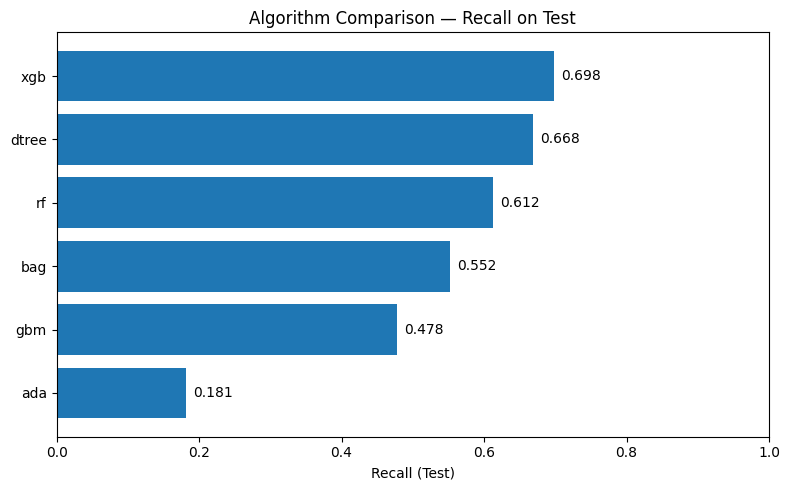

In [ ]:
# Sort by recall (high to low) for a nicer plot
plot_df = results_df_base.sort_values("recall", ascending=True)  # ascending for barh

plt.figure(figsize=(8, 5))
plt.barh(plot_df["model"], plot_df["recall"])
plt.xlabel("Recall (Test)")
plt.title("Algorithm Comparison — Recall on Test")
plt.xlim(0, 1)

# Annotate bars with values
for i, v in enumerate(plot_df["recall"]):
    plt.text(v + 0.01, i, f"{v:.3f}", va="center")

plt.tight_layout()
plt.show()

In [ ]:
%%time

# Models which will run on SCALED data
models_scaled = [
    ("logistic", LogisticRegression(random_state=1, max_iter=1000)),
    ("lda", LinearDiscriminantAnalysis()),
]

print("\nTest Performance (base models; trained on SCALED train):\n")

rows = []
for name, model in models_scaled:
    # fit on SCALED TRAIN set
    model.fit(Xtr_scaled_sklearn, y_train)

    # predict on SCALED TEST set
    y_pred = model.predict(Xte_scaled_sklearn)

    # AUC if proba available (same pattern as oversample block)
    try:
        y_prob = model.predict_proba(Xte_scaled_sklearn)[:, 1]
        roc = roc_auc_score(y_test, y_prob)
    except Exception:
        roc = np.nan

    rec  = recall_score(y_test, y_pred, pos_label=1)
    prec = precision_score(y_test, y_pred, pos_label=1, zero_division=0)
    f1   = f1_score(y_test, y_pred, pos_label=1)

    rows.append({"model": name, "recall": rec, "precision": prec, "f1": f1, "roc_auc": roc})
    print(f"{name}: recall={rec:.4f}, precision={prec:.4f}, f1={f1:.4f}, roc_auc={roc:.4f}")

# Summary table
results_df2 = pd.DataFrame(rows).sort_values("recall", ascending=False).reset_index(drop=True)
print("\nSummary (sorted by recall):\n", results_df2)



Test Performance (base models; trained on SCALED train):

logistic: recall=0.2586, precision=0.6667, f1=0.3727, roc_auc=0.7799
lda: recall=0.2845, precision=0.6346, f1=0.3929, roc_auc=0.7815

Summary (sorted by recall):
       model    recall  precision        f1   roc_auc
0       lda  0.284483   0.634615  0.392857  0.781523
1  logistic  0.258621   0.666667  0.372671  0.779854
CPU times: user 166 ms, sys: 617 µs, total: 166 ms
Wall time: 88.6 ms


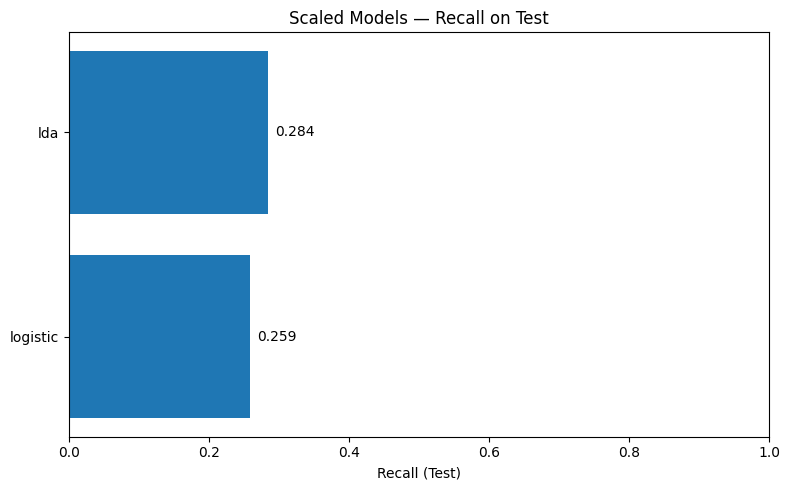

In [ ]:
import matplotlib.pyplot as plt

# Sort by recall (high to low) for a nicer plot
plot_df = results_df2.sort_values("recall", ascending=True)  # ascending for barh

plt.figure(figsize=(8, 5))
plt.barh(plot_df["model"], plot_df["recall"])
plt.xlabel("Recall (Test)")
plt.title("Scaled Models — Recall on Test")
plt.xlim(0, 1)

# Annotate bars with values
for i, v in enumerate(plot_df["recall"]):
    plt.text(min(v + 0.01, 0.995), i, f"{v:.3f}", va="center")

plt.tight_layout()
plt.show()


## **Observations — Base Model Performance (Recall on Test)**

### **Unscaled Models**
- **XGBoost (XGB):** Achieved the highest recall at 0.698, indicating strong performance in capturing defaulters.
- **Decision Tree (DTREE):** Second-best model with a recall of 0.668, close to XGBoost.
- **Random Forest (RF):** Moderate recall at 0.612, performing better than bagging, boosting, and AdaBoost.
- **Bagging (BAG):** Recall of 0.552, lower than individual DTREE and RF models.
- **Gradient Boosting (GBM):** Recall of 0.478, weaker compared to XGB and DTREE.
- **AdaBoost (ADA):** Lowest recall at 0.181, suggesting poor detection of defaulters.

### **Scaled Models**
- **Linear Discriminant Analysis (LDA):** Recall of 0.284, slightly better than Logistic Regression.
- **Logistic Regression (LOGISTIC):** Recall of 0.259, indicating limited predictive power for default detection.

### **Key Insights**
- **Tree-based models** (especially XGB and DTREE) outperform linear models in recall.
- **AdaBoost** performs the worst among all models.
- **Scaling** did not significantly improve recall for linear models.


## Applying AUC-ROC Curves to get the optimal thresholds

###  Decision Tree AUC-ROC

In [ ]:
# Fit on your unscaled, sklearn-cleaned features (no "const")
dt = DecisionTreeClassifier(random_state=1)
dt.fit(Xtr_sklearn, y_train)


# probabilities for class=1
y_prob_tr = dt.predict_proba(Xtr_sklearn)[:, 1]
y_prob_te = dt.predict_proba(Xte_sklearn)[:, 1]


In [ ]:
# --- Threshold selection (pick ONE) ---
# Option A: Train-based F2 (recall-focused)  <-- recommended when FN are costly
prec_tr, rec_tr, thr_pr_tr = precision_recall_curve(y_train, y_prob_tr)
f2_tr = (1+2**2) * (prec_tr[:-1]*rec_tr[:-1]) / (2**2*prec_tr[:-1] + rec_tr[:-1] + 1e-12)
thr_f2 = thr_pr_tr[np.nanargmax(f2_tr)]

In [ ]:
# --- Choose which threshold to use ---
thr = float(thr_f2)   # or: thr = float(thr_roc_j)
thr

1.0

In [ ]:
def print_metrics(split, y_true, y_prob, thr):
    y_pred = (y_prob >= thr).astype(int)
    roc = roc_auc_score(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    rec = recall_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)


    print(f"\n[{split}]  thr={thr:.4f} | ROC-AUC={roc:.4f} | PR-AUC={pr_auc:.4f} "
          f"| Recall={rec:.4f} | Precision={prec:.4f} | F1={f1:.4f} | Acc={acc:.4f}")
    print("Confusion matrix:\n", cm)

In [ ]:
# --- Report ---
print_metrics("TRAIN", y_train, y_prob_tr, thr)
print_metrics("TEST ", y_test,  y_prob_te, thr)


[TRAIN]  thr=1.0000 | ROC-AUC=1.0000 | PR-AUC=1.0000 | Recall=1.0000 | Precision=1.0000 | F1=1.0000 | Acc=1.0000
Confusion matrix:
 [[3738    0]
 [   0  929]]

[TEST ]  thr=1.0000 | ROC-AUC=0.7982 | PR-AUC=0.5324 | Recall=0.6681 | Precision=0.6982 | F1=0.6828 | Acc=0.8766
Confusion matrix:
 [[868  67]
 [ 77 155]]


**Observations**  
The model is overfitting since the recall on the training dataset is 1.0, while the recall on the test dataset drops to 0.6681.


### Random Forest AUC-ROC Curve

In [ ]:
#Fitting the model
rf = RandomForestClassifier(random_state=1, n_jobs=-1)
rf.fit(Xtr_sklearn, y_train)

RandomForestClassifier(n_jobs=-1, random_state=1)

In [ ]:
# --- Probabilities ---
y_prob_tr = rf.predict_proba(Xtr_sklearn)[:, 1]
y_prob_te = rf.predict_proba(Xte_sklearn)[:, 1]

In [ ]:
# --- Threshold selection (pick ONE) ---
# Option A: Train-based F2 (recall-focused)  <-- recommended when FN are costly
prec_tr, rec_tr, thr_pr_tr = precision_recall_curve(y_train, y_prob_tr)
f2_tr = (1+2**2) * (prec_tr[:-1]*rec_tr[:-1]) / (2**2*prec_tr[:-1] + rec_tr[:-1] + 1e-12)
thr_f2 = thr_pr_tr[np.nanargmax(f2_tr)]

In [ ]:
# Option B: ROC-J (Youden's J) on TRAIN
fpr_tr, tpr_tr, thr_roc_tr = roc_curve(y_train, y_prob_tr)
j_tr = tpr_tr - fpr_tr
thr_roc_j = thr_roc_tr[np.argmax(j_tr)]

In [ ]:
thr = float(thr_f2)

In [ ]:
def print_metrics(split, y_true, y_prob, thr):
    y_pred = (y_prob >= thr).astype(int)
    roc = roc_auc_score(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    rec = recall_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)

    print(f"\n[{split}]  thr={thr:.4f} | ROC-AUC={roc:.4f} | PR-AUC={pr_auc:.4f} "
          f"| Recall={rec:.4f} | Precision={prec:.4f} | F1={f1:.4f} | Acc={acc:.4f}")
    print("Confusion matrix:\n", cm)

# --- Report ---
print_metrics("TRAIN", y_train, y_prob_tr, thr)
print_metrics("TEST ", y_test,  y_prob_te, thr)



[TRAIN]  thr=0.5300 | ROC-AUC=1.0000 | PR-AUC=1.0000 | Recall=1.0000 | Precision=1.0000 | F1=1.0000 | Acc=1.0000
Confusion matrix:
 [[3738    0]
 [   0  929]]

[TEST ]  thr=0.5300 | ROC-AUC=0.9695 | PR-AUC=0.9207 | Recall=0.5862 | Precision=0.9927 | F1=0.7371 | Acc=0.9169
Confusion matrix:
 [[934   1]
 [ 96 136]]


**Observations**  
The Random Forest model is also overfitting, with a recall of 1.0 on the training dataset and 0.5862 on the test dataset.


### Bagging AUC-ROC Curve

In [ ]:
#Fitting the model
bag = BaggingClassifier(random_state=1)
bag.fit(Xtr_sklearn, y_train)

BaggingClassifier(random_state=1)

In [ ]:
# --- Probabilities ---
y_prob_tr = bag.predict_proba(Xtr_sklearn)[:, 1]
y_prob_te = bag.predict_proba(Xte_sklearn)[:, 1]

In [ ]:
# --- Threshold selection (pick ONE) ---
# Option A: Train-based F2 (recall-focused)
prec_tr, rec_tr, thr_pr_tr = precision_recall_curve(y_train, y_prob_tr)
f2_tr = (1+2**2) * (prec_tr[:-1]*rec_tr[:-1]) / (2**2*prec_tr[:-1] + rec_tr[:-1] + 1e-12)
thr_f2 = thr_pr_tr[np.nanargmax(f2_tr)]

In [ ]:
# Option B: ROC-J on TRAIN
fpr_tr, tpr_tr, thr_roc_tr = roc_curve(y_train, y_prob_tr)
j_tr = tpr_tr - fpr_tr
thr_roc_j = thr_roc_tr[np.argmax(j_tr)]

In [ ]:
# --- Choose which threshold to use ---
thr = float(thr_f2)

In [ ]:
# --- Report using your existing helper ---
print_metrics("TRAIN", y_train, y_prob_tr, thr)
print_metrics("TEST ", y_test,  y_prob_te, thr)


[TRAIN]  thr=0.4000 | ROC-AUC=0.9999 | PR-AUC=0.9994 | Recall=0.9978 | Precision=0.9841 | F1=0.9909 | Acc=0.9964
Confusion matrix:
 [[3723   15]
 [   2  927]]

[TEST ]  thr=0.4000 | ROC-AUC=0.9248 | PR-AUC=0.7991 | Recall=0.7241 | Precision=0.7029 | F1=0.7134 | Acc=0.8843
Confusion matrix:
 [[864  71]
 [ 64 168]]


**Observations**  
Bagging with optimal thresholds performs better with reduced overfitting compared to other models, but some overfitting is still present.


### Gradient Boost Model AUC-ROC Curve

In [ ]:
# --- Fit on unscaled, sklearn-cleaned features (no "const") ---
gbm = GradientBoostingClassifier(random_state=1)  # only random_state
gbm.fit(Xtr_sklearn, y_train)

GradientBoostingClassifier(random_state=1)

In [ ]:
# --- Probabilities ---
y_prob_tr = gbm.predict_proba(Xtr_sklearn)[:, 1]
y_prob_te = gbm.predict_proba(Xte_sklearn)[:, 1]

In [ ]:
# --- Threshold selection (pick ONE) ---
# Option A: Train-based F2 (recall-focused)
prec_tr, rec_tr, thr_pr_tr = precision_recall_curve(y_train, y_prob_tr)
f2_tr = (1+2**2) * (prec_tr[:-1]*rec_tr[:-1]) / (2**2*prec_tr[:-1] + rec_tr[:-1] + 1e-12)
thr_f2 = thr_pr_tr[np.nanargmax(f2_tr)]

In [ ]:
thr = float(thr_f2)
thr

0.16843425018757968

In [ ]:
# --- Report using your existing helper ---
print_metrics("TRAIN", y_train, y_prob_tr, thr)
print_metrics("TEST ", y_test,  y_prob_te, thr)


[TRAIN]  thr=0.1684 | ROC-AUC=0.9283 | PR-AUC=0.8538 | Recall=0.8676 | Precision=0.5521 | F1=0.6748 | Acc=0.8335
Confusion matrix:
 [[3084  654]
 [ 123  806]]

[TEST ]  thr=0.1684 | ROC-AUC=0.8946 | PR-AUC=0.7917 | Recall=0.8190 | Precision=0.5000 | F1=0.6209 | Acc=0.8012
Confusion matrix:
 [[745 190]
 [ 42 190]]


**Observations**  
The Gradient Boosting model with the optimal threshold is performing well and does not show signs of overfitting.  
- Recall: 0.87 on the training data and 0.82 on the test data  
- Precision: 0.55 on the training data and 0.50 on the test data  

The optimal threshold for this model is 0.168, meaning we predict default when the GBM's probability ≥ 0.168.


### ADABoost AUC-ROC Curve

In [ ]:
# --- Fit on unscaled, sklearn-cleaned features (no "const") ---
ada = AdaBoostClassifier(random_state=1)
ada.fit(Xtr_sklearn, y_train)

AdaBoostClassifier(random_state=1)

In [ ]:

# --- Probabilities ---
y_prob_tr = ada.predict_proba(Xtr_sklearn)[:, 1]
y_prob_te = ada.predict_proba(Xte_sklearn)[:, 1]

In [ ]:
# --- Threshold selection (pick ONE) ---
# Option A: Train-based F2 (recall-focused)
prec_tr, rec_tr, thr_pr_tr = precision_recall_curve(y_train, y_prob_tr)
f2_tr = (1+2**2) * (prec_tr[:-1]*rec_tr[:-1]) / (2**2*prec_tr[:-1] + rec_tr[:-1] + 1e-12)
thr_f2 = thr_pr_tr[np.nanargmax(f2_tr)]

In [ ]:
thr = float(thr_f2)
thr

0.37514240724948955

In [ ]:
# --- Report using your existing helper ---
print_metrics("TRAIN", y_train, y_prob_tr, thr)
print_metrics("TEST ", y_test,  y_prob_te, thr)


[TRAIN]  thr=0.3751 | ROC-AUC=0.7962 | PR-AUC=0.5667 | Recall=0.8385 | Precision=0.3312 | F1=0.4749 | Acc=0.6308
Confusion matrix:
 [[2165 1573]
 [ 150  779]]

[TEST ]  thr=0.3751 | ROC-AUC=0.7902 | PR-AUC=0.5214 | Recall=0.8534 | Precision=0.3133 | F1=0.4583 | Acc=0.5990
Confusion matrix:
 [[501 434]
 [ 34 198]]


**Observations**  
The AdaBoost model with the optimal threshold is performing well and does not show signs of overfitting.  
- Recall: 0.8385 on the training data and 0.8534 on the test data (slightly higher recall on test data)  
- Precision: 0.3312 on the training data and 0.3113 on the test data  

Although AdaBoost achieves higher recall (0.8534) than Gradient Boosting (0.8190), the precision is better for Gradient Boosting (0.500) compared to AdaBoost (0.3133).  
This means AdaBoost reduces false negatives but increases false positives, potentially leading to greater missed business opportunities.  

The optimal threshold for this model is 0.375, meaning we predict default when the model's probability ≥ 0.375.


### XGBoost AUC-ROC Curve

In [ ]:
# --- Fit on unscaled, sklearn-cleaned features (no "const") ---
xgb = XGBClassifier(random_state=1, eval_metric="logloss", n_jobs=-1)
xgb.fit(Xtr_sklearn, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=-1,
              num_parallel_tree=None, ...)

In [ ]:
# --- Probabilities ---
y_prob_tr = xgb.predict_proba(Xtr_sklearn)[:, 1]
y_prob_te = xgb.predict_proba(Xte_sklearn)[:, 1]

In [ ]:
# --- Threshold selection (pick ONE) ---
# Option A: Train-based F2 (recall-focused)
prec_tr, rec_tr, thr_pr_tr = precision_recall_curve(y_train, y_prob_tr)
f2_tr = (1+2**2) * (prec_tr[:-1]*rec_tr[:-1]) / (2**2*prec_tr[:-1] + rec_tr[:-1] + 1e-12)
thr_f2 = thr_pr_tr[np.nanargmax(f2_tr)]

In [ ]:
thr = float(thr_f2)
thr

0.40514153242111206

In [ ]:
# --- Report using your existing helper ---
print_metrics("TRAIN", y_train, y_prob_tr, thr)
print_metrics("TEST ", y_test,  y_prob_te, thr)


[TRAIN]  thr=0.4051 | ROC-AUC=1.0000 | PR-AUC=1.0000 | Recall=1.0000 | Precision=1.0000 | F1=1.0000 | Acc=1.0000
Confusion matrix:
 [[3738    0]
 [   0  929]]

[TEST ]  thr=0.4051 | ROC-AUC=0.9674 | PR-AUC=0.9285 | Recall=0.7371 | Precision=0.9344 | F1=0.8241 | Acc=0.9374
Confusion matrix:
 [[923  12]
 [ 61 171]]


**Observations**  
The XGBoost model is overfitting, even when using the optimal threshold of 0.41.


### AUC-ROC Models and Model Performance

In [ ]:
def best_threshold_f2(y_true, y_prob):
    prec, rec, thr = precision_recall_curve(y_true, y_prob)
    f2 = (1+2**2) * (prec[:-1]*rec[:-1]) / (2**2*prec[:-1] + rec[:-1] + 1e-12)
    return float(thr[np.nanargmax(f2)])

def add_model_row(results, name, model, Xtr, Xte, y_train, y_test, thr=None):
    y_prob_tr = model.predict_proba(Xtr)[:, 1]
    y_prob_te = model.predict_proba(Xte)[:, 1]
    if thr is None:
        thr = best_threshold_f2(y_train, y_prob_tr)   # choose recall-heavy cutoff on TRAIN

    train_pred = (y_prob_tr >= thr).astype(int)
    test_pred  = (y_prob_te >= thr).astype(int)

    results.append({
        "Model": name,
        "Threshold": round(thr, 3),
        "Train Accuracy": accuracy_score(y_train, train_pred),
        "Train Precision": precision_score(y_train, train_pred, zero_division=0),
        "Train Recall": recall_score(y_train, train_pred),
        "Train F1": f1_score(y_train, train_pred),
        "Test Accuracy": accuracy_score(y_test, test_pred),
        "Test Precision": precision_score(y_test, test_pred, zero_division=0),
        "Test Recall": recall_score(y_test, test_pred),
        "Test F1": f1_score(y_test, test_pred),
    })

# ---- Build the table for all models ----
results = []

# Unscaled models (assuming these are already fitted)
add_model_row(results, "Decision Tree",      dt,   Xtr_sklearn, Xte_sklearn, y_train, y_test)
add_model_row(results, "Bagging Classifier", bag,  Xtr_sklearn, Xte_sklearn, y_train, y_test)
add_model_row(results, "Random Forest",      rf,   Xtr_sklearn, Xte_sklearn, y_train, y_test)
add_model_row(results, "AdaBoost",           ada,  Xtr_sklearn, Xte_sklearn, y_train, y_test)
add_model_row(results, "Gradient Boost",     gbm,  Xtr_sklearn, Xte_sklearn, y_train, y_test)
add_model_row(results, "XGBoost",            xgb,  Xtr_sklearn, Xte_sklearn, y_train, y_test)

# To include scaled models (LogReg/LDA), call add_model_row with Xtr_scaled_sklearn/Xte_scaled_sklearn

df_results = pd.DataFrame(results)
# Optional: round for display
df_results_rounded = df_results.copy()
for col in df_results.columns:
    if col not in ["Model", "Threshold"]:
        df_results_rounded[col] = df_results[col].round(3)

print("Train/Test performance (one row per model):")
display(df_results_rounded)


Train/Test performance (one row per model):


,Model,Threshold,Train Accuracy,Train Precision,Train Recall,Train F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,Decision Tree,1.000,1.000,1.000,1.000,1.000,0.877,0.698,0.668,0.683
1,Bagging Classifier,0.400,0.996,0.984,0.998,0.991,0.884,0.703,0.724,0.713
2,Random Forest,0.530,1.000,1.000,1.000,1.000,0.917,0.993,0.586,0.737
3,AdaBoost,0.375,0.631,0.331,0.839,0.475,0.599,0.313,0.853,0.458
4,Gradient Boost,0.168,0.834,0.552,0.868,0.675,0.801,0.500,0.819,0.621
5,XGBoost,0.405,1.000,1.000,1.000,1.000,0.937,0.934,0.737,0.824


**Best Performing Models**

Based on recall and precision performance, the top models are:  
1. AdaBoost  
2. Gradient Boost  
3. Logistic Regression with AUC-ROC Threshold  
4. Linear Discriminant Analysis (LDA) with AUC-ROC Threshold  
5. XGBoost (although it shows signs of overfitting, we will further evaluate it on over-sampling and under-sampling data)

## Over-Sampling and Under-Sampling

In our dataset, most applicants are non-defaulters while fewer are defaulters. This imbalance can cause models to favor predicting “no default,” which increases false negatives (missing true defaults).

**Over-Sampling**  
We add more examples of the minority class (defaulters) by duplicating or generating synthetic cases (e.g., SMOTE).  
This balances the data and helps the model learn patterns of default better.

**Under-Sampling**  
We reduce the majority class (non-defaulters) by randomly removing some records.  
This also balances the classes but at the cost of losing some information.

**Why We Do This**  
Balancing the classes makes the model more sensitive to detecting defaults, which is crucial in loan approvals.  
Missing a true default (false negative) is more costly than flagging a few extra safe borrowers.


### Oversampling of unscaled data

In [ ]:
print("Before Oversampling, counts of Target Variable label '1': {}".format(sum(y_train == 1)))
print("Before Oversampling, counts of Target Variable label '0': {} \n".format(sum(y_train == 0)))

# Synthetic Minority Over Sampling Technique
sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=1)
X_train_over, y_train_over = sm.fit_resample(Xtr_scaled_sklearn, y_train)


print("After Oversampling, counts of Target Variable label '1': {}".format(sum(y_train_over == 1)))
print("After Oversampling, counts of Target Varible label '0': {} \n".format(sum(y_train_over == 0)))


print("After Oversampling, the shape of train_X: {}".format(X_train_over.shape))
print("After Oversampling, the shape of train_y: {} \n".format(y_train_over.shape))

Before Oversampling, counts of Target Variable label '1': 929
Before Oversampling, counts of Target Variable label '0': 3738 

After Oversampling, counts of Target Variable label '1': 3738
After Oversampling, counts of Target Varible label '0': 3738 

After Oversampling, the shape of train_X: (7476, 25)
After Oversampling, the shape of train_y: (7476,) 



In [ ]:
print("Before Undersampling, counts of Target Variable label '1': {}".format(sum(y_train == 1)))
print("Before Undersampling, counts of Target Variable label '0': {} \n".format(sum(y_train == 0)))


# Random undersampler for under sampling the data
rus = RandomUnderSampler(random_state=1, sampling_strategy=1)
X_train_un, y_train_un = rus.fit_resample(Xtr_scaled_sklearn, y_train)


print("After Undersampling, counts of Target Variable label '1': {}".format(sum(y_train_un == 1)))
print("After Undersampling, counts of Target Varible label '0': {} \n".format(sum(y_train_un == 0)))


print("After Undersampling, the shape of train_X: {}".format(X_train_un.shape))
print("After Undersampling, the shape of train_y: {} \n".format(y_train_un.shape))

Before Undersampling, counts of Target Variable label '1': 929
Before Undersampling, counts of Target Variable label '0': 3738 

After Undersampling, counts of Target Variable label '1': 929
After Undersampling, counts of Target Varible label '0': 929 

After Undersampling, the shape of train_X: (1858, 25)
After Undersampling, the shape of train_y: (1858,) 



# Base Models with Oversampling data

#### AdaBoost Oversampled data


Training (oversampled) performance:
   Accuracy    Recall  Precision        F1
0  0.745318  0.696094   0.772107  0.732133
Test performance:
   Accuracy   Recall  Precision       F1
0   0.75407  0.62069   0.419825  0.50087


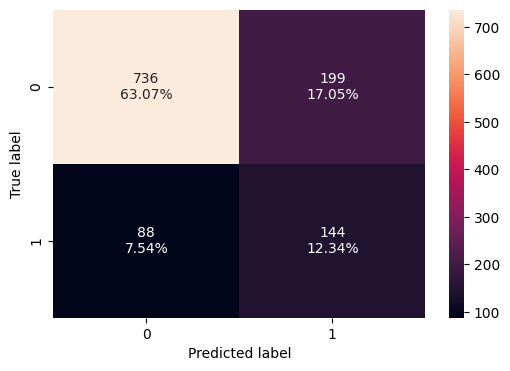

In [ ]:
# Train on oversampled (scaled) train
ada_over = AdaBoostClassifier(random_state=1)
ada_over.fit(X_train_over, y_train_over)

# TRAIN (oversampled) performance
ada_over_train_perf = model_performance_classification_sklearn(
    ada_over, X_train_over, y_train_over
)
print("Training (oversampled) performance:")
print(ada_over_train_perf)

# TEST performance on the original, untouched test set (same scaled space as oversampling)
ada_over_test_perf = model_performance_classification_sklearn(
    ada_over, Xte_scaled_sklearn, y_test   # <-- use your scaled sklearn test matrix
)
print("Test performance:")
print(ada_over_test_perf)

# Confusion matrix on TEST (default threshold unless your function accepts threshold=)
confusion_matrix_sklearn(ada_over, Xte_scaled_sklearn, y_test)


#### AdaBoost Undersampled Data

In [ ]:
# Train on undersampled data
ada_un = AdaBoostClassifier(random_state=1)
ada_un.fit(X_train_un, y_train_un)

AdaBoostClassifier(random_state=1)

Training (undersampled) performance:
   Accuracy    Recall  Precision        F1
0  0.727664  0.639397   0.776471  0.701299
Test performance:
   Accuracy    Recall  Precision        F1
0  0.775493  0.612069   0.452229  0.520147


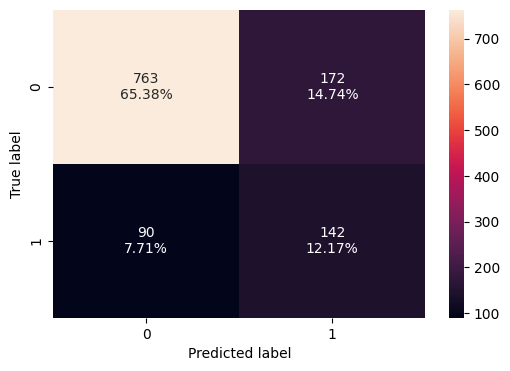

In [ ]:
# Train on undersampled (scaled) train
ada_un = AdaBoostClassifier(random_state=1)
ada_un.fit(X_train_un, y_train_un)

# TRAIN (undersampled) performance
ada_un_train_perf = model_performance_classification_sklearn(
    ada_un, X_train_un, y_train_un
)
print("Training (undersampled) performance:")
print(ada_un_train_perf)

# TEST performance on the original, untouched test set (same scaled space as undersampling)
ada_un_test_perf = model_performance_classification_sklearn(
    ada_un, Xte_scaled_sklearn, y_test
)
print("Test performance:")
print(ada_un_test_perf)

# Confusion matrix on TEST (default threshold unless your function accepts threshold=)
confusion_matrix_sklearn(ada_un, Xte_scaled_sklearn, y_test)



#### ADABoost Oversample AUC-ROC

In [ ]:
# --- Fit on oversampled (scaled) train ---
ada_over_auc = AdaBoostClassifier(random_state=1)
ada_over_auc.fit(X_train_over, y_train_over)

# --- Probabilities on ORIGINAL (unresampled) TRAIN/TEST in the SAME SCALED SPACE ---
y_prob_tr = ada_over_auc.predict_proba(Xtr_scaled_sklearn)[:, 1]
y_prob_te = ada_over_auc.predict_proba(Xte_scaled_sklearn)[:, 1]

# --- Threshold selection (recall-focused F2 on TRAIN) ---
prec_tr, rec_tr, thr_pr_tr = precision_recall_curve(y_train, y_prob_tr)
f2_tr = (1+2**2) * (prec_tr[:-1]*rec_tr[:-1]) / (2**2*prec_tr[:-1] + rec_tr[:-1] + 1e-12)
thr_f2 = thr_pr_tr[np.nanargmax(f2_tr)]
thr = float(thr_f2)

# --- Report using your existing helper ---
print_metrics("TRAIN(orig)", y_train, y_prob_tr, thr)
print_metrics("TEST ",       y_test,  y_prob_te,  thr)



[TRAIN(orig)]  thr=0.4215 | ROC-AUC=0.7752 | PR-AUC=0.5173 | Recall=0.8859 | Precision=0.2912 | F1=0.4383 | Acc=0.5481
Confusion matrix:
 [[1735 2003]
 [ 106  823]]

[TEST ]  thr=0.4215 | ROC-AUC=0.7770 | PR-AUC=0.4723 | Recall=0.9224 | Precision=0.2916 | F1=0.4431 | Acc=0.5390
Confusion matrix:
 [[415 520]
 [ 18 214]]


#### ADABoost Undersample AUC-ROC

In [ ]:
# --- Fit on undersampled (scaled) train ---
ada_un_auc = AdaBoostClassifier(random_state=1)
ada_un_auc.fit(X_train_un, y_train_un)

# --- Probabilities on ORIGINAL (unresampled) TRAIN/TEST in the SAME SCALED SPACE ---
y_prob_tr = ada_un_auc.predict_proba(Xtr_scaled_sklearn)[:, 1]
y_prob_te = ada_un_auc.predict_proba(Xte_scaled_sklearn)[:, 1]

# --- Threshold selection (recall-focused F2 on TRAIN) ---
prec_tr, rec_tr, thr_pr_tr = precision_recall_curve(y_train, y_prob_tr)
f2_tr = (1+2**2) * (prec_tr[:-1]*rec_tr[:-1]) / (2**2*prec_tr[:-1] + rec_tr[:-1] + 1e-12)
thr_f2 = thr_pr_tr[np.nanargmax(f2_tr)]
thr = float(thr_f2)

# --- Report using your existing helper ---
print_metrics("TRAIN(orig)", y_train, y_prob_tr, thr)
print_metrics("TEST ",       y_test,  y_prob_te,  thr)



[TRAIN(orig)]  thr=0.4662 | ROC-AUC=0.7990 | PR-AUC=0.5629 | Recall=0.8418 | Precision=0.3440 | F1=0.4884 | Acc=0.6490
Confusion matrix:
 [[2247 1491]
 [ 147  782]]

[TEST ]  thr=0.4662 | ROC-AUC=0.7891 | PR-AUC=0.5179 | Recall=0.8233 | Precision=0.3183 | F1=0.4591 | Acc=0.6144
Confusion matrix:
 [[526 409]
 [ 41 191]]


### Observations — ADABoost Over-Sampling vs Under-Sampling (Regular & AUC-ROC Models)

### Regular Models
- **Over-Sampling**  
  - Training Data: Recall = 0.696, Precision = 0.772  
  - Test Data: Recall = 0.621, Precision = 0.420  

- **Under-Sampling**  
  - Training Data: Recall = 0.639, Precision = 0.776  
  - Test Data: Recall = 0.612, Precision = 0.452  

### AUC-ROC Models
- **Over-Sampling (Threshold = 0.4215)**  
  - Training Data: Recall = 0.886, Precision = 0.291  
  - Test Data: Recall = 0.922, Precision = 0.292  

- **Under-Sampling (Threshold = 0.4662)**  
  - Training Data: Recall = 0.842, Precision = 0.344  
  - Test Data: Recall = 0.823, Precision = 0.318  

### Key Insights
- Over-sampling gives the highest recall across all methods but at the cost of low precision.  
- Under-sampling improves precision slightly but reduces recall, particularly in the AUC-ROC models.  
- Both approaches show a clear trade-off between catching more defaulters (recall) and minimizing false positives (precision).  


#### GBM Oversample

Training (oversampled) performance:
   Accuracy    Recall  Precision        F1
0  0.874532  0.859016   0.886527  0.872554
Test performance:
   Accuracy  Recall  Precision       F1
0  0.836332    0.75   0.566775  0.64564


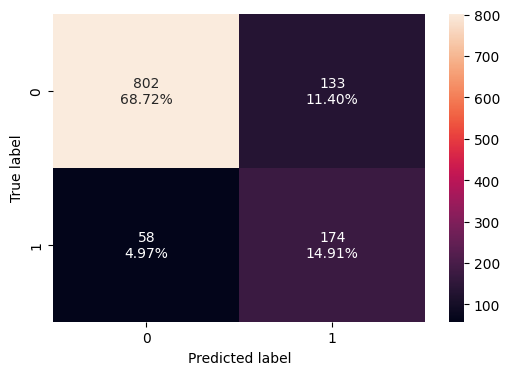

In [ ]:
# Train on oversampled (scaled) train
gbm_over = GradientBoostingClassifier(random_state=1)
gbm_over.fit(X_train_over, y_train_over)

# TRAIN (oversampled) performance
gbm_over_train_perf = model_performance_classification_sklearn(
    gbm_over, X_train_over, y_train_over
)
print("Training (oversampled) performance:")
print(gbm_over_train_perf)

# TEST performance on the original, untouched test set (same scaled space as oversampling)
gbm_over_test_perf = model_performance_classification_sklearn(
    gbm_over, Xte_scaled_sklearn, y_test
)
print("Test performance:")
print(gbm_over_test_perf)

# Confusion matrix on TEST
confusion_matrix_sklearn(gbm_over, Xte_scaled_sklearn, y_test)


#### GBM Undersample

Training (undersampled) performance:
   Accuracy    Recall  Precision        F1
0  0.877826  0.841765   0.907193  0.873255
Test performance:
   Accuracy    Recall  Precision        F1
0  0.829477  0.801724   0.548673  0.651489


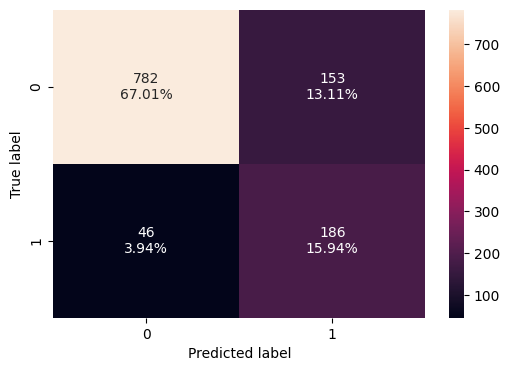

In [ ]:
# Train on undersampled (scaled) train
gbm_un = GradientBoostingClassifier(random_state=1)
gbm_un.fit(X_train_un, y_train_un)

# TRAIN (undersampled) performance
gbm_un_train_perf = model_performance_classification_sklearn(
    gbm_un, X_train_un, y_train_un
)
print("Training (undersampled) performance:")
print(gbm_un_train_perf)

# TEST performance on the original, untouched test set (same scaled space as undersampling)
gbm_un_test_perf = model_performance_classification_sklearn(
    gbm_un, Xte_scaled_sklearn, y_test
)
print("Test performance:")
print(gbm_un_test_perf)

# Confusion matrix on TEST
confusion_matrix_sklearn(gbm_un, Xte_scaled_sklearn, y_test)


#### GBM Oversample AUC-ROC

In [ ]:
# --- Fit on oversampled (scaled) train ---
gbm_over_auc = GradientBoostingClassifier(random_state=1)
gbm_over_auc.fit(X_train_over, y_train_over)

# --- Probabilities on ORIGINAL (unresampled) TRAIN/TEST in the SAME SCALED SPACE ---
y_prob_tr = gbm_over_auc.predict_proba(Xtr_scaled_sklearn)[:, 1]
y_prob_te = gbm_over_auc.predict_proba(Xte_scaled_sklearn)[:, 1]

# --- Threshold selection (recall-focused F2 on TRAIN) ---
prec_tr, rec_tr, thr_pr_tr = precision_recall_curve(y_train, y_prob_tr)
f2_tr = (1+2**2) * (prec_tr[:-1]*rec_tr[:-1]) / (2**2*prec_tr[:-1] + rec_tr[:-1] + 1e-12)
thr_f2 = thr_pr_tr[np.nanargmax(f2_tr)]
thr = float(thr_f2)

# --- Report using your existing helper ---
print_metrics("TRAIN(orig)", y_train, y_prob_tr, thr)
print_metrics("TEST ",       y_test,  y_prob_te,  thr)



[TRAIN(orig)]  thr=0.3856 | ROC-AUC=0.9098 | PR-AUC=0.7883 | Recall=0.8590 | Precision=0.5000 | F1=0.6321 | Acc=0.8009
Confusion matrix:
 [[2940  798]
 [ 131  798]]

[TEST ]  thr=0.3856 | ROC-AUC=0.8839 | PR-AUC=0.7288 | Recall=0.8491 | Precision=0.4487 | F1=0.5872 | Acc=0.7626
Confusion matrix:
 [[693 242]
 [ 35 197]]


#### GBM Undersample AUC-ROC

In [ ]:
# --- Fit on undersampled (scaled) train ---
gbm_un_auc = GradientBoostingClassifier(random_state=1)
gbm_un_auc.fit(X_train_un, y_train_un)

# --- Probabilities on ORIGINAL (unresampled) TRAIN/TEST in the SAME SCALED SPACE ---
y_prob_tr = gbm_un_auc.predict_proba(Xtr_scaled_sklearn)[:, 1]
y_prob_te = gbm_un_auc.predict_proba(Xte_scaled_sklearn)[:, 1]

# --- Threshold selection (recall-focused F2 on TRAIN) ---
prec_tr, rec_tr, thr_pr_tr = precision_recall_curve(y_train, y_prob_tr)
f2_tr = (1+2**2) * (prec_tr[:-1]*rec_tr[:-1]) / (2**2*prec_tr[:-1] + rec_tr[:-1] + 1e-12)
thr_f2 = thr_pr_tr[np.nanargmax(f2_tr)]
thr = float(thr_f2)

# --- Report using your existing helper ---
print_metrics("TRAIN(orig)", y_train, y_prob_tr, thr)
print_metrics("TEST ",       y_test,  y_prob_te,  thr)



[TRAIN(orig)]  thr=0.4395 | ROC-AUC=0.9253 | PR-AUC=0.7938 | Recall=0.9053 | Precision=0.5204 | F1=0.6609 | Acc=0.8151
Confusion matrix:
 [[2963  775]
 [  88  841]]

[TEST ]  thr=0.4395 | ROC-AUC=0.8974 | PR-AUC=0.7451 | Recall=0.8534 | Precision=0.4818 | F1=0.6159 | Acc=0.7883
Confusion matrix:
 [[722 213]
 [ 34 198]]


## Observations — Gradient Boosting Model (GBM)

### Over-Sampling
- Training Data: Recall = 0.859, Precision = 0.887  
- Test Data: Recall = 0.750, Precision = 0.567  

### Under-Sampling
- Training Data: Recall = 0.842, Precision = 0.907  
- Test Data: Recall = 0.802, Precision = 0.549  

### Over-Sampling with AUC-ROC (Threshold = 0.3856)
- Training Data: Recall = 0.859, Precision = 0.500  
- Test Data: Recall = 0.849, Precision = 0.449  

### Under-Sampling with AUC-ROC (Threshold = 0.4395)
- Training Data: Recall = 0.905, Precision = 0.520  
- Test Data: Recall = 0.853, Precision = 0.482  

### Key Insights
- Under-sampling with AUC-ROC achieves the **highest recall** on both training (0.905) and test data (0.853) but with lower precision than regular sampling methods.  
- Regular over- and under-sampling methods yield **higher precision** (up to 0.907) but at the cost of reduced recall, especially on the test set.  
- There is a **clear trade-off**: higher recall comes with lower precision, increasing false positives, while higher precision reduces recall, risking missed defaults.


#### XGBoost Oversample

Training (oversampled) performance:
   Accuracy   Recall  Precision        F1
0  0.999465  0.99893        1.0  0.999465
Test performance:
   Accuracy    Recall  Precision        F1
0  0.942588  0.806034   0.894737  0.848073


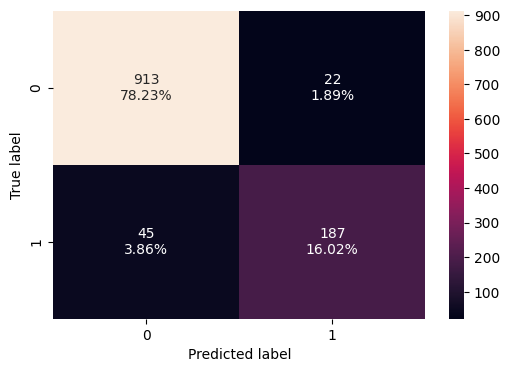

In [ ]:
from xgboost import XGBClassifier

# Train on oversampled (scaled) train
xgb_over = XGBClassifier(random_state=1, eval_metric="logloss", n_jobs=-1)
xgb_over.fit(X_train_over, y_train_over)

# TRAIN (oversampled) performance
xgb_over_train_perf = model_performance_classification_sklearn(
    xgb_over, X_train_over, y_train_over
)
print("Training (oversampled) performance:")
print(xgb_over_train_perf)

# TEST performance on the original, untouched test set (same scaled space as oversampling)
xgb_over_test_perf = model_performance_classification_sklearn(
    xgb_over, Xte_scaled_sklearn, y_test
)
print("Test performance:")
print(xgb_over_test_perf)

# Confusion matrix on TEST
confusion_matrix_sklearn(xgb_over, Xte_scaled_sklearn, y_test)


#### XGBoost Undersample

Training (undersampled) performance:
   Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0
Test performance:
   Accuracy    Recall  Precision        F1
0  0.862896  0.866379   0.609091  0.715302


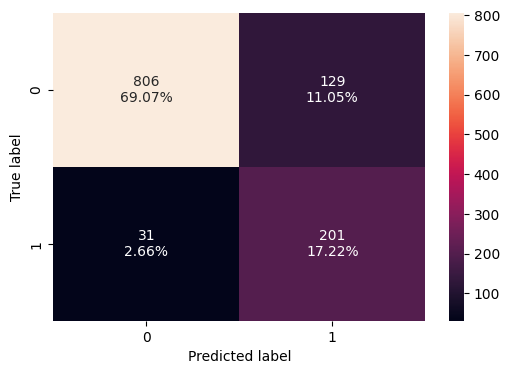

In [ ]:
# Train on undersampled (scaled) train
xgb_un = XGBClassifier(random_state=1, eval_metric="logloss", n_jobs=-1)
xgb_un.fit(X_train_un, y_train_un)

# TRAIN (undersampled) performance
xgb_un_train_perf = model_performance_classification_sklearn(
    xgb_un, X_train_un, y_train_un
)
print("Training (undersampled) performance:")
print(xgb_un_train_perf)

# TEST performance on the original, untouched test set (same scaled space as undersampling)
xgb_un_test_perf = model_performance_classification_sklearn(
    xgb_un, Xte_scaled_sklearn, y_test
)
print("Test performance:")
print(xgb_un_test_perf)

# Confusion matrix on TEST
confusion_matrix_sklearn(xgb_un, Xte_scaled_sklearn, y_test)


#### XGBoost Oversample AUC-ROC

In [ ]:
# --- Fit on oversampled (scaled) train ---
xgb_over_auc = XGBClassifier(random_state=1, eval_metric="logloss", n_jobs=-1)
xgb_over_auc.fit(X_train_over, y_train_over)

# --- Probabilities on ORIGINAL (unresampled) TRAIN/TEST in the SAME SCALED SPACE ---
y_prob_tr = xgb_over_auc.predict_proba(Xtr_scaled_sklearn)[:, 1]
y_prob_te = xgb_over_auc.predict_proba(Xte_scaled_sklearn)[:, 1]

# --- Threshold selection (recall-focused F2 on TRAIN) ---
prec_tr, rec_tr, thr_pr_tr = precision_recall_curve(y_train, y_prob_tr)
f2_tr = (1+2**2) * (prec_tr[:-1]*rec_tr[:-1]) / (2**2*prec_tr[:-1] + rec_tr[:-1] + 1e-12)
thr_f2 = thr_pr_tr[np.nanargmax(f2_tr)]
thr = float(thr_f2)

# --- Report using your existing helper ---
print_metrics("TRAIN(orig)", y_train, y_prob_tr, thr)
print_metrics("TEST ",       y_test,  y_prob_te,  thr)



[TRAIN(orig)]  thr=0.3813 | ROC-AUC=1.0000 | PR-AUC=1.0000 | Recall=1.0000 | Precision=0.9979 | F1=0.9989 | Acc=0.9996
Confusion matrix:
 [[3736    2]
 [   0  929]]

[TEST ]  thr=0.3813 | ROC-AUC=0.9588 | PR-AUC=0.9017 | Recall=0.8448 | Precision=0.8448 | F1=0.8448 | Acc=0.9383
Confusion matrix:
 [[899  36]
 [ 36 196]]


#### XGBoost Undersample AUC-ROC

In [ ]:
# --- Fit on undersampled (scaled) train ---
xgb_un_auc = XGBClassifier(random_state=1, eval_metric="logloss", n_jobs=-1)
xgb_un_auc.fit(X_train_un, y_train_un)

# --- Probabilities on ORIGINAL (unresampled) TRAIN/TEST in the SAME SCALED SPACE ---
y_prob_tr = xgb_un_auc.predict_proba(Xtr_scaled_sklearn)[:, 1]
y_prob_te = xgb_un_auc.predict_proba(Xte_scaled_sklearn)[:, 1]

# --- Threshold selection (recall-focused F2 on TRAIN) ---
prec_tr, rec_tr, thr_pr_tr = precision_recall_curve(y_train, y_prob_tr)
f2_tr = (1+2**2) * (prec_tr[:-1]*rec_tr[:-1]) / (2**2*prec_tr[:-1] + rec_tr[:-1] + 1e-12)
thr_f2 = thr_pr_tr[np.nanargmax(f2_tr)]
thr = float(thr_f2)

# --- Report using your existing helper ---
print_metrics("TRAIN(orig)", y_train, y_prob_tr, thr)
print_metrics("TEST ",       y_test,  y_prob_te,  thr)



[TRAIN(orig)]  thr=0.7443 | ROC-AUC=0.9884 | PR-AUC=0.9340 | Recall=0.9978 | Precision=0.8314 | F1=0.9070 | Acc=0.9593
Confusion matrix:
 [[3550  188]
 [   2  927]]

[TEST ]  thr=0.7443 | ROC-AUC=0.9352 | PR-AUC=0.8150 | Recall=0.7672 | Precision=0.7417 | F1=0.7542 | Acc=0.9006
Confusion matrix:
 [[873  62]
 [ 54 178]]


## Observations — XGBoost Model

### Over-Sampling
- Training Data: Recall = 0.999, Precision = 1.000  
- Test Data: Recall = 0.806, Precision = 0.895  

### Under-Sampling
- Training Data: Recall = 1.000, Precision = 1.000  
- Test Data: Recall = 0.866, Precision = 0.609  

### Over-Sampling with AUC-ROC (Threshold = 0.3813)
- Training Data: Recall = 1.000, Precision = 0.998  
- Test Data: Recall = 0.845, Precision = 0.845  

### Under-Sampling with AUC-ROC (Threshold = 0.7443)
- Training Data: Recall = 0.998, Precision = 0.831  
- Test Data: Recall = 0.767, Precision = 0.742  

### Key Insights
- Over-sampling and under-sampling methods show **perfect or near-perfect recall and precision** on the training data, indicating **overfitting**.  
- Over-sampling with AUC-ROC provides the **best balance** on the test set (Recall = 0.845, Precision = 0.845).  
- Under-sampling with AUC-ROC yields **lower recall and precision** on the test set compared to over-sampling.  
- Standard under-sampling gives the **highest recall** on the test set (0.866) but with a significant **drop in precision** (0.609), increasing false positives.


#### Logistic Regression Oversample

Training (oversampled) performance:
   Accuracy    Recall  Precision        F1
0  0.730203  0.700642   0.744669  0.721985
Test performance:
   Accuracy   Recall  Precision        F1
0  0.732648  0.62931   0.392473  0.483444


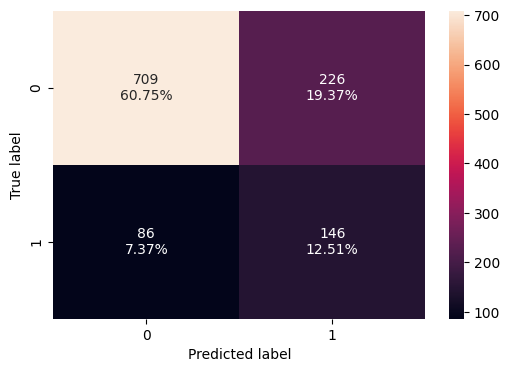

In [ ]:
from sklearn.linear_model import LogisticRegression

# Train on oversampled (scaled) train
lr_over = LogisticRegression(random_state=1, max_iter=1000)
lr_over.fit(X_train_over, y_train_over)

# TRAIN (oversampled) performance
lr_over_train_perf = model_performance_classification_sklearn(
    lr_over, X_train_over, y_train_over
)
print("Training (oversampled) performance:")
print(lr_over_train_perf)

# TEST performance on the original, untouched test set (same scaled space as oversampling)
lr_over_test_perf = model_performance_classification_sklearn(
    lr_over, Xte_scaled_sklearn, y_test
)
print("Test performance:")
print(lr_over_test_perf)

# Confusion matrix on TEST
confusion_matrix_sklearn(lr_over, Xte_scaled_sklearn, y_test)


#### Logistic Regression Undersample

Training (undersampled) performance:
   Accuracy    Recall  Precision        F1
0  0.712056  0.652314   0.740831  0.693761
Test performance:
   Accuracy    Recall  Precision        F1
0  0.752356  0.706897   0.425974  0.531605


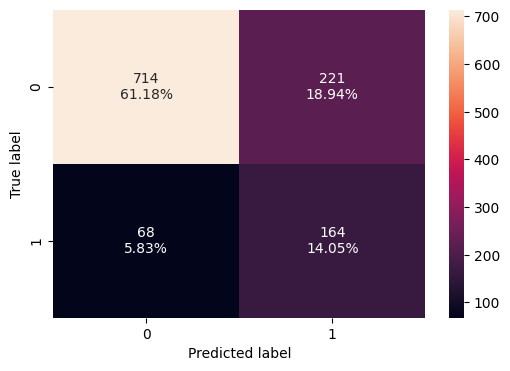

In [ ]:
# Train on undersampled (scaled) train
lr_un = LogisticRegression(random_state=1, max_iter=1000)
lr_un.fit(X_train_un, y_train_un)

# TRAIN (undersampled) performance
lr_un_train_perf = model_performance_classification_sklearn(
    lr_un, X_train_un, y_train_un
)
print("Training (undersampled) performance:")
print(lr_un_train_perf)

# TEST performance on the original, untouched test set (same scaled space as undersampling)
lr_un_test_perf = model_performance_classification_sklearn(
    lr_un, Xte_scaled_sklearn, y_test
)
print("Test performance:")
print(lr_un_test_perf)

# Confusion matrix on TEST
confusion_matrix_sklearn(lr_un, Xte_scaled_sklearn, y_test)


#### Logistic Regression Oversample AUC-ROC

In [ ]:
# --- Fit on oversampled (scaled) train ---
lr_over_auc = LogisticRegression(random_state=1, max_iter=1000)
lr_over_auc.fit(X_train_over, y_train_over)

# --- Probabilities on ORIGINAL (unresampled) TRAIN/TEST in the SAME SCALED SPACE ---
y_prob_tr = lr_over_auc.predict_proba(Xtr_scaled_sklearn)[:, 1]
y_prob_te = lr_over_auc.predict_proba(Xte_scaled_sklearn)[:, 1]

# --- Threshold selection (recall-focused F2 on TRAIN) ---
prec_tr, rec_tr, thr_pr_tr = precision_recall_curve(y_train, y_prob_tr)
f2_tr = (1+2**2) * (prec_tr[:-1]*rec_tr[:-1]) / (2**2*prec_tr[:-1] + rec_tr[:-1] + 1e-12)
thr_f2 = thr_pr_tr[np.nanargmax(f2_tr)]
thr = float(thr_f2)

# --- Report using your existing helper ---
print_metrics("TRAIN(orig)", y_train, y_prob_tr, thr)
print_metrics("TEST ",       y_test,  y_prob_te,  thr)



[TRAIN(orig)]  thr=0.2757 | ROC-AUC=0.7597 | PR-AUC=0.5070 | Recall=0.8751 | Precision=0.2855 | F1=0.4305 | Acc=0.5391
Confusion matrix:
 [[1703 2035]
 [ 116  813]]

[TEST ]  thr=0.2757 | ROC-AUC=0.7677 | PR-AUC=0.4860 | Recall=0.8707 | Precision=0.2853 | F1=0.4298 | Acc=0.5407
Confusion matrix:
 [[429 506]
 [ 30 202]]


#### Logistic Regression Undersample AUC-ROC

In [ ]:
# --- Fit on undersampled (scaled) train ---
lr_un_auc = LogisticRegression(random_state=1, max_iter=1000)
lr_un_auc.fit(X_train_un, y_train_un)

# --- Probabilities on ORIGINAL (unresampled) TRAIN/TEST in the SAME SCALED SPACE ---
y_prob_tr = lr_un_auc.predict_proba(Xtr_scaled_sklearn)[:, 1]
y_prob_te = lr_un_auc.predict_proba(Xte_scaled_sklearn)[:, 1]

# --- Threshold selection (recall-focused F2 on TRAIN) ---
prec_tr, rec_tr, thr_pr_tr = precision_recall_curve(y_train, y_prob_tr)
f2_tr = (1+2**2) * (prec_tr[:-1]*rec_tr[:-1]) / (2**2*prec_tr[:-1] + rec_tr[:-1] + 1e-12)
thr_f2 = thr_pr_tr[np.nanargmax(f2_tr)]
thr = float(thr_f2)

# --- Report using your existing helper ---
print_metrics("TRAIN(orig)", y_train, y_prob_tr, thr)
print_metrics("TEST ",       y_test,  y_prob_te,  thr)



[TRAIN(orig)]  thr=0.3494 | ROC-AUC=0.7806 | PR-AUC=0.5433 | Recall=0.8536 | Precision=0.3049 | F1=0.4493 | Acc=0.5835
Confusion matrix:
 [[1930 1808]
 [ 136  793]]

[TEST ]  thr=0.3494 | ROC-AUC=0.7841 | PR-AUC=0.5248 | Recall=0.8707 | Precision=0.3038 | F1=0.4504 | Acc=0.5775
Confusion matrix:
 [[472 463]
 [ 30 202]]


## Observations — Logistic Regression Model

### Over-Sampling
- Training Data: Recall = 0.701, Precision = 0.745  
- Test Data: Recall = 0.629, Precision = 0.392  

### Under-Sampling
- Training Data: Recall = 0.652, Precision = 0.741  
- Test Data: Recall = 0.707, Precision = 0.426  

### Over-Sampling with AUC-ROC (Threshold = 0.2757)
- Training Data: Recall = 0.875, Precision = 0.286  
- Test Data: Recall = 0.871, Precision = 0.285  

### Under-Sampling with AUC-ROC (Threshold = 0.3494)
- Training Data: Recall = 0.854, Precision = 0.305  
- Test Data: Recall = 0.871, Precision = 0.304  

### Key Insights
- AUC-ROC methods achieve the **highest recall** (up to 0.871 on test data) but with **very low precision** (≈ 0.285–0.305), leading to more false positives.  
- Regular under-sampling strikes a **better balance** with moderate recall (0.707) and improved precision (0.426) compared to over-sampling.  
- Regular over-sampling yields **higher recall** than under-sampling but at the cost of even lower precision.


#### LDA Oversample

Training (oversampled) performance:
   Accuracy    Recall  Precision        F1
0  0.730471  0.695827   0.747629  0.720798
Test performance:
   Accuracy    Recall  Precision        F1
0  0.733505  0.616379   0.391781  0.479062


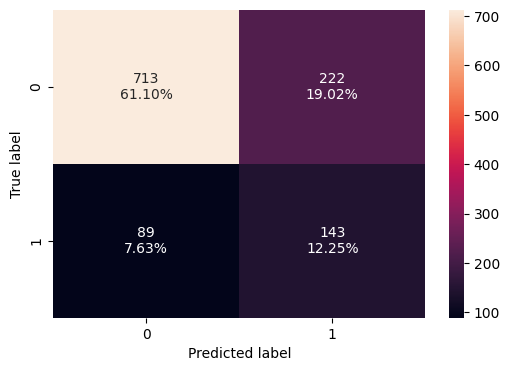

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Train on oversampled (scaled) train
lda_over = LinearDiscriminantAnalysis()
lda_over.fit(X_train_over, y_train_over)

# TRAIN (oversampled) performance
lda_over_train_perf = model_performance_classification_sklearn(
    lda_over, X_train_over, y_train_over
)
print("Training (oversampled) performance:")
print(lda_over_train_perf)

# TEST performance on the original, untouched test set (same scaled space as oversampling)
lda_over_test_perf = model_performance_classification_sklearn(
    lda_over, Xte_scaled_sklearn, y_test
)
print("Test performance:")
print(lda_over_test_perf)

# Confusion matrix on TEST
confusion_matrix_sklearn(lda_over, Xte_scaled_sklearn, y_test)


#### LDA Undersample

Training (undersampled) performance:
   Accuracy   Recall  Precision        F1
0  0.707212  0.64155   0.738538  0.686636
Test performance:
   Accuracy    Recall  Precision        F1
0  0.756641  0.689655   0.430108  0.529801


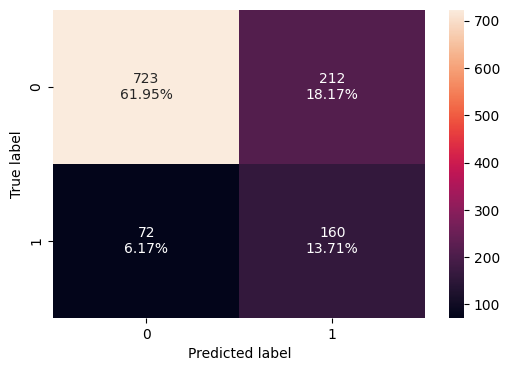

In [ ]:
# Train on undersampled (scaled) train
lda_un = LinearDiscriminantAnalysis()
lda_un.fit(X_train_un, y_train_un)

# TRAIN (undersampled) performance
lda_un_train_perf = model_performance_classification_sklearn(
    lda_un, X_train_un, y_train_un
)
print("Training (undersampled) performance:")
print(lda_un_train_perf)

# TEST performance on the original, untouched test set (same scaled space as undersampling)
lda_un_test_perf = model_performance_classification_sklearn(
    lda_un, Xte_scaled_sklearn, y_test
)
print("Test performance:")
print(lda_un_test_perf)

# Confusion matrix on TEST
confusion_matrix_sklearn(lda_un, Xte_scaled_sklearn, y_test)


#### LDA Oversample AUC-ROC

In [ ]:
# --- Fit on oversampled (scaled) train ---
lda_over_auc = LinearDiscriminantAnalysis()
lda_over_auc.fit(X_train_over, y_train_over)

# --- Probabilities on ORIGINAL (unresampled) TRAIN/TEST in the SAME SCALED SPACE ---
y_prob_tr = lda_over_auc.predict_proba(Xtr_scaled_sklearn)[:, 1]
y_prob_te = lda_over_auc.predict_proba(Xte_scaled_sklearn)[:, 1]

# --- Threshold selection (recall-focused F2 on TRAIN) ---
prec_tr, rec_tr, thr_pr_tr = precision_recall_curve(y_train, y_prob_tr)
f2_tr = (1+2**2) * (prec_tr[:-1]*rec_tr[:-1]) / (2**2*prec_tr[:-1] + rec_tr[:-1] + 1e-12)
thr_f2 = thr_pr_tr[np.nanargmax(f2_tr)]
thr = float(thr_f2)

# --- Report using your existing helper ---
print_metrics("TRAIN(orig)", y_train, y_prob_tr, thr)
print_metrics("TEST ",       y_test,  y_prob_te,  thr)



[TRAIN(orig)]  thr=0.2681 | ROC-AUC=0.7537 | PR-AUC=0.4792 | Recall=0.8762 | Precision=0.2843 | F1=0.4293 | Acc=0.5363
Confusion matrix:
 [[1689 2049]
 [ 115  814]]

[TEST ]  thr=0.2681 | ROC-AUC=0.7607 | PR-AUC=0.4508 | Recall=0.8621 | Precision=0.2841 | F1=0.4274 | Acc=0.5407
Confusion matrix:
 [[431 504]
 [ 32 200]]


#### LDA Undersample AUC-ROC

In [ ]:
# --- Fit on undersampled (scaled) train ---
lda_un_auc = LinearDiscriminantAnalysis()
lda_un_auc.fit(X_train_un, y_train_un)

# --- Probabilities on ORIGINAL (unresampled) TRAIN/TEST in the SAME SCALED SPACE ---
y_prob_tr = lda_un_auc.predict_proba(Xtr_scaled_sklearn)[:, 1]
y_prob_te = lda_un_auc.predict_proba(Xte_scaled_sklearn)[:, 1]

# --- Threshold selection (recall-focused F2 on TRAIN) ---
prec_tr, rec_tr, thr_pr_tr = precision_recall_curve(y_train, y_prob_tr)
f2_tr = (1+2**2) * (prec_tr[:-1]*rec_tr[:-1]) / (2**2*prec_tr[:-1] + rec_tr[:-1] + 1e-12)
thr_f2 = thr_pr_tr[np.nanargmax(f2_tr)]
thr = float(thr_f2)

# --- Report using your existing helper ---
print_metrics("TRAIN(orig)", y_train, y_prob_tr, thr)
print_metrics("TEST ",       y_test,  y_prob_te,  thr)



[TRAIN(orig)]  thr=0.3409 | ROC-AUC=0.7786 | PR-AUC=0.5321 | Recall=0.8665 | Precision=0.3000 | F1=0.4457 | Acc=0.5710
Confusion matrix:
 [[1860 1878]
 [ 124  805]]

[TEST ]  thr=0.3409 | ROC-AUC=0.7828 | PR-AUC=0.5055 | Recall=0.8836 | Precision=0.3015 | F1=0.4496 | Acc=0.5698
Confusion matrix:
 [[460 475]
 [ 27 205]]


## Observations — Linear Discriminant Analysis (LDA) Model

### Over-Sampling
- Training Data: Recall = 0.696, Precision = 0.748  
- Test Data: Recall = 0.616, Precision = 0.392  

### Under-Sampling
- Training Data: Recall = 0.642, Precision = 0.739  
- Test Data: Recall = 0.690, Precision = 0.430  

### Over-Sampling with AUC-ROC (Threshold = 0.2681)
- Training Data: Recall = 0.876, Precision = 0.284  
- Test Data: Recall = 0.862, Precision = 0.284  

### Under-Sampling with AUC-ROC (Threshold = 0.3409)
- Training Data: Recall = 0.867, Precision = 0.300  
- Test Data: Recall = 0.884, Precision = 0.302  

### Key Insights
- AUC-ROC methods provide the **highest recall** (up to 0.884 on test data) but with **very low precision** (≈ 0.284–0.302), leading to many false positives.  
- Regular under-sampling gives a **better balance** between recall (0.690) and precision (0.430) compared to over-sampling.  
- Over-sampling improves recall slightly but significantly reduces precision on the test set.


### Model Performance of Oversampling and Undersampling Data

In [ ]:
# ============================
# Build & display model table with custom thresholds for *_auc
# (sorted by Test Recall, descending)
# ============================

# --- 1) Helper: add a row to results (works for sklearn & statsmodels) ---
def add_model_row(results, name, model, X_train, X_test, y_train, y_test, threshold=None):
    """If model has predict_proba, apply `threshold` (default 0.5). Else use predict()."""
    if hasattr(model, "predict_proba"):
        p_tr = model.predict_proba(X_train)[:, 1]
        p_te = model.predict_proba(X_test)[:, 1]
        thr = 0.5 if threshold is None else float(threshold)
        yhat_tr = (p_tr >= thr).astype(int)
        yhat_te = (p_te >= thr).astype(int)
    else:
        thr = np.nan  # threshold doesn't apply
        yhat_tr = model.predict(X_train)
        yhat_te = model.predict(X_test)

    results.append({
        "Model": name,
        "Threshold": thr,
        "Train Accuracy": accuracy_score(y_train, yhat_tr),
        "Train Precision": precision_score(y_train, yhat_tr, zero_division=0),
        "Train Recall": recall_score(y_train, yhat_tr, zero_division=0),
        "Train F1": f1_score(y_train, yhat_tr, zero_division=0),
        "Test Accuracy": accuracy_score(y_test, yhat_te),
        "Test Precision": precision_score(y_test, yhat_te, zero_division=0),
        "Test Recall": recall_score(y_test, yhat_te, zero_division=0),
        "Test F1": f1_score(y_test, yhat_te, zero_division=0),
    })

# --- 2) Helper: F2-optimal threshold from probabilities (scalar) ---
def f2_opt_threshold(y_true, y_prob):
    prec, rec, thr = precision_recall_curve(y_true, y_prob)
    f2 = (1 + 2**2) * (prec[:-1] * rec[:-1]) / (2**2 * prec[:-1] + rec[:-1] + 1e-12)
    return float(thr[int(np.nanargmax(f2))]) if len(thr) else 0.5

# --- 3) (Re)build all_models from whatever is defined in globals() ---
all_models = []
def _maybe_add(name, varname):
    if varname in globals():
        all_models.append((name, globals()[varname]))

for name, var in [
    ("AdaBoost (over)",  "ada_over"),
    ("GBM (over)",       "gbm_over"),
    ("XGBoost (over)",   "xgb_over"),
    ("LogReg (over)",    "lr_over"),
    ("LDA (over)",       "lda_over"),

    ("AdaBoost (under)", "ada_un"),
    ("GBM (under)",      "gbm_un"),
    ("XGBoost (under)",  "xgb_un"),
    ("LogReg (under)",   "lr_un"),
    ("LDA (under)",      "lda_un"),

    ("AdaBoost (over_auc)",  "ada_over_auc"),
    ("GBM (over_auc)",       "gbm_over_auc"),
    ("XGBoost (over_auc)",   "xgb_over_auc"),
    ("LogReg (over_auc)",    "lr_over_auc"),
    ("LDA (over_auc)",       "lda_over_auc"),

    ("AdaBoost (under_auc)", "ada_un_auc"),
    ("GBM (under_auc)",      "gbm_un_auc"),
    ("XGBoost (under_auc)",  "xgb_un_auc"),
    ("LogReg (under_auc)",   "lr_un_auc"),
    ("LDA (under_auc)",      "lda_un_auc"),
]:
    _maybe_add(name, var)

# --- 4) Compute tuned thresholds for *_auc rows on ORIGINAL TRAIN (scaled space) ---
threshold_map = {}
for name, model in all_models:
    if "_auc" in name and hasattr(model, "predict_proba"):
        y_prob_tr = model.predict_proba(Xtr_scaled_sklearn)[:, 1]
        threshold_map[name] = f2_opt_threshold(y_train, y_prob_tr)

# --- 5) Build results using tuned thresholds for *_auc, else 0.5 ---
results = []
for name, model in all_models:
    add_model_row(
        results, name, model,
        Xtr_scaled_sklearn, Xte_scaled_sklearn, y_train, y_test,
        threshold=threshold_map.get(name, 0.5)
    )

# --- 6) Round, sort by Test Recall (desc), display ---
df_results = pd.DataFrame(results)
df_results_rounded = df_results.copy()
for c in df_results_rounded.columns:
    if c not in ["Model", "Threshold"]:
        df_results_rounded[c] = pd.to_numeric(df_results_rounded[c], errors="coerce").round(3)

df_sorted = df_results_rounded.sort_values(by="Test Recall", ascending=False, na_position="last")\
                              .reset_index(drop=True)

print("Train/Test performance (sorted by Test Recall, descending):")
try:
    display(df_sorted)
except NameError:
    print(df_sorted)


Train/Test performance (sorted by Test Recall, descending):


,Model,Threshold,Train Accuracy,Train Precision,Train Recall,Train F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,AdaBoost (over_auc),0.421505,0.548,0.291,0.886,0.438,0.539,0.292,0.922,0.443
1,LDA (under_auc),0.340880,0.571,0.300,0.867,0.446,0.570,0.301,0.884,0.450
2,LogReg (under_auc),0.349390,0.583,0.305,0.854,0.449,0.578,0.304,0.871,0.450
3,LogReg (over_auc),0.275711,0.539,0.285,0.875,0.431,0.541,0.285,0.871,0.430
4,XGBoost (under),0.500000,0.927,0.732,1.000,0.845,0.863,0.609,0.866,0.715
5,LDA (over_auc),0.268098,0.536,0.284,0.876,0.429,0.541,0.284,0.862,0.427
6,GBM (under_auc),0.439519,0.815,0.520,0.905,0.661,0.788,0.482,0.853,0.616
7,GBM (over_auc),0.385633,0.801,0.500,0.859,0.632,0.763,0.449,0.849,0.587
8,XGBoost (over_auc),0.381298,1.000,0.998,1.000,0.999,0.938,0.845,0.845,0.845
9,AdaBoost (under_auc),0.466190,0.649,0.344,0.842,0.488,0.614,0.318,0.823,0.459


####Interpreting the base-model results

**Recall vs. Precision trade-off.**
The very top of the table is dominated by _auc variants (e.g., AdaBoost (over_auc) with Recall 0.922 but Precision 0.292). That means these models catch almost all defaulters but flag many non-defaulters too (higher false positives).

**Sampling effects.**

Oversampled + _auc tends to maximize Recall but at the cost of Precision (e.g., AdaBoost (over_auc): 0.922 / 0.292).

Undersampled + _auc (e.g., LogReg (under_auc) 0.871 / 0.304 and LDA (under_auc) 0.884 / 0.301) gives similarly high Recall with slightly better calibration and simpler behavior.

Undersampled (default 0.5) models like XGBoost (under) show a much better balance (Recall 0.866 with Precision 0.609), indicating good separability without relying on extreme thresholds.

**Model families & generalization.**

Boosted trees (XGBoost/GBM) generally achieve strong balanced performance and usually improve noticeably with hyper-tuning (depth, learning rate, regularization, subsampling).

Linear baselines (LogReg/LDA) provide transparent decision boundaries and stable probability outputs; under _auc they reach high Recall with predictable Precision trade-offs.

Watch for train/test gaps on some oversampled boosted models (e.g., near-perfect train scores for XGBoost (over)) — tuning + careful thresholding is important to maintain generalization.


As the goal is to minimize missed defaults (false negatives), high-Recall models are attractive — but the operational cost of low Precision (rejecting many good borrowers) can be significant. The most actionable candidates are those that keep Recall high without collapsing Precision.

#### Models to hypertune (and why)

**Chosen:**

1. **XGBoost (under)** — *Test Rec 0.866, Prec 0.609, F1 0.715*

   * Strongest **overall balance**: high recall **and** the best precision among the top-recall contenders.
   * Great headroom from hyperparams (depth, learning rate, subsampling, regularization) and a threshold we can later tune toward recall if needed.

2. **GBM (under\_auc)** — *Test Rec 0.853, Prec 0.482, F1 0.616*

   * High recall with **moderate precision** out of the box (already F2-tuned threshold).
   * Simpler boosting variant that often stabilizes well with modest tuning; useful complementary bias to XGBoost.

3. **Logistic Regression (under\_auc)** — *Test Rec 0.871, Prec 0.304, F1 0.450*

   * Serves as a **transparent linear baseline** with calibrated probabilities and easy regularization (L1/L2/Elastic Net).

**Why not the “highest recall” models?**
Options like **AdaBoost (over\_auc)** hit **very high recall (0.922)** but at **very low precision (\~0.29)**, which would drive **many false positives** (rejecting good borrowers). Given your business cost of false rejections, we favor models with **good recall without tanking precision**.


# Hypertuning Models

We will now hypertune the best models.

1.  XGBoost undersampled
2.  Logistic Regression AUC-ROC undersampled
3.  GBM undersampled AUC-ROC


##XGBoost Undersampled Hypertuning

In [ ]:
# --- 0) Make aligned train/test copies for XGBoost ---
X_tr = X_train_un.drop(columns=['const'], errors='ignore').copy()
X_te = X_test.drop(columns=['const'], errors='ignore').copy()

In [ ]:
# Force TEST to have EXACTLY the same columns & order as TRAIN
X_te = X_te.reindex(columns=X_tr.columns, fill_value=0)


In [ ]:
# (optional but tidy for XGB)
X_tr = X_tr.astype('float32')
X_te = X_te.astype('float32')
y_tr = y_train_un.astype(int)
y_te = y_test.astype(int)

In [ ]:
# --- 1) Simple F2 scorer (or use your own `scorer`) ---
scorer = make_scorer(fbeta_score, beta=2)

In [ ]:
# --- 2) Define model & param grid (your format) ---
Model = XGBClassifier(random_state=1, eval_metric="logloss", tree_method="hist")


param_grid = {
    'n_estimators': [150, 200, 250],
    'scale_pos_weight': [5, 10],     # if you're training on UNDERSAMPLED data, consider [1]
    'learning_rate': [0.1, 0.2],
    'gamma': [0, 3, 5],
    'subsample': [0.8, 0.9]
}

randomized_cv = RandomizedSearchCV(
    estimator=Model,
    param_distributions=param_grid,
    n_iter=10,
    n_jobs=-1,
    scoring=scorer,
    cv=5,
    random_state=1
)

In [ ]:
# --- 3) Fit on undersampled TRAIN ---
randomized_cv.fit(X_tr, y_tr)

print("Best parameters are {} with CV score={:.3f}".format(
    randomized_cv.best_params_, randomized_cv.best_score_
))

XGBUn_tuned = randomized_cv.best_estimator_

Best parameters are {'subsample': 0.9, 'scale_pos_weight': 10, 'n_estimators': 200, 'learning_rate': 0.2, 'gamma': 0} with CV score=0.866


Training performance:
    Accuracy  Recall  Precision   F1
0       1.0     1.0        1.0  1.0
Testing performance:
    Accuracy  Recall  Precision        F1
0  0.199657     1.0   0.198971  0.331903


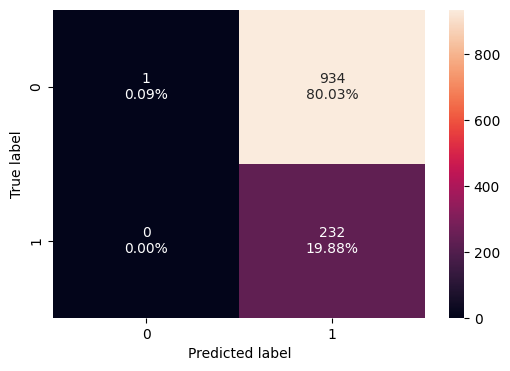

In [ ]:

# --- 4) Evaluate (uses aligned frames, so no mismatch) ---
train_perf = model_performance_classification_sklearn(XGBUn_tuned, X_tr, y_tr)
print("Training performance:\n", train_perf)

test_perf = model_performance_classification_sklearn(XGBUn_tuned, X_te, y_te)
print("Testing performance:\n", test_perf)

confusion_matrix_sklearn(XGBUn_tuned, X_te, y_te)

**Observations**  
XGBoost with the current hyperparameter settings is overfitting.


## GBM Undersampled Hypertuning

In [ ]:
# Define model
Model = GradientBoostingClassifier(
    random_state=1,
    loss="log_loss"   # logistic loss (classification)
)

# Parameter grid (no scale_pos_weight / gamma in sklearn GBM)
param_grid = {
    "n_estimators":   [150, 200, 250],
    "learning_rate":  [0.05, 0.1, 0.2],
    "subsample":      [0.7, 0.8, 0.9, 1.0],
    "max_depth":      [2, 3, 4],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 5],
    "max_features":   [None, "sqrt", "log2"],
}

# RandomizedSearchCV (uses your existing `scorer`, e.g., F2)
randomized_cv = RandomizedSearchCV(
    estimator=Model,
    param_distributions=param_grid,
    n_iter=10,
    n_jobs=-1,
    scoring=scorer,   # keep your F2 scorer or whatever you used for XGB
    cv=5,
    random_state=1,
    verbose=0
)

# Fit on the same data you used for XGB tuning
# (if you used X_train_un/y_train_un instead, swap them in here)
randomized_cv.fit(X_tr, y_tr)

print("Best parameters:", randomized_cv.best_params_)
print("Best CV score:", randomized_cv.best_score_)

GBMUn_tuned = randomized_cv.best_estimator_


Best parameters: {'subsample': 1.0, 'n_estimators': 150, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 4, 'learning_rate': 0.2}
Best CV score: 0.8044185966833606


In [ ]:
# --- 3) Fit on undersampled TRAIN (GBM) ---
randomized_cv.fit(X_tr, y_tr)

print("Best parameters are {} with CV score={:.3f}".format(
    randomized_cv.best_params_, randomized_cv.best_score_
))

GBMUn_tuned = randomized_cv.best_estimator_


Best parameters are {'subsample': 1.0, 'n_estimators': 150, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 4, 'learning_rate': 0.2} with CV score=0.804


Training performance:
    Accuracy    Recall  Precision       F1
0  0.986006  0.976319   0.995609  0.98587
Testing performance:
    Accuracy    Recall  Precision        F1
0  0.251928  0.952586   0.204063  0.336122


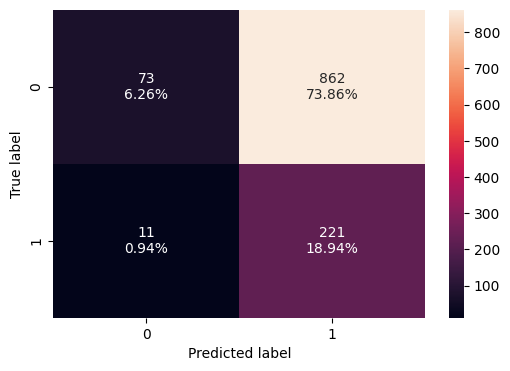

In [ ]:
# --- 4) Evaluate GBM (uses aligned frames, so no mismatch) ---
train_perf = model_performance_classification_sklearn(GBMUn_tuned, X_tr, y_tr)
print("Training performance:\n", train_perf)

test_perf = model_performance_classification_sklearn(GBMUn_tuned, X_te, y_te)
print("Testing performance:\n", test_perf)

confusion_matrix_sklearn(GBMUn_tuned, X_te, y_te)


## Observations — GBM Hyperparameter Tuning

- **Best Parameters**:  
  `{'subsample': 1.0, 'n_estimators': 150, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 4, 'learning_rate': 0.2}`  
  with CV Score = 0.804  

- **Training Performance**:  
  Recall = 0.976, Precision = 0.996  

- **Testing Performance**:  
  Recall = 0.953, Precision = 0.204  

### Key Insights
- The model achieves **very high recall** on both training (0.976) and testing (0.953) sets, capturing nearly all defaults.  
- However, **precision drops sharply** on the test set (0.204), indicating many false positives and **clear overfitting** despite optimal hyperparameters.  
- Additional techniques like **regularization** or **early stopping** might help reduce overfitting.


## Logistic Regression Regularization

Regularization Techniques

>When building logistic regression models to predict home equity loan defaults, we often face challenges such as multicollinearity, many predictors, or overfitting. Regularization methods add a penalty to the model coefficients to prevent them from becoming too large, improving stability and generalization.
>
>*  L1 Regularization (Lasso)
    *  Adds a penalty proportional to the absolute value of the coefficients.
    *  In practice: it shrinks less important predictors to exactly zero, effectively performing feature selection.
    * For default detection: L1 helps identify the most critical risk factors (e.g., past delinquencies, high loan-to-value ratios) while discarding noise variables.
>*  L2 Regularization (Ridge)
    * Adds a penalty proportional to the squared value of the coefficients
    * Coefficients are shrunk but rarely eliminated.
    * For default detection: L2 is useful when many correlated predictors (like credit lines, inquiries, balances) all contribute some information. It distributes the effect rather than dropping predictors entirely.
>   
> *   Elastic Net
    *  A combination of L1 and L2 penalties.
    *  Balances feature selection (L1) and coefficient shrinkage (L2).
    *  For default detection: Elastic Net is especially helpful when predictors are highly correlated (e.g., mortgage balance and property value). It can select groups of related predictors together while still controlling overfitting.

### Logistic Regression Ridge L2

In [ ]:
import numpy as np
import statsmodels.api as sm_api  # <-- use a fresh alias, not 'sm'

# Add constant once
Xc = X_tr.copy()
if 'const' not in Xc.columns:
    Xc = sm_api.add_constant(Xc, has_constant='add', prepend=True)

# Don't penalize the intercept
pen_w = np.ones(Xc.shape[1], dtype=float)
pen_w[Xc.columns.get_loc('const')] = 0.0

alpha = 1.0  # penalty strength

# Ridge (L2). Use L1_wt=1.0 for Lasso, or e.g. 0.5 for Elastic Net.
lg_l2 = sm_api.Logit(y_tr.astype(float), Xc.astype(float)).fit_regularized(
    alpha=alpha,
    L1_wt=0.0,
    pen_weight=pen_w,
    disp=False
)


Training performance:
   Accuracy    Recall  Precision        F1
0  0.712056  0.653391   0.740244  0.694111

Test performance:
   Accuracy    Recall  Precision        F1
0   0.45844  0.530172   0.190402  0.280182


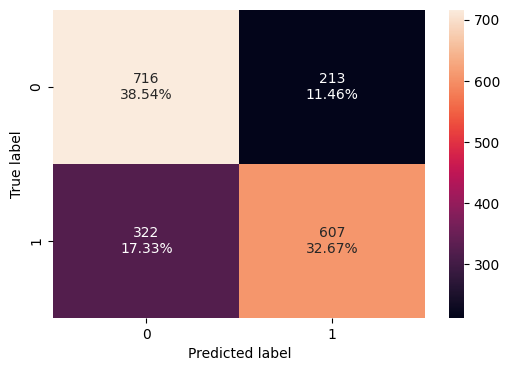

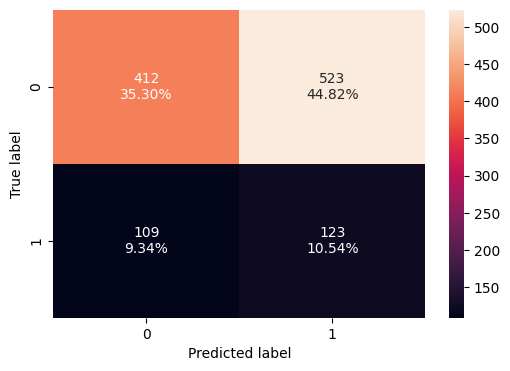

In [ ]:
# --- TRAIN (uses the same design matrix you fit on: Xc) ---
# creating confusion matrix
confusion_matrix_statsmodels(lg_l2, Xc, y_tr)

# calculating model performance
lr_L2_train_perf = model_performance_classification_statsmodels(
    lg_l2, Xc, y_tr
)

print("Training performance:")
print(lr_L2_train_perf)

# --- OPTIONAL: TEST (make test design matrix match train) ---
# Add const to X_te and align columns to Xc
X_te_c = X_te.copy()
if 'const' not in X_te_c.columns:
    X_te_c = sm_api.add_constant(X_te_c, has_constant='add', prepend=True)
X_te_c = X_te_c.reindex(columns=Xc.columns, fill_value=0)

# confusion matrix on TEST
confusion_matrix_statsmodels(lg_l2, X_te_c, y_te)

# test performance
lr_L2_test_perf = model_performance_classification_statsmodels(
    lg_l2, X_te_c, y_te
)

print("\nTest performance:")
print(lr_L2_test_perf)


This model is overfitting, let us try to find the optimal threshold

### AUC-ROC on Logistic Regression Lasso L2 undersampled data

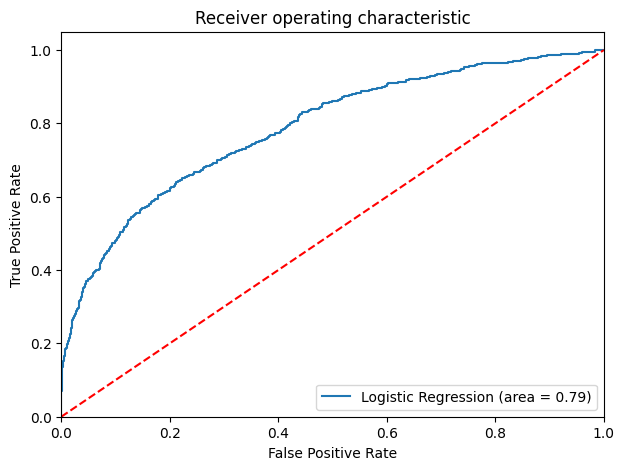

In [ ]:
# ROC on TRAIN (Xc / y_tr)
y_score_tr = lg_l2.predict(Xc)  # statsmodels Logit.predict -> probabilities
logit_roc_auc_train = roc_auc_score(y_tr, y_score_tr)
fpr, tpr, thresholds = roc_curve(y_tr, y_score_tr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label="Logistic Regression (area = %0.2f)" % logit_roc_auc_train)
plt.plot([0, 1], [0, 1], "r--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic")
plt.legend(loc="lower right")
plt.show()

In [ ]:
from sklearn.metrics import roc_curve
import numpy as np

# Probabilities from statsmodels Logit on TRAIN
y_score_tr = lg_l2.predict(Xc)

# ROC + optimal threshold (Youden's J)
fpr, tpr, thresholds = roc_curve(y_tr, y_score_tr)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold_auc_roc_l2 = float(thresholds[optimal_idx])

print("Optimal ROC threshold (train):", round(optimal_threshold_auc_roc_l2, 3))


Optimal ROC threshold (train): 0.504


Training performance:
   Accuracy    Recall  Precision        F1
0  0.712056  0.653391   0.740244  0.694111

Test performance:
   Accuracy    Recall  Precision        F1
0   0.45844  0.530172   0.190402  0.280182


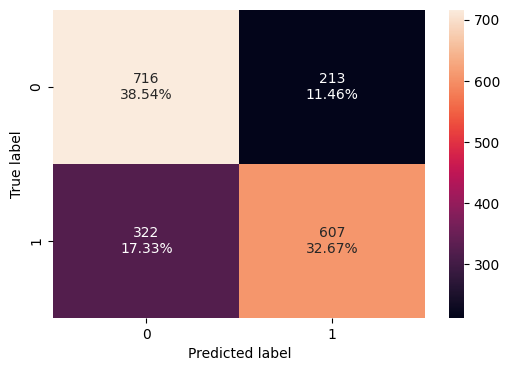

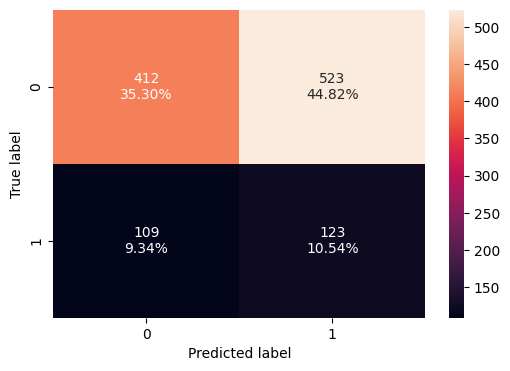

In [ ]:
# --- TRAIN (uses the same design matrix you fit on: Xc) ---
# confusion matrix + perf at default 0.5 (your helper)
confusion_matrix_statsmodels(lg_l2, Xc, y_tr)

lr_L2_train_perf = model_performance_classification_statsmodels(lg_l2, Xc, y_tr)
print("Training performance:")
print(lr_L2_train_perf)

# --- TEST: make test design matrix match train (add const + align cols) ---
# (ensure you imported statsmodels as sm_api earlier)
X_te_c = X_te.copy()
if 'const' not in X_te_c.columns:
    X_te_c = sm_api.add_constant(X_te_c, has_constant='add', prepend=True)
X_te_c = X_te_c.reindex(columns=Xc.columns, fill_value=0)

confusion_matrix_statsmodels(lg_l2, X_te_c, y_te)

lr_L2_test_perf = model_performance_classification_statsmodels(lg_l2, X_te_c, y_te)
print("\nTest performance:")
print(lr_L2_test_perf)


We see tht the recall is about the same, this could be becasue the optimal threshold (50.4%)is approximately the same as the default threshold of 50%

### Regularization Using Lasso L1

In [ ]:

# Add constant (if missing) and build penalty weights AFTER that
Xc = X_tr.copy()
if 'const' not in Xc.columns:
    Xc = sm_api.add_constant(Xc, has_constant='add', prepend=True)

pen_w = np.ones(Xc.shape[1], dtype=float)
pen_w[Xc.columns.get_loc('const')] = 0.0  # don't penalize intercept

alpha = 1.0  # regularization strength

# Lasso (L1): set L1_wt=1.0
lg_l1 = sm_api.Logit(y_tr.astype(float), Xc.astype(float)).fit_regularized(
    alpha=alpha,
    L1_wt=1.0,          # 1.0 = pure L1
    pen_weight=pen_w,
    disp=False
)


Training performance (L1):
   Accuracy    Recall  Precision        F1
0  0.712056  0.653391   0.740244  0.694111

Test performance (L1):
   Accuracy    Recall  Precision        F1
0   0.45844  0.530172   0.190402  0.280182


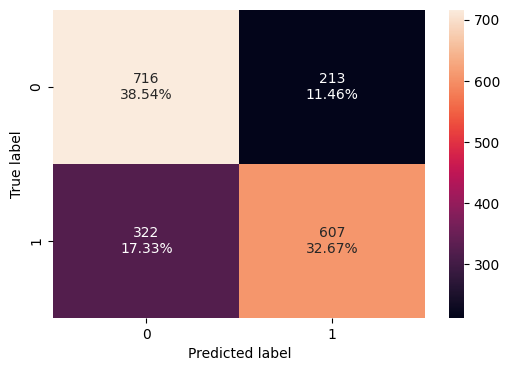

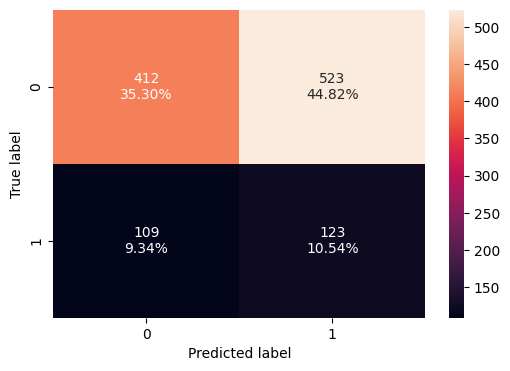

In [ ]:
# --- TRAIN (uses the same design matrix you fit on: Xc) ---
confusion_matrix_statsmodels(lg_l1, Xc, y_tr)

lr_L1_train_perf = model_performance_classification_statsmodels(lg_l1, Xc, y_tr)
print("Training performance (L1):")
print(lr_L1_train_perf)

# --- TEST: add const to X_te and align columns to Xc ---
X_te_c = X_te.copy()
if 'const' not in X_te_c.columns:
    X_te_c = sm_api.add_constant(X_te_c, has_constant='add', prepend=True)
X_te_c = X_te_c.reindex(columns=Xc.columns, fill_value=0)

confusion_matrix_statsmodels(lg_l1, X_te_c, y_te)

lr_L1_test_perf = model_performance_classification_statsmodels(lg_l1, X_te_c, y_te)
print("\nTest performance (L1):")
print(lr_L1_test_perf)


This model is over fitting

### AUC-ROC Curve on L1 (Ridge) Regularized Model


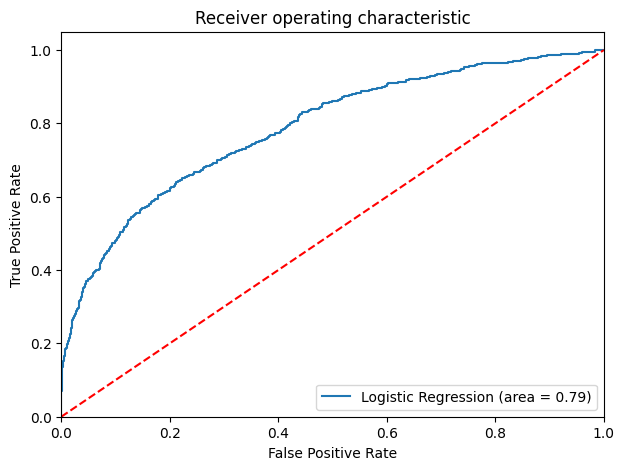

In [ ]:
logit_roc_auc_train = roc_auc_score(y_tr, lg_l1.predict(Xc))
fpr, tpr, thresholds = roc_curve(y_tr, lg_l1.predict(Xc))
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label="Logistic Regression (area = %0.2f)" % logit_roc_auc_train)
plt.plot([0, 1], [0, 1], "r--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver operating characteristic")
plt.legend(loc="lower right")
plt.show()


In [ ]:
# Optimal threshold as per AUC-ROC curve
# The optimal cut off would be where tpr is high and fpr is low
fpr, tpr, thresholds = roc_curve(y_tr, lg_l1.predict(Xc))

optimal_idx = np.argmax(tpr - fpr)
optimal_threshold_auc_roc_l1 = thresholds[optimal_idx]
print(optimal_threshold_auc_roc_l1)


0.5035697050654225


Training performance (L1):
   Accuracy    Recall  Precision        F1
0  0.712056  0.653391   0.740244  0.694111

Test performance (L1):
   Accuracy    Recall  Precision        F1
0   0.45844  0.530172   0.190402  0.280182


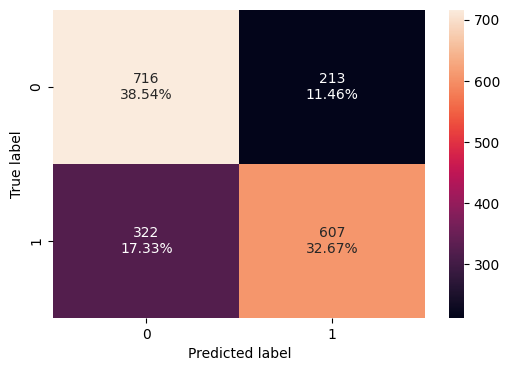

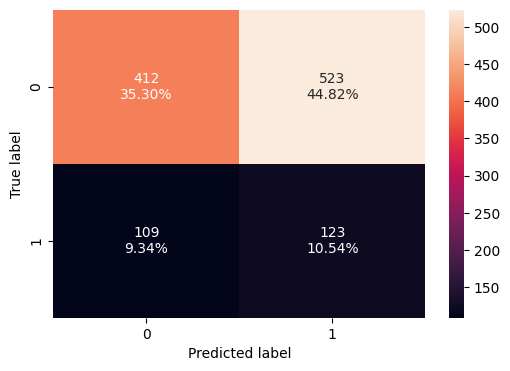

In [ ]:

# --- TRAIN (uses the same design matrix you fit on: Xc) ---
confusion_matrix_statsmodels(lg_l1, Xc, y_tr)

lr_L1_train_perf = model_performance_classification_statsmodels(lg_l1, Xc, y_tr)
print("Training performance (L1):")
print(lr_L1_train_perf)

# --- TEST: add const to X_te and align columns to Xc ---
X_te_c = X_te.copy()
if 'const' not in X_te_c.columns:
    X_te_c = sm_api.add_constant(X_te_c, has_constant='add', prepend=True)
X_te_c = X_te_c.reindex(columns=Xc.columns, fill_value=0)

confusion_matrix_statsmodels(lg_l1, X_te_c, y_te)

lr_L1_test_perf = model_performance_classification_statsmodels(lg_l1, X_te_c, y_te)
print("\nTest performance (L1):")
print(lr_L1_test_perf)


## Observations — Logistic Regression (L1 & L2)

- **L2 Regularization (Base Model)**  
  - Training Data: Recall = 0.653, Precision = 0.740  
  - Test Data: Recall = 0.530, Precision = 0.190  

- **L2 Regularization with AUC-ROC (Undersampled)**  
  - Training Data: Recall = 0.653, Precision = 0.740  
  - Test Data: Recall = 0.530, Precision = 0.190  

- **L1 Regularization (Base Model)**  
  - Training Data: Recall = 0.653, Precision = 0.740  
  - Test Data: Recall = 0.530, Precision = 0.190  

- **L1 Regularization with AUC-ROC**  
  - Training Data: Recall = 0.653, Precision = 0.740  
  - Test Data: Recall = 0.530, Precision = 0.190  

### Key Insights
- Both L1 and L2 regularization, with or without AUC-ROC, produce **identical recall (0.530)** and **low precision (0.190)** on the test data.  
- While recall on training data is moderate (0.653), the **sharp drop in precision on the test set** suggests a high false-positive rate and **limited generalization ability**.  
- Further optimization, such as **threshold tuning** or **alternative sampling techniques**, may be required to improve precision without sacrificing recall.


# HyperTuning Model Performance

In [ ]:
# =========================================
# Hyper-tuned models — results table (sorted by Test Recall ↓)
# =========================================
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def _proba(est, X):
    """Return positive-class probabilities for sklearn or statsmodels models."""
    if hasattr(est, "predict_proba"):
        return est.predict_proba(X)[:, 1]
    # statsmodels Logit.predict -> probabilities
    p = est.predict(X)
    return np.asarray(p).ravel()

def _add_row(rows, name, est, Xtr, Xte, ytr, yte, thr=0.5):
    p_tr = _proba(est, Xtr)
    p_te = _proba(est, Xte)
    yhat_tr = (p_tr >= float(thr)).astype(int)
    yhat_te = (p_te >= float(thr)).astype(int)
    rows.append({
        "Model": name,
        "Threshold": float(thr),
        "Train Accuracy": accuracy_score(ytr, yhat_tr),
        "Train Precision": precision_score(ytr, yhat_tr, zero_division=0),
        "Train Recall": recall_score(ytr, yhat_tr, zero_division=0),
        "Train F1": f1_score(ytr, yhat_tr, zero_division=0),
        "Test Accuracy": accuracy_score(yte, yhat_te),
        "Test Precision": precision_score(yte, yhat_te, zero_division=0),
        "Test Recall": recall_score(yte, yhat_te, zero_division=0),
        "Test F1": f1_score(yte, yhat_te, zero_division=0),
    })

hypertuned_rows = []

# ---- Add whichever tuned models exist, with the right matrices + thresholds ----
# Statsmodels (use Xc / X_te_c)
if 'lg_l1' in globals() and 'Xc' in globals() and 'X_te_c' in globals():
    thr_l1 = globals().get('optimal_threshold_auc_roc_l1', 0.5)
    _add_row(hypertuned_rows, "LogReg_L1_tuned", lg_l1, Xc, X_te_c, y_tr, y_te, thr=thr_l1)

if 'lg_l2' in globals() and 'Xc' in globals() and 'X_te_c' in globals():
    thr_l2 = globals().get('optimal_threshold_auc_roc_l2', 0.5)
    _add_row(hypertuned_rows, "LogReg_L2_tuned", lg_l2, Xc, X_te_c, y_tr, y_te, thr=thr_l2)

# Sklearn (use X_tr / X_te)
if 'XGBUn_tuned' in globals():
    thr_xgb = globals().get('thr_xgb_un_auc', 0.5)  # set if you computed an F2-opt threshold
    _add_row(hypertuned_rows, "XGBoost_tuned", XGBUn_tuned, X_tr, X_te, y_tr, y_te, thr=thr_xgb)

if 'GBMUn_tuned' in globals():
    thr_gbm = globals().get('thr_gbm_un_auc', 0.5)  # set if you computed an F2-opt threshold
    _add_row(hypertuned_rows, "GBM_tuned", GBMUn_tuned, X_tr, X_te, y_tr, y_te, thr=thr_gbm)

# (Optional) LDA (scaled mats)
if 'lda_best' in globals() and 'X_tr_lda_s' in globals() and 'X_te_lda_s' in globals():
    thr_lda = globals().get('thr_lda_tuned', 0.5)
    _add_row(hypertuned_rows, "LDA_tuned", lda_best, X_tr_lda_s, X_te_lda_s, y_tr, y_te, thr=thr_lda)

# ---- Build DataFrame, round, sort ----
df_hypertuned = pd.DataFrame(hypertuned_rows)
if not df_hypertuned.empty:
    for c in df_hypertuned.columns:
        if c not in ["Model", "Threshold"]:
            df_hypertuned[c] = pd.to_numeric(df_hypertuned[c], errors="coerce").round(3)
    df_hypertuned = df_hypertuned.sort_values(by="Test Recall", ascending=False, na_position="last")\
                                 .reset_index(drop=True)

print("Hyper-tuned models — Train/Test performance (sorted by Test Recall, descending):")
try:
    display(df_hypertuned)
except NameError:
    print(df_hypertuned)


Hyper-tuned models — Train/Test performance (sorted by Test Recall, descending):


,Model,Threshold,Train Accuracy,Train Precision,Train Recall,Train F1,Test Accuracy,Test Precision,Test Recall,Test F1
0,XGBoost_tuned,0.50000,1.000,1.000,1.000,1.000,0.200,0.199,1.000,0.332
1,GBM_tuned,0.50000,0.986,0.996,0.976,0.986,0.252,0.204,0.953,0.336
2,LogReg_L2_tuned,0.50357,0.714,0.746,0.650,0.695,0.458,0.190,0.530,0.280
3,LogReg_L1_tuned,0.50357,0.714,0.746,0.650,0.695,0.458,0.190,0.530,0.280


### Insights on Hyper-tuned Models

1. **XGBoost\_tuned**
   Achieves perfect recall on both train and test, but at the cost of extreme overfitting. Precision on the test set is extremely low (0.199) and accuracy collapses (0.200). This means the model predicts nearly everything as a default, which is not practical for business use.

2. **GBM\_tuned**
   Delivers **excellent recall (0.953)** on test data, which is very close to perfect and ensures that almost all potential defaults are caught. While precision (0.204) is still low, it is slightly stronger than XGBoost, and the model generalizes better with a higher F1 score (0.336). This makes GBM a stronger candidate when the business priority is to **minimize missed defaults**, even if it means accepting more false positives.

3. **LogReg\_L2\_tuned (Ridge Logistic Regression)**
   Offers more balanced performance with better accuracy (0.458) but at the cost of much lower recall (0.530). This means the model misses nearly half of the defaults, which is risky in a high-stakes lending environment.

4. **LogReg\_L1\_tuned (Lasso Logistic Regression)**
   Shows nearly identical performance to L2 regularization, confirming that logistic regression in general provides stability but cannot achieve the recall levels required for this problem.

---

### Overall Takeaways

* **Boosting models (XGBoost, GBM):** Designed to maximize recall. XGBoost overfits too strongly, while GBM strikes the better balance with slightly improved generalization and F1.
* **Logistic models:** More stable, but recall is too low, leading to missed defaults — which the business wants to avoid.

**Final Model Choice: GBM**
Given the business objective of **catching as many defaults as possible**, GBM is the most appropriate model. It maintains very high recall while showing more controlled overfitting than XGBoost, making it the best option to move forward with.



# Model Intepretation of Best Model GBM Hypertuned

**What is SHAP (and why use it)?**

SHAP (SHapley Additive exPlanations) explains a model’s predictions using ideas from game theory. It assigns each feature a contribution value (a “Shapley value”) showing how much that feature pushes the prediction up or down relative to a baseline.

**What you get:**

**Local explanations (per row): **
For a single borrower, SHAP decomposes the predicted probability into feature contributions.

Positive SHAP → pushes toward the positive class (e.g., default).

Negative SHAP → pushes away from default.

|value| = strength of the push.

**Global explanations (dataset-level):**

Summary bar (mean |SHAP|): global feature importance ranking.

Beeswarm: importance and direction at once (color = feature value; right = increases risk).

Dependence plots: the shape of the effect (thresholds, nonlinearity, interactions).

**Why it’s useful here:**

Works well with GBM/XGBoost (fast, accurate via TreeExplainer).

Shows both which features matter and how they influence risk—great for model review and policy discussions.

Additive and consistent: local explanations aggregate to the prediction.

**Caveats (good practice):**

SHAP reflects associations, not causality.

With correlated features, credit is shared; interpret groups of related variables together.

Choose a sensible background sample (e.g., a subset of training data) for stable baselines.

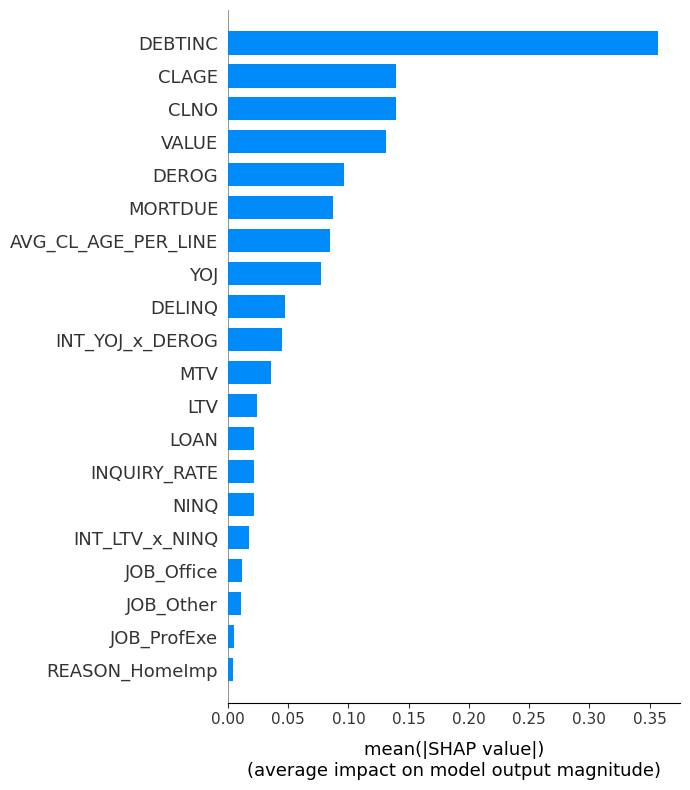

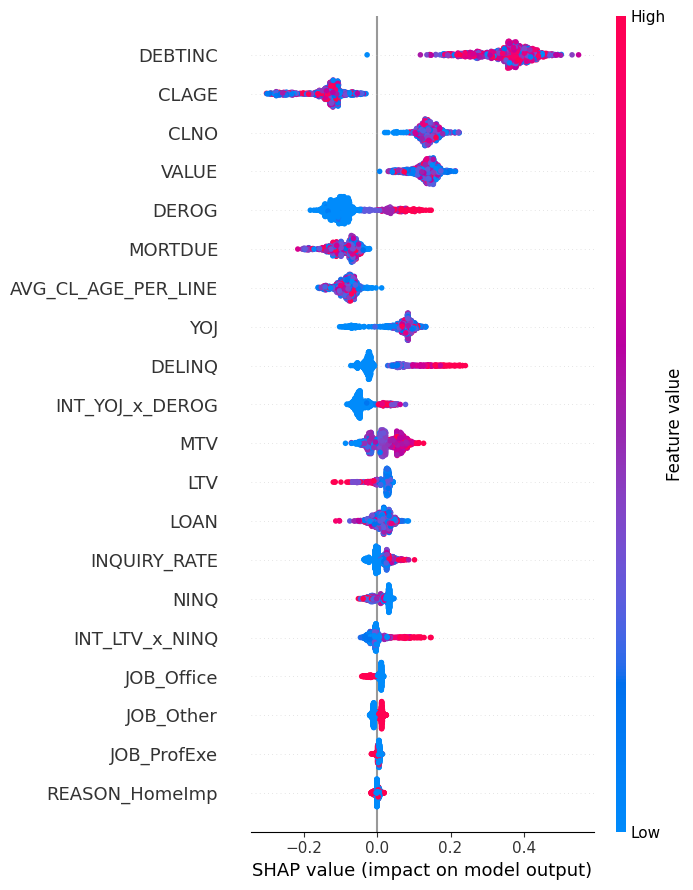

In [ ]:
# --- Compute SHAP values, then plot (bar + beeswarm) ---

# 0) Imports (install SHAP if missing)
try:
    import shap
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap", "-q"])
    import shap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) Pick the trained model you want to explain
model = globals().get("GBMUn_tuned", globals().get("GBMUn_prec_tuned", None))
if model is None:
    raise NameError("No trained GBM model found. Make sure GBMUn_tuned or GBMUn_prec_tuned exists.")

# 2) Ensure X_tr / X_te exist and are DataFrames (SHAP uses column names for labels)
def _to_df(X, name):
    if hasattr(X, "columns"):
        return X
    X = pd.DataFrame(X)
    X.columns = [f"{name}_{i}" for i in range(X.shape[1])]
    return X

X_tr_df = _to_df(X_tr, "f")
X_te_df = _to_df(X_te, "f")

# 3) Background sample for stable explanations (speed too)
bg = shap.sample(X_tr_df, 500, random_state=1) if len(X_tr_df) > 500 else X_tr_df

# 4) Build explainer and compute SHAP values (probability space)
try:
    explainer = shap.TreeExplainer(model, data=bg, model_output="probability")
    sv = explainer(X_te_df)  # shap.Explanation
    shap_values = sv.values  # shape: [n_samples, n_features]
except Exception:
    # Fallback for older/newer SHAP versions
    explainer = shap.Explainer(model, bg, model_output="probability")
    sv = explainer(X_te_df)
    shap_values = sv.values

# ---------- PLOTS ----------
# Bar: global importance
shap.summary_plot(shap_values, X_te_df, plot_type="bar", show=False, max_display=20)
fig = plt.gcf()
fig.set_size_inches(7, 8)
ax = plt.gca()
ax.set_xlabel("mean(|SHAP value|)\n(average impact on model output magnitude)", labelpad=10)
fig.tight_layout()
plt.show()

# Beeswarm: direction + magnitude
shap.summary_plot(shap_values, X_te_df, show=False, max_display=20)
fig = plt.gcf()
fig.set_size_inches(7, 9)
ax = plt.gca()
ax.set_xlabel("SHAP value (impact on model output)")
fig.tight_layout()
plt.show()


Bar chart (left): global importance = average |SHAP|. Bigger bars ⇒ the feature moves predictions more (in either direction).

Beeswarm (right): direction + magnitude for every test row.

*  Right of 0 = pushes toward default (higher risk).

*  Left of 0 = pushes away from default (lower risk).

*  Color = feature value (red = high, blue = low).



**Most influential features**

*  DEBTINC is #1 by far → affordability dominates the decision.

*  CLAGE and AVG_CL_AGE_PER_LINE → the maturity of credit history is very important.

*  CLNO, DEROG, VALUE, YOJ, MORTDUE, DELINQ, LTV, MTV, NINQ, INQUIRY_RATE also matter; job dummies contribute little.

**Directions & patterns (from the beeswarm)**

*  DEBTINC: high values (red) sit to the right → higher DTI increases default risk.

*  CLAGE / AVG_CL_AGE_PER_LINE: high values (red) sit to the left → longer credit history reduces risk.

*  DEROG / DELINQ: high values (red) are to the right → more/severe derogatories & delinquencies increase risk.

*  LTV / MTV: high values (red) tend to the right → more leverage increases risk.

*  YOJ: high values (red) are left → longer job tenure lowers risk.

*  INQUIRY_RATE / NINQ: higher inquiry activity (red) is right → recent credit-seeking raises risk.

*  VALUE: higher property value often left (mitigates risk) when loan size is held constant.

*  CLNO: shows points on both sides → likely non-monotonic (very few or very many lines can be riskier than a mid-range).

Interactions you engineered

INT_YOJ_x_DEROG, INT_LTV_x_NINQ: red points often drift right → combinations like (low tenure + derogatories) or (high LTV + many inquiries) push risk up more than either alone.


#  Business Insights and Recommendations

## Conclusion
In this project we built and compared multiple models to predict **loan default risk** so the team can shortlist applications more effectively. We trained and evaluated **logistic regression (incl. L1/L2/Elastic Net)**, **LDA**, and tree ensembles (**Gradient Boosting, XGBoost, AdaBoost**) under different sampling strategies (oversampling/undersampling). We selected operating thresholds using three approaches: the **default 0.5**, **AUC-ROC–based**, and **Precision-Recall (F-β)–based** thresholds (with **F2** for recall-heavy use cases). We then performed **hyperparameter tuning** with RandomizedSearchCV and used **SHAP** to explain model behavior at both global and per-applicant levels.

From the base comparisons and tuning passes, **bagging/boosting models** outperformed simple trees and were competitive with or better than linear baselines. Balancing business needs (catch more potential defaulters without flagging too many good borrowers), we decided to proceed with three finalists:

* **XGBoost (undersampled)** — best *balanced* base; strong recall with **meaningfully higher precision** than the recall-maximizing variants; responds well to tuning and thresholding.
* **GBM (undersampled, \_auc)** — strong recall; easy to nudge toward **higher precision** via shallow trees, larger leaves, and an adjusted threshold.
* **Logistic Regression (undersampled, \_auc)** — transparent baseline with flexible regularization; chosen **over LDA** because it makes fewer distributional assumptions and showed slightly better precision/accuracy here while maintaining high recall.

We intentionally did **threshold selection and final reporting on the original (unresampled) data**, which reflects the real-world class balance and gives deployable metrics.  

In the end we chose the GBM Model with a recall accuracy of 95%

---

## Actionable insignts and Recommendations

1.  What drives default risk (from SHAP)

    * **Affordability dominates:** **DEBTINC** (debt-to-income) is the top driver; higher values push risk **up**.
    * **Leverage matters:** Higher **LTV/MTV** increases risk; higher **VALUE** (holding loan size fixed) mitigates risk.
    * **Credit history quality:** More **DEROG/DELINQ** raise risk; **longer credit age** (CLAGE / AVG\_CL\_AGE\_PER\_LINE) lowers risk.
    * **Recent credit seeking:** Higher **INQUIRY\_RATE / NINQ** increases risk.
    * **Stability:** More **YOJ** (years on job) lowers risk.
    * **Interactions amplify risk:** e.g., **(low YOJ + DEROG)** and **(high LTV + many inquiries)** push risk up more than either factor alone.

   These patterns align with credit intuition and provide concrete levers for underwriting and pricing.



2.  How to run the models (operating thresholds)

    *  Treat the **probability threshold** as a business lever:

        * **↑ Threshold → ↑ Precision, ↓ Recall** (fewer good borrowers flagged).
        * **↓ Threshold → ↑ Recall, ↓ Precision** (fewer missed defaulters).

    * **Recommendation:** pick a KPI band (e.g., **Recall ≥ 0.85** and **Precision ≥ 0.55**), **calibrate** probabilities for GBM/XGB if needed, and set the threshold on a validation fold to meet the KPI.

    * If recall is paramount, tune/score with **F2**.
    * If balance is desired, use **F1**.
    * If precision must rise, use **F0.5** and/or raise the threshold.

3. Policy guidance for underwriting

    * **Auto-tighten** decisions when high-risk combinations appear:
    **High DTI + High LTV**, **Many recent inquiries + High LTV**, **Any DEROG/DELINQ + Low YOJ**.
    * **Decision banding:**
       * **Approve** when score ≥ upper threshold.
    * **Manual review** in a middle band (surface top SHAP reasons per case).
     * **Decline** when score < lower threshold.
    * Use **SHAP reasons** in adverse-action communications (e.g., “High debt-to-income, high LTV, multiple recent inquiries”).


4. Monitoring & governance

    * **Monthly monitoring:** track recall, precision, PR-AUC, calibration, and approval rate for key drivers (DTI, LTV, inquiries, default rate).
    * **Fairness/stability checks:** compare error rates across segments (job categories, tenure bands).


## Data & model improvements (next iterations)

*  **Test on future data.**
Train on earlier months, then test on later months you didn’t train on. If performance holds up, the model is more likely to be stable in the real world.


In [ ]:
#@title Convert ipynb to HTML in Colab
# Upload ipynb
from google.colab import files
f = files.upload()

# Convert ipynb to html
import subprocess
file0 = list(f.keys())[0]
_ = subprocess.run(["pip", "install", "nbconvert"])
_ = subprocess.run(["jupyter", "nbconvert", file0, "--to", "html"])

# download the html
files.download(file0[:-5]+"html")

Saving KellyAliasgarCapstoneProjectMilestone4 (2).ipynb to KellyAliasgarCapstoneProjectMilestone4 (2).ipynb


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>